# Retail Growth Opportunity & Profitability Analytics

# Project Snapshot

## Dataset
- 180,519 Order Items
- 65,752 Orders
- 20,652 Customers
- 50 Product Categories

## Business Scope
- Order Fulfillment
- Delivery Performance
- Profitability Analysis
- Customer Segmentation
- Product Portfolio Strategy

## Key Results
- Top 40% customers generated 79.2% of sales and 78.0% of profit
- 8 core product categories contributed ~85% of sales and profit
- 54.8% of orders were completed, while 24.5% were canceled
- More than 50% of deliveries experienced delays
- Shop By Sport identified as the strongest product growth opportunity

# Executive Summary

## Key Findings

- Only 54.8% of orders were completed successfully, and more than half of all orders experienced delivery delays, highlighting significant operational improvement opportunities.

- Delivery delays are widespread across the portfolio. More than half of all orders experienced late delivery, suggesting that fulfillment reliability may have a broader operational impact beyond individual shipping modes.

- VIP and High Value customers represent approximately 40% of customers but contribute 79.2% of sales and 78.0% of profit, demonstrating strong customer-value concentration.

- Eight Core Product categories generate approximately 85% of total sales and profit, while Supporting Products provide the strongest growth opportunities.

- Product performance is similarly concentrated. Eight Core Product categories generate approximately 85% of total sales and profit, while Supporting Products and selected Long-Tail Products contribute additional growth and diversification potential.

## Overall Conclusion

The analysis reveals that business performance is highly concentrated across both customers and products. A relatively small group of high-value customers and Core Product categories contributes the majority of sales and profit, while operational challenges such as order cancellations, loss-making transactions, and delivery delays continue to affect overall performance.

The findings suggest that future business performance will depend not only on maintaining existing revenue drivers, but also on improving operational efficiency and broadening revenue contribution across customers and product categories.

# Product Portfolio Decision Framework

| Product Group | Representative Categories | Decision Rationale | Strategic Action |
|---------------|--------------------------|-------------------|------------------|
| Core Products | Fishing, Cleats, Camping & Hiking | Drive the majority of revenue and profit | Protect |
| Growth Opportunities | Shop By Sport, Electronics, Accessories | Strong customer reach but under-monetized | Expand |
| Scale Opportunities | Girls' Apparel, Women's Apparel, Trade-In | Healthy profitability with room for spending growth | Monetize |
| Niche Value Products | Computers, Garden, Golf Shoes | High value despite limited reach | Maintain |
| Low-Priority Review | Soccer, Men's Clothing, Basketball | Limited customer reach and profit contribution | Review |

# Project Steps
1. Understand data
2. Data Quality Check & Cleaning
3. Univariate Analysis
4. Order Outcome Analysis
5. Delivery Performance Analysis
6. Profitability Analysis
7. Customer Segmentation
8. Product Segmentation
9. Product Opportunity Analysis
10. Business Recommendation

# Step 1. Understand Data

### Analysis Goal

What business questions can be answered using this dataset, and what is the appropriate level of analysis?

The analysis will:

- Review dataset size and structure
- Examine data types and key business fields
- Understand customer, order, product, financial, and logistics dimensions
- Identify analytical and non-analytical attributes
- Determine data granularity and entity relationships
- Define the scope of subsequent analyses

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [58]:
df = pd.read_csv("/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv", encoding="latin1")

print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [59]:
print("Customer Id:", df['Customer Id'].nunique())
print("Order Id:", df['Order Id'].nunique())
print("Order Item Id:", df['Order Item Id'].nunique())
print("Total rows:", len(df))


Customer Id: 20652
Order Id: 65752
Order Item Id: 180519
Total rows: 180519


### Key Observations

- The dataset contains approximately **180,000 records** and **53 columns**, providing sufficient scale for customer, product, order, profitability, and logistics analysis.

- Data types include **15 numeric (float64)**, **14 integer (int64)**, and **24 categorical (object)** fields. Numerical fields support quantitative analysis, categorical fields support segmentation, and date-related fields require preprocessing before time-series analysis.

- The dataset contains rich analytical dimensions across customers, orders, products, financial performance, and logistics operations. This enables customer segmentation, product performance evaluation, profitability analysis, and delivery impact assessment.

- Uniqueness checks show that **Order Item Id is nearly equal to the total number of rows**, indicating that the dataset is stored at the **order-item level**. Each row represents a single product purchased within an order rather than a customer-level or order-level record.

### Business Implications

- The order-item granularity enables flexible aggregation into customer-level, order-level, product-level, category-level, and regional analyses.

- Customer, product, and financial attributes provide a strong foundation for customer segmentation, profitability analysis, product portfolio evaluation, and opportunity identification.

- Logistics-related variables create opportunities to investigate the relationship between delivery performance, customer experience, and business outcomes.

- Because the dataset captures both transaction-level and operational information, it supports end-to-end analysis from customer purchasing behavior and product performance to profitability and fulfillment performance.

# Step 2. Data Quality Check & Cleaning

### Analysis Goal

Is the dataset sufficiently reliable for analysis, and what data preparation steps are required before generating business insights?

The analysis will:

- Identify missing values and their potential impact
- Detect duplicate records
- Review invalid, low-information, and privacy-sensitive fields
- Standardize data types and date formats
- Check logical consistency and data quality rules
- Remove unnecessary columns
- Create the final analysis-ready dataset

The objective is to ensure that subsequent findings are based on accurate, consistent, and business-relevant data.

In [60]:
# 保留原始資料，建立清理後版本
df_clean = df.copy()

# ==================================================
# Part A. Data Quality Check
# ==================================================

# 1. Missing values
print("===== 1. Missing Values =====")
missing = df_clean.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])   # 只印出有缺失的欄位

# 2. Duplicates
print("\n===== 2. Duplicates =====")
dup_count = df_clean.duplicated().sum()
print("Number of duplicated rows:", dup_count)

# 3. Invalid / useless columns
print("\n===== 3. Invalid / Useless Columns Check =====")

# 3.1 每欄 unique 值數量
nunique_sorted = df_clean.nunique().sort_values()
print("\nColumns with lowest unique values:")
print(nunique_sorted.head(15))
print("\nColumns with highest unique values:")
print(nunique_sorted.tail(15))

# 3.2 全空欄位
all_null_cols = df_clean.columns[df_clean.isnull().all()].tolist()
print("\nColumns with all null values:")
print(all_null_cols if all_null_cols else "None")

# 3.3 只有一個值的欄位
one_value_cols = nunique_sorted[nunique_sorted <= 1].index.tolist()
print("\nColumns with only one unique value (or all null):")
print(one_value_cols if one_value_cols else "None")

# 3.4 高 cardinality 欄位（幾乎每列都不同）
high_cardinality_cols = [col for col in df_clean.columns if df_clean[col].nunique() > 0.9 * len(df_clean)]
print("\nHigh-cardinality columns (almost unique for each row):")
print(high_cardinality_cols if high_cardinality_cols else "None")

# 4. Data type
print("\n===== 4. Data Types =====")
print("\nObject columns (may need review for type conversion):")
obj_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(obj_cols if obj_cols else "None")

# 5. Logical errors
print("\n===== 5. Logical Errors =====")

negative_sales = df_clean[df_clean['Sales'] < 0]
print("\nRows with negative Sales:", len(negative_sales))
if len(negative_sales) > 0:
    print(negative_sales[['Sales']].head())

negative_shipping = df_clean[df_clean['Days for shipping (real)'] < 0]
print("\nRows with negative Days for shipping (real):", len(negative_shipping))
if len(negative_shipping) > 0:
    print(negative_shipping[['Days for shipping (real)']].head())

negative_scheduled = df_clean[df_clean['Days for shipment (scheduled)'] < 0]
print("\nRows with negative Days for shipment (scheduled):", len(negative_scheduled))
if len(negative_scheduled) > 0:
    print(negative_scheduled[['Days for shipment (scheduled)']].head())

invalid_price = df_clean[df_clean['Product Price'] <= 0]
print("\nRows with Product Price <= 0:", len(invalid_price))
if len(invalid_price) > 0:
    print(invalid_price[['Product Price']].head())

invalid_qty = df_clean[df_clean['Order Item Quantity'] <= 0]
print("\nRows with Order Item Quantity <= 0:", len(invalid_qty))
if len(invalid_qty) > 0:
    print(invalid_qty[['Order Item Quantity']].head())

===== 1. Missing Values =====
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

===== 2. Duplicates =====
Number of duplicated rows: 0

===== 3. Invalid / Useless Columns Check =====

Columns with lowest unique values:
Product Description              0
Customer Password                1
Product Status                   1
Customer Email                   1
Late_delivery_risk               2
Customer Country                 2
Customer Segment                 3
Delivery Status                  4
Days for shipment (scheduled)    4
Shipping Mode                    4
Type                             4
Market                           5
Order Item Quantity              5
Days for shipping (real)         7
Order Status                     9
dtype: int64

Columns with highest unique values:
Customer Lname                  1109
Order Item Total                2927
Sales per customer              2927
Order City 

In [61]:
# ==================================================
# Part B. Data Quality Cleaning
# ==================================================
print("\n" + "="*50)
print("Start Cleaning Based on the Above Results")
print("="*50)

# Step 1. Missing values
# Product Description: 全空 -> 刪除
# Order Zipcode: 缺失極高 -> 刪除
cols_to_drop_missing = ['Product Description', 'Order Zipcode']
cols_to_drop_missing = [col for col in cols_to_drop_missing if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop_missing, errors='ignore')
print("\n[Step 1] Missing values handled")
print("Dropped columns due to excessive missing values:", cols_to_drop_missing)

# Step 2. Duplicates
if dup_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("\n[Step 2] Duplicates handled")
    print("Dropped duplicated rows:", dup_count)
else:
    print("\n[Step 2] Duplicates")
    print("No duplicated rows found, so no action was needed.")


# Step 3. Invalid / useless columns
# - Customer Password / Customer Email：敏感資訊 -> 刪除
# - Product Status：1個唯一值 -> 無資訊量，刪除
# - Customer Fname / Customer Lname：個資-> 刪除
# - Order Item Id：高 cardinality，但先保留，因為可能用於追蹤單筆資料
cols_to_drop_useless = [
    'Customer Password',
    'Customer Email',
    'Product Status',
    'Customer Fname',
    'Customer Lname'
]
cols_to_drop_useless = [col for col in cols_to_drop_useless if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop_useless, errors='ignore')
print("\n[Step 3] Invalid / useless columns handled")
print("Dropped useless / sensitive columns:", cols_to_drop_useless)
print("Kept high-cardinality column 'Order Item Id' for potential traceability.")


# Step 4. Data type
# 日期欄位轉 datetime
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
converted_date_cols = []
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        converted_date_cols.append(col)

# 類別欄位可轉 category（節省記憶體、方便分析）
category_cols = [
    'Type',
    'Delivery Status',
    'Customer Country',
    'Customer Segment',
    'Market',
    'Order Region',
    'Order State',
    'Order Status',
    'Shipping Mode'
]
converted_category_cols = []
for col in category_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        converted_category_cols.append(col)
print("\n[Step 4] Data type handled")
print("Converted to datetime:", converted_date_cols)
print("Converted to category:", converted_category_cols)


# Step 5. Logical errors
# 根據檢查結果皆為 0，因此不需處理
logical_checks = {
    "negative_sales": (df_clean['Sales'] < 0).sum() if 'Sales' in df_clean.columns else 0,
    "negative_real_shipping_days": (df_clean['Days for shipping (real)'] < 0).sum() if 'Days for shipping (real)' in df_clean.columns else 0,
    "negative_scheduled_shipping_days": (df_clean['Days for shipment (scheduled)'] < 0).sum() if 'Days for shipment (scheduled)' in df_clean.columns else 0,
    "invalid_product_price": (df_clean['Product Price'] <= 0).sum() if 'Product Price' in df_clean.columns else 0,
    "invalid_order_item_quantity": (df_clean['Order Item Quantity'] <= 0).sum() if 'Order Item Quantity' in df_clean.columns else 0
}
print("\n[Step 5] Logical errors")
print(logical_checks)
print("No logical errors were found based on the current checks, so no rows were removed.")


Start Cleaning Based on the Above Results

[Step 1] Missing values handled
Dropped columns due to excessive missing values: ['Product Description', 'Order Zipcode']

[Step 2] Duplicates
No duplicated rows found, so no action was needed.

[Step 3] Invalid / useless columns handled
Dropped useless / sensitive columns: ['Customer Password', 'Customer Email', 'Product Status', 'Customer Fname', 'Customer Lname']
Kept high-cardinality column 'Order Item Id' for potential traceability.

[Step 4] Data type handled
Converted to datetime: ['order date (DateOrders)', 'shipping date (DateOrders)']
Converted to category: ['Type', 'Delivery Status', 'Customer Country', 'Customer Segment', 'Market', 'Order Region', 'Order State', 'Order Status', 'Shipping Mode']

[Step 5] Logical errors
{'negative_sales': np.int64(0), 'negative_real_shipping_days': np.int64(0), 'negative_scheduled_shipping_days': np.int64(0), 'invalid_product_price': np.int64(0), 'invalid_order_item_quantity': np.int64(0)}
No logic

In [62]:
# ==================================================
# Part C. Final Check
# ==================================================
print("\n" + "="*50)
print("Final Cleaned Data Summary")
print("="*50)

print("Final shape:", df_clean.shape)

print("\nTop remaining missing values:")
final_missing = df_clean.isnull().sum().sort_values(ascending=False)
print(final_missing[final_missing > 0].head(10))

print("\nData types after cleaning:")
print(df_clean.dtypes.value_counts())

print("\nPreview of cleaned data:")
display(df_clean.head())


Final Cleaned Data Summary
Final shape: (180519, 46)

Top remaining missing values:
Customer Zipcode    3
dtype: int64

Data types after cleaning:
int64             13
float64           13
object             9
datetime64[ns]     2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

Preview of cleaned data:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


### Key Observations

- Data quality was generally strong. No duplicate records or material logical inconsistencies were identified, allowing all transaction rows to be retained for analysis.

- Field **Product Description** contained only missing values and provided no analytical value. Field **Order Zipcode** exhibited a high proportion of missing values and it was not required for the primary analysis objectives. Therefore, these two fields were removed.

- Several personally identifiable information (PII) fields, including **Customer Password**, **Customer Email**, **Customer Fname**, and **Customer Lname**, were removed to protect privacy and reduce unnecessary data complexity.

- **Product Status** was removed because it contained only a single unique value and therefore contributed no meaningful information for segmentation or performance analysis.

- Date-related fields, including **order date** and **shipping date**, were converted to datetime format to support future time-based analysis, trend evaluation, and operational performance monitoring.

# Step 3. Univariate Analysis

### Analysis Goal

What does the dataset reveal about the distribution, characteristics, and quality of individual variables before exploring relationships between them?

The analysis will:

- Identify column groups and analytical variable types
- Examine categorical variable distributions
- Analyze numerical variable distributions
- Detect potential outliers and unusual values
- Explore time-based variable distributions
- Summarize key findings and analytical implications

The objective is to understand the behavior of individual variables, identify potential data issues, and establish a foundation for subsequent customer, operational, profitability, and product analyses.

## Step 3.1 Univariate Analysis - Identify column groups

### Column Grouping Logic

The dataset contains 46 columns. I first grouped all columns into five categories to ensure completeness and proper data organization:

1. ID columns  
   Identifiers such as customer ID, order ID, product ID, and category ID, which are mainly used for joins and aggregation rather than direct analysis.

2. Datetime columns  
   Time-related variables such as order date and shipping date, used for temporal analysis and trend evaluation.

3. Categorical columns  
   Variables suitable for frequency distribution and segmentation, such as payment type, delivery status, customer segment, market, order region, and product category.

4. Numeric columns  
   Variables suitable for numerical summary and statistical analysis, such as sales, discount, quantity, profit, shipping days, latitude, and longitude.

5. Excluded columns  
   High-cardinality or non-analytical text fields (e.g., Customer Street, Product Image) that are not directly useful for standard EDA.

---

### EDA Strategy

After organizing all columns, I prioritize a subset of key variables based on the business objective.

For this e-commerce / order analysis, the key variables focus on:

- Revenue and profit (e.g., Sales, Order Item Total, Profit)
- Delivery experience (e.g., Delivery Status, Shipping Time, Late Delivery Risk)
- Customer segmentation (e.g., Customer Segment, Market, Region)
- Order and payment status

I perform univariate analysis on these key categorical and numerical variables first,  
and then drill down into additional columns only when a specific issue or pattern is identified.

---

In [63]:
# =========================
# Step 3.1 Identify Column Groups
# =========================
# Full column grouping:
# 1. id_cols：識別碼欄位
# 2. datetime_cols：時間欄位
# 3. categorical_cols：適合做類別分布的欄位
# 4. numeric_cols：適合做數值分布的欄位
# 5. excluded_cols：不適合直接做一般 EDA 的欄位
#
# EDA focus:
# 6. key_categorical_cols：Step 4 優先分析的重要類別欄位
# 7. key_numeric_cols：Step 4 優先分析的重要數值欄位
# =========================

id_cols = [
    'Customer Id',
    'Order Customer Id',
    'Order Id',
    'Order Item Id',
    'Order Item Cardprod Id',
    'Product Card Id',
    'Category Id',
    'Product Category Id',
    'Department Id'
]

datetime_cols = [
    'order date (DateOrders)',
    'shipping date (DateOrders)'
]

categorical_cols = [
    'Type',
    'Delivery Status',
    'Category Name',
    'Customer Segment',
    'Customer City',
    'Customer Country',
    'Customer State',
    'Department Name',
    'Market',
    'Order City',
    'Order Country',
    'Order Region',
    'Order State',
    'Order Status',
    'Shipping Mode',
    'Product Name'
]

numeric_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Late_delivery_risk',
    'Customer Zipcode',
    'Latitude',
    'Longitude',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

excluded_cols = [
    'Customer Street',
    'Product Image'
]

# =========================
# Key columns for EDA
# =========================
# 挑跟 business goal 最相關的欄位做 univariate analysis。

key_categorical_cols = [
    'Delivery Status',
    'Customer Segment',
    'Market',
    'Order Region',
    'Order Country',
    'Shipping Mode',
    'Type',
    'Order Status',
    'Category Name',
    'Department Name'
]

key_numeric_cols = [
    'Sales',
    'Order Item Total',
    'Order Item Quantity',
    'Order Item Product Price',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Profit Per Order',
    'Benefit per order',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk'
]

# =========================
# Print column group counts
# =========================

print("ID columns:", len(id_cols))
print("Datetime columns:", len(datetime_cols))
print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))
print("Excluded columns:", len(excluded_cols))

total_classified = (
    len(id_cols)
    + len(datetime_cols)
    + len(categorical_cols)
    + len(numeric_cols)
    + len(excluded_cols)
)

print("\nTotal classified columns:", total_classified)
print("Total dataframe columns:", len(df_clean.columns))

print("\nKey categorical columns:", len(key_categorical_cols))
print("Key numeric columns:", len(key_numeric_cols))


ID columns: 9
Datetime columns: 2
Categorical columns: 16
Numeric columns: 17
Excluded columns: 2

Total classified columns: 46
Total dataframe columns: 46

Key categorical columns: 10
Key numeric columns: 11


## Step 3.2 Univariate Analysis - Categorical variable distribution

In this step, I analyze the distribution of key categorical variables.  
The goal is to understand the composition of the dataset across important business dimensions, such as delivery status, customer segment, market, region, shipping mode, payment type, order status, and product category.
Instead of analyzing every categorical column at the beginning, I focus on key variables that are more directly related to revenue, delivery experience, customer segmentation, and order behavior.

In [64]:
# =========================
# Step 3.2 Categorical Variable Distribution Table
# =========================

for col in key_categorical_cols:
    print("=" * 80)
    print(f"Column: {col}")
    print("=" * 80)
    
    summary = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )
    
    summary.columns = [col, 'count']
    summary['percentage'] = round(summary['count'] / len(df) * 100, 2)
    summary['cumulative_percentage'] = summary['percentage'].cumsum()
    
    display(summary.head(15))

Column: Delivery Status


,Delivery Status,count,percentage,cumulative_percentage
0,Late delivery,98977,54.83,54.83
1,Advance shipping,41592,23.04,77.87
2,Shipping on time,32196,17.84,95.71
3,Shipping canceled,7754,4.30,100.01


Column: Customer Segment


,Customer Segment,count,percentage,cumulative_percentage
0,Consumer,93504,51.80,51.80
1,Corporate,54789,30.35,82.15
2,Home Office,32226,17.85,100.00


Column: Market


...

,Order Status,count,percentage,cumulative_percentage
0,COMPLETE,59491,32.96,32.96
1,PENDING_PAYMENT,39832,22.07,55.03
2,PROCESSING,21902,12.13,67.16
3,PENDING,20227,11.20,78.36
4,CLOSED,19616,10.87,89.23
5,ON_HOLD,9804,5.43,94.66
6,SUSPECTED_FRAUD,4062,2.25,96.91
7,CANCELED,3692,2.05,98.96
8,PAYMENT_REVIEW,1893,1.05,100.01


Column: Category Name


,Category Name,count,percentage,cumulative_percentage
0,Cleats,24551,13.60,13.60
1,Men's Footwear,22246,12.32,25.92
2,Women's Apparel,21035,11.65,37.57
3,Indoor/Outdoor Games,19298,10.69,48.26
4,Fishing,17325,9.60,57.86
5,Water Sports,15540,8.61,66.47
6,Camping & Hiking,13729,7.61,74.08
7,Cardio Equipment,12487,6.92,81.00
8,Shop By Sport,10984,6.08,87.08
9,Electronics,3156,1.75,88.83


Column: Department Name


,Department Name,count,percentage,cumulative_percentage
0,Fan Shop,66861,37.04,37.04
1,Apparel,48998,27.14,64.18
2,Golf,33220,18.40,82.58
3,Footwear,14525,8.05,90.63
4,Outdoors,9686,5.37,96.00
5,Fitness,2479,1.37,97.37
6,Discs Shop,2026,1.12,98.49
7,Technology,1465,0.81,99.30
8,Pet Shop,492,0.27,99.57
9,Book Shop,405,0.22,99.79


### Key Observations from Categorical Variable Distribution

The categorical variable distribution shows several important patterns:

1. Delivery Status  
More than half of the records are classified as Late delivery, accounting for 54.83% of all order items. This suggests that delivery delay may be a major operational issue in this dataset and should be further analyzed by shipping mode, market, region, and product category.

2. Customer Segment  
Consumer is the largest customer segment, accounting for 51.80% of the records, followed by Corporate at 30.35% and Home Office at 17.85%. This indicates that the dataset is mainly driven by consumer orders, but all three segments are large enough for later segmentation analysis.

3. Market and Region  
The top three markets are LATAM, Europe, and Pacific Asia, contributing 79.28% of total records. At the regional level, Central America and Western Europe are the two largest order regions, but the distribution is more fragmented compared with the market-level view. These variables will be useful for regional performance and delivery delay analysis.

4. Shipping Mode  
Standard Class is the dominant shipping mode, accounting for 59.69% of records. Since Standard Class has the largest volume, it is important to further evaluate whether it also has a higher late delivery rate, rather than only looking at order volume.

5. Payment Type and Order Status  
DEBIT is the largest payment type, accounting for 38.39% of records. For order status, COMPLETE is the largest category at 32.96%, but a substantial share of records are in pending or payment-related statuses, such as PENDING_PAYMENT, PENDING, and PAYMENT_REVIEW. This suggests that order status can be used as a proxy to analyze the order and payment flow.

6. Product Category and Department  
The dataset is concentrated in several major product groups. The top categories include Cleats, Men's Footwear, Women's Apparel, Indoor/Outdoor Games, and Fishing. At the department level, Fan Shop, Apparel, and Golf together account for more than 80% of the records. These product-related variables can be used later to analyze sales, profit, and delivery performance by product group.

Overall, the categorical analysis suggests three promising directions for deeper analysis:
- Delivery delay analysis by shipping mode, market, and region
- Order status / payment flow analysis
- Sales and profit analysis by customer segment and product category

## Step 3.3 Univariate Analysis - Numerical Variable Distribution

In this step, I analyze the distribution of key numerical variables.  
The goal is to understand the central tendency, spread, skewness, and potential outliers of important business metrics. Instead of analyzing all numerical columns, I focus on key numerical variables that are directly related to revenue, profitability, delivery performance, and customer order behavior.

### 3.3.1 Numerical Variable Summary

Generate descriptive statistics for key numerical variables, including:
- count, mean, std
- min, max
- quartiles (25%, 50%, 75%)
- median
- skewness

This provides a high-level understanding of distribution, scale, and potential skewness.

In [65]:
# =========================
# Step 3.3.1 Numerical Variable Summary
# =========================

numeric_summary = df_clean[key_numeric_cols].describe().T

numeric_summary["median"] = df[key_numeric_cols].median()
numeric_summary["skewness"] = df[key_numeric_cols].skew()
numeric_summary["missing_count"] = df[key_numeric_cols].isnull().sum()
numeric_summary["missing_pct"] = round(df[key_numeric_cols].isnull().mean() * 100, 2)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness,missing_count,missing_pct
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990,199.919998,2.884249,0,0.0
Order Item Total,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990,163.990005,2.888446,0,0.0
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000,1.000000,0.880252,0,0.0
Order Item Product Price,180519.0,141.232550,139.732492,9.99000,50.000000,59.990002,199.990005,1999.989990,59.990002,3.191020,0,0.0
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000,14.000000,3.039796,0,0.0
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000,0.100000,0.340928,0,0.0
Order Profit Per Order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988,31.520000,-4.741834,0,0.0
Benefit per order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988,31.520000,-4.741834,0,0.0
Days for shipping (real),180519.0,3.497654,1.623722,0.00000,2.000000,3.000000,5.000000,6.000000,3.000000,0.084771,0,0.0
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00000,2.000000,4.000000,4.000000,4.000000,4.000000,-0.731998,0,0.0


### Key Summary of Numerical Variable Summary

1. **Revenue and Pricing are Right-Skewed**  
   Sales, Order Item Total, and Product Price all exhibit strong right-skewness (skewness ≈ 2.8–3.2).  
   This indicates that most transactions are concentrated in lower-to-mid value ranges, while a small number of high-value orders significantly drive up the average.  
   Therefore, median values may better represent typical behavior than mean values in subsequent analysis.

2. **Customer Purchase Behavior is Low-Quantity Dominant**  
   The median Order Item Quantity is 1, suggesting that most order items represent single-product purchases.  
   Higher quantities exist but are relatively infrequent.

3. **Discount is Driven More by Price than Rate**  
   While discount amounts are right-skewed (skewness ≈ 3.0), the discount rate is relatively stable (median ≈ 10%, max ≈ 25%).  
   This suggests that larger discounts are primarily associated with higher-priced items rather than unusually aggressive discounting strategies.

4. **Profit Distribution is Highly Skewed with Extreme Losses**  
   Profit-related variables show strong negative skewness (≈ -4.7), with extreme negative values reaching -4274.98.  
   Although most orders are profitable (median ≈ 31.52), a small number of loss-making transactions significantly impact overall profitability.  
   These cases warrant further investigation by product, discount level, and delivery performance.

5. **Shipping Performance Appears Moderate but Requires Comparison**  
   Actual shipping time has a median of 3 days, while scheduled shipping time has a median of 4 days.  
   This indicates relatively short delivery cycles but also highlights the need to compare actual vs. expected delivery across segments.

6. **Late Delivery is a Major Issue and Consistent Across Metrics**  
   The mean of Late_delivery_risk is 0.548, indicating that approximately 54.8% of orders are associated with delivery delays.  
   This is consistent with the categorical findings and confirms that delivery performance is a key problem area in the dataset.

---

### Overall Implications

- Revenue is driven by a small number of high-value transactions  
- Profitability is affected by rare but severe loss-making orders  
- Customer purchasing behavior is mostly low-volume per order item  
- Delivery delays are frequent and represent a critical operational issue  

These findings suggest that the next steps should focus on:
- Identifying drivers of negative profit  
- Analyzing delivery delays by shipping mode and region  
- Segmenting revenue and performance by product and customer attributes  

### 3.3.2 Distribution Shape Analysis (Skewness)

Examine skewness values to determine whether variables are:
- right-skewed (long tail on high values)
- left-skewed (presence of extreme negative values)
- approximately symmetric

Variables with strong skewness may require:
- median instead of mean
- percentile analysis
- log transformation (for modeling)
- separate investigation of extreme cases


In [66]:
# =====================================
# Step 3.3.2 Distribution Shape Analysis
# =====================================

skew_summary = []

for col in key_numeric_cols:

    skew_value = df_clean[col].skew()

    if skew_value > 1:
        shape = "Strong Right Skew"
    elif skew_value > 0.5:
        shape = "Moderate Right Skew"
    elif skew_value >= -0.5:
        shape = "Approximately Symmetric"
    elif skew_value >= -1:
        shape = "Moderate Left Skew"
    else:
        shape = "Strong Left Skew"

    skew_summary.append({
        "column": col,
        "skewness": round(skew_value, 3),
        "distribution_shape": shape
    })

skew_summary_df = (
    pd.DataFrame(skew_summary)
      .sort_values("skewness", ascending=False)
)

display(skew_summary_df)

,column,skewness,distribution_shape
3,Order Item Product Price,3.191,Strong Right Skew
4,Order Item Discount,3.040,Strong Right Skew
1,Order Item Total,2.888,Strong Right Skew
0,Sales,2.884,Strong Right Skew
2,Order Item Quantity,0.880,Moderate Right Skew
5,Order Item Discount Rate,0.341,Approximately Symmetric
8,Days for shipping (real),0.085,Approximately Symmetric
10,Late_delivery_risk,-0.194,Approximately Symmetric
9,Days for shipment (scheduled),-0.732,Moderate Left Skew
6,Order Profit Per Order,-4.742,Strong Left Skew


### Key Findings

- Revenue-related variables (Sales, Order Item Total, Product Price, Discount Amount) are strongly right-skewed, indicating that a small number of high-value orders contribute disproportionately to total revenue. Therefore, median values may be more representative than means when evaluating typical customer behavior.

- Profit-related metrics (Order Profit Per Order and Benefit per Order) are strongly left-skewed due to a small number of extreme loss-making transactions. Although most orders are profitable, these outliers have a significant impact on overall profitability and should be investigated further.

- Discount Rate shows relatively low skewness compared to Discount Amount, suggesting that large discounts are mainly driven by high product prices rather than unusually aggressive discount policies.

- Shipping-related variables exhibit relatively low skewness, indicating a stable delivery process with limited extreme cases. Delivery performance issues are therefore likely widespread rather than caused by a small number of abnormal shipments.

- Overall, the dataset contains substantial skewness in revenue and profit metrics, highlighting the importance of using median, percentiles, and outlier analysis in subsequent business investigations. 【1-6dcdd7】

### 3.3.3 Histogram for Key Numeric Variables

Histograms provide a visual view of numeric distributions and help validate the skewness findings from the previous step. Specifically, they are used to identify:

- concentration of observations
- long tails
- extreme values
- distribution shape
- potential business anomalies

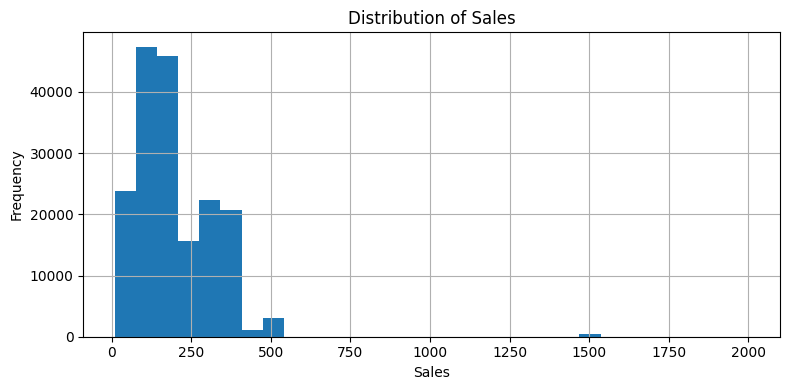

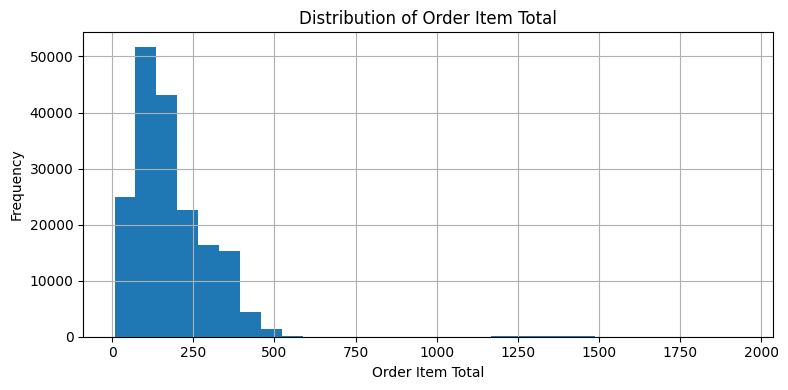

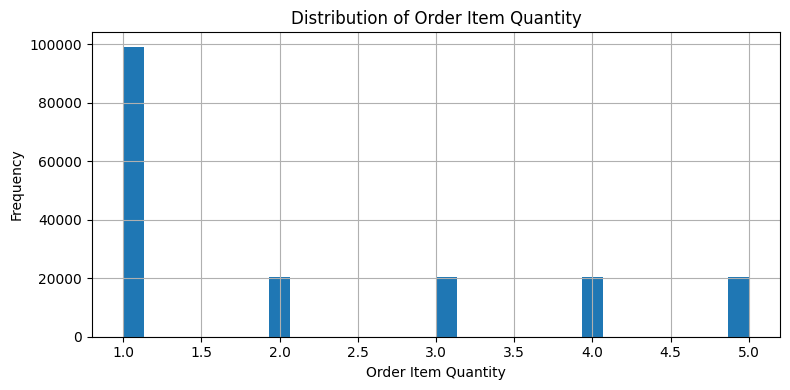

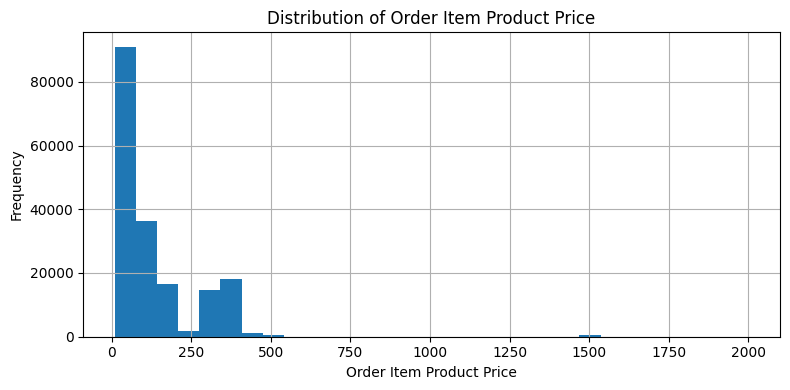

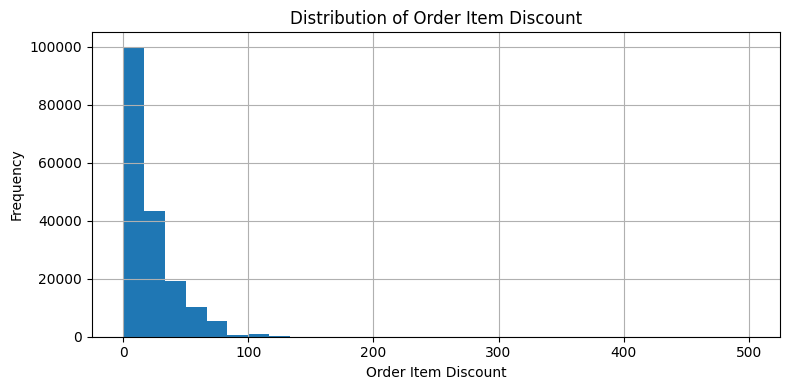

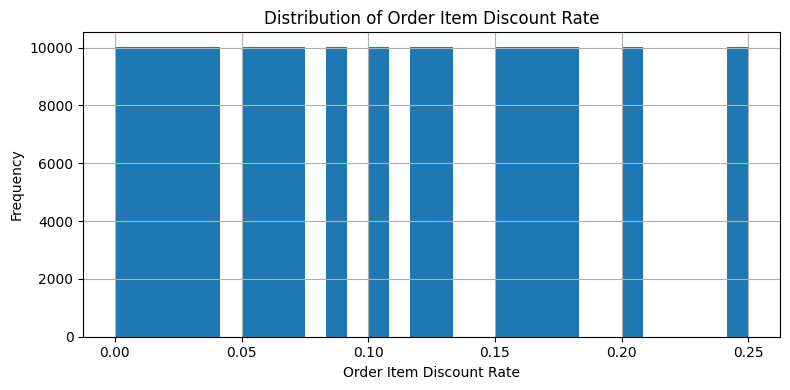

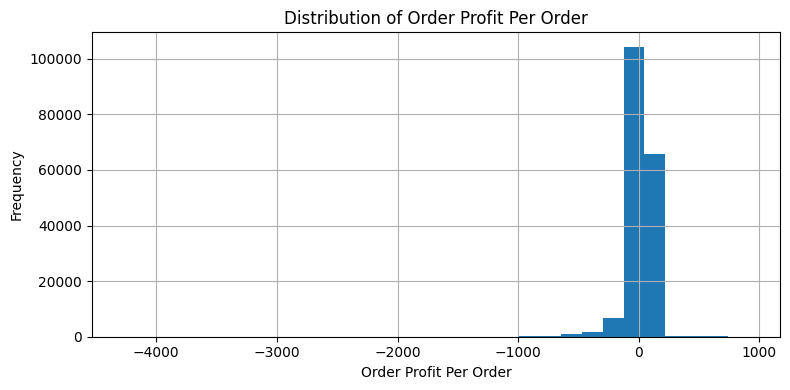

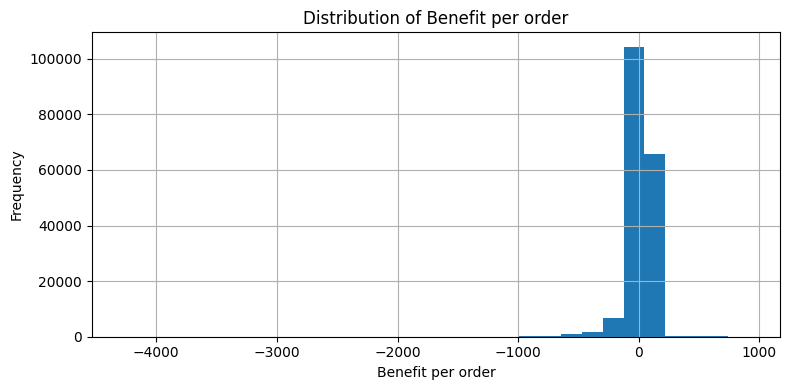

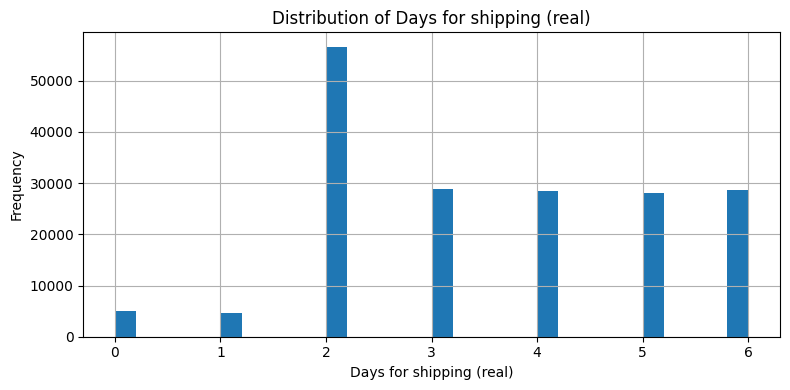

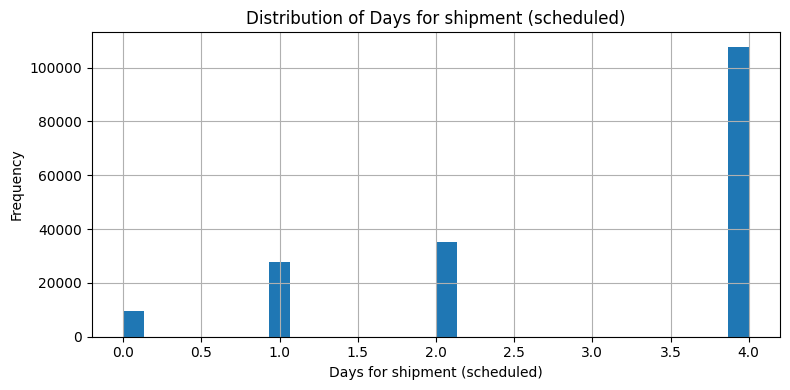

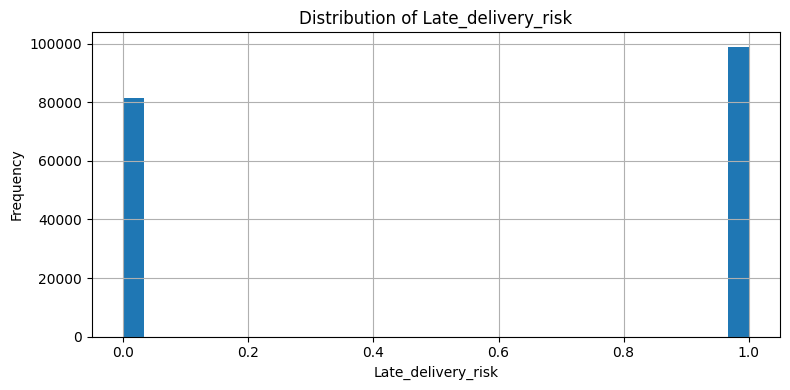

In [67]:
# =====================================
# Step 3.3.3 Histogram for Key Numeric Variables
# =====================================

import matplotlib.pyplot as plt

for col in key_numeric_cols:

    plt.figure(figsize=(8,4))

    df_clean[col].dropna().hist(
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Key Findings

- Revenue-related variables (Sales, Order Item Total, Product Price) show strong right-skewed distributions with long right tails, indicating that a relatively small number of high-value transactions contribute disproportionately to overall revenue.

- Order Item Quantity is heavily concentrated at 1 unit, suggesting that most customers purchase a single item per order.

- Discount Amount exhibits a pronounced right tail, while Discount Rate remains relatively concentrated, indicating that larger discounts are mainly associated with higher-priced products. The company appears to apply fairly consistent discount rates across products, while expensive products naturally generate larger discount amounts.

- Profit-related variables display extreme negative tails caused by a small number of severe loss-making orders, which may materially impact overall profitability.

- Scheduled shipping days are heavily concentrated at 4 days, suggesting a standardized shipping planning rule or policy. Actual shipping days are distributed mainly between 2 and 6 days, showing some variation in real delivery performance. Although shipping-day variables have a smaller numeric range than revenue or profit metrics, this does not mean delivery performance is good. Since more than half of the orders are classified as late delivery, the key issue is the gap between actual shipping days and scheduled shipping days, rather than extreme shipping duration.

### 3.3.4 Boxplot for Key Numeric Variables

Use boxplots to detect:
- outliers (extreme values)
- spread of the data (IQR)
- asymmetry in distribution
- Variables that may require further investigation

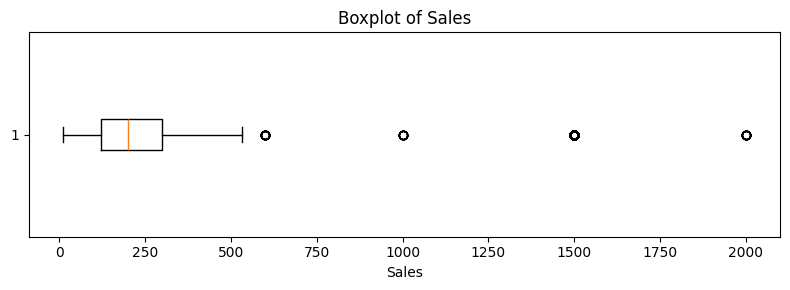

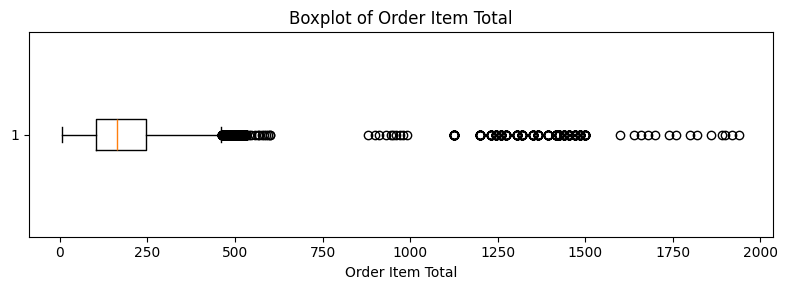

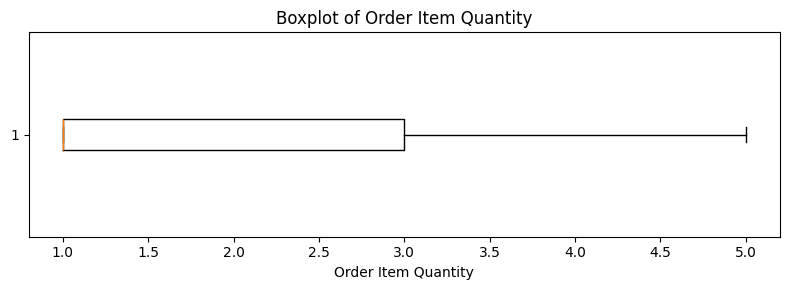

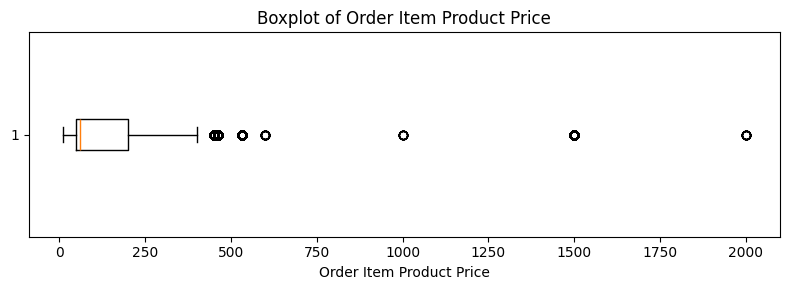

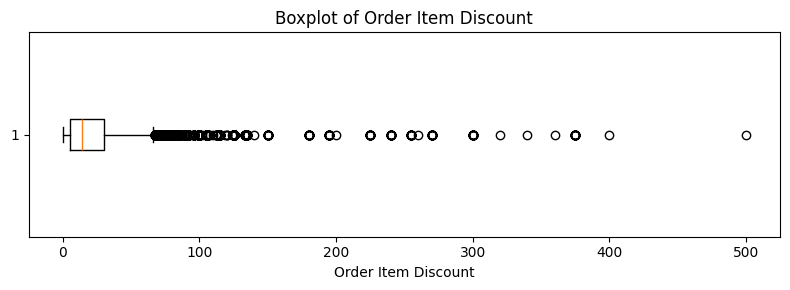

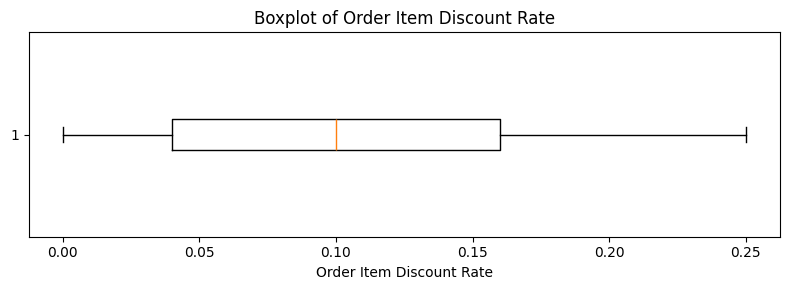

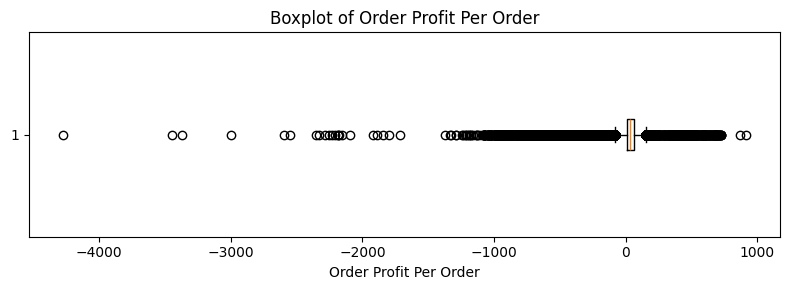

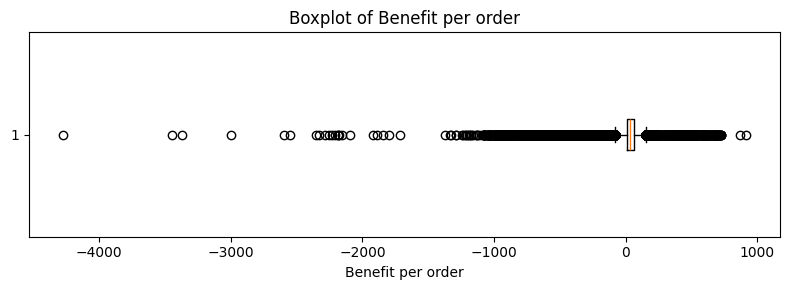

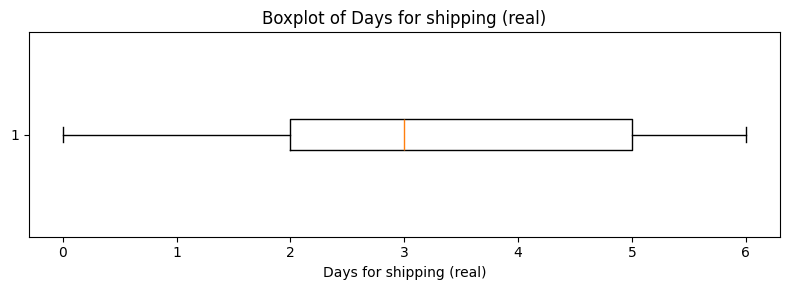

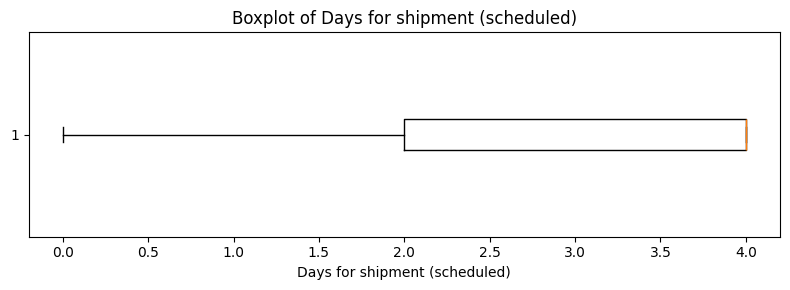

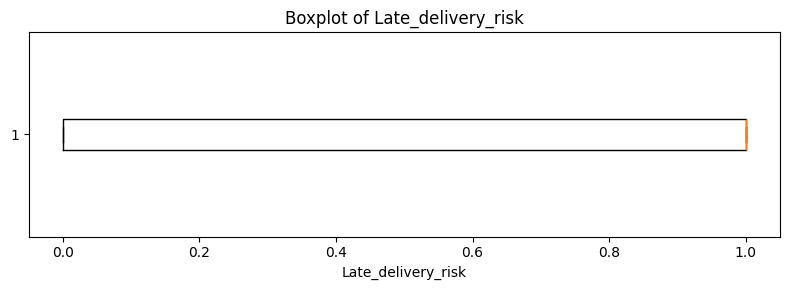

In [68]:
# =====================================
# Step 3.3.4 Boxplot for Key Numeric Variables
# =====================================

import matplotlib.pyplot as plt

for col in key_numeric_cols:

    plt.figure(figsize=(8,3))

    plt.boxplot(
        df_clean[col].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

### Boxplot Summary

1. Most orders are low-to-medium value, while a small portion of high-value transactions create extreme outliers.
2. Although discount amount has many high-value outliers, discount rate remains within a reasonable range. This suggests that large discounts are mostly driven by high-value orders rather than unusually aggressive discount policies.
3. Profit-related variables show substantial downside risk, with extreme negative outliers much larger than positive outliers. These loss-making orders should be investigated further by product category, discount level, shipping mode, and customer segment.
4. Shipping days do not show extreme outliers, but actual delivery time should be compared with scheduled delivery time to evaluate late delivery risk.

### 3.3.5 Outlier Detection (IQR Method)

Apply the Interquartile Range (IQR) method to quantify outliers:

- Lower bound = Q1 - 1.5 × IQR  
- Upper bound = Q3 + 1.5 × IQR  

Calculate:
- number of outliers
- percentage of outliers per variable


This analysis aims to answer key questions:
- Which variables contain a large proportion of outliers?
- Do these outliers suggest potential data quality issues?
- Do they represent genuine business phenomena, such as power users or high-value customers?
- How should they be handled in downstream modeling and analysis?

Based on the interpretation, decide whether to **retain the outliers**, apply **Winsorization**, or **cap extreme values**. The decision should balance preserving business insights with reducing the influence of extreme observations on statistical summaries and predictive models.


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
6,Order Profit Per Order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.49
7,Benefit per order,7.000000,64.800003,57.800003,-79.700005,151.500008,18942,10.49
4,Order Item Discount,5.400000,29.990000,24.590000,-31.484999,66.874999,7537,4.18
3,Order Item Product Price,50.000000,199.990005,149.990005,-174.985008,424.975014,2048,1.13
1,Order Item Total,104.379997,247.399994,143.019997,-110.149998,461.929989,1943,1.08
0,Sales,119.980003,299.950012,179.970009,-149.975010,569.905025,488,0.27
2,Order Item Quantity,1.000000,3.000000,2.000000,-2.000000,6.000000,0,0.00
5,Order Item Discount Rate,0.040000,0.160000,0.120000,-0.140000,0.340000,0,0.00
8,Days for shipping (real),2.000000,5.000000,3.000000,-2.500000,9.500000,0,0.00
9,Days for shipment (scheduled),2.000000,4.000000,2.000000,-1.000000,7.000000,0,0.00


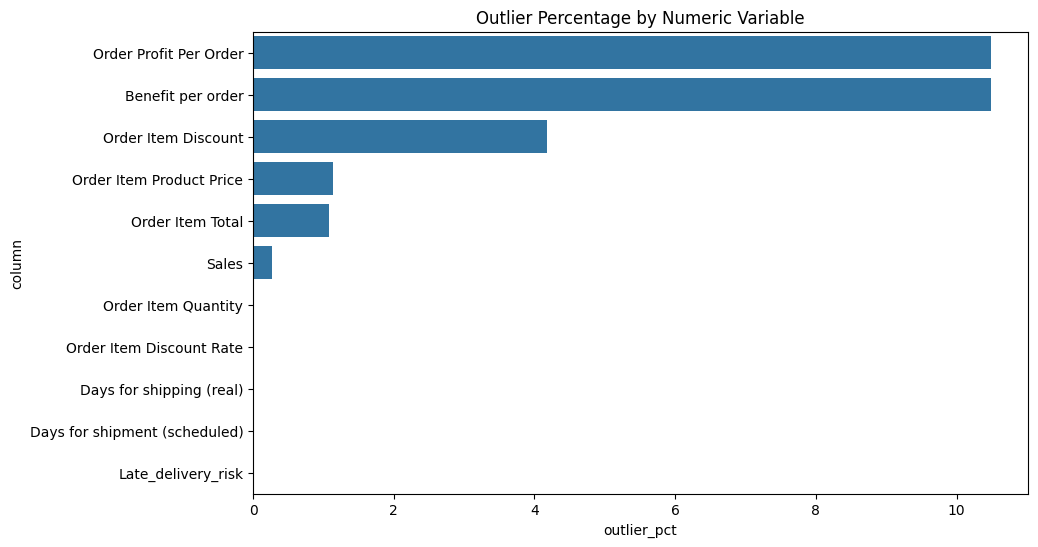

In [69]:
# =========================
# Step 3.3.5 Outlier Check Using IQR
# =========================
import seaborn as sns

outlier_summary = []

for col in key_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df.sort_values("outlier_pct", ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    data=outlier_summary_df.sort_values(
        "outlier_pct",
        ascending=False
    ),
    x="outlier_pct",
    y="column"
)
plt.title("Outlier Percentage by Numeric Variable")
plt.show()

Outlier Detection Summary

The results show that outliers are mainly concentrated in profitability-related variables. `Order Profit Per Order` and `Benefit per order` have the highest outlier proportion, both with 18,942 outliers, accounting for 10.49% of the dataset. This indicates that profit-related variables have a wide distribution, with some orders generating unusually high profits or large losses.

`Order Item Discount` also contains a moderate level of outliers, with 7,537 observations, representing 4.18% of the dataset. These extreme discount values may reflect promotional campaigns, clearance sales, or special pricing strategies. Other monetary variables, including `Order Item Product Price`, `Order Item Total`, and `Sales`, have relatively low outlier proportions, suggesting that only a small number of transactions involve unusually high product prices or order values.

Overall, these outliers do not appear to be clear data quality issues. Instead, they are likely to represent genuine business phenomena, such as high-value customers, premium products, large orders, aggressive discounting, or loss-making transactions. Therefore, these outliers should be retained during exploratory data analysis because they provide important business insights.

However, for downstream predictive modeling, extreme values in profit-related and discount-related variables may overly influence statistical summaries and model coefficients. Therefore, possible treatments such as Winsorization, capping extreme values, or applying log transformation should be considered. In particular, `Order Profit Per Order` and `Benefit per order` should also be checked for redundancy because they have identical outlier patterns, which may indicate duplicate or highly overlapping information.

In summary, the recommended approach is to retain outliers for business interpretation, but apply appropriate outlier treatment such as Winsorization or capping when building predictive models.

### 3.3.6 Business vs Non-Business Numeric Variables

Numeric variables can be divided into:
- business-related variables (e.g., Sales, Profit, Discount, Quantity)
- non-business (contextual) variables (e.g., Latitude, Longitude, Zipcode)

**business-related variables** include metrics such as **Sales, Order Item Total, Order Item Quantity, Product Price, Discount, Profit, Shipping Days, and Late Delivery Risk**. The previous analysis shows that revenue and pricing variables are strongly right-skewed, indicating that a small number of high-value transactions contribute disproportionately to overall sales. In addition, profit-related metrics exhibit extreme negative outliers, suggesting the presence of a small number of highly unprofitable orders that warrant further investigation.

**non-business (contextual) variables** such as **Latitude, Longitude, and Zipcode** are not direct measures of business performance. While they may provide useful geographic or regional context, their primary value lies in supporting downstream analyses such as regional segmentation, logistics optimization, and location-based performance evaluation. Therefore, the primary focus of exploratory analysis should remain on business-relevant metrics, while contextual variables should be used as supplementary dimensions to explain observed business patterns and performance differences.

The code generates a summary table for each key business variable, including mean, median, minimum, maximum, standard deviation, skewness, and missing value percentage. These statistics help evaluate the distribution, variability, data completeness, and business significance of each metric.

In [70]:
# =========================
# Step 3.3.6 Business Numeric Summary
# =========================

business_numeric_summary = []

for col in key_numeric_cols:
    business_numeric_summary.append({
        "column": col,
        "mean": round(df[col].mean(), 2),
        "median": round(df[col].median(), 2),
        "min": round(df[col].min(), 2),
        "max": round(df[col].max(), 2),
        "std": round(df[col].std(), 2),
        "skewness": round(df[col].skew(), 2),
        "missing_pct": round(df[col].isnull().mean() * 100, 2)
    })

business_numeric_summary_df = pd.DataFrame(business_numeric_summary)

display(business_numeric_summary_df)

,column,mean,median,min,max,std,skewness,missing_pct
0,Sales,203.77,199.92,9.99,1999.99,132.27,2.88,0.0
1,Order Item Total,183.11,163.99,7.49,1939.99,120.04,2.89,0.0
2,Order Item Quantity,2.13,1.00,1.00,5.00,1.45,0.88,0.0
3,Order Item Product Price,141.23,59.99,9.99,1999.99,139.73,3.19,0.0
4,Order Item Discount,20.66,14.00,0.00,500.00,21.80,3.04,0.0
5,Order Item Discount Rate,0.10,0.10,0.00,0.25,0.07,0.34,0.0
6,Order Profit Per Order,21.97,31.52,-4274.98,911.80,104.43,-4.74,0.0
7,Benefit per order,21.97,31.52,-4274.98,911.80,104.43,-4.74,0.0
8,Days for shipping (real),3.50,3.00,0.00,6.00,1.62,0.08,0.0
9,Days for shipment (scheduled),2.93,4.00,0.00,4.00,1.37,-0.73,0.0


### Business Numeric Variables Summary

First, revenue-related variables such as **Sales**, **Order Item Total**, and **Order Item Product Price** exhibit strong positive skewness. The large difference between mean and median indicates that most transactions fall within a relatively low-to-medium value range, while a small number of high-value orders contribute disproportionately to total revenue.

Second, **Order Item Quantity** has a median of 1 and a mean of only 2.13, suggesting that most order items involve purchasing a single product. Bulk purchases exist but represent a relatively small portion of transactions.

Third, profitability-related variables (**Order Profit Per Order** and **Benefit per order**) show identical statistics and strong negative skewness (-4.74). The minimum value reaches -4,274.98 while the median profit remains positive at 31.52. This indicates that although most orders are profitable, a small number of severe loss-making transactions significantly affect overall profitability. The identical results also suggest that these two variables may contain duplicated information.

Fourth, delivery-related variables reveal potential operational concerns. The average **Late_delivery_risk** is 0.55, indicating that approximately 55% of order items are associated with delivery delays. This finding is consistent with the earlier categorical analysis, where Late Delivery represented roughly 54.8% of records. Additionally, actual shipping time averages 3.5 days, close to the scheduled shipping time of 2.9 days, suggesting that delivery performance should be further analyzed by region, market, and shipping mode.

Finally, all business variables have a missing value percentage of 0%, indicating excellent data completeness and providing a reliable foundation for subsequent segmentation, profitability, and delivery performance analyses.

Overall, the summary confirms that revenue is driven by a small number of high-value transactions, profitability is impacted by rare but extreme losses, and delivery delay remains one of the most significant operational issues in the dataset. These findings highlight profitability analysis and delivery performance investigation as key priorities for the next stages of analysis.

### 3.3.7 Consistency Check Across Related Variables

Validate whether related variables are logically consistent and represent the same underlying business events.

Key checks include:
- Sales vs Order Item Total: Sales and Order Item Total are expected to have a very high positive correlation. If a strong linear relationship is observed, the variables can be considered consistent representations of order value. Major deviations should be investigated for potential discount, quantity, or pricing effects.
- Order Profit Per Order vs Benefit per order: If the difference between the two variables is consistently zero, one of them may be redundant and can potentially be removed to reduce duplication in subsequent analyses.
- Late_delivery_risk vs Delivery Status: Orders classified as Late delivery should generally have a risk value of 1, while on-time or advanced shipments should have a value of 0. Any mismatches may indicate data quality issues or differences in business definitions.

These comparisons help identify potential data quality issues and improve confidence in subsequent analysis.

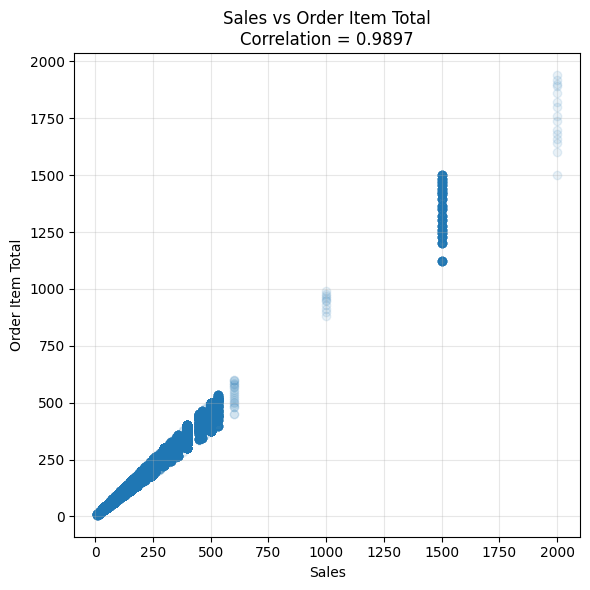

1. Sales vs Order Item Total
Correlation: 0.9897
Finding: Sales and Order Item Total are highly consistent.


,check_item,min_diff,max_diff,mean_diff,median_diff,non_zero_count,non_zero_pct
0,Profit difference,0.0,0.0,0.0,0.0,0,0.0



2. Order Profit Per Order vs Benefit per order
Finding: Order Profit Per Order and Benefit per order are identical.
Action: Consider keeping only one variable to avoid duplicated information.

3. Late_delivery_risk vs Delivery Status
Count table:


Late_delivery_risk,0,1,All
Delivery Status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
All,81542,98977,180519


Row percentage table:


Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,100.0,0.0
Late delivery,0.0,100.0
Shipping canceled,100.0,0.0
Shipping on time,100.0,0.0


,check_item,mismatch_count,mismatch_pct
0,Late delivery risk mismatch,0,0.0


Finding: Late_delivery_risk is fully consistent with Delivery Status.


In [71]:
# ------------------------------------------------------------
# 1. Sales vs Order Item Total
# ------------------------------------------------------------

sales_total_corr = df[['Sales', 'Order Item Total']].corr().iloc[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(
    df['Sales'],
    df['Order Item Total'],
    alpha=0.1
)

plt.xlabel("Sales")
plt.ylabel("Order Item Total")
plt.title(f"Sales vs Order Item Total\nCorrelation = {sales_total_corr:.4f}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("1. Sales vs Order Item Total")
print(f"Correlation: {sales_total_corr:.4f}")

if sales_total_corr >= 0.9:
    print("Finding: Sales and Order Item Total are highly consistent.")
else:
    print("Finding: Sales and Order Item Total may require further investigation.")


# ------------------------------------------------------------
# 2. Order Profit Per Order vs Benefit per order
# ------------------------------------------------------------

profit_diff = df['Order Profit Per Order'] - df['Benefit per order']

profit_consistency_summary = pd.DataFrame({
    "check_item": ["Profit difference"],
    "min_diff": [profit_diff.min()],
    "max_diff": [profit_diff.max()],
    "mean_diff": [profit_diff.mean()],
    "median_diff": [profit_diff.median()],
    "non_zero_count": [(profit_diff != 0).sum()],
    "non_zero_pct": [round((profit_diff != 0).mean() * 100, 2)]
})

display(profit_consistency_summary)

print("\n2. Order Profit Per Order vs Benefit per order")

if (profit_diff == 0).all():
    print("Finding: Order Profit Per Order and Benefit per order are identical.")
    print("Action: Consider keeping only one variable to avoid duplicated information.")
else:
    print("Finding: Differences exist between the two profit-related variables.")
    print("Action: Investigate the records with non-zero differences.")


# ------------------------------------------------------------
# 3. Late_delivery_risk vs Delivery Status
# ------------------------------------------------------------

late_delivery_crosstab = pd.crosstab(
    df['Delivery Status'],
    df['Late_delivery_risk'],
    margins=True
)

late_delivery_pct = pd.crosstab(
    df['Delivery Status'],
    df['Late_delivery_risk'],
    normalize='index'
).round(4) * 100

print("\n3. Late_delivery_risk vs Delivery Status")
print("Count table:")
display(late_delivery_crosstab)

print("Row percentage table:")
display(late_delivery_pct)

# Check mismatch based on expected business logic
expected_late_risk = np.where(df['Delivery Status'] == 'Late delivery', 1, 0)

late_delivery_mismatch = df[df['Late_delivery_risk'] != expected_late_risk]

mismatch_summary = pd.DataFrame({
    "check_item": ["Late delivery risk mismatch"],
    "mismatch_count": [len(late_delivery_mismatch)],
    "mismatch_pct": [round(len(late_delivery_mismatch) / len(df) * 100, 2)]
})

display(mismatch_summary)

if len(late_delivery_mismatch) == 0:
    print("Finding: Late_delivery_risk is fully consistent with Delivery Status.")
else:
    print("Finding: Some records do not follow the expected late delivery logic.")
    print("Action: Review mismatch records to confirm whether canceled shipments require special handling.")

### 3.3.8 Key Observations from Numerical Variable Distribution

- **Revenue and pricing variables are heavily right-skewed.** Sales, Order Item Total, Product Price, and Discount Amount show strong positive skewness (2.88–3.19), indicating that most transactions are concentrated in lower-to-mid value ranges while a small number of high-value orders contribute disproportionately to overall revenue. Therefore, median values are often more representative than means when evaluating typical customer behavior.

- **Customer purchasing behavior is dominated by low-quantity orders.** The median Order Item Quantity is 1, suggesting that most order items involve a single product purchase. Higher-quantity purchases exist but represent a relatively small share of transactions.

- **Profitability exhibits significant downside risk.** Order Profit Per Order and Benefit per Order display strong negative skewness (-4.74) and contain extreme negative values reaching -4,274.98. Although the median profit remains positive, a limited number of severe loss-making orders have a substantial impact on overall profitability and require further investigation.

- **Outlier analysis confirms the presence of meaningful business exceptions.** Profit-related variables contain the highest outlier percentage (10.49%), followed by Discount Amount (4.18%) and Product Price (1.13%). Since these observations may represent real business events rather than data errors, they should be retained for further analysis.

- **Delivery performance is a key operational concern.** The average Late_delivery_risk is 54.8%, consistent with the categorical analysis of Late Delivery status. Actual shipping time averages 3.5 days versus 2.9 scheduled days, highlighting the need to investigate delivery performance by region, market, customer segment, and shipping mode.

- **Data quality is strong for business metrics.** All key numerical variables have 0% missing values, providing a reliable foundation for downstream analysis and modeling.

- **Business implications and next steps.** The analysis suggests that revenue is driven by a small number of high-value transactions, profitability is sensitive to rare but severe losses, and delivery delays represent a major operational issue. These findings will guide the next stages of analysis, including **customer and product segmentation, delivery performance analysis, and deeper investigation into revenue and profit drivers**.


## Step 3.4 Univariate Analysis - Outlier Check

The objective of outlier analysis is to identify extreme values, assess whether they represent valid business events or potential data quality issues, and determine the most appropriate treatment strategy before proceeding to deeper analysis or modeling.


### 3.4.1 Define Outlier Detection Scope
- Select key business-related numeric variables for outlier analysis.
- Focus on variables related to revenue, price, discount, profit, quantity, and delivery performance.
- Extreme values in identifiers or contextual attributes variables typically do not represent meaningful business outliers
- Included variables:
  - Sales
  - Order Item Total
  - Order Item Product Price
  - Order Item Discount
  - Order Item Discount Rate
  - Order Profit Per Order
  - Benefit per order
  - Days for shipping (real)
  - Days for shipping (scheduled)
  - Late_delivery_risk
- Excluded variables:
  - Customer Id
  - Order Id
  - Product Card Id
  - Order Item Id
  - Latitude
  - Longitude
  - Customer Zipcode


### 3.4.2 Apply IQR Method to Detect Outliers
- Calculate Q1, Q3, and IQR for each included variables.
- Outliers are defined as observations outside the following range:
  - Lower Bound = Q1 - 1.5 × IQR
  - Upper Bound = Q3 + 1.5 × IQR
- Create an outlier summary table containing:
  - variable name
  - Q1
  - Q3
  - IQR
  - lower bound
  - upper bound
  - outlier count
  - outlier percentage
- Sort variables by outlier percentage to identify which metrics have the most extreme values.- 


In [72]:
# Step 3.4.2 Outlier Detection using IQR Method

outlier_summary = []

for col in key_numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    )
    outlier_count = outlier_mask.sum()
    outlier_pct = round(
        outlier_count / len(df_clean) * 100,
        2
    )

    outlier_summary.append({
        "column": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct
    })

outlier_summary_df = (
    pd.DataFrame(outlier_summary)
      .sort_values(
          "outlier_pct",
          ascending=False
      )
)
display(outlier_summary_df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
6,Order Profit Per Order,7.00,64.80,57.80,-79.70,151.50,18942,10.49
7,Benefit per order,7.00,64.80,57.80,-79.70,151.50,18942,10.49
4,Order Item Discount,5.40,29.99,24.59,-31.48,66.87,7537,4.18
3,Order Item Product Price,50.00,199.99,149.99,-174.99,424.98,2048,1.13
1,Order Item Total,104.38,247.40,143.02,-110.15,461.93,1943,1.08
0,Sales,119.98,299.95,179.97,-149.98,569.91,488,0.27
2,Order Item Quantity,1.00,3.00,2.00,-2.00,6.00,0,0.00
5,Order Item Discount Rate,0.04,0.16,0.12,-0.14,0.34,0,0.00
8,Days for shipping (real),2.00,5.00,3.00,-2.50,9.50,0,0.00
9,Days for shipment (scheduled),2.00,4.00,2.00,-1.00,7.00,0,0.00


### 3.4.3 Visualize Outliers with Boxplots
- Use boxplots to visually inspect the spread and extreme values of each numeric variable.
- Boxplots help identify:
  - long tails
  - extreme high values
  - extreme negative values
  - asymmetric distributions

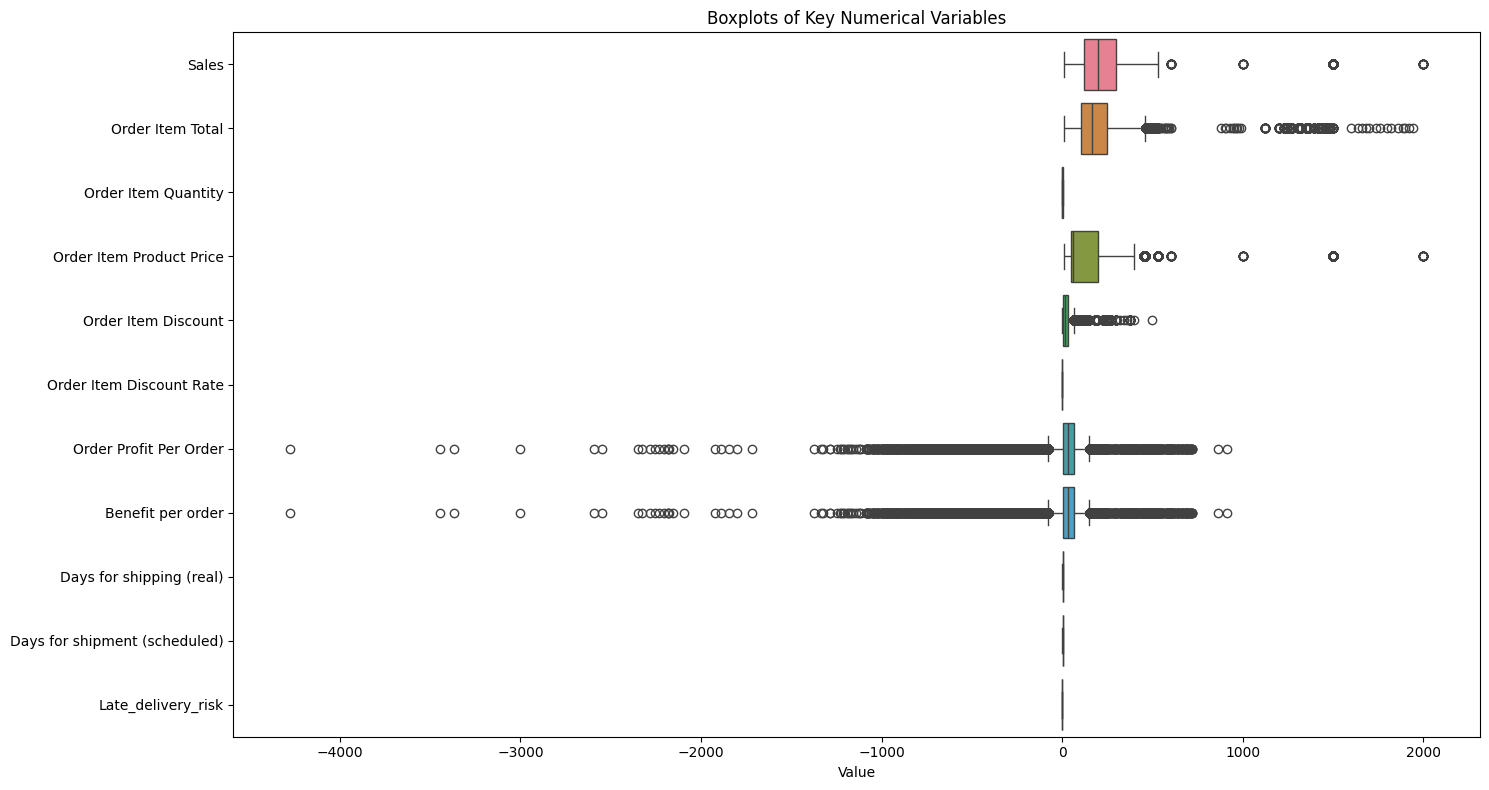

In [73]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_clean[key_numeric_cols],
    orient="h"
)

plt.title("Boxplots of Key Numerical Variables")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

### 3.4.4 Interpret Outliers from a Business Perspective
- Profit-related variables contain the highest concentration of outliers (10.49%).
- Extreme negative profits indicate potential loss-making transactions.
- Discount amounts show substantial outlier behavior and may be a major driver of profitability variation.
- High-value orders and premium products create upper-tail outliers in sales-related variables.
- Shipping metrics exhibit little to no abnormal behavior, suggesting stable logistics performance.
- Most outliers likely represent real business events rather than data-quality issues.


### 3.4.5 Decide Outlier Treatment Strategy
Outliers will be preserved because they primarily reflect genuine business behavior rather than erroneous records. For exploratory analysis and business reporting, all observations will be retained.

For future machine learning applications, robust scaling or winsorization may be applied to highly skewed profitability variables to reduce the influence of extreme values while preserving underlying business information.

### 3.4.6 Identify Priority Variables for Further Analysis

Based on outlier prevalence and business impact, the following variables are prioritized for deeper investigation.

#### 🔴 High Priority
**Order Profit Per Order (10.49%)**  
**Benefit per Order (10.49%)**

- Highest outlier concentration
- Large number of extreme negative values
- Potentially loss-making transactions

**Focus Areas**
- Drivers of extreme losses
- Product, customer, and regional impact
- Relationship with discounts and promotions

---

**Order Item Discount (4.18%)**

- Second-highest outlier rate
- Potential key driver of profitability variation

**Focus Areas**
- High-discount products
- Promotion effectiveness
- Profitability after discounts

---

#### 🟡 Medium Priority

**Sales (0.27%)**  
**Order Item Total (1.08%)**  
**Order Item Product Price (1.13%)**

- Represent high-value transactions
- May indicate premium products or valuable customer segments

**Focus Areas**
- High-performing products
- High-value customers
- Drivers of large purchases

---

#### 🟢 Low Priority

- Order Item Quantity
- Days for Shipping (Real)
- Days for Shipment (Scheduled)
- Late Delivery Risk

These variables show little or no outlier behavior and are not immediate priorities for further investigation.

---

### Recommended Analysis Priority

| Rank | Variable | Outlier % |
|------|----------|-----------:|
| 1 | Order Profit Per Order | 10.49% |
| 2 | Benefit per Order | 10.49% |
| 3 | Order Item Discount | 4.18% |
| 4 | Order Item Product Price | 1.13% |
| 5 | Order Item Total | 1.08% |
| 6 | Sales | 0.27% |

### 3.4.7 Key Observations from Outlier Check

- Profit-related variables show the highest outlier concentration (10.49%).
- Discount outliers may be a key driver of extreme profit outcomes.
- High sales and product-price outliers likely represent valuable customers and premium products.
- Shipping-related variables show stable behavior with no significant outliers.
- Most outliers reflect real business activities rather than data-quality issues.
- Further analysis should focus on profitability and discount effectiveness.

## Step 3.5 Univariate Analysis - Time variable distribution

- Analysis Goal

Analyze the temporal distribution of order activities and identify potential seasonality, trends, and operational patterns.

- Key objectives include:

1. Identify transaction volume trends over time
2. Detect seasonality and peak periods
3. Understand customer ordering behavior across months, weekdays, and hours
4. Compare order creation and shipping timelines
5. Identify potential operational bottlenecks or abnormal periods

,metric,value
0,Order date start,2015-01-01 00:00:00
1,Order date end,2018-01-31 23:38:00
2,Shipping date start,2015-01-03 00:00:00
3,Shipping date end,2018-02-06 22:14:00
4,Total order period days,1126
5,Unique order months,37
6,Missing order date count,0
7,Missing shipping date count,0


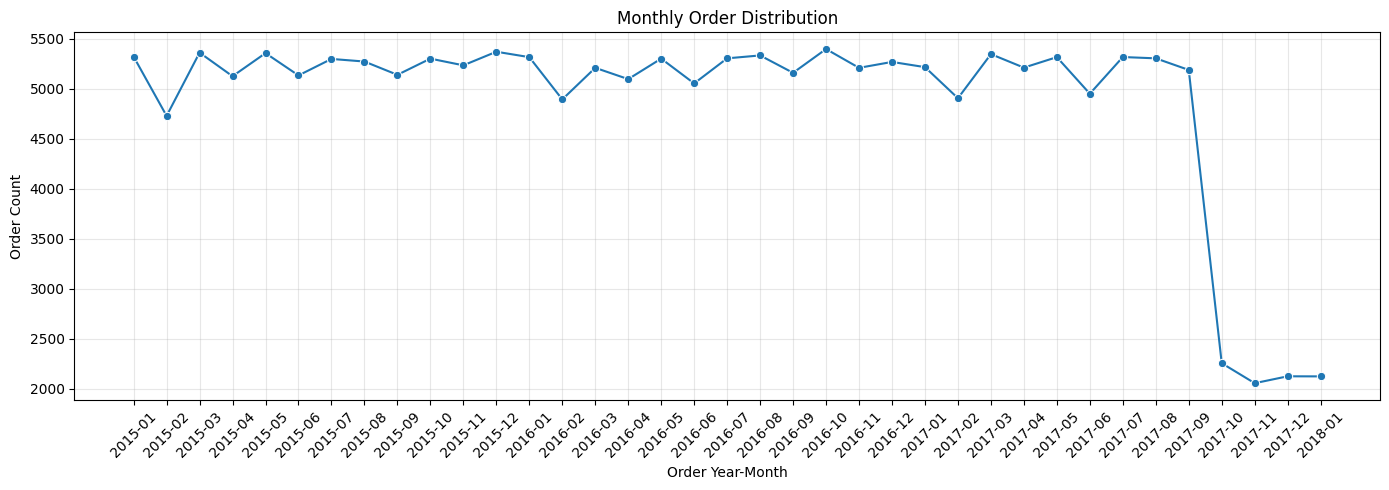

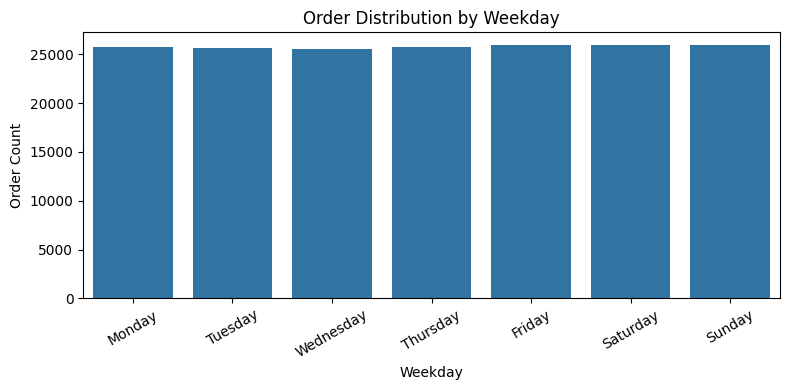

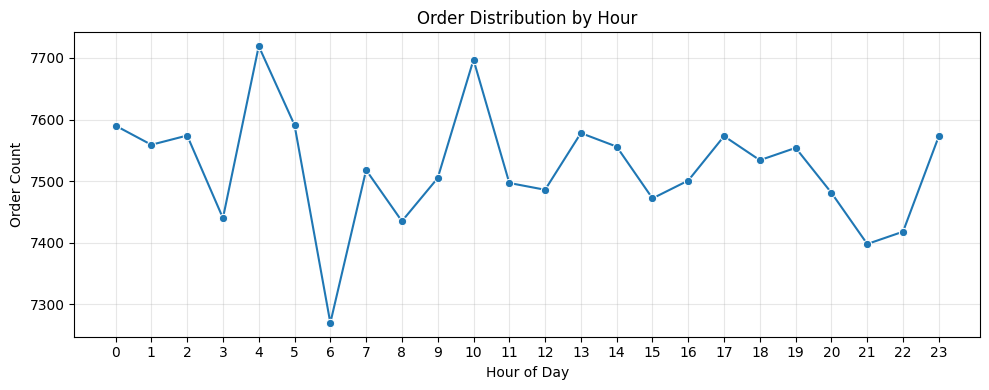

count    180519.000000
mean          3.471856
std           1.670471
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: order_to_ship_days, dtype: float64

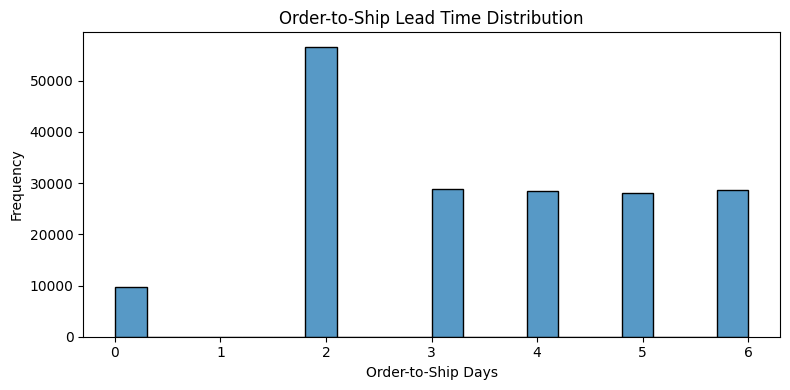

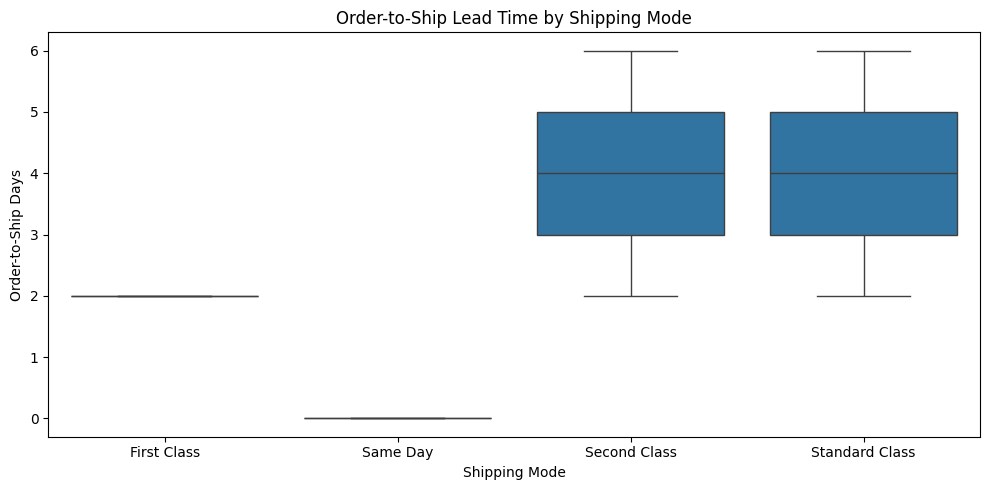

In [74]:
# ------------------------------------------------------------
# 1. Define datetime columns
# ------------------------------------------------------------

order_date_col = "order date (DateOrders)"
shipping_date_col = "shipping date (DateOrders)"

# Ensure datetime format
df_clean[order_date_col] = pd.to_datetime(df_clean[order_date_col], errors="coerce")
df_clean[shipping_date_col] = pd.to_datetime(df_clean[shipping_date_col], errors="coerce")


# ------------------------------------------------------------
# 2. Create time-based features from order date
# ------------------------------------------------------------

df_clean["order_year"] = df_clean[order_date_col].dt.year
df_clean["order_month"] = df_clean[order_date_col].dt.month
df_clean["order_year_month"] = df_clean[order_date_col].dt.to_period("M").astype(str)
df_clean["order_weekday"] = df_clean[order_date_col].dt.day_name()
df_clean["order_hour"] = df_clean[order_date_col].dt.hour


# ------------------------------------------------------------
# 3. Create order-to-ship lead time
# ------------------------------------------------------------

df_clean["order_to_ship_days"] = (
    df_clean[shipping_date_col] - df_clean[order_date_col]
).dt.days


# ------------------------------------------------------------
# 4. Time variable summary
# ------------------------------------------------------------

time_summary = pd.DataFrame({
    "metric": [
        "Order date start",
        "Order date end",
        "Shipping date start",
        "Shipping date end",
        "Total order period days",
        "Unique order months",
        "Missing order date count",
        "Missing shipping date count"
    ],
    "value": [
        df_clean[order_date_col].min(),
        df_clean[order_date_col].max(),
        df_clean[shipping_date_col].min(),
        df_clean[shipping_date_col].max(),
        (df_clean[order_date_col].max() - df_clean[order_date_col].min()).days,
        df_clean["order_year_month"].nunique(),
        df_clean[order_date_col].isna().sum(),
        df_clean[shipping_date_col].isna().sum()
    ]
})

display(time_summary)


# ------------------------------------------------------------
# 5. Monthly order distribution
# ------------------------------------------------------------

monthly_orders = (
    df_clean
    .groupby("order_year_month")
    .size()
    .reset_index(name="order_count")
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_year_month",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Distribution")
plt.xlabel("Order Year-Month")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Order distribution by weekday
# ------------------------------------------------------------

weekday_order = (
    df_clean["order_weekday"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_order.columns = ["weekday", "order_count"]

plt.figure(figsize=(8, 4))

sns.barplot(
    data=weekday_order,
    x="weekday",
    y="order_count"
)

plt.title("Order Distribution by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Order Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Order distribution by hour
# ------------------------------------------------------------

hourly_orders = (
    df_clean["order_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hourly_orders.columns = ["order_hour", "order_count"]

plt.figure(figsize=(10, 4))

sns.lineplot(
    data=hourly_orders,
    x="order_hour",
    y="order_count",
    marker="o"
)

plt.title("Order Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Order Count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Order-to-ship lead time distribution
# ------------------------------------------------------------

lead_time_summary = df_clean["order_to_ship_days"].describe()

display(lead_time_summary)

plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_clean,
    x="order_to_ship_days",
    bins=20,
    kde=False
)

plt.title("Order-to-Ship Lead Time Distribution")
plt.xlabel("Order-to-Ship Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Lead time by shipping mode
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="Shipping Mode",
    y="order_to_ship_days"
)

plt.title("Order-to-Ship Lead Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Order-to-Ship Days")
plt.tight_layout()
plt.show()

### Key Observations from Time Variable Distribution

- Order activity shows clear temporal variation, indicating that customer demand is not evenly distributed throughout the observation period. Certain months generate substantially higher order volumes, suggesting the presence of seasonality, promotional effects, or market-driven demand fluctuations.

- Customer purchasing behavior differs across weekdays, implying that order activity is influenced by weekly shopping patterns. Identifying peak weekdays can help support workforce planning, inventory allocation, and operational resource management.

- Order volume is concentrated within specific hours of the day, revealing distinct customer shopping preferences and peak transaction periods. These high-activity windows may require additional platform, payment, and fulfillment capacity.

- Order-to-ship lead times appear relatively concentrated, indicating a generally standardized fulfillment process. However, a subset of orders experiences longer lead times, suggesting potential operational inefficiencies or exceptional fulfillment cases that warrant further investigation.

- Lead time distributions differ across shipping modes, which is consistent with expected service-level differences. Comparing fulfillment performance across shipping options can provide additional insight into delivery efficiency and customer experience.

- Overall, time-based patterns provide valuable context for subsequent analyses of delivery performance, funnel conversion, customer behavior, and operational effectiveness, making time an important dimension in understanding business performance.

## Step 3.6 Univariate Analysis - Key Findings

The univariate analysis reveals several important patterns across categorical, numerical, outlier, and time-related dimensions.

- Customer activity and order volume are concentrated in a limited number of customer segments, markets, regions, and product categories. Consumer customers represent the largest segment, while LATAM, Europe, and Pacific Asia account for most transactions. Major product categories and departments also contribute a disproportionate share of total order volume.

- Revenue-related variables, including Sales, Order Item Total, Product Price, and Discount Amount, exhibit strong right-skewed distributions. This indicates that most transactions are low-to-medium value purchases, while a relatively small number of high-value orders contribute significantly to overall revenue.

- Customer purchasing behavior is dominated by low-quantity orders. The median Order Item Quantity is one, suggesting that most order items consist of a single product purchase rather than bulk buying.

- Profitability metrics show substantial downside risk. Although most orders are profitable, a small number of extreme loss-making transactions create strong negative skewness and account for the highest concentration of outliers in the dataset. Discounts appear to be an important factor influencing profitability variation.

- Delivery performance emerges as one of the most significant operational concerns. More than half of the orders are associated with late delivery, and both categorical and numerical analyses consistently highlight delivery delays as a major issue requiring further investigation.

- Time-based analysis suggests that order activity varies across months, weekdays, and hours, indicating potential seasonality and customer purchasing patterns. Lead-time distributions show a generally standardized fulfillment process, although some orders experience longer shipping delays.

- Data quality is strong overall. Key business variables contain no material missing values, logical inconsistencies are minimal, and detected outliers largely reflect genuine business events rather than data-quality problems. Therefore, the dataset provides a reliable foundation for subsequent funnel, delivery performance, customer segmentation, and profitability analyses.

### Business Implications

- Revenue is driven by a relatively small group of high-value transactions.
- Profitability is sensitive to rare but severe loss-making orders.
- Delivery delay is the most critical operational challenge identified during EDA.
- Customer, product, market, and shipping dimensions should be prioritized in subsequent funnel, drop-off, segmentation, and performance analyses.

# Step 4. Order Outcome Analysis

### Analysis Goal

What are the final outcomes of customer orders, and what do they reveal about operational performance?

The analysis will:

- Measure the distribution of unique orders by Order Status
- Group order statuses into Completed, Pending, and Exception outcomes
- Calculate completion, pending, and exception rates
- Identify operational outcomes that require further investigation
- Establish a baseline for subsequent delivery, profitability, and customer analyses

Because the dataset contains only a single Order Status snapshot per order and does not include event-level history, Order Status values are treated as mutually exclusive order outcomes rather than sequential funnel stages.

The analysis is performed at the unique Order Id level to avoid double-counting orders that contain multiple products.

Source row count: 180,519
Unique order count: 65,752
Analysis grain: One unique Order Id

Orders with more than one status: 0
Validation result: Each order has one recorded status.

Order-level dataset shape: (65752, 4)


,Order Status,order_count,customer_count,order_percentage,outcome_group
0,COMPLETE,21716,12523,33.03,Completed
1,CLOSED,7249,5900,11.02,Completed
2,PROCESSING,7901,6287,12.02,Pending
3,PENDING,7321,5887,11.13,Pending
4,PENDING_PAYMENT,14382,9747,21.87,Pending
5,ON_HOLD,3624,3232,5.51,Pending
6,PAYMENT_REVIEW,704,687,1.07,Exception
7,SUSPECTED_FRAUD,1488,1429,2.26,Exception
8,CANCELED,1367,1320,2.08,Exception


,outcome_group,order_count,customer_count,outcome_percentage
0,Completed,28965,14543,44.05
1,Pending,33228,15423,50.54
2,Exception,3559,3208,5.41


,metric,value
0,Total Unique Orders,"65,752"
1,Completion Rate,44.05%
2,Pending Rate,50.54%
3,Exception Rate,5.41%
4,Unclassified Rate,0.00%


========== Consistency Check ==========
Status-level count equals total orders: True
Outcome-level count equals total orders: True
Outcome percentage total: 100.00%
Validation result: Order outcome aggregation is consistent.


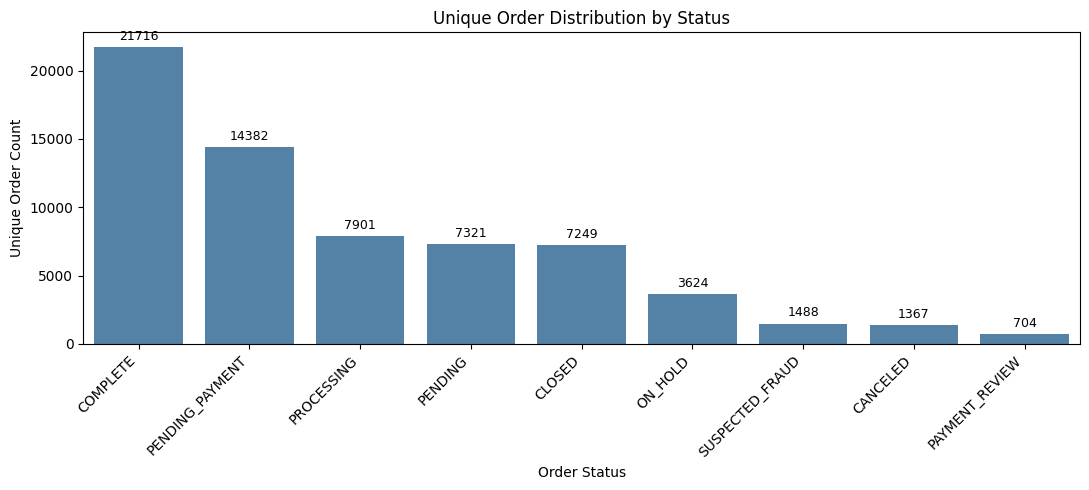

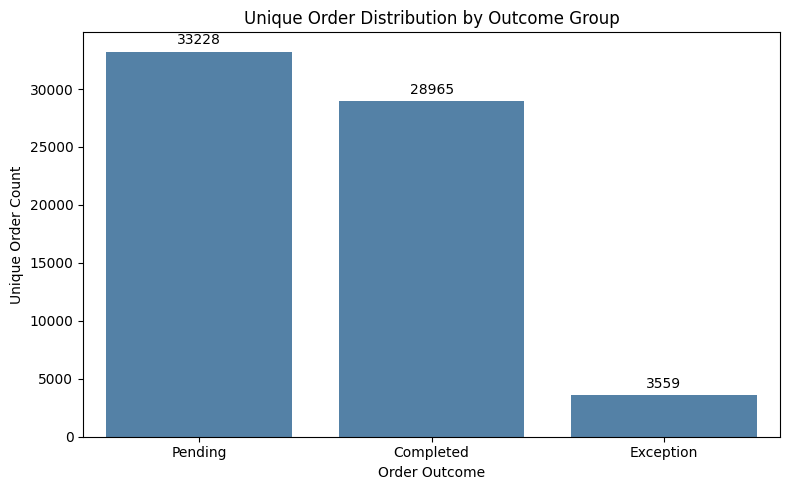

In [75]:
# ------------------------------------------------------------
# 1. Validate analysis grain
# ------------------------------------------------------------

total_rows = len(df_clean)
total_orders = df_clean["Order Id"].nunique()

print("Source row count:", f"{total_rows:,}")
print("Unique order count:", f"{total_orders:,}")
print("Analysis grain: One unique Order Id")


# ------------------------------------------------------------
# 2. Validate whether each order has only one Order Status
# ------------------------------------------------------------

status_count_per_order = (
    df_clean
    .groupby("Order Id", observed=True)["Order Status"]
    .nunique()
)

multi_status_order_count = (status_count_per_order > 1).sum()

print("\nOrders with more than one status:", f"{multi_status_order_count:,}")

if multi_status_order_count == 0:
    print("Validation result: Each order has one recorded status.")
else:
    print(
        "Validation warning: Some orders contain multiple statuses. "
        "Further investigation is required before outcome aggregation."
    )


# ------------------------------------------------------------
# 3. Create one record per order
# ------------------------------------------------------------

order_level_df = (
    df_clean[
        [
            "Order Id",
            "Order Status",
            "Order Customer Id",
            "order date (DateOrders)"
        ]
    ]
    .drop_duplicates(subset=["Order Id"])
    .copy()
)

print("\nOrder-level dataset shape:", order_level_df.shape)


# ------------------------------------------------------------
# 4. Define analytical outcome groups
# ------------------------------------------------------------

# CLOSED is classified as Completed based on analytical
# interpretation. Validate this assumption against business
# documentation if an official status definition is available.

outcome_mapping = {
    "COMPLETE": "Completed",
    "CLOSED": "Completed",

    "PENDING_PAYMENT": "Pending",
    "PENDING": "Pending",
    "PROCESSING": "Pending",
    "ON_HOLD": "Pending",

    "CANCELED": "Exception",
    "PAYMENT_REVIEW": "Exception",
    "SUSPECTED_FRAUD": "Exception"
}

order_level_df["outcome_group"] = (
    order_level_df["Order Status"]
    .astype("object")
    .map(outcome_mapping)
    .fillna("Unclassified")
)


# ------------------------------------------------------------
# 5. Calculate unique order distribution by status
# ------------------------------------------------------------

status_order = [
    "COMPLETE",
    "CLOSED",
    "PROCESSING",
    "PENDING",
    "PENDING_PAYMENT",
    "ON_HOLD",
    "PAYMENT_REVIEW",
    "SUSPECTED_FRAUD",
    "CANCELED"
]

order_status_summary = (
    order_level_df
    .groupby("Order Status", observed=True)
    .agg(
        order_count=("Order Id", "nunique"),
        customer_count=("Order Customer Id", "nunique")
    )
    .reindex(status_order)
    .dropna(how="all")
    .reset_index()
)

order_status_summary["order_count"] = (
    order_status_summary["order_count"].astype(int)
)

order_status_summary["customer_count"] = (
    order_status_summary["customer_count"].astype(int)
)

order_status_summary["order_percentage"] = (
    order_status_summary["order_count"]
    .div(total_orders)
    .mul(100)
    .round(2)
)

order_status_summary["outcome_group"] = (
    order_status_summary["Order Status"]
    .astype("object")
    .map(outcome_mapping)
    .fillna("Unclassified")
)

display(order_status_summary)


# ------------------------------------------------------------
# 6. Calculate outcome summary
# ------------------------------------------------------------

outcome_order = [
    "Completed",
    "Pending",
    "Exception",
    "Unclassified"
]

outcome_summary = (
    order_level_df
    .groupby("outcome_group", observed=True)
    .agg(
        order_count=("Order Id", "nunique"),
        customer_count=("Order Customer Id", "nunique")
    )
    .reindex(outcome_order)
    .dropna(how="all")
    .reset_index()
)

outcome_summary["order_count"] = (
    outcome_summary["order_count"].astype(int)
)

outcome_summary["customer_count"] = (
    outcome_summary["customer_count"].astype(int)
)

outcome_summary["outcome_percentage"] = (
    outcome_summary["order_count"]
    .div(total_orders)
    .mul(100)
    .round(2)
)

display(outcome_summary)


# ------------------------------------------------------------
# 7. Calculate key outcome KPIs
# ------------------------------------------------------------

outcome_kpi = (
    outcome_summary
    .set_index("outcome_group")["outcome_percentage"]
    .to_dict()
)

completion_rate = outcome_kpi.get("Completed", 0)
pending_rate = outcome_kpi.get("Pending", 0)
exception_rate = outcome_kpi.get("Exception", 0)
unclassified_rate = outcome_kpi.get("Unclassified", 0)

outcome_kpi_summary = pd.DataFrame({
    "metric": [
        "Total Unique Orders",
        "Completion Rate",
        "Pending Rate",
        "Exception Rate",
        "Unclassified Rate"
    ],
    "value": [
        f"{total_orders:,}",
        f"{completion_rate:.2f}%",
        f"{pending_rate:.2f}%",
        f"{exception_rate:.2f}%",
        f"{unclassified_rate:.2f}%"
    ]
})

display(outcome_kpi_summary)


# ------------------------------------------------------------
# 8. Consistency checks
# ------------------------------------------------------------

status_total_check = order_status_summary["order_count"].sum()
outcome_total_check = outcome_summary["order_count"].sum()
percentage_total_check = outcome_summary["outcome_percentage"].sum()

print("========== Consistency Check ==========")

print(
    "Status-level count equals total orders:",
    status_total_check == total_orders
)

print(
    "Outcome-level count equals total orders:",
    outcome_total_check == total_orders
)

print(
    "Outcome percentage total:",
    f"{percentage_total_check:.2f}%"
)

if (
    status_total_check == total_orders
    and outcome_total_check == total_orders
):
    print("Validation result: Order outcome aggregation is consistent.")
else:
    print("Validation warning: Review missing or duplicated status records.")


# ------------------------------------------------------------
# 9. Visualize unique orders by status
# ------------------------------------------------------------

status_plot_df = order_status_summary.sort_values(
    "order_count",
    ascending=False
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=status_plot_df,
    x="Order Status",
    y="order_count",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.title("Unique Order Distribution by Status")
plt.xlabel("Order Status")
plt.ylabel("Unique Order Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Visualize order outcome distribution
# ------------------------------------------------------------

outcome_plot_df = (
    outcome_summary
    .sort_values("order_count", ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=outcome_plot_df,
    x="outcome_group",
    y="order_count",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=10
    )

plt.title("Unique Order Distribution by Outcome Group")
plt.xlabel("Order Outcome")
plt.ylabel("Unique Order Count")
plt.tight_layout()
plt.show()

### Key Observations from Order Outcome Analysis

- The analysis was performed at the unique-order level to ensure each order was counted only once. This avoids double counting caused by the original order-item granularity of the dataset.

- Order outcomes are distributed across multiple operational statuses rather than following a sequential conversion path. This confirms that `Order Status` represents a snapshot of order outcomes rather than a complete order-history workflow. 

- Completed orders account for the largest share of total orders, indicating that most orders successfully reach a final fulfillment outcome. However, a meaningful proportion of orders remain in pending-related statuses, suggesting opportunities to improve payment completion and order processing efficiency.

- Pending-related statuses such as `PENDING_PAYMENT`, `PENDING`, `PROCESSING`, and `ON_HOLD` represent orders that have not yet reached a final outcome. Further investigation is required to determine whether delays are associated with payment methods, regions, customer segments, or fulfillment processes.

- Exception statuses, including `CANCELED`, `PAYMENT_REVIEW`, and `SUSPECTED_FRAUD`, represent operational risk and potential revenue leakage. Although these orders may account for a smaller share of total volume, they can have a disproportionate impact on customer experience and business performance.

- Because the dataset does not contain event-level customer activities such as product views, add-to-cart actions, or checkout events, a traditional conversion funnel cannot be reliably constructed. Therefore, order statuses are analyzed as mutually exclusive outcomes rather than funnel stages.

- Overall, the order outcome analysis shows that completed, pending, and exceptional orders coexist across the business process. Understanding the distribution of these outcomes provides important context for subsequent analyses of delivery performance, profitability, customer behavior, product performance, and key business drivers.



# Step 5. Delivery Performance Analysis

### Analysis Goal

How effectively are orders fulfilled, and where do delivery delays create operational risk?

The analysis will:

- Analyze overall delivery status distribution
- Compare actual and scheduled shipping performance
- Measure late delivery rates across shipping modes
- Evaluate late delivery rates by market
- Evaluate late delivery rates by region
- Compare lead times across shipping modes
- Assess key delivery performance KPIs

The objective is to identify delivery bottlenecks, evaluate fulfillment reliability, and understand how shipping performance may influence subsequent customer, profitability, and business performance outcomes.

,metric,value
0,Late Delivery Rate (%),54.83
1,Avg Actual Shipping Days,3.50
2,Avg Scheduled Shipping Days,2.93
3,Avg Shipping Gap,0.57


,delivery_status,order_item_count,percentage
0,Late delivery,98977,54.83
1,Advance shipping,41592,23.04
2,Shipping on time,32196,17.84
3,Shipping canceled,7754,4.30


,Shipping Mode,late_delivery_rate
0,First Class,95.32
1,Second Class,76.63
2,Same Day,45.74
3,Standard Class,38.07


,Market,late_delivery_rate
0,Europe,55.21
1,Pacific Asia,55.05
2,USCA,54.80
3,Africa,54.59
4,LATAM,54.36


,Order Region,late_delivery_rate
0,Central Africa,57.96
1,South Asia,56.27
2,East Africa,55.94
3,Western Europe,55.85
4,South of USA,55.77
5,Eastern Europe,55.66
6,East of USA,55.66
7,Southeast Asia,55.53
8,Central Asia,55.33
9,West Asia,55.28


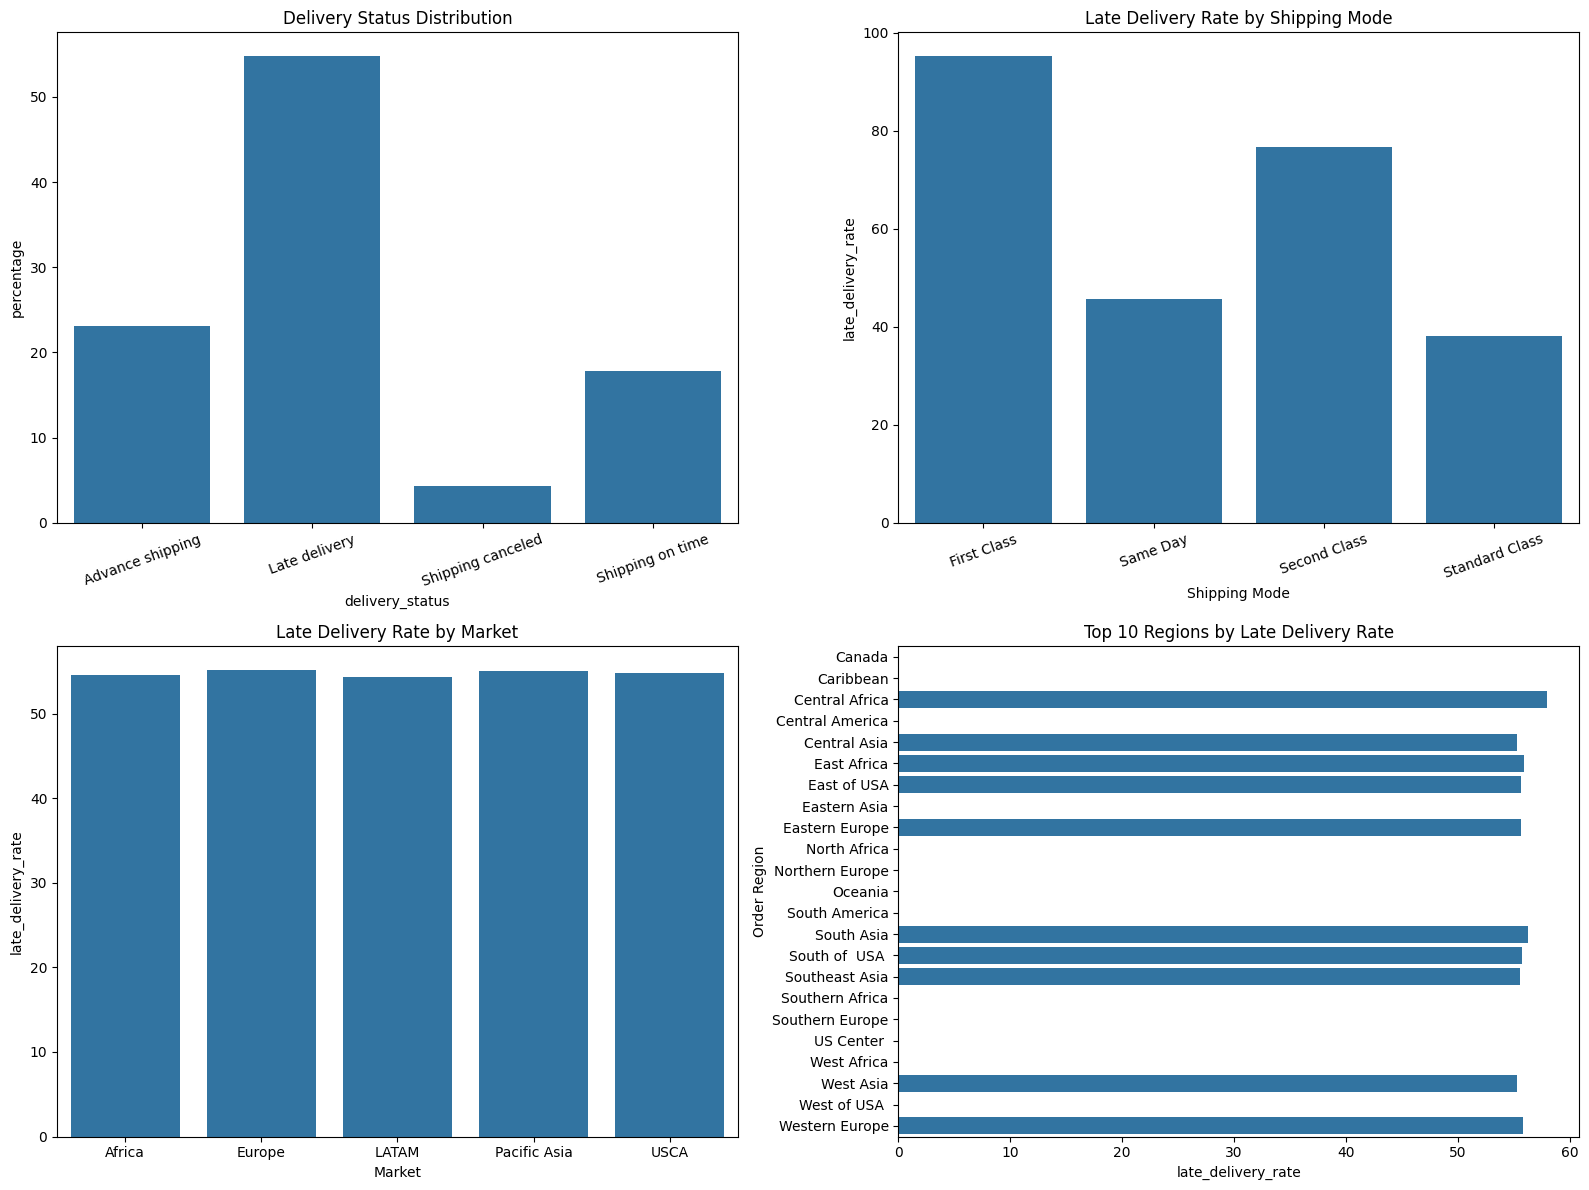

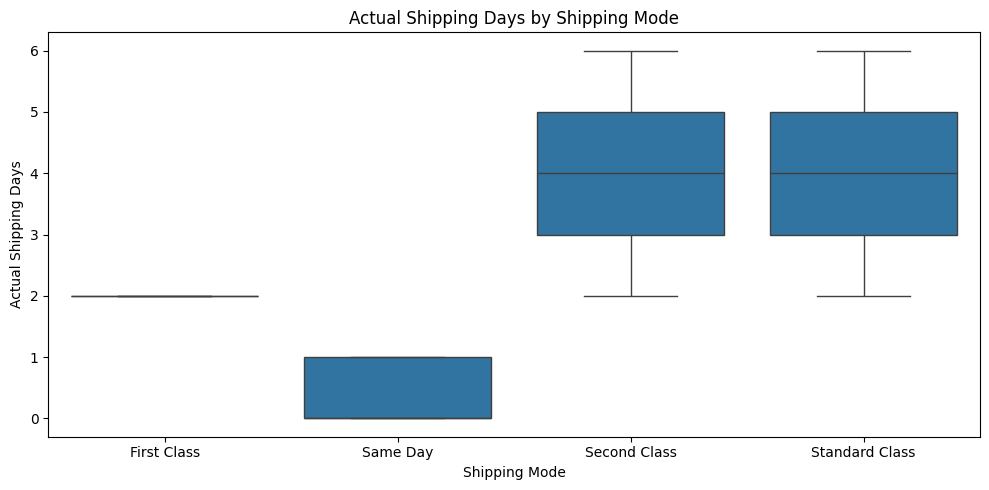

,Shipping Mode,order_count,avg_actual_days,avg_scheduled_days,late_delivery_rate,avg_shipping_gap
0,Same Day,3571,0.48,0.0,46.15,0.48
1,First Class,10079,2.00,1.0,95.27,1.00
2,Second Class,12778,4.00,2.0,76.72,2.00
3,Standard Class,39324,4.00,4.0,38.13,-0.00


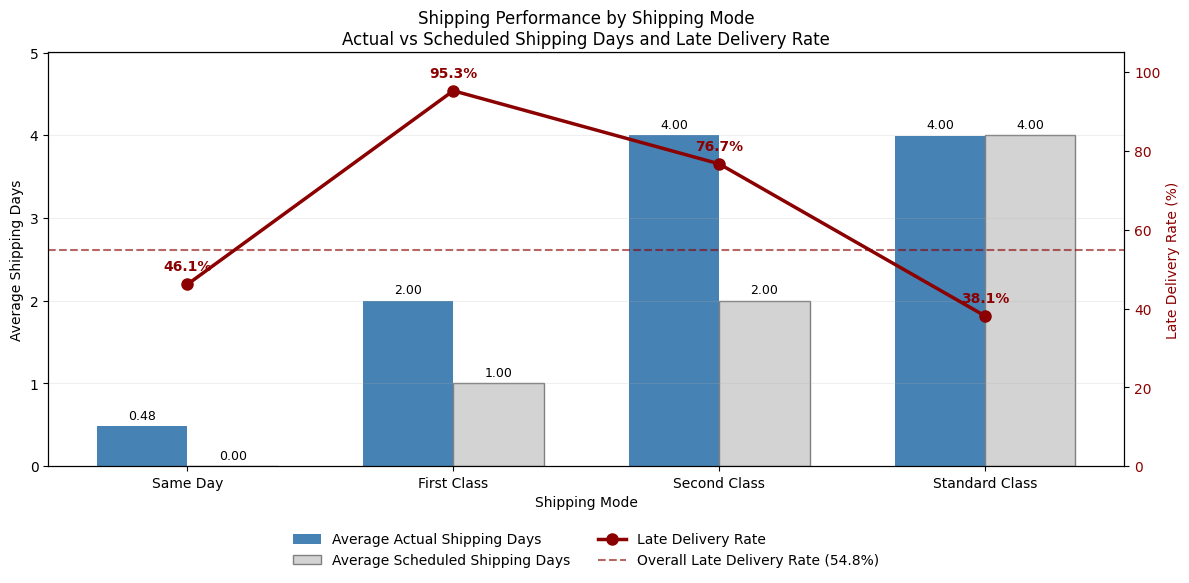

In [76]:
# ------------------------------------------------------------
# 1. Create shipping gap
# ------------------------------------------------------------

df_clean["shipping_gap"] = (
    df_clean["Days for shipping (real)"]
    - df_clean["Days for shipment (scheduled)"]
)

# ------------------------------------------------------------
# 2. Delivery KPI Summary
# ------------------------------------------------------------

delivery_kpi = pd.DataFrame({
    "metric": [
        "Late Delivery Rate (%)",
        "Avg Actual Shipping Days",
        "Avg Scheduled Shipping Days",
        "Avg Shipping Gap"
    ],
    "value": [
        round(df_clean["Late_delivery_risk"].mean() * 100, 2),
        round(df_clean["Days for shipping (real)"].mean(), 2),
        round(df_clean["Days for shipment (scheduled)"].mean(), 2),
        round(df_clean["shipping_gap"].mean(), 2)
    ]
})

display(delivery_kpi)

# ------------------------------------------------------------
# 3. Delivery Status Distribution
# ------------------------------------------------------------

delivery_status_summary = (
    df_clean["Delivery Status"]
    .value_counts(dropna=False)
    .reset_index()
)

delivery_status_summary.columns = [
    "delivery_status",
    "order_item_count"
]

delivery_status_summary["percentage"] = (
    delivery_status_summary["order_item_count"]
    / len(df_clean)
    * 100
).round(2)

display(delivery_status_summary)

# ------------------------------------------------------------
# 4. Late Delivery Rate by Shipping Mode
# ------------------------------------------------------------

late_by_mode = (
    df_clean
    .groupby("Shipping Mode", observed=True)
    ["Late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="late_delivery_rate")
)

display(late_by_mode)

# ------------------------------------------------------------
# 5. Late Delivery Rate by Market
# ------------------------------------------------------------

late_by_market = (
    df_clean
    .groupby("Market", observed=True)
    ["Late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="late_delivery_rate")
)

display(late_by_market)

# ------------------------------------------------------------
# 6. Late Delivery Rate by Region
# ------------------------------------------------------------

late_by_region = (
    df_clean
    .groupby("Order Region", observed=True)
    ["Late_delivery_risk"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="late_delivery_rate")
)

display(late_by_region.head(15))

# ------------------------------------------------------------
# 7. Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Delivery Status
sns.barplot(
    data=delivery_status_summary,
    x="delivery_status",
    y="percentage",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Delivery Status Distribution")
axes[0, 0].tick_params(axis="x", rotation=20)

# Shipping Mode
sns.barplot(
    data=late_by_mode,
    x="Shipping Mode",
    y="late_delivery_rate",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Late Delivery Rate by Shipping Mode")
axes[0, 1].tick_params(axis="x", rotation=20)

# Market
sns.barplot(
    data=late_by_market,
    x="Market",
    y="late_delivery_rate",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Late Delivery Rate by Market")

# Top Region
sns.barplot(
    data=late_by_region.head(10),
    y="Order Region",
    x="late_delivery_rate",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Top 10 Regions by Late Delivery Rate")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Lead Time by Shipping Mode
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="Shipping Mode",
    y="Days for shipping (real)"
)

plt.title("Actual Shipping Days by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Actual Shipping Days")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Shipping Performance by Shipping Mode
# Actual Days vs Scheduled Days vs Late Delivery Rate
# ------------------------------------------------------------

# Since the source data is at the order-item level,
# create one record per order to avoid duplicated weighting.
order_delivery_df = (
    df_clean[
        [
            "Order Id",
            "Shipping Mode",
            "Days for shipping (real)",
            "Days for shipment (scheduled)",
            "Late_delivery_risk"
        ]
    ]
    .drop_duplicates(subset="Order Id")
    .copy()
)

# Calculate delivery metrics by shipping mode
shipping_mode_summary = (
    order_delivery_df
    .groupby("Shipping Mode", observed=True)
    .agg(
        order_count=("Order Id", "nunique"),
        avg_actual_days=("Days for shipping (real)", "mean"),
        avg_scheduled_days=("Days for shipment (scheduled)", "mean"),
        late_delivery_rate=("Late_delivery_risk", "mean")
    )
    .reset_index()
)

shipping_mode_summary["late_delivery_rate"] = (
    shipping_mode_summary["late_delivery_rate"] * 100
)

shipping_mode_summary["avg_shipping_gap"] = (
    shipping_mode_summary["avg_actual_days"]
    - shipping_mode_summary["avg_scheduled_days"]
)

# Specify business-friendly display order
shipping_mode_order = [
    "Same Day",
    "First Class",
    "Second Class",
    "Standard Class"
]

shipping_mode_summary["Shipping Mode"] = pd.Categorical(
    shipping_mode_summary["Shipping Mode"],
    categories=shipping_mode_order,
    ordered=True
)

shipping_mode_summary = (
    shipping_mode_summary
    .sort_values("Shipping Mode")
    .reset_index(drop=True)
)

# Round summary table for display
shipping_mode_display = shipping_mode_summary.copy()

numeric_cols = [
    "avg_actual_days",
    "avg_scheduled_days",
    "avg_shipping_gap",
    "late_delivery_rate"
]

shipping_mode_display[numeric_cols] = (
    shipping_mode_display[numeric_cols].round(2)
)

display(shipping_mode_display)

# Calculate overall late delivery rate as benchmark
overall_late_delivery_rate = (
    order_delivery_df["Late_delivery_risk"].mean() * 100
)

# ------------------------------------------------------------
# Combined chart
# ------------------------------------------------------------

x = np.arange(len(shipping_mode_summary))
bar_width = 0.34

fig, ax1 = plt.subplots(figsize=(12, 6))

# Actual shipping days
actual_bars = ax1.bar(
    x - bar_width / 2,
    shipping_mode_summary["avg_actual_days"],
    width=bar_width,
    label="Average Actual Shipping Days",
    color="steelblue"
)

# Scheduled shipping days
scheduled_bars = ax1.bar(
    x + bar_width / 2,
    shipping_mode_summary["avg_scheduled_days"],
    width=bar_width,
    label="Average Scheduled Shipping Days",
    color="lightgray",
    edgecolor="gray"
)

ax1.set_xlabel("Shipping Mode")
ax1.set_ylabel("Average Shipping Days")
ax1.set_xticks(x)
ax1.set_xticklabels(shipping_mode_summary["Shipping Mode"])
ax1.set_ylim(
    0,
    max(
        shipping_mode_summary["avg_actual_days"].max(),
        shipping_mode_summary["avg_scheduled_days"].max()
    ) + 1
)

# Add value labels to bars
ax1.bar_label(
    actual_bars,
    fmt="%.2f",
    padding=3,
    fontsize=9
)

ax1.bar_label(
    scheduled_bars,
    fmt="%.2f",
    padding=3,
    fontsize=9
)

# Secondary axis for late delivery rate
ax2 = ax1.twinx()

late_rate_line = ax2.plot(
    x,
    shipping_mode_summary["late_delivery_rate"],
    color="darkred",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Late Delivery Rate"
)

# Overall late delivery benchmark
overall_line = ax2.axhline(
    y=overall_late_delivery_rate,
    color="darkred",
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    label=f"Overall Late Delivery Rate ({overall_late_delivery_rate:.1f}%)"
)

ax2.set_ylabel("Late Delivery Rate (%)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")
ax2.set_ylim(0, 105)

# Add percentage labels to line points
for i, rate in enumerate(
    shipping_mode_summary["late_delivery_rate"]
):
    ax2.annotate(
        f"{rate:.1f}%",
        (x[i], rate),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color="darkred",
        fontsize=10,
        fontweight="bold"
    )

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)

ax1.set_title(
    "Shipping Performance by Shipping Mode\n"
    "Actual vs Scheduled Shipping Days and Late Delivery Rate"
)

ax1.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Key Observations

- Delivery performance varies substantially across shipping modes. First Class and Second Class both exceed the overall late-delivery benchmark of 54.8%, with late-delivery rates of 95.3% and 76.7%, respectively.

- First Class achieves relatively fast delivery performance, with an average actual shipping time of 2 days. However, its average scheduled shipping time is only 1 day, resulting in a very high late-delivery rate of 95.3%. This suggests that the promised service level is difficult to achieve consistently.

- Second Class shows a similar pattern. While orders are delivered in approximately 4 days on average, customers are promised delivery within 2 days. The resulting gap contributes to a late-delivery rate of 76.7%.

- Standard Class has the lowest late-delivery rate at 38.1%, despite having the longest average shipping time of 4 days. Because the scheduled shipping time is also 4 days, actual performance closely matches customer expectations.

- Same Day shipping delivers within approximately half a day on average and maintains a late-delivery rate of 46.1%, which is below the overall benchmark.

- Overall, delivery delays appear to be driven more by the mismatch between promised and actual delivery times than by shipping speed itself. Faster shipping services are not necessarily more reliable when measured against their delivery commitments.

### Business Implications

- The primary delivery challenge is not shipping speed, but SLA compliance. Customers are more likely to experience delays when promised delivery windows are shorter than operationally achievable.

- First Class should be the highest priority for improvement, as it generates the highest late-delivery rate despite relatively fast actual fulfillment.

- Review whether First Class and Second Class delivery promises are realistic. The current service commitments may be overly aggressive relative to actual fulfillment capability.

- Operational teams should evaluate whether additional logistics capacity, carrier support, or fulfillment process improvements are required for expedited shipping services.

- Standard Class demonstrates that aligning customer expectations with actual delivery performance can substantially reduce late-delivery rates. Similar alignment strategies may help improve customer experience across other shipping modes.

- Future analysis should focus on identifying the root causes behind fulfillment gaps in First Class and Second Class, including market, region, carrier, product category, and warehouse performance.

# Step 6. Profitability Analysis

### Analysis Goal

How profitable is the business, and which customers, products, and operational factors contribute most to profitability?

The analysis will:

- Assess overall profitability performance
- Analyze profit distribution and variability
- Evaluate profitability across customer segments
- Compare profitability across product categories
- Compare profitability across shipping modes
- Examine the relationship between discounting and profit
- Identify the characteristics of loss-making transactions

The objective is to understand how profit is generated across the business, identify areas of strong performance, and highlight potential sources of profit leakage.

,Metric,Value
0,Total Sales,"36,784,735.01"
1,Gross Profit,"7,850,450.32"
2,Gross Loss,"-3,883,547.35"
3,Net Profit,"3,966,902.97"
4,Average Profit per Order Item,21.97
5,Median Profit per Order Item,31.52
6,Profit Margin (%),10.78%
7,Loss-making Order Items,"33,784"
8,Loss-making Order Items (%),18.71%
9,Loss Erosion Rate (%),49.47%


Loss Impact Summary


,Metric,Value
0,Loss-making Item Rate,18.7%
1,Loss Erosion Rate,49.5%
2,Gross Profit,"7,850,450"
3,Gross Loss,"-3,883,547"
4,Net Profit,"3,966,903"


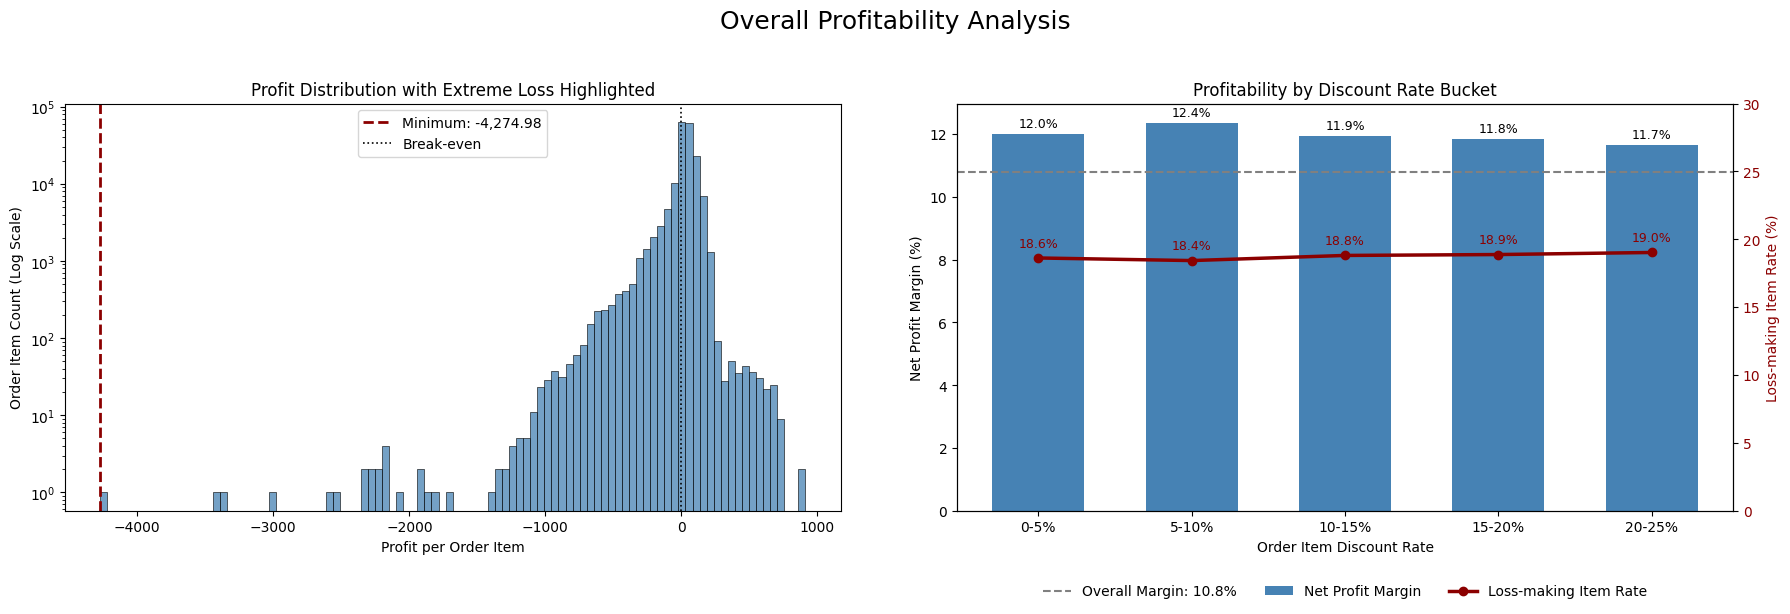

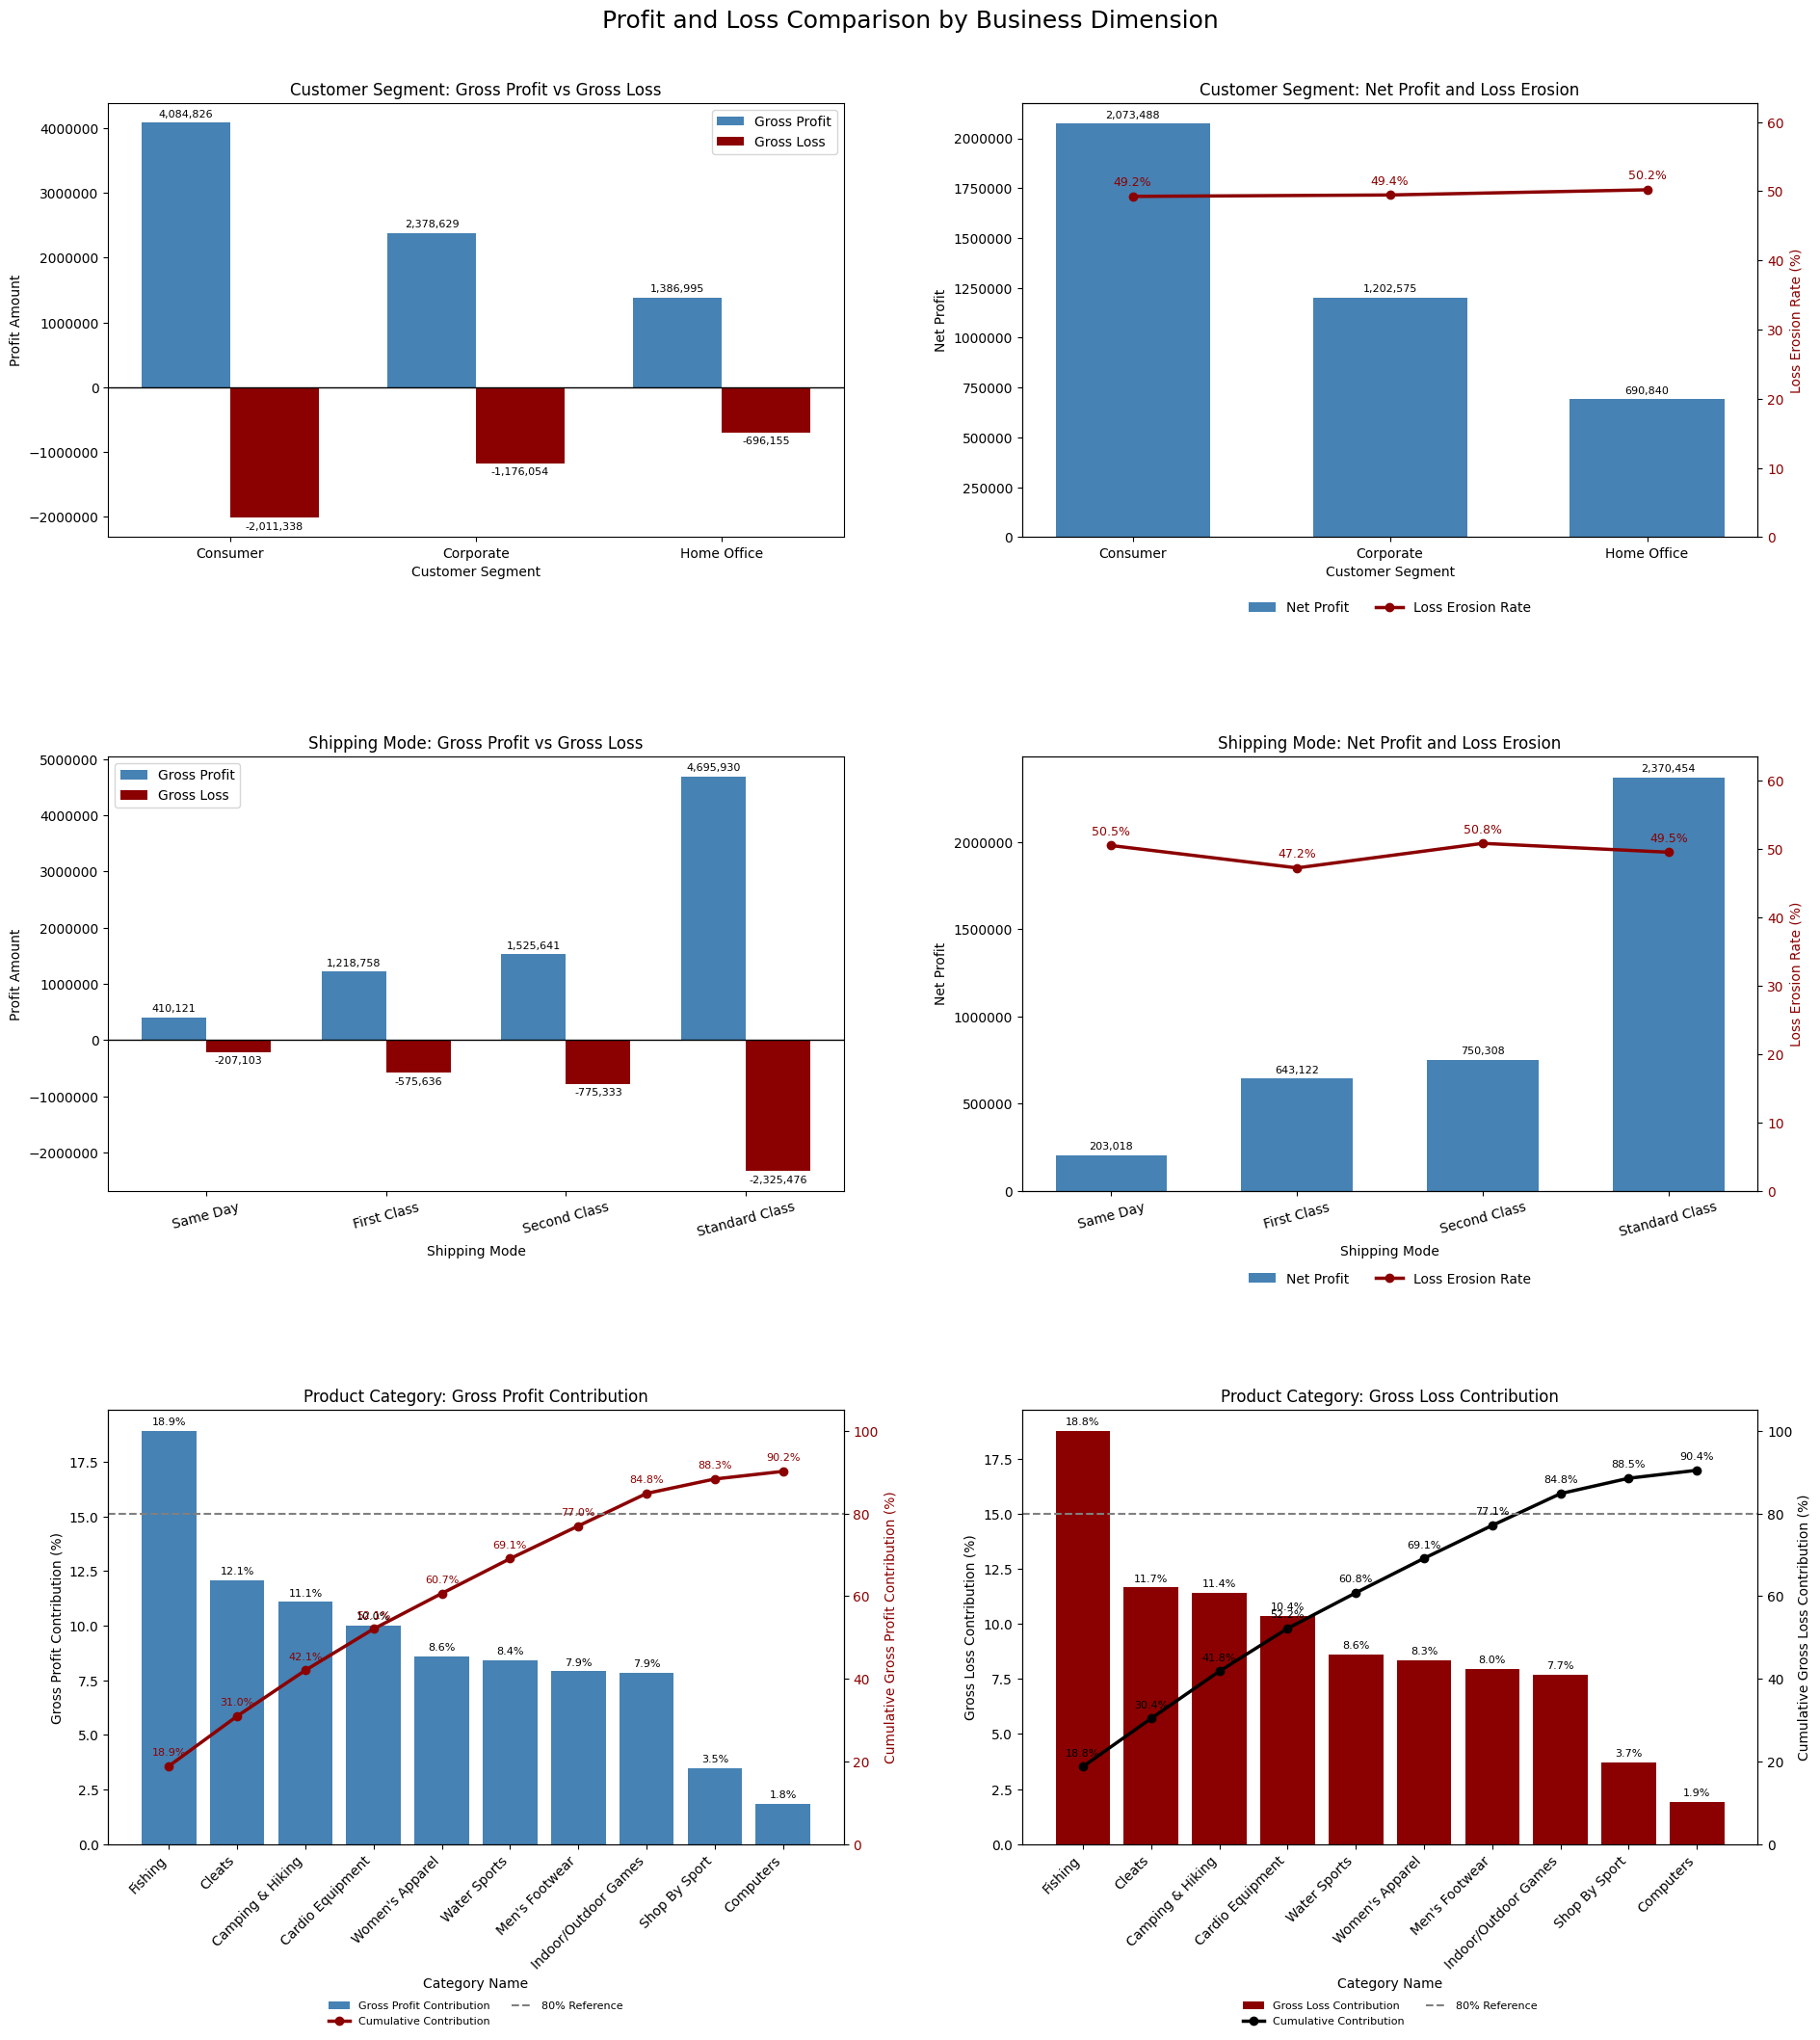

Profitability by Discount Rate Bucket


,discount_rate_bucket,order_item_count,sales,net_sales,gross_profit,gross_loss,net_profit,loss_item_count,net_profit_margin,loss_item_rate,loss_erosion_rate
0,0-5%,"50,142","10,214,702.10","10,010,361.06","2,369,884.71","-1,169,258.46","1,200,626.25","9,339",11.99%,18.63%,49.34%
1,5-10%,"40,116","8,173,764.65","7,632,209.32","1,829,392.17","-886,333.63","943,058.54","7,395",12.36%,18.43%,48.45%
2,10-15%,"30,087","6,131,172.79","5,415,832.75","1,283,933.43","-637,850.96","646,082.47","5,660",11.93%,18.81%,49.68%
3,15-20%,"40,116","8,176,530.86","6,827,366.74","1,617,649.61","-809,723.36","807,926.25","7,573",11.83%,18.88%,50.06%
4,20-25%,"20,058","4,088,564.63","3,168,632.51","749,590.40","-380,380.94","369,209.46","3,817",11.65%,19.03%,50.75%


Profit and Loss by Customer Segment


,Customer Segment,order_item_count,sales,gross_profit,gross_loss,net_profit,loss_item_count,net_profit_margin,loss_item_rate,loss_erosion_rate
0,Consumer,"93,504","19,095,790.16","4,084,825.97","-2,011,338.30","2,073,487.67","17,396",10.86%,18.60%,49.24%
1,Corporate,"54,789","11,168,406.84","2,378,629.30","-1,176,054.34","1,202,574.96","10,314",10.77%,18.82%,49.44%
2,Home Office,"32,226","6,520,538.02","1,386,995.05","-696,154.71","690,840.34","6,074",10.59%,18.85%,50.19%


Profit and Loss by Shipping Mode


...

Top 10 Gross Loss-Contributing Categories


,Category Name,order_item_count,gross_profit,gross_loss,net_profit,loss_item_count,loss_item_rate,loss_erosion_rate,gross_loss_contribution_pct,cumulative_gross_loss_pct
0,Fishing,"17,325","1,484,791.71","-728,570.95","756,220.77","3,209",18.52%,49.07%,18.76%,18.76%
1,Cleats,"24,551","947,231.13","-452,594.21","494,636.92","4,590",18.70%,47.78%,11.65%,30.41%
2,Camping & Hiking,"13,729","870,537.80","-443,082.23","427,455.57","2,590",18.87%,50.90%,11.41%,41.82%
3,Cardio Equipment,"12,487","785,658.36","-402,647.26","383,011.10","2,332",18.68%,51.25%,10.37%,52.19%
4,Water Sports,"15,540","659,716.59","-334,569.63","325,146.96","2,924",18.82%,50.71%,8.62%,60.81%
5,Women's Apparel,"21,035","674,193.90","-323,772.87","350,421.03","3,923",18.65%,48.02%,8.34%,69.14%
6,Men's Footwear,"22,246","621,172.52","-309,269.70","311,902.82","4,169",18.74%,49.79%,7.96%,77.11%
7,Indoor/Outdoor Games,"19,298","617,088.91","-298,637.48","318,451.43","3,617",18.74%,48.39%,7.69%,84.80%
8,Shop By Sport,"10,984","274,124.52","-144,310.56","129,813.96","2,154",19.61%,52.64%,3.72%,88.51%
9,Computers,442,"144,623.94","-74,967.13","69,656.81",73,16.52%,51.84%,1.93%,90.44%


Top 10 Loss-making Order Items


,Order Item Id,Order Id,Category Name,Product Name,Customer Segment,Shipping Mode,Order Item Discount,Order Item Discount Rate,Sales,Order Item Total,Order Profit Per Order
0,172144,68859,Strength Training,SOLE E35 Elliptical,Consumer,Second Class,100.00,5.0%,"1,999.99","1,899.99","-4,274.98"
1,173848,70533,Computers,Dell Laptop,Home Office,Second Class,150.00,10.0%,"1,500.00","1,350.00","-3,442.50"
2,177871,74556,Computers,Dell Laptop,Corporate,Standard Class,180.00,12.0%,"1,500.00","1,320.00","-3,366.00"
3,174075,70760,Computers,Dell Laptop,Consumer,Standard Class,300.00,20.0%,"1,500.00","1,200.00","-3,000.00"
4,177823,74508,Computers,Dell Laptop,Consumer,Standard Class,60.00,4.0%,"1,500.00","1,440.00","-2,592.00"
5,173875,70560,Computers,Dell Laptop,Consumer,Standard Class,0.00,0.0%,"1,500.00","1,500.00","-2,550.00"
6,173852,70537,Computers,Dell Laptop,Corporate,Standard Class,75.00,5.0%,"1,500.00","1,425.00","-2,351.25"
7,174160,70845,Computers,Dell Laptop,Home Office,Standard Class,45.00,3.0%,"1,500.00","1,455.00","-2,328.00"
8,174068,70753,Computers,Dell Laptop,Home Office,Second Class,75.00,5.0%,"1,500.00","1,425.00","-2,280.00"
9,173998,70683,Computers,Dell Laptop,Consumer,Standard Class,45.00,3.0%,"1,500.00","1,455.00","-2,255.25"


Profitability Analysis Summary
Total Sales: 36,784,735.01
Gross Profit: 7,850,450.32
Gross Loss: -3,883,547.35
Net Profit: 3,966,902.97
Overall Profit Margin: 10.78%
Loss-making Order Items: 33,784 (18.71%)
Loss Erosion Rate: 49.47%
Lowest-Margin Discount Bucket: 20-25% (11.65%)
Highest Loss-rate Discount Bucket: 20-25% (19.03%)
Top 10 Category Gross Profit Contribution: 90.17%
Top 10 Category Gross Loss Contribution: 90.44%
Highest Customer Segment Loss Erosion: Home Office (50.19%)
Highest Shipping Mode Loss Erosion: Second Class (50.82%)


In [77]:

profit_col = "Order Profit Per Order"


# ============================================================
# 1. Overall Profitability KPIs
# ============================================================

total_sales = df_clean["Sales"].sum()

gross_profit = (
    df_clean.loc[
        df_clean[profit_col] > 0,
        profit_col
    ]
    .sum()
)

gross_loss = (
    df_clean.loc[
        df_clean[profit_col] < 0,
        profit_col
    ]
    .sum()
)

net_profit = (
    df_clean[profit_col]
    .sum()
)

avg_profit_per_item = df_clean[profit_col].mean()
median_profit_per_item = df_clean[profit_col].median()

profit_margin = (
    net_profit / total_sales * 100
    if total_sales != 0
    else np.nan
)

loss_item_count = (
    df_clean[profit_col] < 0
).sum()

loss_item_rate = (
    loss_item_count / len(df_clean) * 100
    if len(df_clean) > 0
    else np.nan
)

# Loss Erosion Rate:
# Percentage of gross profit offset by loss-making order items.

loss_erosion_rate = (
    abs(gross_loss) / gross_profit * 100
    if gross_profit != 0
    else np.nan
)


# ------------------------------------------------------------
# 1.1 Overall KPI Summary
# ------------------------------------------------------------

profit_kpi = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Gross Profit",
        "Gross Loss",
        "Net Profit",
        "Average Profit per Order Item",
        "Median Profit per Order Item",
        "Profit Margin (%)",
        "Loss-making Order Items",
        "Loss-making Order Items (%)",
        "Loss Erosion Rate (%)"
    ],
    "Value": [
        total_sales,
        gross_profit,
        gross_loss,
        net_profit,
        avg_profit_per_item,
        median_profit_per_item,
        profit_margin,
        loss_item_count,
        loss_item_rate,
        loss_erosion_rate
    ]
})


def format_kpi_value(metric, value):
    if "(%)" in metric:
        return f"{value:,.2f}%"

    if metric == "Loss-making Order Items":
        return f"{value:,.0f}"

    return f"{value:,.2f}"


profit_kpi_display = profit_kpi.copy()

profit_kpi_display["Value"] = [
    format_kpi_value(metric, value)
    for metric, value in zip(
        profit_kpi_display["Metric"],
        profit_kpi_display["Value"]
    )
]

display(profit_kpi_display)


# ------------------------------------------------------------
# 1.2 Loss Impact Summary
# ------------------------------------------------------------

loss_kpi_display = pd.DataFrame({
    "Metric": [
        "Loss-making Item Rate",
        "Loss Erosion Rate",
        "Gross Profit",
        "Gross Loss",
        "Net Profit"
    ],
    "Value": [
        f"{loss_item_rate:.1f}%",
        f"{loss_erosion_rate:.1f}%",
        f"{gross_profit:,.0f}",
        f"{gross_loss:,.0f}",
        f"{net_profit:,.0f}"
    ]
})

print("Loss Impact Summary")
display(loss_kpi_display)


# ============================================================
# 2. Reusable Profit and Loss Summary Function
# ============================================================

def build_profit_loss_summary(data, group_col, profit_column):
    summary = (
        data
        .groupby(group_col, observed=True)
        .agg(
            order_item_count=("Order Item Id", "count"),
            sales=("Sales", "sum"),
            gross_profit=(
                profit_column,
                lambda values: values.loc[values > 0].sum()
            ),
            gross_loss=(
                profit_column,
                lambda values: values.loc[values < 0].sum()
            ),
            net_profit=(
                profit_column,
                "sum"
            ),
            loss_item_count=(
                profit_column,
                lambda values: (values < 0).sum()
            )
        )
        .reset_index()
    )

    summary["net_profit_margin"] = np.where(
        summary["sales"] != 0,
        summary["net_profit"] / summary["sales"] * 100,
        np.nan
    )

    summary["loss_item_rate"] = np.where(
        summary["order_item_count"] != 0,
        summary["loss_item_count"]
        / summary["order_item_count"]
        * 100,
        np.nan
    )

    summary["loss_erosion_rate"] = np.where(
        summary["gross_profit"] != 0,
        summary["gross_loss"].abs()
        / summary["gross_profit"]
        * 100,
        np.nan
    )

    return summary


# ============================================================
# 3. Profit and Loss by Customer Segment
# ============================================================

segment_profit_loss = build_profit_loss_summary(
    data=df_clean,
    group_col="Customer Segment",
    profit_column=profit_col
)

segment_plot_order = (
    segment_profit_loss
    .sort_values("net_profit", ascending=False)
    ["Customer Segment"]
    .tolist()
)


# ============================================================
# 4. Profit and Loss by Shipping Mode
# ============================================================

shipping_profit_loss = build_profit_loss_summary(
    data=df_clean,
    group_col="Shipping Mode",
    profit_column=profit_col
)

shipping_plot_order = [
    "Same Day",
    "First Class",
    "Second Class",
    "Standard Class"
]

shipping_profit_loss["Shipping Mode"] = pd.Categorical(
    shipping_profit_loss["Shipping Mode"],
    categories=shipping_plot_order,
    ordered=True
)

shipping_profit_loss = (
    shipping_profit_loss
    .sort_values("Shipping Mode")
    .reset_index(drop=True)
)


# ============================================================
# 5. Profit and Loss by Product Category
# ============================================================

category_profit_loss = build_profit_loss_summary(
    data=df_clean,
    group_col="Category Name",
    profit_column=profit_col
)


# ------------------------------------------------------------
# 5.1 Gross Profit Contribution by Category
# ------------------------------------------------------------

positive_category_profit = (
    category_profit_loss
    .loc[category_profit_loss["gross_profit"] > 0]
    .sort_values("gross_profit", ascending=False)
    .copy()
)

total_category_gross_profit = (
    positive_category_profit["gross_profit"].sum()
)

positive_category_profit[
    "gross_profit_contribution_pct"
] = (
    positive_category_profit["gross_profit"]
    / total_category_gross_profit
    * 100
)

positive_category_profit[
    "cumulative_gross_profit_pct"
] = (
    positive_category_profit[
        "gross_profit_contribution_pct"
    ].cumsum()
)

top_profit_category = (
    positive_category_profit
    .head(10)
    .copy()
)


# ------------------------------------------------------------
# 5.2 Gross Loss Contribution by Category
# ------------------------------------------------------------

negative_category_profit = (
    category_profit_loss
    .loc[category_profit_loss["gross_loss"] < 0]
    .copy()
)

negative_category_profit["absolute_gross_loss"] = (
    negative_category_profit["gross_loss"].abs()
)

negative_category_profit = (
    negative_category_profit
    .sort_values(
        "absolute_gross_loss",
        ascending=False
    )
    .reset_index(drop=True)
)

total_category_gross_loss = (
    negative_category_profit[
        "absolute_gross_loss"
    ].sum()
)

negative_category_profit[
    "gross_loss_contribution_pct"
] = (
    negative_category_profit["absolute_gross_loss"]
    / total_category_gross_loss
    * 100
)

negative_category_profit[
    "cumulative_gross_loss_pct"
] = (
    negative_category_profit[
        "gross_loss_contribution_pct"
    ].cumsum()
)

top_loss_category = (
    negative_category_profit
    .head(10)
    .copy()
)


# ============================================================
# 6. Profitability by Discount Rate Bucket
# ============================================================

# Use discount rate rather than discount amount because:
# 1. Discount amount is affected by product price.
# 2. Discount rate is more comparable across transactions.
#
# Dataset range:
# Order Item Discount Rate is between 0% and 25%.

discount_bins = [
    -0.001,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25
]

discount_labels = [
    "0-5%",
    "5-10%",
    "10-15%",
    "15-20%",
    "20-25%"
]

discount_analysis_df = df_clean.assign(
    discount_rate_bucket=pd.cut(
        df_clean["Order Item Discount Rate"],
        bins=discount_bins,
        labels=discount_labels,
        include_lowest=True
    )
)

discount_bucket_summary = (
    discount_analysis_df
    .groupby(
        "discount_rate_bucket",
        observed=False
    )
    .agg(
        order_item_count=("Order Item Id", "count"),
        sales=("Sales", "sum"),
        net_sales=("Order Item Total", "sum"),
        gross_profit=(
            profit_col,
            lambda values: values.loc[values > 0].sum()
        ),
        gross_loss=(
            profit_col,
            lambda values: values.loc[values < 0].sum()
        ),
        net_profit=(profit_col, "sum"),
        loss_item_count=(
            profit_col,
            lambda values: (values < 0).sum()
        )
    )
    .reindex(discount_labels)
    .reset_index()
)

# Use net sales after discount as denominator.
# This is more appropriate for evaluating post-discount profitability.

discount_bucket_summary["net_profit_margin"] = np.where(
    discount_bucket_summary["net_sales"] != 0,
    discount_bucket_summary["net_profit"]
    / discount_bucket_summary["net_sales"]
    * 100,
    np.nan
)

discount_bucket_summary["loss_item_rate"] = np.where(
    discount_bucket_summary["order_item_count"] != 0,
    discount_bucket_summary["loss_item_count"]
    / discount_bucket_summary["order_item_count"]
    * 100,
    np.nan
)

discount_bucket_summary["loss_erosion_rate"] = np.where(
    discount_bucket_summary["gross_profit"] != 0,
    discount_bucket_summary["gross_loss"].abs()
    / discount_bucket_summary["gross_profit"]
    * 100,
    np.nan
)


# ============================================================
# 7. Top 10 Loss-making Order Items
# ============================================================

top_loss_order_items = (
    df_clean
    .loc[
        df_clean[profit_col] < 0,
        [
            "Order Item Id",
            "Order Id",
            "Category Name",
            "Product Name",
            "Customer Segment",
            "Shipping Mode",
            "Order Item Discount",
            "Order Item Discount Rate",
            "Sales",
            "Order Item Total",
            profit_col
        ]
    ]
    .nsmallest(10, profit_col)
    .reset_index(drop=True)
)


# ============================================================
# Figure 1
# Overall Profitability Analysis
# Layout: 1 row x 2 columns
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6)
)

fig.suptitle(
    "Overall Profitability Analysis",
    fontsize=18,
    y=1.03
)


# ------------------------------------------------------------
# Figure 1.1 Profit Distribution
# ------------------------------------------------------------

minimum_profit = df_clean[profit_col].min()

sns.histplot(
    data=df_clean,
    x=profit_col,
    bins=100,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_yscale("log")

axes[0].axvline(
    x=minimum_profit,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Minimum: {minimum_profit:,.2f}"
)

axes[0].axvline(
    x=0,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="Break-even"
)

axes[0].set_title(
    "Profit Distribution with Extreme Loss Highlighted"
)

axes[0].set_xlabel(
    "Profit per Order Item"
)

axes[0].set_ylabel(
    "Order Item Count (Log Scale)"
)

axes[0].legend()


# ------------------------------------------------------------
# Figure 1.2 Discount Rate Bucket Analysis
# ------------------------------------------------------------

discount_positions = np.arange(
    len(discount_bucket_summary)
)

discount_margin_bars = axes[1].bar(
    discount_positions,
    discount_bucket_summary["net_profit_margin"],
    width=0.6,
    color="steelblue",
    label="Net Profit Margin"
)

axes[1].axhline(
    y=profit_margin,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Margin: {profit_margin:.1f}%"
)

axes[1].set_xticks(
    discount_positions
)

axes[1].set_xticklabels(
    discount_bucket_summary[
        "discount_rate_bucket"
    ].astype(str)
)

axes[1].set_title(
    "Profitability by Discount Rate Bucket"
)

axes[1].set_xlabel(
    "Order Item Discount Rate"
)

axes[1].set_ylabel(
    "Net Profit Margin (%)"
)

axes[1].bar_label(
    discount_margin_bars,
    labels=[
        f"{value:.1f}%"
        for value in discount_bucket_summary[
            "net_profit_margin"
        ]
    ],
    padding=3,
    fontsize=9
)

# Secondary axis for loss-making item rate.

discount_loss_axis = axes[1].twinx()

discount_loss_axis.plot(
    discount_positions,
    discount_bucket_summary[
        "loss_item_rate"
    ],
    color="darkred",
    marker="o",
    linewidth=2.5,
    label="Loss-making Item Rate"
)

discount_loss_axis.set_ylabel(
    "Loss-making Item Rate (%)",
    color="darkred"
)

discount_loss_axis.tick_params(
    axis="y",
    labelcolor="darkred"
)

discount_loss_axis.set_ylim(
    0,
    max(
        30,
        discount_bucket_summary[
            "loss_item_rate"
        ].max() * 1.3
    )
)

for index, value in enumerate(
    discount_bucket_summary["loss_item_rate"]
):
    discount_loss_axis.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="darkred",
        fontsize=9
    )

discount_handles_1, discount_labels_1 = (
    axes[1].get_legend_handles_labels()
)

discount_handles_2, discount_labels_2 = (
    discount_loss_axis.get_legend_handles_labels()
)

axes[1].legend(
    discount_handles_1 + discount_handles_2,
    discount_labels_1 + discount_labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.tight_layout(
    w_pad=5
)

plt.show()


# ============================================================
# Figure 2
# Profit and Loss Comparison by Business Dimension
# Layout: 3 rows x 2 columns
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(19, 21)
)

fig.suptitle(
    "Profit and Loss Comparison by Business Dimension",
    fontsize=18,
    y=1.01
)


# ============================================================
# Row 1. Customer Segment
# ============================================================

segment_plot_df = (
    segment_profit_loss
    .set_index("Customer Segment")
    .reindex(segment_plot_order)
    .reset_index()
)

segment_positions = np.arange(
    len(segment_plot_df)
)

segment_bar_width = 0.36


# ------------------------------------------------------------
# Figure 2.1 Customer Gross Profit versus Gross Loss
# ------------------------------------------------------------

segment_gross_profit_bars = axes[0, 0].bar(
    segment_positions - segment_bar_width / 2,
    segment_plot_df["gross_profit"],
    width=segment_bar_width,
    color="steelblue",
    label="Gross Profit"
)

segment_gross_loss_bars = axes[0, 0].bar(
    segment_positions + segment_bar_width / 2,
    segment_plot_df["gross_loss"],
    width=segment_bar_width,
    color="darkred",
    label="Gross Loss"
)

axes[0, 0].axhline(
    y=0,
    color="black",
    linewidth=1
)

axes[0, 0].set_xticks(
    segment_positions
)

axes[0, 0].set_xticklabels(
    segment_plot_df["Customer Segment"]
)

axes[0, 0].set_title(
    "Customer Segment: Gross Profit vs Gross Loss"
)

axes[0, 0].set_xlabel(
    "Customer Segment"
)

axes[0, 0].set_ylabel(
    "Profit Amount"
)

axes[0, 0].ticklabel_format(
    style="plain",
    axis="y"
)

axes[0, 0].bar_label(
    segment_gross_profit_bars,
    labels=[
        f"{value:,.0f}"
        for value in segment_plot_df["gross_profit"]
    ],
    padding=3,
    fontsize=8
)

axes[0, 0].bar_label(
    segment_gross_loss_bars,
    labels=[
        f"{value:,.0f}"
        for value in segment_plot_df["gross_loss"]
    ],
    padding=3,
    fontsize=8
)

axes[0, 0].legend()


# ------------------------------------------------------------
# Figure 2.2 Customer Net Profit and Loss Erosion Rate
# ------------------------------------------------------------

segment_net_profit_bars = axes[0, 1].bar(
    segment_positions,
    segment_plot_df["net_profit"],
    width=0.6,
    color="steelblue",
    label="Net Profit"
)

axes[0, 1].set_xticks(
    segment_positions
)

axes[0, 1].set_xticklabels(
    segment_plot_df["Customer Segment"]
)

axes[0, 1].set_xlabel(
    "Customer Segment"
)

axes[0, 1].set_ylabel(
    "Net Profit"
)

axes[0, 1].ticklabel_format(
    style="plain",
    axis="y"
)

axes[0, 1].bar_label(
    segment_net_profit_bars,
    labels=[
        f"{value:,.0f}"
        for value in segment_plot_df["net_profit"]
    ],
    padding=3,
    fontsize=8
)

segment_erosion_axis = axes[0, 1].twinx()

segment_erosion_axis.plot(
    segment_positions,
    segment_plot_df["loss_erosion_rate"],
    color="darkred",
    marker="o",
    linewidth=2.5,
    label="Loss Erosion Rate"
)

segment_erosion_axis.set_ylabel(
    "Loss Erosion Rate (%)",
    color="darkred"
)

segment_erosion_axis.tick_params(
    axis="y",
    labelcolor="darkred"
)

segment_erosion_axis.set_ylim(
    0,
    max(
        60,
        segment_plot_df[
            "loss_erosion_rate"
        ].max() * 1.25
    )
)

for index, value in enumerate(
    segment_plot_df["loss_erosion_rate"]
):
    segment_erosion_axis.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="darkred",
        fontsize=9
    )

axes[0, 1].set_title(
    "Customer Segment: Net Profit and Loss Erosion"
)

customer_handles_1, customer_labels_1 = (
    axes[0, 1].get_legend_handles_labels()
)

customer_handles_2, customer_labels_2 = (
    segment_erosion_axis.get_legend_handles_labels()
)

axes[0, 1].legend(
    customer_handles_1 + customer_handles_2,
    customer_labels_1 + customer_labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)


# ============================================================
# Row 2. Shipping Mode
# ============================================================

shipping_plot_df = (
    shipping_profit_loss
    .set_index("Shipping Mode")
    .reindex(shipping_plot_order)
    .reset_index()
)

shipping_positions = np.arange(
    len(shipping_plot_df)
)

shipping_bar_width = 0.36


# ------------------------------------------------------------
# Figure 2.3 Shipping Gross Profit versus Gross Loss
# ------------------------------------------------------------

shipping_gross_profit_bars = axes[1, 0].bar(
    shipping_positions - shipping_bar_width / 2,
    shipping_plot_df["gross_profit"],
    width=shipping_bar_width,
    color="steelblue",
    label="Gross Profit"
)

shipping_gross_loss_bars = axes[1, 0].bar(
    shipping_positions + shipping_bar_width / 2,
    shipping_plot_df["gross_loss"],
    width=shipping_bar_width,
    color="darkred",
    label="Gross Loss"
)

axes[1, 0].axhline(
    y=0,
    color="black",
    linewidth=1
)

axes[1, 0].set_xticks(
    shipping_positions
)

axes[1, 0].set_xticklabels(
    shipping_plot_df["Shipping Mode"],
    rotation=15
)

axes[1, 0].set_title(
    "Shipping Mode: Gross Profit vs Gross Loss"
)

axes[1, 0].set_xlabel(
    "Shipping Mode"
)

axes[1, 0].set_ylabel(
    "Profit Amount"
)

axes[1, 0].ticklabel_format(
    style="plain",
    axis="y"
)

axes[1, 0].bar_label(
    shipping_gross_profit_bars,
    labels=[
        f"{value:,.0f}"
        for value in shipping_plot_df["gross_profit"]
    ],
    padding=3,
    fontsize=8
)

axes[1, 0].bar_label(
    shipping_gross_loss_bars,
    labels=[
        f"{value:,.0f}"
        for value in shipping_plot_df["gross_loss"]
    ],
    padding=3,
    fontsize=8
)

axes[1, 0].legend()


# ------------------------------------------------------------
# Figure 2.4 Shipping Net Profit and Loss Erosion Rate
# ------------------------------------------------------------

shipping_net_profit_bars = axes[1, 1].bar(
    shipping_positions,
    shipping_plot_df["net_profit"],
    width=0.6,
    color="steelblue",
    label="Net Profit"
)

axes[1, 1].set_xticks(
    shipping_positions
)

axes[1, 1].set_xticklabels(
    shipping_plot_df["Shipping Mode"],
    rotation=15
)

axes[1, 1].set_xlabel(
    "Shipping Mode"
)

axes[1, 1].set_ylabel(
    "Net Profit"
)

axes[1, 1].ticklabel_format(
    style="plain",
    axis="y"
)

axes[1, 1].bar_label(
    shipping_net_profit_bars,
    labels=[
        f"{value:,.0f}"
        for value in shipping_plot_df["net_profit"]
    ],
    padding=3,
    fontsize=8
)

shipping_erosion_axis = axes[1, 1].twinx()

shipping_erosion_axis.plot(
    shipping_positions,
    shipping_plot_df["loss_erosion_rate"],
    color="darkred",
    marker="o",
    linewidth=2.5,
    label="Loss Erosion Rate"
)

shipping_erosion_axis.set_ylabel(
    "Loss Erosion Rate (%)",
    color="darkred"
)

shipping_erosion_axis.tick_params(
    axis="y",
    labelcolor="darkred"
)

shipping_erosion_axis.set_ylim(
    0,
    max(
        60,
        shipping_plot_df[
            "loss_erosion_rate"
        ].max() * 1.25
    )
)

for index, value in enumerate(
    shipping_plot_df["loss_erosion_rate"]
):
    shipping_erosion_axis.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="darkred",
        fontsize=9
    )

axes[1, 1].set_title(
    "Shipping Mode: Net Profit and Loss Erosion"
)

shipping_handles_1, shipping_labels_1 = (
    axes[1, 1].get_legend_handles_labels()
)

shipping_handles_2, shipping_labels_2 = (
    shipping_erosion_axis.get_legend_handles_labels()
)

axes[1, 1].legend(
    shipping_handles_1 + shipping_handles_2,
    shipping_labels_1 + shipping_labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False
)


# ============================================================
# Row 3. Product Category
# ============================================================

# ------------------------------------------------------------
# Figure 2.5 Gross Profit Contribution Pareto
# ------------------------------------------------------------

profit_pareto_df = top_profit_category.copy()

profit_category_positions = np.arange(
    len(profit_pareto_df)
)

profit_category_names = (
    profit_pareto_df["Category Name"]
    .tolist()
)

profit_contribution_bars = axes[2, 0].bar(
    profit_category_positions,
    profit_pareto_df[
        "gross_profit_contribution_pct"
    ],
    color="steelblue",
    label="Gross Profit Contribution"
)

axes[2, 0].set_xticks(
    profit_category_positions
)

axes[2, 0].set_xticklabels(
    profit_category_names,
    rotation=45,
    ha="right"
)

axes[2, 0].set_title(
    "Product Category: Gross Profit Contribution"
)

axes[2, 0].set_xlabel(
    "Category Name"
)

axes[2, 0].set_ylabel(
    "Gross Profit Contribution (%)"
)

axes[2, 0].bar_label(
    profit_contribution_bars,
    labels=[
        f"{value:.1f}%"
        for value in profit_pareto_df[
            "gross_profit_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=8
)

profit_cumulative_axis = axes[2, 0].twinx()

profit_cumulative_axis.plot(
    profit_category_positions,
    profit_pareto_df[
        "cumulative_gross_profit_pct"
    ],
    color="darkred",
    marker="o",
    linewidth=2.5,
    label="Cumulative Contribution"
)

profit_cumulative_axis.axhline(
    y=80,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="80% Reference"
)

profit_cumulative_axis.set_ylabel(
    "Cumulative Gross Profit Contribution (%)",
    color="darkred"
)

profit_cumulative_axis.tick_params(
    axis="y",
    labelcolor="darkred"
)

profit_cumulative_axis.set_ylim(
    0,
    105
)

for index, value in enumerate(
    profit_pareto_df[
        "cumulative_gross_profit_pct"
    ]
):
    profit_cumulative_axis.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="darkred",
        fontsize=8
    )

profit_handles_1, profit_labels_1 = (
    axes[2, 0].get_legend_handles_labels()
)

profit_handles_2, profit_labels_2 = (
    profit_cumulative_axis.get_legend_handles_labels()
)

axes[2, 0].legend(
    profit_handles_1 + profit_handles_2,
    profit_labels_1 + profit_labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=2,
    frameon=False,
    fontsize=8
)


# ------------------------------------------------------------
# Figure 2.6 Gross Loss Contribution Pareto
# ------------------------------------------------------------

loss_pareto_df = top_loss_category.copy()

loss_category_positions = np.arange(
    len(loss_pareto_df)
)

loss_category_names = (
    loss_pareto_df["Category Name"]
    .tolist()
)

loss_contribution_bars = axes[2, 1].bar(
    loss_category_positions,
    loss_pareto_df[
        "gross_loss_contribution_pct"
    ],
    color="darkred",
    label="Gross Loss Contribution"
)

axes[2, 1].set_xticks(
    loss_category_positions
)

axes[2, 1].set_xticklabels(
    loss_category_names,
    rotation=45,
    ha="right"
)

axes[2, 1].set_title(
    "Product Category: Gross Loss Contribution"
)

axes[2, 1].set_xlabel(
    "Category Name"
)

axes[2, 1].set_ylabel(
    "Gross Loss Contribution (%)"
)

axes[2, 1].bar_label(
    loss_contribution_bars,
    labels=[
        f"{value:.1f}%"
        for value in loss_pareto_df[
            "gross_loss_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=8
)

loss_cumulative_axis = axes[2, 1].twinx()

loss_cumulative_axis.plot(
    loss_category_positions,
    loss_pareto_df[
        "cumulative_gross_loss_pct"
    ],
    color="black",
    marker="o",
    linewidth=2.5,
    label="Cumulative Contribution"
)

loss_cumulative_axis.axhline(
    y=80,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="80% Reference"
)

loss_cumulative_axis.set_ylabel(
    "Cumulative Gross Loss Contribution (%)"
)

loss_cumulative_axis.set_ylim(
    0,
    105
)

for index, value in enumerate(
    loss_pareto_df[
        "cumulative_gross_loss_pct"
    ]
):
    loss_cumulative_axis.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="black",
        fontsize=8
    )

loss_handles_1, loss_labels_1 = (
    axes[2, 1].get_legend_handles_labels()
)

loss_handles_2, loss_labels_2 = (
    loss_cumulative_axis.get_legend_handles_labels()
)

axes[2, 1].legend(
    loss_handles_1 + loss_handles_2,
    loss_labels_1 + loss_labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=2,
    frameon=False,
    fontsize=8
)

plt.tight_layout(
    h_pad=7,
    w_pad=5
)

plt.show()


# ============================================================
# 8. Summary Tables
# ============================================================

print("Profitability by Discount Rate Bucket")

display(
    discount_bucket_summary.style.format({
        "order_item_count": "{:,.0f}",
        "sales": "{:,.2f}",
        "net_sales": "{:,.2f}",
        "gross_profit": "{:,.2f}",
        "gross_loss": "{:,.2f}",
        "net_profit": "{:,.2f}",
        "loss_item_count": "{:,.0f}",
        "net_profit_margin": "{:.2f}%",
        "loss_item_rate": "{:.2f}%",
        "loss_erosion_rate": "{:.2f}%"
    })
)


print("Profit and Loss by Customer Segment")

display(
    segment_profit_loss.style.format({
        "order_item_count": "{:,.0f}",
        "sales": "{:,.2f}",
        "gross_profit": "{:,.2f}",
        "gross_loss": "{:,.2f}",
        "net_profit": "{:,.2f}",
        "loss_item_count": "{:,.0f}",
        "net_profit_margin": "{:.2f}%",
        "loss_item_rate": "{:.2f}%",
        "loss_erosion_rate": "{:.2f}%"
    })
)


print("Profit and Loss by Shipping Mode")

display(
    shipping_profit_loss.style.format({
        "order_item_count": "{:,.0f}",
        "sales": "{:,.2f}",
        "gross_profit": "{:,.2f}",
        "gross_loss": "{:,.2f}",
        "net_profit": "{:,.2f}",
        "loss_item_count": "{:,.0f}",
        "net_profit_margin": "{:.2f}%",
        "loss_item_rate": "{:.2f}%",
        "loss_erosion_rate": "{:.2f}%"
    })
)


print("Top 10 Gross Profit-Contributing Categories")

profit_category_columns = [
    "Category Name",
    "order_item_count",
    "gross_profit",
    "gross_loss",
    "net_profit",
    "loss_item_count",
    "loss_item_rate",
    "loss_erosion_rate",
    "gross_profit_contribution_pct",
    "cumulative_gross_profit_pct"
]

display(
    top_profit_category[
        profit_category_columns
    ].style.format({
        "order_item_count": "{:,.0f}",
        "gross_profit": "{:,.2f}",
        "gross_loss": "{:,.2f}",
        "net_profit": "{:,.2f}",
        "loss_item_count": "{:,.0f}",
        "loss_item_rate": "{:.2f}%",
        "loss_erosion_rate": "{:.2f}%",
        "gross_profit_contribution_pct": "{:.2f}%",
        "cumulative_gross_profit_pct": "{:.2f}%"
    })
)


print("Top 10 Gross Loss-Contributing Categories")

loss_category_columns = [
    "Category Name",
    "order_item_count",
    "gross_profit",
    "gross_loss",
    "net_profit",
    "loss_item_count",
    "loss_item_rate",
    "loss_erosion_rate",
    "gross_loss_contribution_pct",
    "cumulative_gross_loss_pct"
]

display(
    top_loss_category[
        loss_category_columns
    ].style.format({
        "order_item_count": "{:,.0f}",
        "gross_profit": "{:,.2f}",
        "gross_loss": "{:,.2f}",
        "net_profit": "{:,.2f}",
        "loss_item_count": "{:,.0f}",
        "loss_item_rate": "{:.2f}%",
        "loss_erosion_rate": "{:.2f}%",
        "gross_loss_contribution_pct": "{:.2f}%",
        "cumulative_gross_loss_pct": "{:.2f}%"
    })
)


print("Top 10 Loss-making Order Items")

display(
    top_loss_order_items.style.format({
        "Order Item Discount": "{:,.2f}",
        "Order Item Discount Rate": "{:.1%}",
        "Sales": "{:,.2f}",
        "Order Item Total": "{:,.2f}",
        profit_col: "{:,.2f}"
    })
)


# ============================================================
# 9. Final Statistical Summary
# ============================================================

top_10_profit_contribution = (
    top_profit_category[
        "gross_profit_contribution_pct"
    ].sum()
)

top_10_loss_contribution = (
    top_loss_category[
        "gross_loss_contribution_pct"
    ].sum()
)

highest_segment_erosion = (
    segment_profit_loss
    .sort_values(
        "loss_erosion_rate",
        ascending=False
    )
    .iloc[0]
)

highest_shipping_erosion = (
    shipping_profit_loss
    .sort_values(
        "loss_erosion_rate",
        ascending=False
    )
    .iloc[0]
)

lowest_margin_discount_bucket = (
    discount_bucket_summary
    .sort_values(
        "net_profit_margin",
        ascending=True
    )
    .iloc[0]
)

highest_loss_rate_discount_bucket = (
    discount_bucket_summary
    .sort_values(
        "loss_item_rate",
        ascending=False
    )
    .iloc[0]
)

print("=" * 70)
print("Profitability Analysis Summary")
print("=" * 70)

print(f"Total Sales: {total_sales:,.2f}")
print(f"Gross Profit: {gross_profit:,.2f}")
print(f"Gross Loss: {gross_loss:,.2f}")
print(f"Net Profit: {net_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

print(
    f"Loss-making Order Items: "
    f"{loss_item_count:,} "
    f"({loss_item_rate:.2f}%)"
)

print(
    f"Loss Erosion Rate: "
    f"{loss_erosion_rate:.2f}%"
)

print(
    f"Lowest-Margin Discount Bucket: "
    f"{lowest_margin_discount_bucket['discount_rate_bucket']} "
    f"({lowest_margin_discount_bucket['net_profit_margin']:.2f}%)"
)

print(
    f"Highest Loss-rate Discount Bucket: "
    f"{highest_loss_rate_discount_bucket['discount_rate_bucket']} "
    f"({highest_loss_rate_discount_bucket['loss_item_rate']:.2f}%)"
)

print(
    f"Top 10 Category Gross Profit Contribution: "
    f"{top_10_profit_contribution:.2f}%"
)

print(
    f"Top 10 Category Gross Loss Contribution: "
    f"{top_10_loss_contribution:.2f}%"
)

print(
    f"Highest Customer Segment Loss Erosion: "
    f"{highest_segment_erosion['Customer Segment']} "
    f"({highest_segment_erosion['loss_erosion_rate']:.2f}%)"
)

print(
    f"Highest Shipping Mode Loss Erosion: "
    f"{highest_shipping_erosion['Shipping Mode']} "
    f"({highest_shipping_erosion['loss_erosion_rate']:.2f}%)"
)

### Key Observations

**Overall Profitability**

- The business remains profitable overall, but loss-making order items account for a meaningful share of transactions and erode a substantial portion of gross profit. This indicates that improving loss-making transactions represents a significant profitability opportunity.

**Discount Effectiveness**

- Profitability remains stable across discount-rate buckets. Net profit margins stay around 12%, while loss-making rates remain close to 19%, suggesting that discount rate alone is unlikely to be a primary driver of profitability variation.

**Customer Segment and Shipping Mode**

- Profit and loss are distributed remarkably consistently across customer segments and shipping modes. Loss erosion rates remain close to 50% across all groups, indicating that profitability differences are largely driven by transaction volume rather than fundamentally different profit structures.

**Product Category Performance**

- Product categories that generate the highest gross profit also contribute the highest gross loss. The profit and loss Pareto analyses show highly similar ranking patterns, suggesting that larger business categories naturally generate both more profit and more loss.

**Business Implications**

- Customer segment, shipping mode, and product category alone are insufficient to explain profitability variation. Profit and loss appear to scale together rather than concentrate within specific groups.

- High sales volume does not necessarily guarantee high profitability.

- Future analysis should focus on transaction-level drivers such as product pricing, discount strategy, order value, quantity purchased, and operational costs, as these factors are more likely to explain why certain transactions become loss-making.

# Step 7. Customer Segmentation

### Analysis Goal

How is customer value distributed across the customer base, and what characteristics distinguish the most valuable customers?

The analysis will:

- Evaluate the business value of the original customer segments
- Measure sales and profit concentration across customer groups
- Segment customers into value-based tiers
- Analyze the contribution of VIP, High Value, Medium Value, Medium-Low Value, and Low Value customers
- Profile high-value customers using RFM metrics
- Compare purchasing behavior, product preferences, and shipping patterns of high-value customers
- Identify customer characteristics associated with greater business value

The analysis is performed in three stages:

1. **Original Customer Segment Analysis**
   - Evaluate Consumer, Corporate, and Home Office segments
   - Compare customer count, sales contribution, profit contribution, customer value, and profitability

2. **Customer Value Segmentation**
   - Classify customers into VIP, High Value, Medium Value, Medium-Low Value, and Low Value tiers based on total sales contribution
   - Measure customer value concentration across tiers

3. **High-Value Customer Profile Analysis**
   - Profile VIP and High Value customers using RFM metrics
   - Analyze purchasing behavior, preferred product categories, shipping patterns, and customer-segment composition

The objective is to identify the customer groups that drive business performance and understand the behavioral characteristics of high-value customers to support retention, personalization, and customer growth strategies.

## Step 7.1 Original Customer Segment Analysis

Customers assigned to more than one original segment: 0
Customer-level dataset shape: (20652, 10)
Unique customers: 20,652

Original Customer Segment Summary


,Customer Segment,customer_count,total_orders,total_sales,total_profit,avg_sales_per_customer,median_sales_per_customer,avg_orders_per_customer,avg_order_value,customer_pct,sales_contribution_pct,profit_contribution_pct,profit_margin
0,Consumer,"10,695","34,119","19,095,790.16","2,073,487.67","1,785.49","1,493.91",3.19,477.66,51.79%,51.91%,52.27%,10.86%
1,Corporate,"6,239","19,856","11,168,406.84","1,202,574.96","1,790.10","1,500.00",3.18,480.10,30.21%,30.36%,30.32%,10.77%
2,Home Office,"3,718","11,777","6,520,538.02","690,840.34","1,753.78","1,479.88",3.17,464.91,18.00%,17.73%,17.42%,10.59%


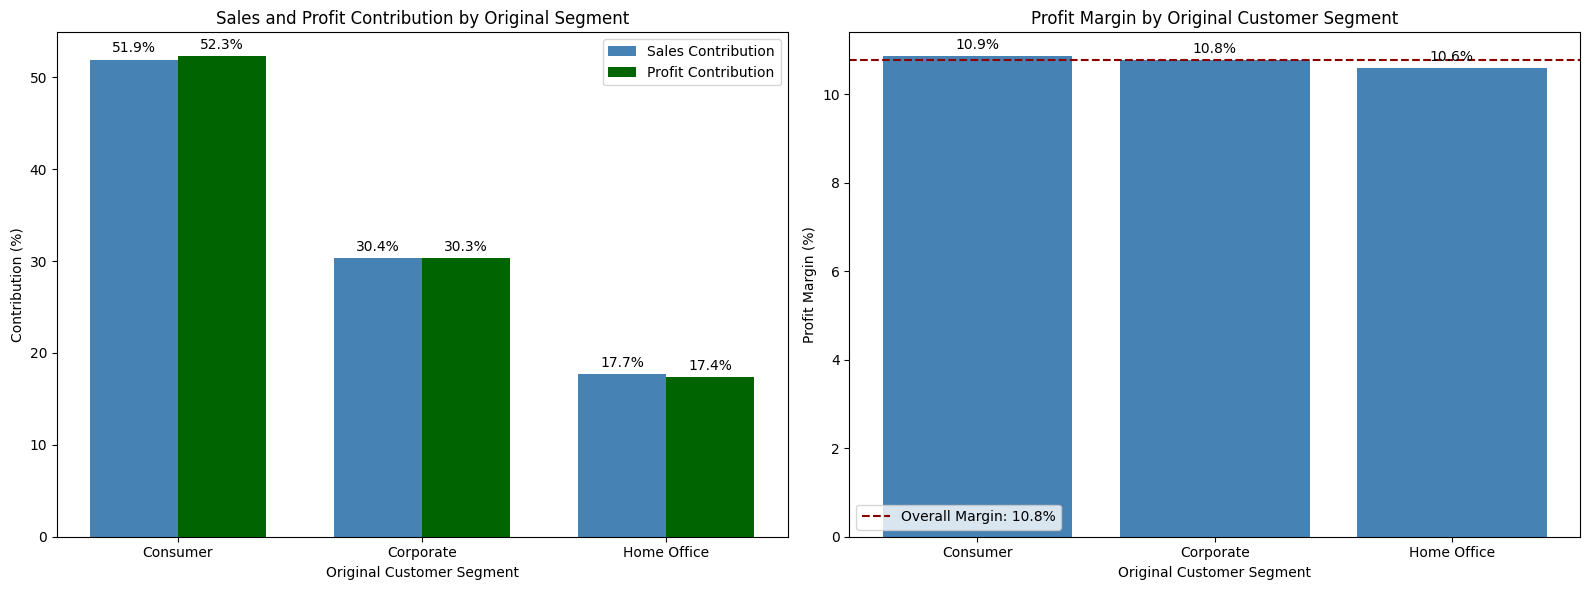

In [78]:
# ==========================================================
# Step 7.1 Original Customer Segment Analysis
# ==========================================================

# ----------------------------------------------------------
# 1. Define core columns
# ----------------------------------------------------------

customer_id_col = "Customer Id"
order_id_col = "Order Id"
order_item_id_col = "Order Item Id"
order_date_col = "order date (DateOrders)"
sales_col = "Sales"
profit_col = "Order Profit Per Order"
original_segment_col = "Customer Segment"

required_cols = [
    customer_id_col,
    order_id_col,
    order_item_id_col,
    order_date_col,
    sales_col,
    profit_col,
    original_segment_col
]

missing_cols = [
    col for col in required_cols
    if col not in df_clean.columns
]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df_clean[order_date_col] = pd.to_datetime(
    df_clean[order_date_col],
    errors="coerce"
)

# ----------------------------------------------------------
# 2. Validate customer-to-segment relationship
# ----------------------------------------------------------

segment_count_per_customer = (
    df_clean
    .groupby(customer_id_col, observed=True)[original_segment_col]
    .nunique()
)

multi_segment_customer_count = (
    segment_count_per_customer > 1
).sum()

print(
    "Customers assigned to more than one original segment:",
    f"{multi_segment_customer_count:,}"
)

# If a customer appears in multiple original segments,
# use the most frequently observed segment.
customer_original_segment = (
    df_clean
    .groupby(customer_id_col, observed=True)[original_segment_col]
    .agg(
        lambda values: (
            values.mode().iloc[0]
            if not values.mode().empty
            else values.iloc[0]
        )
    )
    .rename(original_segment_col)
)

# ----------------------------------------------------------
# 3. Build customer-level dataset
# ----------------------------------------------------------

customer_level_df = (
    df_clean
    .groupby(customer_id_col, observed=True)
    .agg(
        total_orders=(order_id_col, "nunique"),
        total_order_items=(order_item_id_col, "nunique"),
        total_sales=(sales_col, "sum"),
        total_profit=(profit_col, "sum"),
        first_order_date=(order_date_col, "min"),
        last_order_date=(order_date_col, "max")
    )
    .join(customer_original_segment)
    .reset_index()
)

customer_level_df["avg_order_value"] = np.where(
    customer_level_df["total_orders"] > 0,
    customer_level_df["total_sales"]
    / customer_level_df["total_orders"],
    np.nan
)

customer_level_df["profit_margin"] = np.where(
    customer_level_df["total_sales"] != 0,
    customer_level_df["total_profit"]
    / customer_level_df["total_sales"]
    * 100,
    np.nan
)

print("Customer-level dataset shape:", customer_level_df.shape)
print(
    "Unique customers:",
    f"{customer_level_df[customer_id_col].nunique():,}"
)

# ----------------------------------------------------------
# 4. Original customer segment summary
# ----------------------------------------------------------

original_segment_summary = (
    customer_level_df
    .groupby(original_segment_col, observed=True)
    .agg(
        customer_count=(customer_id_col, "nunique"),
        total_orders=("total_orders", "sum"),
        total_sales=("total_sales", "sum"),
        total_profit=("total_profit", "sum"),
        avg_sales_per_customer=("total_sales", "mean"),
        median_sales_per_customer=("total_sales", "median"),
        avg_orders_per_customer=("total_orders", "mean"),
        avg_order_value=("avg_order_value", "mean")
    )
    .reset_index()
)

original_segment_summary["customer_pct"] = (
    original_segment_summary["customer_count"]
    / original_segment_summary["customer_count"].sum()
    * 100
)

original_segment_summary["sales_contribution_pct"] = (
    original_segment_summary["total_sales"]
    / original_segment_summary["total_sales"].sum()
    * 100
)

original_segment_summary["profit_contribution_pct"] = (
    original_segment_summary["total_profit"]
    / original_segment_summary["total_profit"].sum()
    * 100
)

original_segment_summary["profit_margin"] = np.where(
    original_segment_summary["total_sales"] != 0,
    original_segment_summary["total_profit"]
    / original_segment_summary["total_sales"]
    * 100,
    np.nan
)

original_segment_summary = (
    original_segment_summary
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)

print("\nOriginal Customer Segment Summary")

display(
    original_segment_summary.style.format({
        "customer_count": "{:,.0f}",
        "total_orders": "{:,.0f}",
        "total_sales": "{:,.2f}",
        "total_profit": "{:,.2f}",
        "avg_sales_per_customer": "{:,.2f}",
        "median_sales_per_customer": "{:,.2f}",
        "avg_orders_per_customer": "{:,.2f}",
        "avg_order_value": "{:,.2f}",
        "customer_pct": "{:.2f}%",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)

# ----------------------------------------------------------
# 5. Visualization
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

segment_positions = np.arange(
    len(original_segment_summary)
)

bar_width = 0.36

# Sales and profit contribution
sales_bars = axes[0].bar(
    segment_positions - bar_width / 2,
    original_segment_summary["sales_contribution_pct"],
    width=bar_width,
    color="steelblue",
    label="Sales Contribution"
)

profit_bars = axes[0].bar(
    segment_positions + bar_width / 2,
    original_segment_summary["profit_contribution_pct"],
    width=bar_width,
    color="darkgreen",
    label="Profit Contribution"
)

axes[0].set_xticks(segment_positions)
axes[0].set_xticklabels(
    original_segment_summary[original_segment_col]
)
axes[0].set_title(
    "Sales and Profit Contribution by Original Segment"
)
axes[0].set_xlabel("Original Customer Segment")
axes[0].set_ylabel("Contribution (%)")
axes[0].legend()

axes[0].bar_label(
    sales_bars,
    labels=[
        f"{value:.1f}%"
        for value in original_segment_summary[
            "sales_contribution_pct"
        ]
    ],
    padding=3
)

axes[0].bar_label(
    profit_bars,
    labels=[
        f"{value:.1f}%"
        for value in original_segment_summary[
            "profit_contribution_pct"
        ]
    ],
    padding=3
)

# Profit margin
margin_bars = axes[1].bar(
    original_segment_summary[original_segment_col],
    original_segment_summary["profit_margin"],
    color="steelblue"
)

overall_customer_profit_margin = (
    customer_level_df["total_profit"].sum()
    / customer_level_df["total_sales"].sum()
    * 100
)

axes[1].axhline(
    overall_customer_profit_margin,
    color="darkred",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall Margin: "
        f"{overall_customer_profit_margin:.1f}%"
    )
)

axes[1].set_title(
    "Profit Margin by Original Customer Segment"
)
axes[1].set_xlabel("Original Customer Segment")
axes[1].set_ylabel("Profit Margin (%)")
axes[1].legend()

axes[1].bar_label(
    margin_bars,
    labels=[
        f"{value:.1f}%"
        for value in original_segment_summary[
            "profit_margin"
        ]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

## Step 7.2 Customer Value Segmentation

Customer Value Segmentation Summary


,customer_value_segment,customer_count,total_orders,total_sales,total_profit,avg_sales_per_customer,median_sales_per_customer,avg_profit_per_customer,avg_orders_per_customer,avg_order_value,avg_recency,customer_pct,sales_contribution_pct,profit_contribution_pct,profit_margin,cumulative_sales_pct,cumulative_profit_pct
0,VIP,"4,131","27,695","18,361,049.29","1,997,464.25","4,444.70","4,181.51",483.53,6.70,681.38,255.8,20.00%,49.91%,50.35%,10.88%,49.91%,50.35%
1,High Value,"4,130","18,719","10,763,903.03","1,096,029.25","2,606.27","2,589.64",265.38,4.53,606.24,307.5,20.00%,29.26%,27.63%,10.18%,79.18%,77.98%
2,Medium Value,"4,130","10,940","5,735,786.64","651,926.75","1,388.81","1,499.83",157.85,2.65,633.23,373.1,20.00%,15.59%,16.43%,11.37%,94.77%,94.42%
3,Medium-Low Value,"4,130","4,260","1,548,960.80","182,963.19",375.05,357.10,44.30,1.03,369.07,104.4,20.00%,4.21%,4.61%,11.81%,98.98%,99.03%
4,Low Value,"4,131","4,138","375,035.26","38,519.53",90.79,59.08,9.32,1.00,90.64,64.6,20.00%,1.02%,0.97%,10.27%,100.00%,100.00%


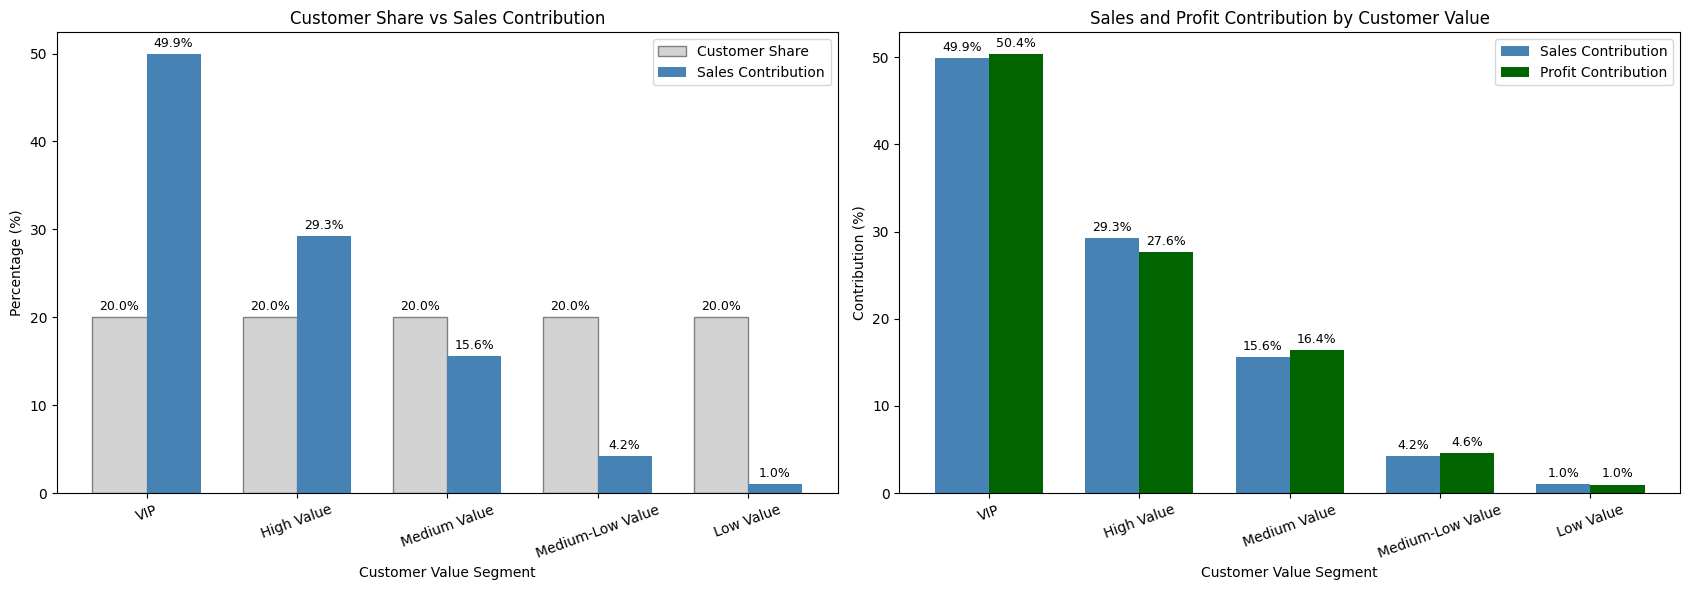

Customer Value Segmentation Summary
VIP Customer Share: 20.00%
VIP Sales Contribution: 49.91%
VIP Profit Contribution: 50.35%
VIP Profit Margin: 10.88%
VIP and High Value Customer Share: 40.00%
VIP and High Value Sales Contribution: 79.18%
VIP and High Value Profit Contribution: 77.98%


In [79]:
# ==========================================================
# Step 7.2 Customer Value Segmentation
# ==========================================================

# ----------------------------------------------------------
# 1. Create customer value tiers
# ----------------------------------------------------------
# Rank before qcut prevents duplicated total_sales values
# from causing invalid quantile boundaries.

customer_value_df = customer_level_df.copy()

customer_value_df["customer_value_segment"] = pd.qcut(
    customer_value_df["total_sales"].rank(
        method="first",
        ascending=True
    ),
    q=5,
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

value_segment_order = [
    "VIP",
    "High Value",
    "Medium Value",
    "Medium-Low Value",
    "Low Value"
]

customer_value_df["customer_value_segment"] = (
    pd.Categorical(
        customer_value_df["customer_value_segment"],
        categories=value_segment_order,
        ordered=True
    )
)

# ----------------------------------------------------------
# 2. Add Recency, Frequency, and Monetary metrics
# ----------------------------------------------------------
# RFM is used later as a customer profiling framework,
# not as another segmentation method.

snapshot_date = (
    customer_value_df["last_order_date"].max()
    + pd.Timedelta(days=1)
)

customer_value_df["recency"] = (
    snapshot_date
    - customer_value_df["last_order_date"]
).dt.days

customer_value_df["frequency"] = (
    customer_value_df["total_orders"]
)

customer_value_df["monetary"] = (
    customer_value_df["total_sales"]
)

# ----------------------------------------------------------
# 3. Summarize customer value segments
# ----------------------------------------------------------

customer_value_summary = (
    customer_value_df
    .groupby(
        "customer_value_segment",
        observed=False
    )
    .agg(
        customer_count=(customer_id_col, "nunique"),
        total_orders=("total_orders", "sum"),
        total_sales=("total_sales", "sum"),
        total_profit=("total_profit", "sum"),
        avg_sales_per_customer=("total_sales", "mean"),
        median_sales_per_customer=("total_sales", "median"),
        avg_profit_per_customer=("total_profit", "mean"),
        avg_orders_per_customer=("total_orders", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_recency=("recency", "mean")
    )
    .reset_index()
)

customer_value_summary["customer_pct"] = (
    customer_value_summary["customer_count"]
    / customer_value_summary["customer_count"].sum()
    * 100
)

customer_value_summary["sales_contribution_pct"] = (
    customer_value_summary["total_sales"]
    / customer_value_summary["total_sales"].sum()
    * 100
)

customer_value_summary["profit_contribution_pct"] = (
    customer_value_summary["total_profit"]
    / customer_value_summary["total_profit"].sum()
    * 100
)

customer_value_summary["profit_margin"] = np.where(
    customer_value_summary["total_sales"] != 0,
    customer_value_summary["total_profit"]
    / customer_value_summary["total_sales"]
    * 100,
    np.nan
)

customer_value_summary["cumulative_sales_pct"] = (
    customer_value_summary[
        "sales_contribution_pct"
    ].cumsum()
)

customer_value_summary["cumulative_profit_pct"] = (
    customer_value_summary[
        "profit_contribution_pct"
    ].cumsum()
)

print("Customer Value Segmentation Summary")

display(
    customer_value_summary.style.format({
        "customer_count": "{:,.0f}",
        "total_orders": "{:,.0f}",
        "total_sales": "{:,.2f}",
        "total_profit": "{:,.2f}",
        "avg_sales_per_customer": "{:,.2f}",
        "median_sales_per_customer": "{:,.2f}",
        "avg_profit_per_customer": "{:,.2f}",
        "avg_orders_per_customer": "{:,.2f}",
        "avg_order_value": "{:,.2f}",
        "avg_recency": "{:,.1f}",
        "customer_pct": "{:.2f}%",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%",
        "cumulative_sales_pct": "{:.2f}%",
        "cumulative_profit_pct": "{:.2f}%"
    })
)

# ----------------------------------------------------------
# 4. Visualization
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(17, 6)
)

value_positions = np.arange(
    len(customer_value_summary)
)

bar_width = 0.36

# Customer share vs sales contribution
customer_share_bars = axes[0].bar(
    value_positions - bar_width / 2,
    customer_value_summary["customer_pct"],
    width=bar_width,
    color="lightgray",
    edgecolor="gray",
    label="Customer Share"
)

sales_share_bars = axes[0].bar(
    value_positions + bar_width / 2,
    customer_value_summary["sales_contribution_pct"],
    width=bar_width,
    color="steelblue",
    label="Sales Contribution"
)

axes[0].set_xticks(value_positions)
axes[0].set_xticklabels(
    customer_value_summary[
        "customer_value_segment"
    ].astype(str),
    rotation=20
)
axes[0].set_title(
    "Customer Share vs Sales Contribution"
)
axes[0].set_xlabel("Customer Value Segment")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend()

axes[0].bar_label(
    customer_share_bars,
    labels=[
        f"{value:.1f}%"
        for value in customer_value_summary[
            "customer_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

axes[0].bar_label(
    sales_share_bars,
    labels=[
        f"{value:.1f}%"
        for value in customer_value_summary[
            "sales_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

# Sales vs profit contribution
sales_bars = axes[1].bar(
    value_positions - bar_width / 2,
    customer_value_summary["sales_contribution_pct"],
    width=bar_width,
    color="steelblue",
    label="Sales Contribution"
)

profit_bars = axes[1].bar(
    value_positions + bar_width / 2,
    customer_value_summary["profit_contribution_pct"],
    width=bar_width,
    color="darkgreen",
    label="Profit Contribution"
)

axes[1].set_xticks(value_positions)
axes[1].set_xticklabels(
    customer_value_summary[
        "customer_value_segment"
    ].astype(str),
    rotation=20
)
axes[1].set_title(
    "Sales and Profit Contribution by Customer Value"
)
axes[1].set_xlabel("Customer Value Segment")
axes[1].set_ylabel("Contribution (%)")
axes[1].legend()

axes[1].bar_label(
    sales_bars,
    labels=[
        f"{value:.1f}%"
        for value in customer_value_summary[
            "sales_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

axes[1].bar_label(
    profit_bars,
    labels=[
        f"{value:.1f}%"
        for value in customer_value_summary[
            "profit_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 5. Key statistics
# ----------------------------------------------------------

vip_summary = (
    customer_value_summary
    .loc[
        customer_value_summary[
            "customer_value_segment"
        ].astype(str) == "VIP"
    ]
    .iloc[0]
)

top_two_value_summary = (
    customer_value_summary
    .loc[
        customer_value_summary[
            "customer_value_segment"
        ].astype(str).isin(
            ["VIP", "High Value"]
        )
    ]
)

print("=" * 70)
print("Customer Value Segmentation Summary")
print("=" * 70)

print(
    f"VIP Customer Share: "
    f"{vip_summary['customer_pct']:.2f}%"
)

print(
    f"VIP Sales Contribution: "
    f"{vip_summary['sales_contribution_pct']:.2f}%"
)

print(
    f"VIP Profit Contribution: "
    f"{vip_summary['profit_contribution_pct']:.2f}%"
)

print(
    f"VIP Profit Margin: "
    f"{vip_summary['profit_margin']:.2f}%"
)

print(
    f"VIP and High Value Customer Share: "
    f"{top_two_value_summary['customer_pct'].sum():.2f}%"
)

print(
    f"VIP and High Value Sales Contribution: "
    f"{top_two_value_summary['sales_contribution_pct'].sum():.2f}%"
)

print(
    f"VIP and High Value Profit Contribution: "
    f"{top_two_value_summary['profit_contribution_pct'].sum():.2f}%"
)

## Step 7.3 High-Value Customer Profile Analysis

RFM Profile by Customer Value Segment


,customer_value_segment,customer_count,avg_recency,median_recency,avg_frequency,median_frequency,avg_monetary,median_monetary,avg_profit,avg_order_value
0,VIP,"4,131",255.8,221.0,6.70,6.00,"4,444.70","4,181.51",483.53,681.38
1,High Value,"4,130",307.5,268.0,4.53,4.00,"2,606.27","2,589.64",265.38,606.24
2,Medium Value,"4,130",373.1,318.0,2.65,3.00,"1,388.81","1,499.83",157.85,633.23
3,Medium-Low Value,"4,130",104.4,78.0,1.03,1.00,375.05,357.10,44.30,369.07
4,Low Value,"4,131",64.6,49.0,1.00,1.00,90.79,59.08,9.32,90.64


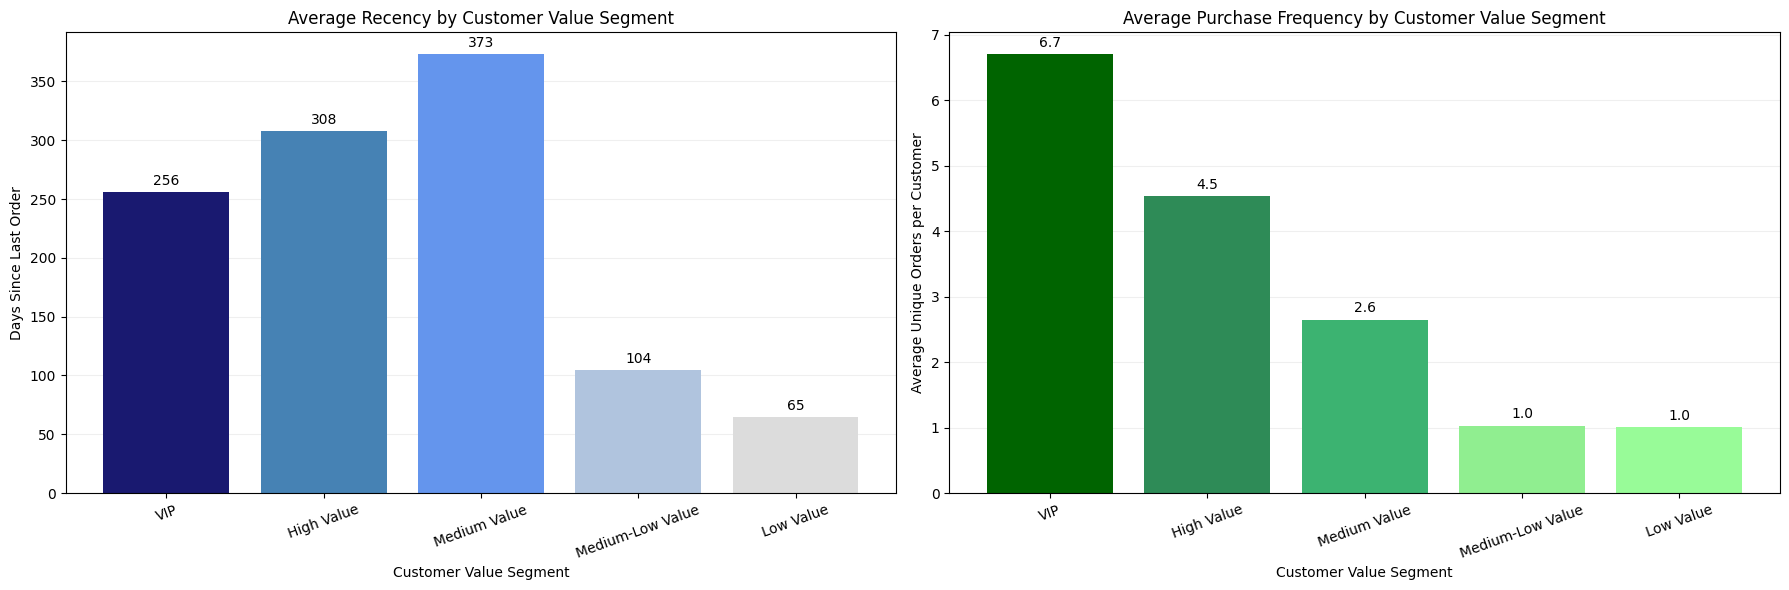

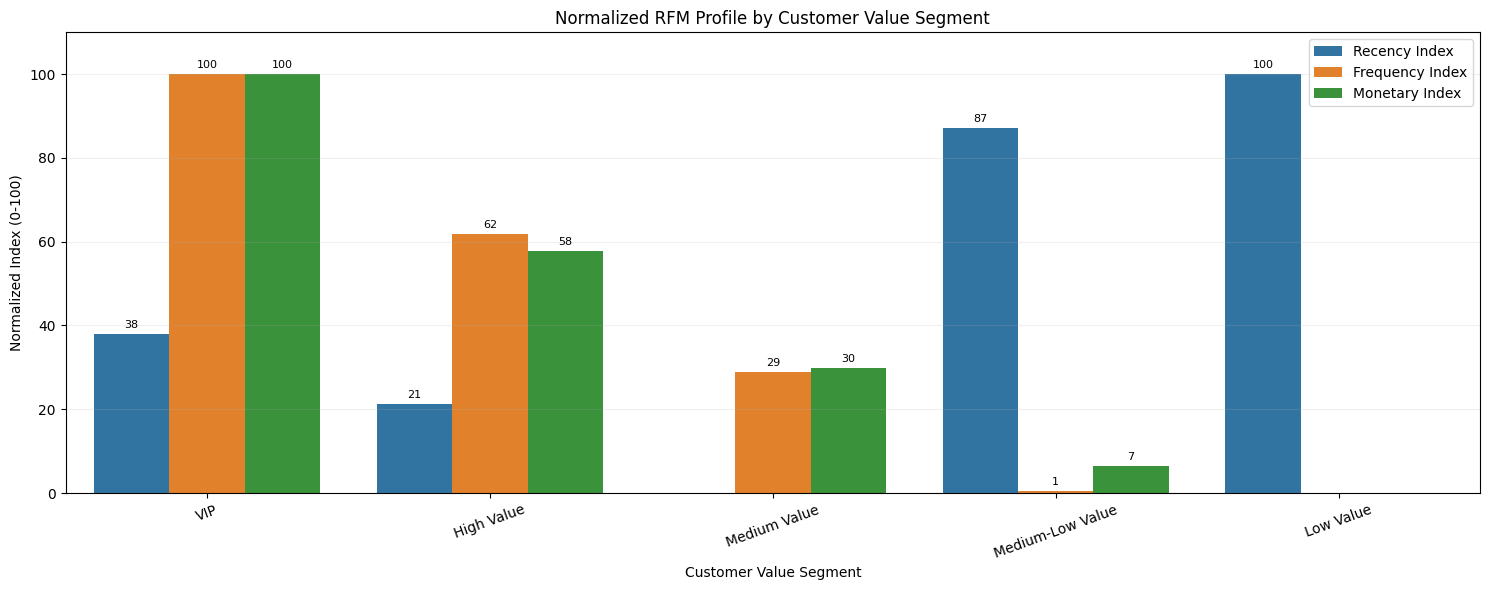


VIP and High Value Customers: 8,261 (40.00% of customers)
Order-item records without customer value segment: 0

Top Product Categories among VIP and High Value Customers


,customer_value_segment,Category Name,sales,profit,order_count,customer_count,sales_share_pct,profit_margin
0,High Value,Fishing,"2,105,494.78","219,167.79","4,672","3,185",19.56%,10.41%
1,High Value,Cleats,"1,398,847.26","147,704.19","6,457","3,532",13.00%,10.56%
2,High Value,Camping & Hiking,"1,249,716.73","125,026.70","3,749","2,691",11.61%,10.00%
3,High Value,Cardio Equipment,"1,137,697.02","111,196.58","3,567","2,632",10.57%,9.77%
4,High Value,Water Sports,"1,009,499.65","99,122.86","4,470","2,931",9.38%,9.82%
5,High Value,Women's Apparel,"999,900.00","108,741.85","5,799","3,313",9.29%,10.88%
6,High Value,Indoor/Outdoor Games,"935,225.75","95,617.92","5,407","3,236",8.69%,10.22%
7,High Value,Men's Footwear,"934,498.15","97,832.84","6,073","3,401",8.68%,10.47%
8,High Value,Shop By Sport,"428,626.01","36,174.22","3,316","2,394",3.98%,8.44%
9,High Value,Electronics,"114,931.44","10,239.93",974,885,1.07%,8.91%


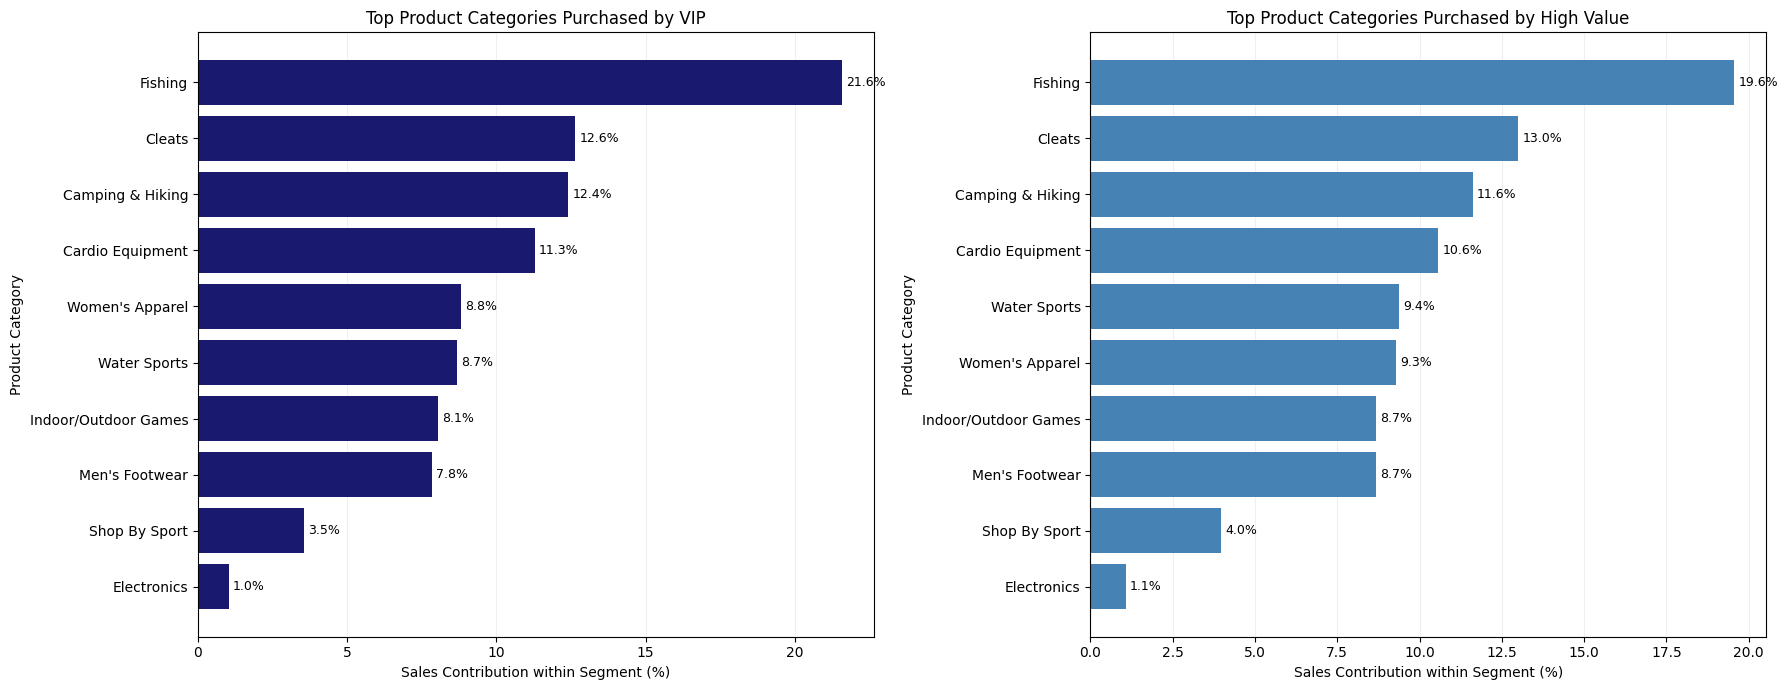


High-value orders with multiple shipping modes: 0

Shipping Mode Profile


,customer_value_segment,Shipping Mode,order_count,order_share_pct
0,High Value,First Class,"2,901",15.50%
1,High Value,Same Day,953,5.09%
2,High Value,Second Class,"3,604",19.25%
3,High Value,Standard Class,"11,261",60.16%
4,VIP,First Class,"4,282",15.46%
5,VIP,Same Day,"1,518",5.48%
6,VIP,Second Class,"5,343",19.29%
7,VIP,Standard Class,"16,552",59.77%


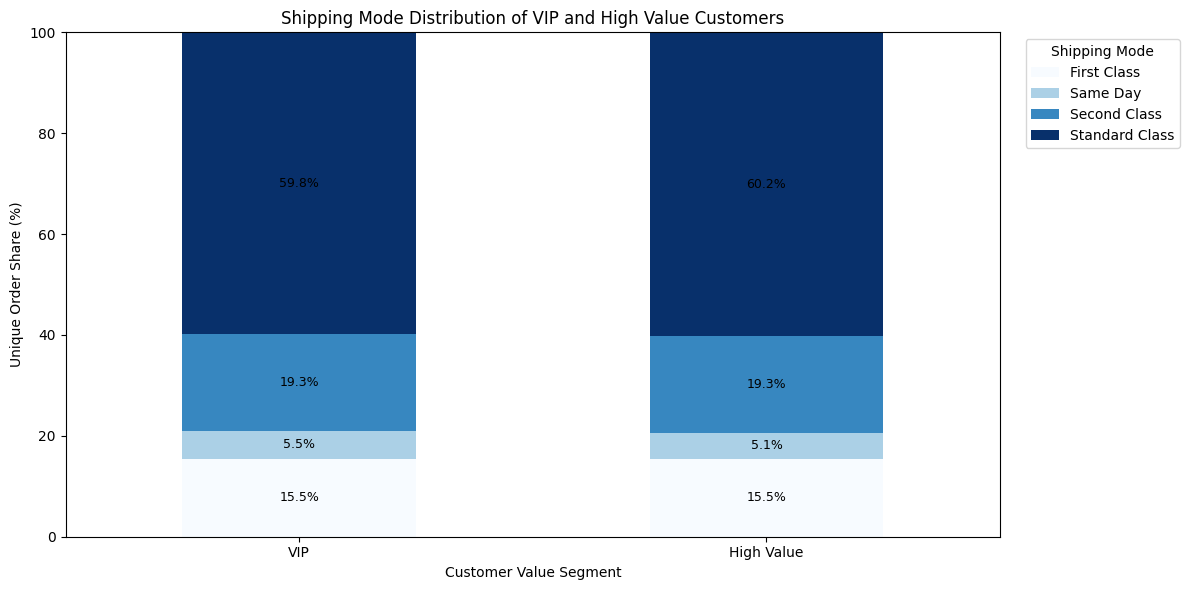


Original Customer Segment Profile


/tmp/ipykernel_58/758754100.py:856: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / original_segment_profile.groupby(
/tmp/ipykernel_58/758754100.py:868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / original_segment_profile.groupby(


,customer_value_segment,Customer Segment,customer_count,total_sales,total_profit,customer_share_pct,sales_share_pct,profit_margin
0,VIP,Consumer,"2,146","9,540,629.56","1,037,983.16",51.95%,51.96%,10.88%
1,VIP,Corporate,"1,253","5,597,962.07","608,043.97",30.33%,30.49%,10.86%
2,VIP,Home Office,732,"3,222,457.66","351,437.12",17.72%,17.55%,10.91%
3,High Value,Consumer,"2,129","5,554,097.85","561,971.96",51.55%,51.60%,10.12%
4,High Value,Corporate,"1,256","3,267,695.95","335,253.80",30.41%,30.36%,10.26%
5,High Value,Home Office,745,"1,942,109.23","198,803.49",18.04%,18.04%,10.24%


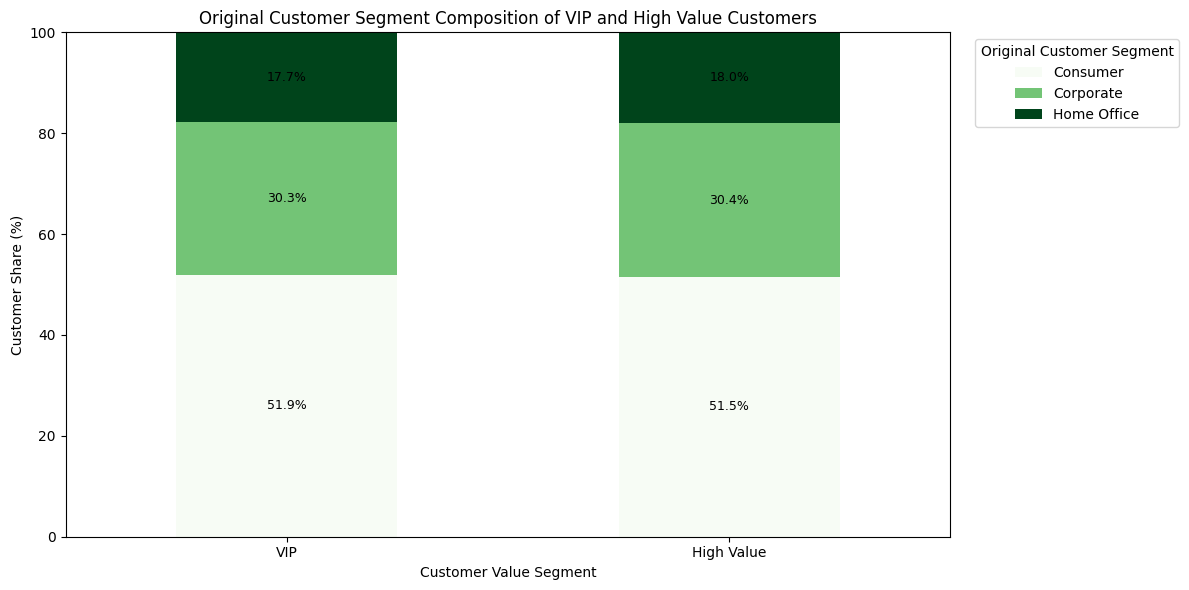


Customer Profile Validation
RFM segment customer total equals customer-level total: True

Shipping mode share by value segment:
  High Value: 100.00%
  VIP: 100.00%

Original customer segment share by value segment:
  VIP: 100.00%
  High Value: 100.00%
  Medium Value: 0.00%
  Medium-Low Value: 0.00%
  Low Value: 0.00%

High-Value Customer Profile Summary
VIP Average Recency: 255.8 days
VIP Average Frequency: 6.70 orders
VIP Average Monetary Value: 4,444.70
High Value Average Recency: 307.5 days
High Value Average Frequency: 4.53 orders
High Value Average Monetary Value: 2,606.27
VIP Top Product Category: Fishing (21.57% of VIP sales)
High Value Top Product Category: Fishing (19.56% of High Value sales)
VIP Most-used Shipping Mode: Standard Class (59.77% of VIP orders)
High Value Most-used Shipping Mode: Standard Class (60.16% of High Value orders)
VIP Largest Original Customer Segment: Consumer (51.95% of VIP customers)
High Value Largest Original Customer Segment: Consumer (51.55% of

/tmp/ipykernel_58/758754100.py:996: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("customer_value_segment")[


In [80]:
# ==========================================================
# Step 7.3 High-Value Customer Profile Analysis
# ==========================================================
#
# Analysis scope:
# 1. Compare RFM characteristics across all five value segments
# 2. Analyze product preferences of VIP and High Value customers
# 3. Analyze shipping modes used by VIP and High Value customers
# 4. Analyze the original customer segment composition
# 5. Generate key statistics for business interpretation
#
# Notes:
# - RFM is used as a profiling framework, not as another
#   customer segmentation method.
# - Monetary is expected to increase across value tiers
#   because the value segments are defined by total sales.
# - Product, shipping, and customer profile analyses focus
#   on VIP and High Value customers.
# ==========================================================


# ----------------------------------------------------------
# 1. Define analysis scope
# ----------------------------------------------------------

high_value_segments = [
    "VIP",
    "High Value"
]

required_customer_cols = [
    customer_id_col,
    original_segment_col,
    "customer_value_segment",
    "recency",
    "frequency",
    "monetary",
    "total_profit",
    "avg_order_value"
]

missing_customer_cols = [
    col for col in required_customer_cols
    if col not in customer_value_df.columns
]

if missing_customer_cols:
    raise KeyError(
        "Missing required customer-level columns: "
        f"{missing_customer_cols}"
    )

required_order_item_cols = [
    customer_id_col,
    order_id_col,
    sales_col,
    profit_col,
    "Category Name",
    "Shipping Mode"
]

missing_order_item_cols = [
    col for col in required_order_item_cols
    if col not in df_clean.columns
]

if missing_order_item_cols:
    raise KeyError(
        "Missing required order-item columns: "
        f"{missing_order_item_cols}"
    )


# ----------------------------------------------------------
# 2. RFM profile across all five customer value segments
# ----------------------------------------------------------

all_value_rfm_summary = (
    customer_value_df
    .groupby(
        "customer_value_segment",
        observed=False
    )
    .agg(
        customer_count=(
            customer_id_col,
            "nunique"
        ),
        avg_recency=(
            "recency",
            "mean"
        ),
        median_recency=(
            "recency",
            "median"
        ),
        avg_frequency=(
            "frequency",
            "mean"
        ),
        median_frequency=(
            "frequency",
            "median"
        ),
        avg_monetary=(
            "monetary",
            "mean"
        ),
        median_monetary=(
            "monetary",
            "median"
        ),
        avg_profit=(
            "total_profit",
            "mean"
        ),
        avg_order_value=(
            "avg_order_value",
            "mean"
        )
    )
    .reset_index()
)

# Ensure the intended display order:
# VIP -> High Value -> Medium Value
# -> Medium-Low Value -> Low Value

all_value_rfm_summary[
    "customer_value_segment"
] = pd.Categorical(
    all_value_rfm_summary[
        "customer_value_segment"
    ],
    categories=value_segment_order,
    ordered=True
)

all_value_rfm_summary = (
    all_value_rfm_summary
    .sort_values("customer_value_segment")
    .reset_index(drop=True)
)

print("RFM Profile by Customer Value Segment")

display(
    all_value_rfm_summary.style.format({
        "customer_count": "{:,.0f}",
        "avg_recency": "{:,.1f}",
        "median_recency": "{:,.1f}",
        "avg_frequency": "{:,.2f}",
        "median_frequency": "{:,.2f}",
        "avg_monetary": "{:,.2f}",
        "median_monetary": "{:,.2f}",
        "avg_profit": "{:,.2f}",
        "avg_order_value": "{:,.2f}"
    })
)


# ----------------------------------------------------------
# 3. Recency and Frequency charts for all five segments
# ----------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6)
)

segment_labels = (
    all_value_rfm_summary[
        "customer_value_segment"
    ]
    .astype(str)
)

recency_colors = [
    "midnightblue",
    "steelblue",
    "cornflowerblue",
    "lightsteelblue",
    "gainsboro"
]

frequency_colors = [
    "darkgreen",
    "seagreen",
    "mediumseagreen",
    "lightgreen",
    "palegreen"
]

# Average Recency
recency_bars = axes[0].bar(
    segment_labels,
    all_value_rfm_summary["avg_recency"],
    color=recency_colors
)

axes[0].set_title(
    "Average Recency by Customer Value Segment"
)
axes[0].set_xlabel(
    "Customer Value Segment"
)
axes[0].set_ylabel(
    "Days Since Last Order"
)
axes[0].tick_params(
    axis="x",
    rotation=20
)
axes[0].grid(
    axis="y",
    alpha=0.2
)
axes[0].set_axisbelow(True)

axes[0].bar_label(
    recency_bars,
    labels=[
        f"{value:,.0f}"
        for value in all_value_rfm_summary[
            "avg_recency"
        ]
    ],
    padding=3,
    fontsize=10
)

# Average Frequency
frequency_bars = axes[1].bar(
    segment_labels,
    all_value_rfm_summary["avg_frequency"],
    color=frequency_colors
)

axes[1].set_title(
    "Average Purchase Frequency by Customer Value Segment"
)
axes[1].set_xlabel(
    "Customer Value Segment"
)
axes[1].set_ylabel(
    "Average Unique Orders per Customer"
)
axes[1].tick_params(
    axis="x",
    rotation=20
)
axes[1].grid(
    axis="y",
    alpha=0.2
)
axes[1].set_axisbelow(True)

axes[1].bar_label(
    frequency_bars,
    labels=[
        f"{value:,.1f}"
        for value in all_value_rfm_summary[
            "avg_frequency"
        ]
    ],
    padding=3,
    fontsize=10
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 4. Normalized RFM profile across all five segments
# ----------------------------------------------------------
#
# Recency, Frequency, and Monetary use different units.
# Convert all three metrics into comparable 0-100 indexes.
#
# Recency is reversed:
# fewer days since the last order = higher Recency Index.
#
# Monetary is included for context. However, its increase
# across the five value tiers is expected because customer
# value segments are defined based on total sales.
# ----------------------------------------------------------

rfm_profile_df = (
    all_value_rfm_summary[
        [
            "customer_value_segment",
            "avg_recency",
            "avg_frequency",
            "avg_monetary"
        ]
    ]
    .copy()
)


def min_max_index(series):
    """
    Convert a numeric series into a 0-100 index.
    """

    series_min = series.min()
    series_max = series.max()

    if series_max == series_min:
        return pd.Series(
            100.0,
            index=series.index
        )

    return (
        (series - series_min)
        / (series_max - series_min)
        * 100
    )


rfm_profile_df["Recency Index"] = (
    100
    - min_max_index(
        rfm_profile_df["avg_recency"]
    )
)

rfm_profile_df["Frequency Index"] = (
    min_max_index(
        rfm_profile_df["avg_frequency"]
    )
)

rfm_profile_df["Monetary Index"] = (
    min_max_index(
        rfm_profile_df["avg_monetary"]
    )
)

rfm_profile_long = (
    rfm_profile_df
    .melt(
        id_vars="customer_value_segment",
        value_vars=[
            "Recency Index",
            "Frequency Index",
            "Monetary Index"
        ],
        var_name="RFM Metric",
        value_name="Index"
    )
)

plt.figure(figsize=(15, 6))

rfm_axis = sns.barplot(
    data=rfm_profile_long,
    x="customer_value_segment",
    y="Index",
    hue="RFM Metric"
)

plt.title(
    "Normalized RFM Profile by Customer Value Segment"
)
plt.xlabel(
    "Customer Value Segment"
)
plt.ylabel(
    "Normalized Index (0-100)"
)
plt.xticks(rotation=20)
plt.ylim(0, 110)
plt.grid(
    axis="y",
    alpha=0.2
)
plt.legend(
    title="",
    loc="upper right"
)

for container in rfm_axis.containers:
    rfm_axis.bar_label(
        container,
        labels=[
            f"{value:.0f}"
            if value > 0
            else ""
            for value in container.datavalues
        ],
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 5. Select VIP and High Value customers
# ----------------------------------------------------------

high_value_customer_df = (
    customer_value_df
    .loc[
        customer_value_df[
            "customer_value_segment"
        ]
        .astype(str)
        .isin(high_value_segments)
    ]
    .copy()
)

high_value_customer_count = (
    high_value_customer_df[
        customer_id_col
    ]
    .nunique()
)

total_customer_count = (
    customer_value_df[
        customer_id_col
    ]
    .nunique()
)

high_value_customer_pct = (
    high_value_customer_count
    / total_customer_count
    * 100
)

print(
    "\nVIP and High Value Customers:",
    f"{high_value_customer_count:,}",
    f"({high_value_customer_pct:.2f}% of customers)"
)


# ----------------------------------------------------------
# 6. Join customer value segment back to order-item data
# ----------------------------------------------------------

customer_value_mapping = (
    customer_value_df[
        [
            customer_id_col,
            "customer_value_segment"
        ]
    ]
    .drop_duplicates(
        subset=[customer_id_col]
    )
    .copy()
)

customer_value_mapping[
    "customer_value_segment"
] = (
    customer_value_mapping[
        "customer_value_segment"
    ]
    .astype(str)
)

profile_order_item_df = (
    df_clean
    .merge(
        customer_value_mapping,
        on=customer_id_col,
        how="left",
        validate="many_to_one"
    )
)

# Check whether all order-item records received
# a customer value segment.

unmapped_order_item_count = (
    profile_order_item_df[
        "customer_value_segment"
    ]
    .isna()
    .sum()
)

print(
    "Order-item records without customer value segment:",
    f"{unmapped_order_item_count:,}"
)

high_value_order_item_df = (
    profile_order_item_df
    .loc[
        profile_order_item_df[
            "customer_value_segment"
        ]
        .isin(high_value_segments)
    ]
    .copy()
)


# ----------------------------------------------------------
# 7. Product category profile
# ----------------------------------------------------------
#
# Use sales contribution rather than order-item count.
# This identifies the categories that generate the most
# customer value within VIP and High Value groups.
# ----------------------------------------------------------

category_profile = (
    high_value_order_item_df
    .groupby(
        [
            "customer_value_segment",
            "Category Name"
        ],
        observed=True
    )
    .agg(
        sales=(
            sales_col,
            "sum"
        ),
        profit=(
            profit_col,
            "sum"
        ),
        order_count=(
            order_id_col,
            "nunique"
        ),
        customer_count=(
            customer_id_col,
            "nunique"
        )
    )
    .reset_index()
)

category_profile["sales_share_pct"] = (
    category_profile["sales"]
    / category_profile.groupby(
        "customer_value_segment"
    )["sales"].transform("sum")
    * 100
)

category_profile["profit_margin"] = np.where(
    category_profile["sales"] != 0,
    category_profile["profit"]
    / category_profile["sales"]
    * 100,
    np.nan
)

top_category_profile = (
    category_profile
    .sort_values(
        [
            "customer_value_segment",
            "sales"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "customer_value_segment",
        group_keys=False
    )
    .head(10)
    .reset_index(drop=True)
)

print(
    "\nTop Product Categories among "
    "VIP and High Value Customers"
)

display(
    top_category_profile.style.format({
        "sales": "{:,.2f}",
        "profit": "{:,.2f}",
        "order_count": "{:,.0f}",
        "customer_count": "{:,.0f}",
        "sales_share_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)

# Product category charts
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 7)
)

for ax, segment in zip(
    axes,
    high_value_segments
):

    segment_category_df = (
        top_category_profile
        .loc[
            top_category_profile[
                "customer_value_segment"
            ] == segment
        ]
        .sort_values(
            "sales_share_pct",
            ascending=True
        )
    )

    category_color = (
        "midnightblue"
        if segment == "VIP"
        else "steelblue"
    )

    category_bars = ax.barh(
        segment_category_df[
            "Category Name"
        ],
        segment_category_df[
            "sales_share_pct"
        ],
        color=category_color
    )

    ax.set_title(
        f"Top Product Categories Purchased by {segment}"
    )
    ax.set_xlabel(
        "Sales Contribution within Segment (%)"
    )
    ax.set_ylabel(
        "Product Category"
    )
    ax.grid(
        axis="x",
        alpha=0.2
    )
    ax.set_axisbelow(True)

    ax.bar_label(
        category_bars,
        labels=[
            f"{value:.1f}%"
            for value in segment_category_df[
                "sales_share_pct"
            ]
        ],
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 8. Shipping mode profile
# ----------------------------------------------------------
#
# Create one record per Order Id before aggregation.
# This avoids counting an order multiple times when one
# order contains multiple order items.
# ----------------------------------------------------------

shipping_consistency_check = (
    high_value_order_item_df
    .groupby(
        order_id_col,
        observed=True
    )["Shipping Mode"]
    .nunique()
)

multi_shipping_mode_orders = (
    shipping_consistency_check > 1
).sum()

print(
    "\nHigh-value orders with multiple shipping modes:",
    f"{multi_shipping_mode_orders:,}"
)

shipping_order_level_df = (
    high_value_order_item_df[
        [
            order_id_col,
            customer_id_col,
            "customer_value_segment",
            "Shipping Mode"
        ]
    ]
    .drop_duplicates(
        subset=[order_id_col]
    )
    .copy()
)

shipping_profile = (
    shipping_order_level_df
    .groupby(
        [
            "customer_value_segment",
            "Shipping Mode"
        ],
        observed=True
    )
    .agg(
        order_count=(
            order_id_col,
            "nunique"
        )
    )
    .reset_index()
)

shipping_profile["order_share_pct"] = (
    shipping_profile["order_count"]
    / shipping_profile.groupby(
        "customer_value_segment"
    )["order_count"].transform("sum")
    * 100
)

shipping_profile_pivot = (
    shipping_profile
    .pivot(
        index="customer_value_segment",
        columns="Shipping Mode",
        values="order_share_pct"
    )
    .fillna(0)
    .reindex(high_value_segments)
)

print("\nShipping Mode Profile")

display(
    shipping_profile.style.format({
        "order_count": "{:,.0f}",
        "order_share_pct": "{:.2f}%"
    })
)

shipping_axis = (
    shipping_profile_pivot
    .plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        colormap="Blues"
    )
)

shipping_axis.set_title(
    "Shipping Mode Distribution of "
    "VIP and High Value Customers"
)
shipping_axis.set_xlabel(
    "Customer Value Segment"
)
shipping_axis.set_ylabel(
    "Unique Order Share (%)"
)
shipping_axis.set_ylim(
    0,
    100
)
shipping_axis.tick_params(
    axis="x",
    rotation=0
)
shipping_axis.legend(
    title="Shipping Mode",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in shipping_axis.containers:

    shipping_labels = [
        f"{value:.1f}%"
        if value >= 3
        else ""
        for value in container.datavalues
    ]

    shipping_axis.bar_label(
        container,
        labels=shipping_labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 9. Original customer segment profile
# ----------------------------------------------------------
#
# Use unique customer count rather than order-item count.
# This shows the actual customer composition within VIP
# and High Value segments.
# ----------------------------------------------------------

original_segment_profile = (
    high_value_customer_df
    .groupby(
        [
            "customer_value_segment",
            original_segment_col
        ],
        observed=True
    )
    .agg(
        customer_count=(
            customer_id_col,
            "nunique"
        ),
        total_sales=(
            "total_sales",
            "sum"
        ),
        total_profit=(
            "total_profit",
            "sum"
        )
    )
    .reset_index()
)

original_segment_profile[
    "customer_share_pct"
] = (
    original_segment_profile[
        "customer_count"
    ]
    / original_segment_profile.groupby(
        "customer_value_segment"
    )["customer_count"].transform("sum")
    * 100
)

original_segment_profile[
    "sales_share_pct"
] = (
    original_segment_profile[
        "total_sales"
    ]
    / original_segment_profile.groupby(
        "customer_value_segment"
    )["total_sales"].transform("sum")
    * 100
)

original_segment_profile[
    "profit_margin"
] = np.where(
    original_segment_profile[
        "total_sales"
    ] != 0,
    original_segment_profile[
        "total_profit"
    ]
    / original_segment_profile[
        "total_sales"
    ]
    * 100,
    np.nan
)

original_segment_profile_pivot = (
    original_segment_profile
    .pivot(
        index="customer_value_segment",
        columns=original_segment_col,
        values="customer_share_pct"
    )
    .fillna(0)
    .reindex(high_value_segments)
)

print("\nOriginal Customer Segment Profile")

display(
    original_segment_profile.style.format({
        "customer_count": "{:,.0f}",
        "total_sales": "{:,.2f}",
        "total_profit": "{:,.2f}",
        "customer_share_pct": "{:.2f}%",
        "sales_share_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)

original_segment_axis = (
    original_segment_profile_pivot
    .plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        colormap="Greens"
    )
)

original_segment_axis.set_title(
    "Original Customer Segment Composition "
    "of VIP and High Value Customers"
)
original_segment_axis.set_xlabel(
    "Customer Value Segment"
)
original_segment_axis.set_ylabel(
    "Customer Share (%)"
)
original_segment_axis.set_ylim(
    0,
    100
)
original_segment_axis.tick_params(
    axis="x",
    rotation=0
)
original_segment_axis.legend(
    title="Original Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in original_segment_axis.containers:

    original_segment_labels = [
        f"{value:.1f}%"
        if value >= 3
        else ""
        for value in container.datavalues
    ]

    original_segment_axis.bar_label(
        container,
        labels=original_segment_labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 10. Final validation checks
# ----------------------------------------------------------

rfm_customer_total_check = (
    all_value_rfm_summary[
        "customer_count"
    ]
    .sum()
)

value_segment_customer_total = (
    customer_value_df[
        customer_id_col
    ]
    .nunique()
)

shipping_share_check = (
    shipping_profile
    .groupby("customer_value_segment")[
        "order_share_pct"
    ]
    .sum()
)

original_segment_share_check = (
    original_segment_profile
    .groupby("customer_value_segment")[
        "customer_share_pct"
    ]
    .sum()
)

print("\n" + "=" * 75)
print("Customer Profile Validation")
print("=" * 75)

print(
    "RFM segment customer total equals "
    "customer-level total:",
    rfm_customer_total_check
    == value_segment_customer_total
)

print("\nShipping mode share by value segment:")

for segment, share in shipping_share_check.items():
    print(
        f"  {segment}: {share:.2f}%"
    )

print("\nOriginal customer segment share by value segment:")

for segment, share in original_segment_share_check.items():
    print(
        f"  {segment}: {share:.2f}%"
    )


# ----------------------------------------------------------
# 11. Final high-value customer statistics
# ----------------------------------------------------------

vip_rfm = (
    all_value_rfm_summary
    .loc[
        all_value_rfm_summary[
            "customer_value_segment"
        ]
        .astype(str)
        == "VIP"
    ]
    .iloc[0]
)

high_value_rfm = (
    all_value_rfm_summary
    .loc[
        all_value_rfm_summary[
            "customer_value_segment"
        ]
        .astype(str)
        == "High Value"
    ]
    .iloc[0]
)

vip_top_category = (
    top_category_profile
    .loc[
        top_category_profile[
            "customer_value_segment"
        ] == "VIP"
    ]
    .sort_values(
        "sales",
        ascending=False
    )
    .iloc[0]
)

high_value_top_category = (
    top_category_profile
    .loc[
        top_category_profile[
            "customer_value_segment"
        ] == "High Value"
    ]
    .sort_values(
        "sales",
        ascending=False
    )
    .iloc[0]
)

vip_top_shipping_mode = (
    shipping_profile
    .loc[
        shipping_profile[
            "customer_value_segment"
        ] == "VIP"
    ]
    .sort_values(
        "order_share_pct",
        ascending=False
    )
    .iloc[0]
)

high_value_top_shipping_mode = (
    shipping_profile
    .loc[
        shipping_profile[
            "customer_value_segment"
        ] == "High Value"
    ]
    .sort_values(
        "order_share_pct",
        ascending=False
    )
    .iloc[0]
)

vip_top_original_segment = (
    original_segment_profile
    .loc[
        original_segment_profile[
            "customer_value_segment"
        ]
        .astype(str)
        == "VIP"
    ]
    .sort_values(
        "customer_share_pct",
        ascending=False
    )
    .iloc[0]
)

high_value_top_original_segment = (
    original_segment_profile
    .loc[
        original_segment_profile[
            "customer_value_segment"
        ]
        .astype(str)
        == "High Value"
    ]
    .sort_values(
        "customer_share_pct",
        ascending=False
    )
    .iloc[0]
)

print("\n" + "=" * 75)
print("High-Value Customer Profile Summary")
print("=" * 75)

print(
    f"VIP Average Recency: "
    f"{vip_rfm['avg_recency']:.1f} days"
)

print(
    f"VIP Average Frequency: "
    f"{vip_rfm['avg_frequency']:.2f} orders"
)

print(
    f"VIP Average Monetary Value: "
    f"{vip_rfm['avg_monetary']:,.2f}"
)

print(
    f"High Value Average Recency: "
    f"{high_value_rfm['avg_recency']:.1f} days"
)

print(
    f"High Value Average Frequency: "
    f"{high_value_rfm['avg_frequency']:.2f} orders"
)

print(
    f"High Value Average Monetary Value: "
    f"{high_value_rfm['avg_monetary']:,.2f}"
)

print(
    f"VIP Top Product Category: "
    f"{vip_top_category['Category Name']} "
    f"({vip_top_category['sales_share_pct']:.2f}% "
    f"of VIP sales)"
)

print(
    f"High Value Top Product Category: "
    f"{high_value_top_category['Category Name']} "
    f"({high_value_top_category['sales_share_pct']:.2f}% "
    f"of High Value sales)"
)

print(
    f"VIP Most-used Shipping Mode: "
    f"{vip_top_shipping_mode['Shipping Mode']} "
    f"({vip_top_shipping_mode['order_share_pct']:.2f}% "
    f"of VIP orders)"
)

print(
    f"High Value Most-used Shipping Mode: "
    f"{high_value_top_shipping_mode['Shipping Mode']} "
    f"({high_value_top_shipping_mode['order_share_pct']:.2f}% "
    f"of High Value orders)"
)

print(
    f"VIP Largest Original Customer Segment: "
    f"{vip_top_original_segment[original_segment_col]} "
    f"({vip_top_original_segment['customer_share_pct']:.2f}% "
    f"of VIP customers)"
)

print(
    f"High Value Largest Original Customer Segment: "
    f"{high_value_top_original_segment[original_segment_col]} "
    f"({high_value_top_original_segment['customer_share_pct']:.2f}% "
    f"of High Value customers)"
)

### Key Observations

- The original Consumer, Corporate, and Home Office segments show similar profit margins, indicating that the predefined customer classification has limited ability to explain customer value differences.
- Customer value is highly concentrated. VIP and High Value customers represent approximately 40% of customers but contribute 79.2% of sales and 78.0% of profit.
- Customer value is primarily associated with purchase frequency. VIP customers average 6.7 orders, compared with 4.5 for High Value customers, while lower-value groups generally purchase fewer times.
- Low Value customers have the lowest average recency, suggesting that some may be newly acquired customers with limited purchase history rather than inactive customers.
- VIP and High Value customers exhibit similar purchasing profiles. Fishing is the leading category for both groups, Standard Class accounts for approximately 60% of their orders, and Consumer represents about 52% of each group.
- Overall, high customer value appears to be driven mainly by repeated purchases and accumulated spending rather than distinct product, shipping, or original customer-segment preferences. Marketing efforts should therefore prioritize retention and repeat-purchase programs while nurturing recently acquired Low Value customers.

# Step 8. Product Segmentation

### Analysis Goal

Which product categories contribute the most business value, and how do Core, Supporting, and Long-Tail Products differ in terms of performance, customer reach, and operational characteristics?

The analysis will:

- Evaluate product category performance
- Segment products into Core, Supporting, and Long-Tail tiers
- Analyze the business profile of each product tier

The objective is to understand how product value is distributed across the portfolio and establish a foundation for subsequent risk and opportunity analyses.

## Step 8.1 Product Category Performance

This step establishes a category-level performance baseline to identify the products driving sales, profit, customer reach, and order volume.

The analysis will:

- Validate and prepare product-category data
- Build and display a category performance summary
- Analyze sales and profit concentration using Pareto analysis
- Calculate Top 5, Top 10, and 80% concentration statistics
- Compare top categories by sales, profit, and weighted margin
- Evaluate customer reach and order-volume concentration
- Validate contribution totals and summarize leading categories

The results will support the Core, Supporting, and Long-Tail segmentation in Step 8.2.

Product Category Analysis Data Validation
Rows Included: 180,519
Product Categories: 50
Unique Customers: 20,652
Unique Orders: 65,752
Unique Order Items: 180,519

Product Category Performance Summary


,sales_rank,Category Name,order_count,customer_count,order_item_count,total_sales,total_profit,profit_margin,sales_contribution_pct,profit_contribution_pct,customer_reach_pct,sales_per_order,profit_per_order,cumulative_sales_pct,cumulative_profit_pct
0,1,Fishing,"15,164","8,759","17,325","6,929,654","756,221",10.91%,18.84%,19.06%,42.41%,456.98,49.87,18.84%,19.06%
1,2,Cleats,"20,386","10,049","24,551","4,431,943","494,637",11.16%,12.05%,12.47%,48.66%,217.40,24.26,30.89%,31.53%
2,3,Camping & Hiking,"12,299","7,788","13,729","4,118,426","427,456",10.38%,11.20%,10.78%,37.71%,334.86,34.76,42.08%,42.31%
3,4,Cardio Equipment,"11,355","7,486","12,487","3,694,843","383,011",10.37%,10.04%,9.66%,36.25%,325.39,33.73,52.13%,51.96%
4,5,Women's Apparel,"17,869","9,468","21,035","3,147,800","350,421",11.13%,8.56%,8.83%,45.85%,176.16,19.61,60.68%,60.80%
5,6,Water Sports,"13,758","8,281","15,540","3,113,845","325,147",10.44%,8.47%,8.20%,40.10%,226.33,23.63,69.15%,68.99%
6,7,Men's Footwear,"18,783","9,717","22,246","2,891,758","311,903",10.79%,7.86%,7.86%,47.05%,153.96,16.61,77.01%,76.86%
7,8,Indoor/Outdoor Games,"16,623","9,134","19,298","2,888,994","318,451",11.02%,7.85%,8.03%,44.23%,173.79,19.16,84.86%,84.88%
8,9,Shop By Sport,"10,136","6,935","10,984","1,309,522","129,814",9.91%,3.56%,3.27%,33.58%,129.20,12.81,88.42%,88.16%
9,10,Computers,442,442,442,"663,000","69,657",10.51%,1.80%,1.76%,2.14%,"1,500.00",157.59,90.23%,89.91%


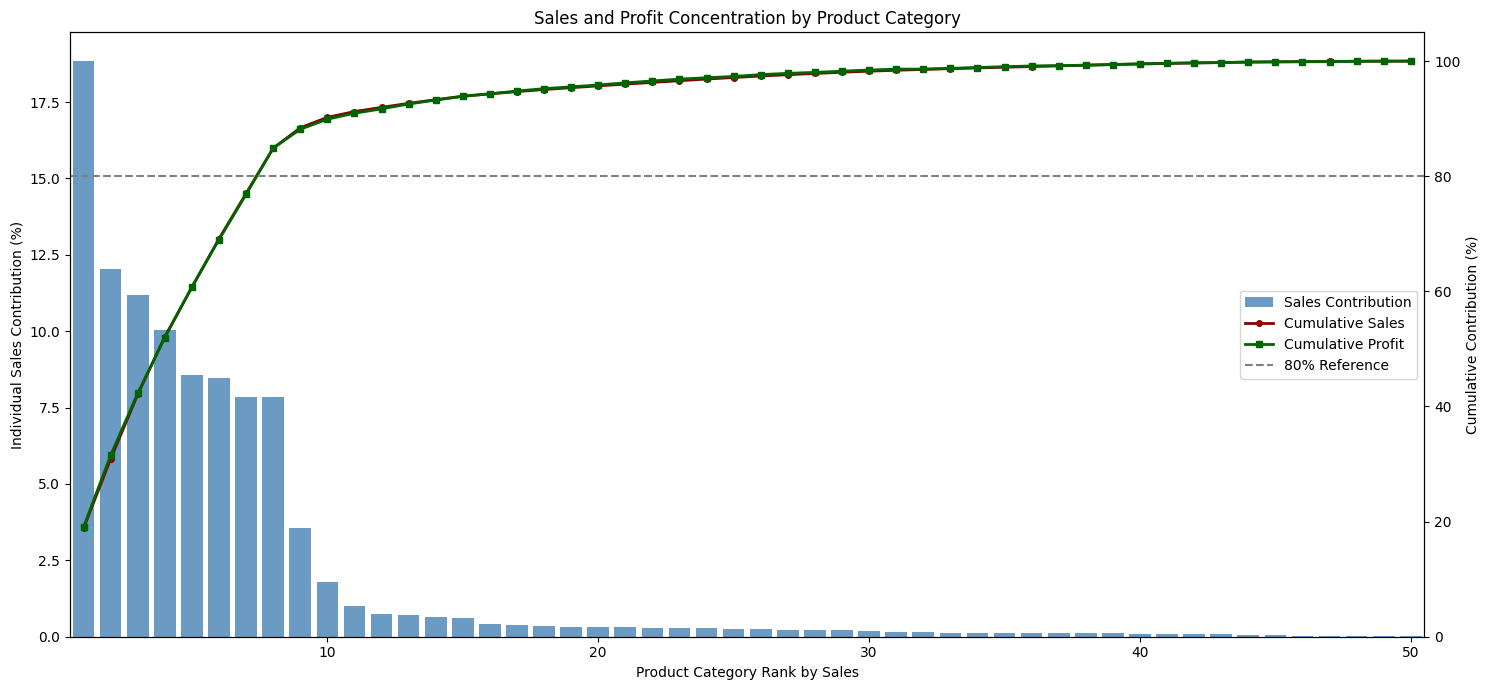


Product Concentration Statistics
Categories Required to Reach 80% of Sales: 8
Categories Required to Reach 80% of Profit: 8
Top 5 Sales Contribution: 60.68%
Top 5 Profit Contribution: 60.80%
Top 10 Sales Contribution: 90.23%
Top 10 Profit Contribution: 89.91%


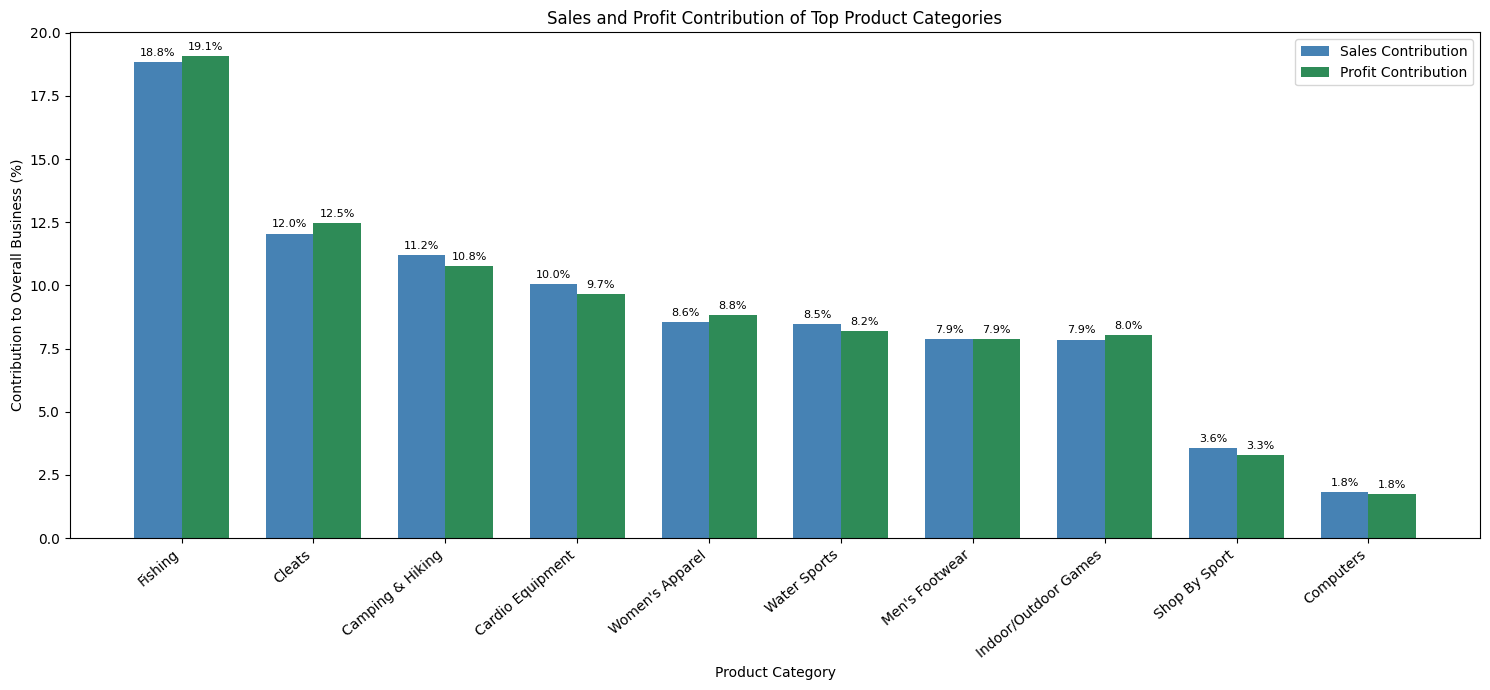

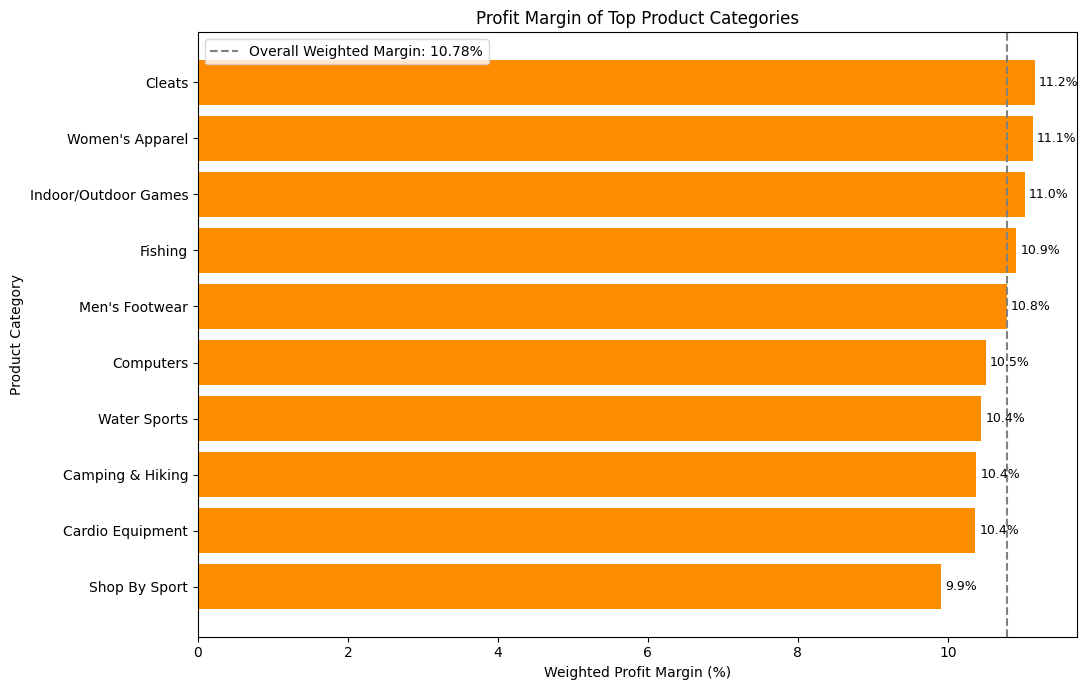

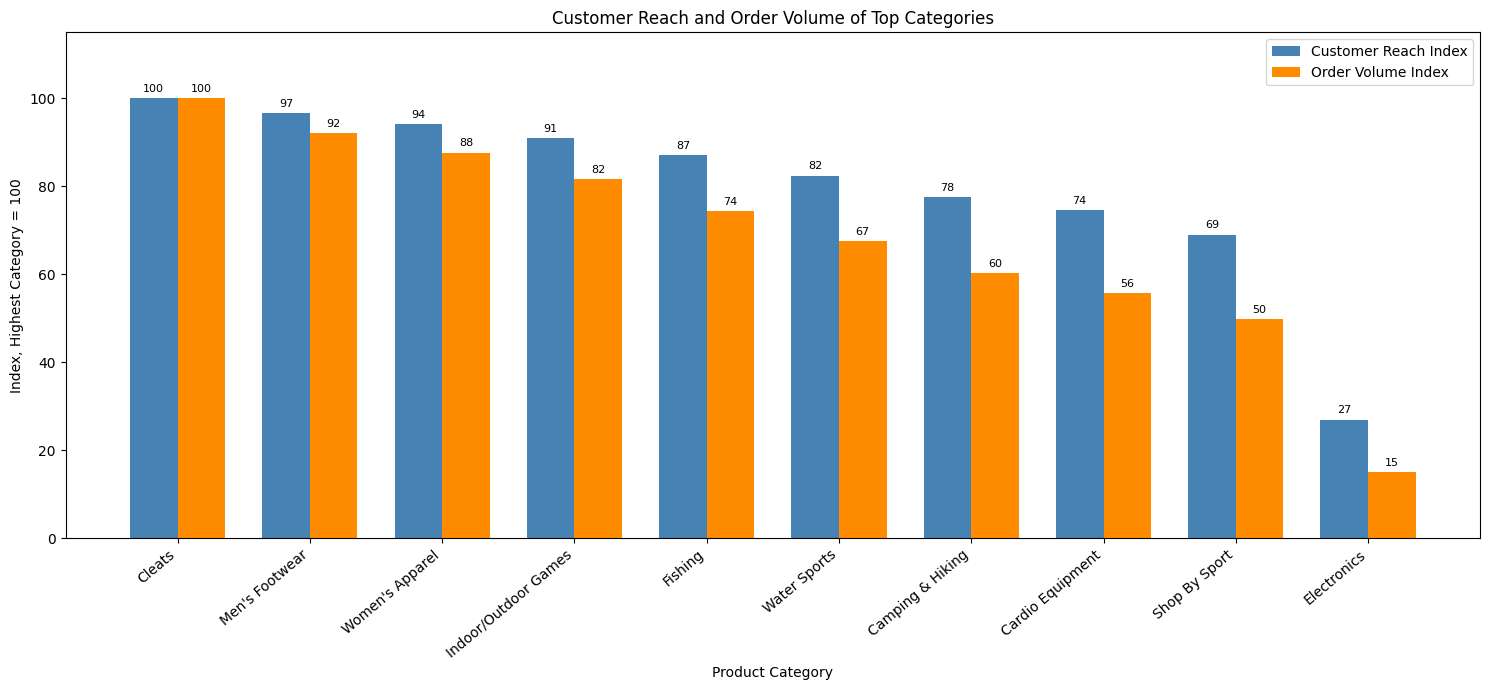

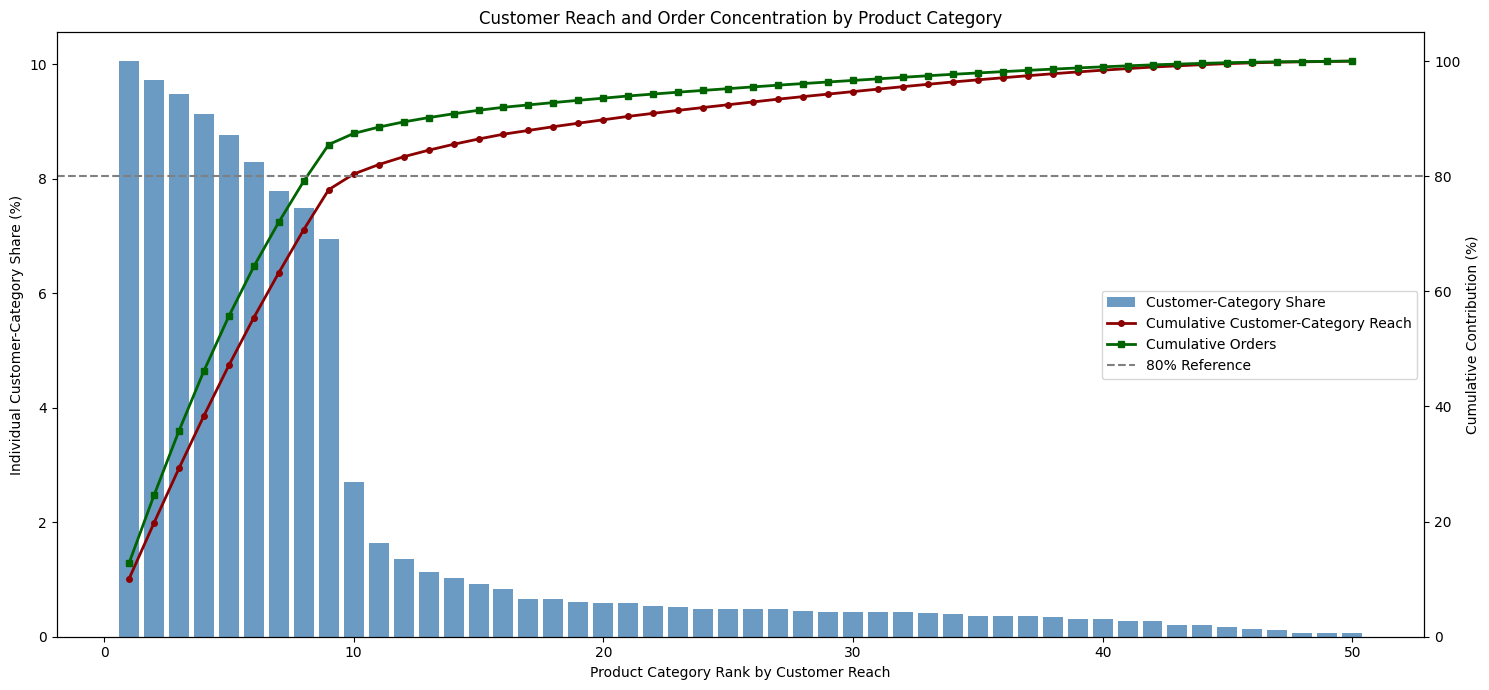


Product Category Performance Validation
Sales Contribution Totals 100%: True
Profit Contribution Totals 100%: True

Product Category Performance Summary
Top Category by Sales: Fishing (18.84%)
Top Category by Profit: Fishing (19.06%)
Top Category by Customer Reach: Cleats (48.66% of unique customers)
Categories Required for 80% of Sales: 8
Categories Required for 80% of Profit: 8
Overall Weighted Profit Margin: 10.78%


In [81]:
# ============================================================
# Step 8.1.1 Validate Required Data
# ============================================================

# Confirm that the cleaned dataset exists.
if "df_clean" not in globals():
    raise NameError(
        "df_clean is not defined. "
        "Please run the data-cleaning steps first."
    )

# Define the fields required for category-level analysis.
required_cols = [
    "Category Name",
    "Customer Id",
    "Order Id",
    "Order Item Id",
    "Sales",
    "Order Profit Per Order"
]

# Identify any missing fields.
missing_cols = [
    col for col in required_cols
    if col not in df_clean.columns
]

if missing_cols:
    raise KeyError(
        "Missing required columns in df_clean: "
        f"{missing_cols}"
    )

# Create a separate analytical dataframe.
product_analysis_df = df_clean[
    required_cols
].copy()

# Convert financial columns to numeric.
for col in [
    "Sales",
    "Order Profit Per Order"
]:
    product_analysis_df[col] = pd.to_numeric(
        product_analysis_df[col],
        errors="coerce"
    )

# Remove rows without essential analytical values.
product_analysis_df = (
    product_analysis_df
    .dropna(
        subset=[
            "Category Name",
            "Customer Id",
            "Order Id",
            "Order Item Id",
            "Sales",
            "Order Profit Per Order"
        ]
    )
    .copy()
)

if product_analysis_df.empty:
    raise ValueError(
        "No valid records are available for "
        "product-category analysis."
    )

print("=" * 75)
print("Product Category Analysis Data Validation")
print("=" * 75)
print(f"Rows Included: {len(product_analysis_df):,}")
print(
    "Product Categories:",
    f"{product_analysis_df['Category Name'].nunique():,}"
)
print(
    "Unique Customers:",
    f"{product_analysis_df['Customer Id'].nunique():,}"
)
print(
    "Unique Orders:",
    f"{product_analysis_df['Order Id'].nunique():,}"
)
print(
    "Unique Order Items:",
    f"{product_analysis_df['Order Item Id'].nunique():,}"
)


# ============================================================
# Step 8.1.2 Build Product Category Summary
# ============================================================
# The source data is at order-item level.
#
# This summary calculates:
# - Unique orders and customers
# - Unique order-item records
# - Total sales and profit
# - Total quantity is excluded here because quantity behavior
#   can be analyzed separately when needed
# ============================================================

product_summary = (
    product_analysis_df
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        order_count=("Order Id", "nunique"),
        customer_count=("Customer Id", "nunique"),
        order_item_count=("Order Item Id", "nunique"),
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

# Calculate weighted category profit margin.
#
# Weighted Profit Margin =
# Category Total Profit / Category Total Sales
#
# This is more appropriate than averaging row-level margins.
product_summary["profit_margin"] = np.where(
    product_summary["total_sales"].ne(0),
    (
        product_summary["total_profit"]
        / product_summary["total_sales"]
        * 100
    ),
    np.nan
)

# Calculate each category's contribution to total sales.
product_summary["sales_contribution_pct"] = np.where(
    product_summary["total_sales"].sum() != 0,
    (
        product_summary["total_sales"]
        / product_summary["total_sales"].sum()
        * 100
    ),
    np.nan
)

# Calculate each category's contribution to total profit.
product_summary["profit_contribution_pct"] = np.where(
    product_summary["total_profit"].sum() != 0,
    (
        product_summary["total_profit"]
        / product_summary["total_profit"].sum()
        * 100
    ),
    np.nan
)

# Calculate customer-category reach relative to all customers.
#
# A customer may purchase from multiple categories, so these
# percentages should not be summed across categories.
product_summary["customer_reach_pct"] = (
    product_summary["customer_count"]
    / product_analysis_df["Customer Id"].nunique()
    * 100
)

# Calculate average sales and profit per category order.
product_summary["sales_per_order"] = np.where(
    product_summary["order_count"].ne(0),
    (
        product_summary["total_sales"]
        / product_summary["order_count"]
    ),
    np.nan
)

product_summary["profit_per_order"] = np.where(
    product_summary["order_count"].ne(0),
    (
        product_summary["total_profit"]
        / product_summary["order_count"]
    ),
    np.nan
)

# Rank categories by total sales.
product_summary = (
    product_summary
    .sort_values(
        "total_sales",
        ascending=False
    )
    .reset_index(drop=True)
)

product_summary["sales_rank"] = (
    np.arange(
        1,
        len(product_summary) + 1
    )
)

# Calculate cumulative sales and profit contributions.
product_summary["cumulative_sales_pct"] = (
    product_summary["sales_contribution_pct"]
    .cumsum()
)

product_summary["cumulative_profit_pct"] = (
    product_summary["profit_contribution_pct"]
    .cumsum()
)


# ============================================================
# Step 8.1.3 Display Human-Readable Summary Table
# ============================================================

print("\n" + "=" * 75)
print("Product Category Performance Summary")
print("=" * 75)

summary_display_cols = [
    "sales_rank",
    "Category Name",
    "order_count",
    "customer_count",
    "order_item_count",
    "total_sales",
    "total_profit",
    "profit_margin",
    "sales_contribution_pct",
    "profit_contribution_pct",
    "customer_reach_pct",
    "sales_per_order",
    "profit_per_order",
    "cumulative_sales_pct",
    "cumulative_profit_pct"
]

display(
    product_summary[
        summary_display_cols
    ]
    .style
    .format({
        "sales_rank": "{:,.0f}",
        "order_count": "{:,.0f}",
        "customer_count": "{:,.0f}",
        "order_item_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "profit_margin": "{:.2f}%",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "customer_reach_pct": "{:.2f}%",
        "sales_per_order": "{:,.2f}",
        "profit_per_order": "{:,.2f}",
        "cumulative_sales_pct": "{:.2f}%",
        "cumulative_profit_pct": "{:.2f}%"
    })
    .background_gradient(
        subset=[
            "sales_contribution_pct",
            "profit_contribution_pct"
        ],
        cmap="Blues"
    )
)


# ============================================================
# Step 8.1.4 Revenue and Profit Concentration Analysis
# ============================================================
# The Pareto chart shows:
#
# Bars:
# Individual category sales contribution
#
# Lines:
# Cumulative sales and profit contribution
#
# X-axis:
# Category rank rather than category name, preventing
# overlapping labels when many categories are present.
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot individual sales contribution.
sales_contribution_bars = ax1.bar(
    product_summary["sales_rank"],
    product_summary["sales_contribution_pct"],
    color="steelblue",
    alpha=0.80,
    label="Sales Contribution"
)

ax1.set_xlabel("Product Category Rank by Sales")
ax1.set_ylabel("Individual Sales Contribution (%)")
ax1.set_xlim(
    0.5,
    len(product_summary) + 0.5
)

# Plot cumulative sales and profit on a second axis.
ax2 = ax1.twinx()

ax2.plot(
    product_summary["sales_rank"],
    product_summary["cumulative_sales_pct"],
    color="darkred",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Cumulative Sales"
)

ax2.plot(
    product_summary["sales_rank"],
    product_summary["cumulative_profit_pct"],
    color="darkgreen",
    marker="s",
    markersize=4,
    linewidth=2,
    label="Cumulative Profit"
)

# Add the Pareto reference line.
ax2.axhline(
    y=80,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="80% Reference"
)

ax2.set_ylabel("Cumulative Contribution (%)")
ax2.set_ylim(0, 105)

# Combine legends from both axes.
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="center right"
)

plt.title(
    "Sales and Profit Concentration by Product Category"
)
plt.tight_layout()
plt.show()


# ============================================================
# Step 8.1.5 Calculate Pareto Concentration Statistics
# ============================================================

# Identify how many categories are needed to reach
# approximately 80% of sales.
sales_80_count = (
    product_summary["cumulative_sales_pct"]
    .lt(80)
    .sum()
    + 1
)

# Identify how many categories are needed to reach
# approximately 80% of profit.
profit_80_count = (
    product_summary["cumulative_profit_pct"]
    .lt(80)
    .sum()
    + 1
)

# Calculate concentration among the top five and top ten.
top_5_sales_pct = (
    product_summary
    .head(5)["sales_contribution_pct"]
    .sum()
)

top_5_profit_pct = (
    product_summary
    .head(5)["profit_contribution_pct"]
    .sum()
)

top_10_sales_pct = (
    product_summary
    .head(10)["sales_contribution_pct"]
    .sum()
)

top_10_profit_pct = (
    product_summary
    .head(10)["profit_contribution_pct"]
    .sum()
)

print("\n" + "=" * 75)
print("Product Concentration Statistics")
print("=" * 75)
print(
    "Categories Required to Reach 80% of Sales:",
    f"{sales_80_count:,}"
)
print(
    "Categories Required to Reach 80% of Profit:",
    f"{profit_80_count:,}"
)
print(
    "Top 5 Sales Contribution:",
    f"{top_5_sales_pct:.2f}%"
)
print(
    "Top 5 Profit Contribution:",
    f"{top_5_profit_pct:.2f}%"
)
print(
    "Top 10 Sales Contribution:",
    f"{top_10_sales_pct:.2f}%"
)
print(
    "Top 10 Profit Contribution:",
    f"{top_10_profit_pct:.2f}%"
)


# ============================================================
# Step 8.1.6 Compare Top Categories by Sales and Profit
# ============================================================
# Display the ten largest categories by sales.
#
# The chart compares sales and profit contribution directly.
# Similar bar heights indicate that a category's profit
# contribution is broadly proportional to its sales contribution.
# ============================================================

top_category_count = min(
    10,
    len(product_summary)
)

top_categories = (
    product_summary
    .head(top_category_count)
    .copy()
)

positions = np.arange(
    len(top_categories)
)

bar_width = 0.36

fig, ax = plt.subplots(figsize=(15, 7))

sales_bars = ax.bar(
    positions - bar_width / 2,
    top_categories["sales_contribution_pct"],
    width=bar_width,
    color="steelblue",
    label="Sales Contribution"
)

profit_bars = ax.bar(
    positions + bar_width / 2,
    top_categories["profit_contribution_pct"],
    width=bar_width,
    color="seagreen",
    label="Profit Contribution"
)

ax.set_xticks(positions)
ax.set_xticklabels(
    top_categories["Category Name"],
    rotation=40,
    ha="right"
)

ax.set_title(
    "Sales and Profit Contribution of Top Product Categories"
)
ax.set_xlabel("Product Category")
ax.set_ylabel("Contribution to Overall Business (%)")
ax.legend()

ax.bar_label(
    sales_bars,
    labels=[
        f"{value:.1f}%"
        for value in top_categories["sales_contribution_pct"]
    ],
    padding=3,
    fontsize=8
)

ax.bar_label(
    profit_bars,
    labels=[
        f"{value:.1f}%"
        for value in top_categories["profit_contribution_pct"]
    ],
    padding=3,
    fontsize=8
)

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.1.7 Compare Profit Margin of Top Categories
# ============================================================
# Profit contribution and profit margin measure different things.
#
# - Profit contribution measures total business importance.
# - Profit margin measures profit retained per unit of sales.
#
# This chart shows whether the largest categories also
# achieve materially different margin levels.
# ============================================================

top_margin_df = (
    top_categories
    .sort_values(
        "profit_margin",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

margin_bars = ax.barh(
    top_margin_df["Category Name"],
    top_margin_df["profit_margin"],
    color="darkorange"
)

# Add the overall weighted margin for reference.
overall_weighted_margin = (
    product_summary["total_profit"].sum()
    / product_summary["total_sales"].sum()
    * 100
)

ax.axvline(
    x=overall_weighted_margin,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Overall Weighted Margin: "
        f"{overall_weighted_margin:.2f}%"
    )
)

ax.set_title(
    "Profit Margin of Top Product Categories"
)
ax.set_xlabel("Weighted Profit Margin (%)")
ax.set_ylabel("Product Category")
ax.legend()

ax.bar_label(
    margin_bars,
    labels=[
        f"{value:.1f}%"
        for value in top_margin_df["profit_margin"]
    ],
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.1.8 Customer Reach and Order Volume Analysis
# ============================================================
# Customer count and order count have different scales.
# Normalize each metric as an index where the highest
# category equals 100.
#
# This allows the two indicators to be compared without
# using a potentially confusing secondary axis.
# ============================================================

reach_category_count = min(
    10,
    len(product_summary)
)

reach_df = (
    product_summary
    .nlargest(
        reach_category_count,
        "customer_count"
    )
    .copy()
)

# Normalize customer and order counts.
reach_df["customer_reach_index"] = (
    reach_df["customer_count"]
    / reach_df["customer_count"].max()
    * 100
)

reach_df["order_volume_index"] = (
    reach_df["order_count"]
    / reach_df["order_count"].max()
    * 100
)

reach_positions = np.arange(
    len(reach_df)
)

fig, ax = plt.subplots(figsize=(15, 7))

customer_bars = ax.bar(
    reach_positions - bar_width / 2,
    reach_df["customer_reach_index"],
    width=bar_width,
    color="steelblue",
    label="Customer Reach Index"
)

order_bars = ax.bar(
    reach_positions + bar_width / 2,
    reach_df["order_volume_index"],
    width=bar_width,
    color="darkorange",
    label="Order Volume Index"
)

ax.set_xticks(reach_positions)
ax.set_xticklabels(
    reach_df["Category Name"],
    rotation=40,
    ha="right"
)

ax.set_title(
    "Customer Reach and Order Volume of Top Categories"
)
ax.set_xlabel("Product Category")
ax.set_ylabel("Index, Highest Category = 100")
ax.set_ylim(0, 115)
ax.legend()

ax.bar_label(
    customer_bars,
    labels=[
        f"{value:.0f}"
        for value in reach_df["customer_reach_index"]
    ],
    padding=3,
    fontsize=8
)

ax.bar_label(
    order_bars,
    labels=[
        f"{value:.0f}"
        for value in reach_df["order_volume_index"]
    ],
    padding=3,
    fontsize=8
)

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.1.9 Customer Reach and Order Concentration
# ============================================================
# Rank categories by customer count, then compare:
#
# - Individual customer-category reach contribution
# - Cumulative customer-category reach
# - Cumulative order contribution
#
# These percentages reflect category-level reach and should
# not be interpreted as mutually exclusive customers.
# ============================================================

reach_pareto_df = (
    product_summary
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

reach_pareto_df["reach_rank"] = (
    np.arange(
        1,
        len(reach_pareto_df) + 1
    )
)

# Shares are calculated across category-level counts.
# Customers purchasing several categories appear in each
# relevant category.
reach_pareto_df["customer_category_share_pct"] = (
    reach_pareto_df["customer_count"]
    / reach_pareto_df["customer_count"].sum()
    * 100
)

reach_pareto_df["order_category_share_pct"] = (
    reach_pareto_df["order_count"]
    / reach_pareto_df["order_count"].sum()
    * 100
)

reach_pareto_df["cumulative_customer_category_pct"] = (
    reach_pareto_df["customer_category_share_pct"]
    .cumsum()
)

reach_pareto_df["cumulative_order_category_pct"] = (
    reach_pareto_df["order_category_share_pct"]
    .cumsum()
)

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    reach_pareto_df["reach_rank"],
    reach_pareto_df["customer_category_share_pct"],
    color="steelblue",
    alpha=0.80,
    label="Customer-Category Share"
)

ax1.set_xlabel("Product Category Rank by Customer Reach")
ax1.set_ylabel("Individual Customer-Category Share (%)")

ax2 = ax1.twinx()

ax2.plot(
    reach_pareto_df["reach_rank"],
    reach_pareto_df["cumulative_customer_category_pct"],
    color="darkred",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Cumulative Customer-Category Reach"
)

ax2.plot(
    reach_pareto_df["reach_rank"],
    reach_pareto_df["cumulative_order_category_pct"],
    color="darkgreen",
    marker="s",
    markersize=4,
    linewidth=2,
    label="Cumulative Orders"
)

ax2.axhline(
    y=80,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="80% Reference"
)

ax2.set_ylabel("Cumulative Contribution (%)")
ax2.set_ylim(0, 105)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="center right"
)

plt.title(
    "Customer Reach and Order Concentration by Product Category"
)
plt.tight_layout()
plt.show()


# ============================================================
# Step 8.1.10 Final Validation and Summary
# ============================================================

# Confirm contribution percentages reconcile to 100%.
sales_contribution_check = np.isclose(
    product_summary["sales_contribution_pct"].sum(),
    100,
    atol=0.01
)

profit_contribution_check = np.isclose(
    product_summary["profit_contribution_pct"].sum(),
    100,
    atol=0.01
)

# Identify the largest categories by key measures.
top_sales_category = (
    product_summary
    .nlargest(1, "total_sales")
    .iloc[0]
)

top_profit_category = (
    product_summary
    .nlargest(1, "total_profit")
    .iloc[0]
)

top_customer_category = (
    product_summary
    .nlargest(1, "customer_count")
    .iloc[0]
)

print("\n" + "=" * 75)
print("Product Category Performance Validation")
print("=" * 75)
print(
    "Sales Contribution Totals 100%:",
    sales_contribution_check
)
print(
    "Profit Contribution Totals 100%:",
    profit_contribution_check
)

print("\n" + "=" * 75)
print("Product Category Performance Summary")
print("=" * 75)

print(
    "Top Category by Sales:",
    top_sales_category["Category Name"],
    f"({top_sales_category['sales_contribution_pct']:.2f}%)"
)

print(
    "Top Category by Profit:",
    top_profit_category["Category Name"],
    f"({top_profit_category['profit_contribution_pct']:.2f}%)"
)

print(
    "Top Category by Customer Reach:",
    top_customer_category["Category Name"],
    f"({top_customer_category['customer_reach_pct']:.2f}% "
    "of unique customers)"
)

print(
    "Categories Required for 80% of Sales:",
    sales_80_count
)

print(
    "Categories Required for 80% of Profit:",
    profit_80_count
)

print(
    "Overall Weighted Profit Margin:",
    f"{overall_weighted_margin:.2f}%"
)

### Key Observations

- Product performance is highly concentrated. The top **8 categories generate approximately 80% of both total sales and total profit**, indicating a strong Pareto pattern in the portfolio.

- **Fishing** is the most important category, contributing **18.8% of total sales** and **19.1% of total profit**, making it the largest driver of overall business performance.

- Revenue and profit contributions are closely aligned across the leading categories. Fishing, Cleats, Camping & Hiking, Cardio Equipment, Women's Apparel, Water Sports, Men's Footwear, and Indoor/Outdoor Games all rank among the top contributors to both sales and profit, suggesting that the core revenue-generating categories are also the primary profit generators.

- Profit margin differences among the top categories are relatively small. Most major categories operate within a narrow range of **10.4% to 11.2%**, compared with the overall weighted margin of **10.78%**. This indicates that category performance is driven more by sales scale and customer demand than by substantial margin advantages.

- Customer reach is concentrated in the same categories that drive revenue. **Cleats** has the largest customer reach, followed by Men's Footwear, Women's Apparel, Indoor/Outdoor Games, and Fishing. Categories with broader customer reach generally achieve higher order volume and stronger business contribution.

### Business Implications

- The business depends heavily on a small group of core categories, creating both growth opportunities and concentration risk.

- Since revenue and profit contributions are highly concentrated, future product segmentation should focus on identifying **Core Products**, **Supporting Products**, and **Long-Tail Products** based on contribution rather than small margin differences.

- Growth initiatives should prioritize high-reach categories, while portfolio monitoring should focus on maintaining the performance of the core categories that collectively drive most sales and profit.

## Step 8.2 Product Value Segmentation

This step segments product categories by cumulative sales contribution to distinguish major revenue drivers from supporting and long-tail categories.

The analysis will:

- Validate and prepare the category-level dataset
- Rank categories and calculate cumulative contributions
- Assign Core, Supporting, and Long-Tail Product tiers
- Summarize business performance by product tier
- Display category assignments within each tier
- Visualize tier boundaries and business contributions
- Validate and summarize the segmentation results

Core Products cover the first 80% of cumulative sales, Supporting Products extend coverage to 95%, and Long-Tail Products represent the remainder.

Product Value Segmentation Data Validation
Product Categories: 50
Total Sales: 36,784,735
Total Profit: 3,966,903
Duplicate Categories: 0

Product Category Count by Value Tier


,product_value_tier,category_count
0,Core Products,8
1,Supporting Products,10
2,Long-Tail Products,32



Product Value Tier Summary


,product_value_tier,category_count,category_share_pct,order_category_count,customer_category_count,total_sales,sales_contribution_pct,total_profit,profit_contribution_pct,weighted_profit_margin
0,Core Products,8,16.00%,"126,237","70,682","31,217,262",84.86%,"3,367,247",84.88%,10.79%
1,Supporting Products,10,20.00%,"19,445","15,716","3,750,779",10.20%,"409,839",10.33%,10.93%
2,Long-Tail Products,32,64.00%,"13,795","13,527","1,816,694",4.94%,"189,817",4.79%,10.45%



Core Products


,sales_rank,Category Name,product_value_tier,order_count,customer_count,total_sales,sales_contribution_pct,cumulative_sales_pct,total_profit,profit_contribution_pct,profit_margin
0,1,Fishing,Core Products,"15,164","8,759","6,929,654",18.84%,18.84%,"756,221",19.06%,10.91%
1,2,Cleats,Core Products,"20,386","10,049","4,431,943",12.05%,30.89%,"494,637",12.47%,11.16%
2,3,Camping & Hiking,Core Products,"12,299","7,788","4,118,426",11.20%,42.08%,"427,456",10.78%,10.38%
3,4,Cardio Equipment,Core Products,"11,355","7,486","3,694,843",10.04%,52.13%,"383,011",9.66%,10.37%
4,5,Women's Apparel,Core Products,"17,869","9,468","3,147,800",8.56%,60.68%,"350,421",8.83%,11.13%
5,6,Water Sports,Core Products,"13,758","8,281","3,113,845",8.47%,69.15%,"325,147",8.20%,10.44%
6,7,Men's Footwear,Core Products,"18,783","9,717","2,891,758",7.86%,77.01%,"311,903",7.86%,10.79%
7,8,Indoor/Outdoor Games,Core Products,"16,623","9,134","2,888,994",7.85%,84.86%,"318,451",8.03%,11.02%



Supporting Products


,sales_rank,Category Name,product_value_tier,order_count,customer_count,total_sales,sales_contribution_pct,cumulative_sales_pct,total_profit,profit_contribution_pct,profit_margin
0,9,Shop By Sport,Supporting Products,"10,136","6,935","1,309,522",3.56%,88.42%,"129,814",3.27%,9.91%
1,10,Computers,Supporting Products,442,442,"663,000",1.80%,90.23%,"69,657",1.76%,10.51%
2,11,Electronics,Supporting Products,"3,061","2,707","371,035",1.01%,91.24%,"40,891",1.03%,11.02%
3,12,Cameras,Supporting Products,592,592,"267,608",0.73%,91.96%,"30,290",0.76%,11.32%
4,13,Garden,Supporting Products,484,484,"257,769",0.70%,92.66%,"33,443",0.84%,12.97%
5,14,Children's Clothing,Supporting Products,652,652,"232,829",0.63%,93.30%,"27,178",0.69%,11.67%
6,15,Crafts,Supporting Products,484,484,"223,356",0.61%,93.90%,"25,531",0.64%,11.43%
7,16,Girls' Apparel,Supporting Products,"1,191","1,136","151,706",0.41%,94.32%,"17,289",0.44%,11.40%
8,17,Women's Clothing,Supporting Products,650,650,"140,283",0.38%,94.70%,"19,103",0.48%,13.62%
9,18,Accessories,Supporting Products,"1,753","1,634","133,672",0.36%,95.06%,"16,644",0.42%,12.45%



Long-Tail Products


,sales_rank,Category Name,product_value_tier,order_count,customer_count,total_sales,sales_contribution_pct,cumulative_sales_pct,total_profit,profit_contribution_pct,profit_margin
0,19,Sporting Goods,Long-Tail Products,357,357,"117,007",0.32%,95.38%,"12,519",0.32%,10.70%
1,20,Golf Gloves,Long-Tail Products,"1,064","1,026","116,695",0.32%,95.70%,"12,975",0.33%,11.12%
2,21,Music,Long-Tail Products,434,434,"113,122",0.31%,96.00%,"14,436",0.36%,12.76%
3,22,Consumer Electronics,Long-Tail Products,431,431,"108,991",0.30%,96.30%,"13,223",0.33%,12.13%
4,23,Golf Shoes,Long-Tail Products,523,517,"107,998",0.29%,96.59%,"12,406",0.31%,11.49%
5,24,Health and Beauty,Long-Tail Products,362,362,"106,080",0.29%,96.88%,"9,494",0.24%,8.95%
6,25,Kids' Golf Clubs,Long-Tail Products,373,365,"98,798",0.27%,97.15%,"9,046",0.23%,9.16%
7,26,Baseball & Softball,Long-Tail Products,628,608,"94,057",0.26%,97.41%,"12,762",0.32%,13.57%
8,27,Boxing & MMA,Long-Tail Products,421,413,"85,205",0.23%,97.64%,"8,641",0.22%,10.14%
9,28,DVDs,Long-Tail Products,483,483,"79,396",0.22%,97.85%,"6,655",0.17%,8.38%


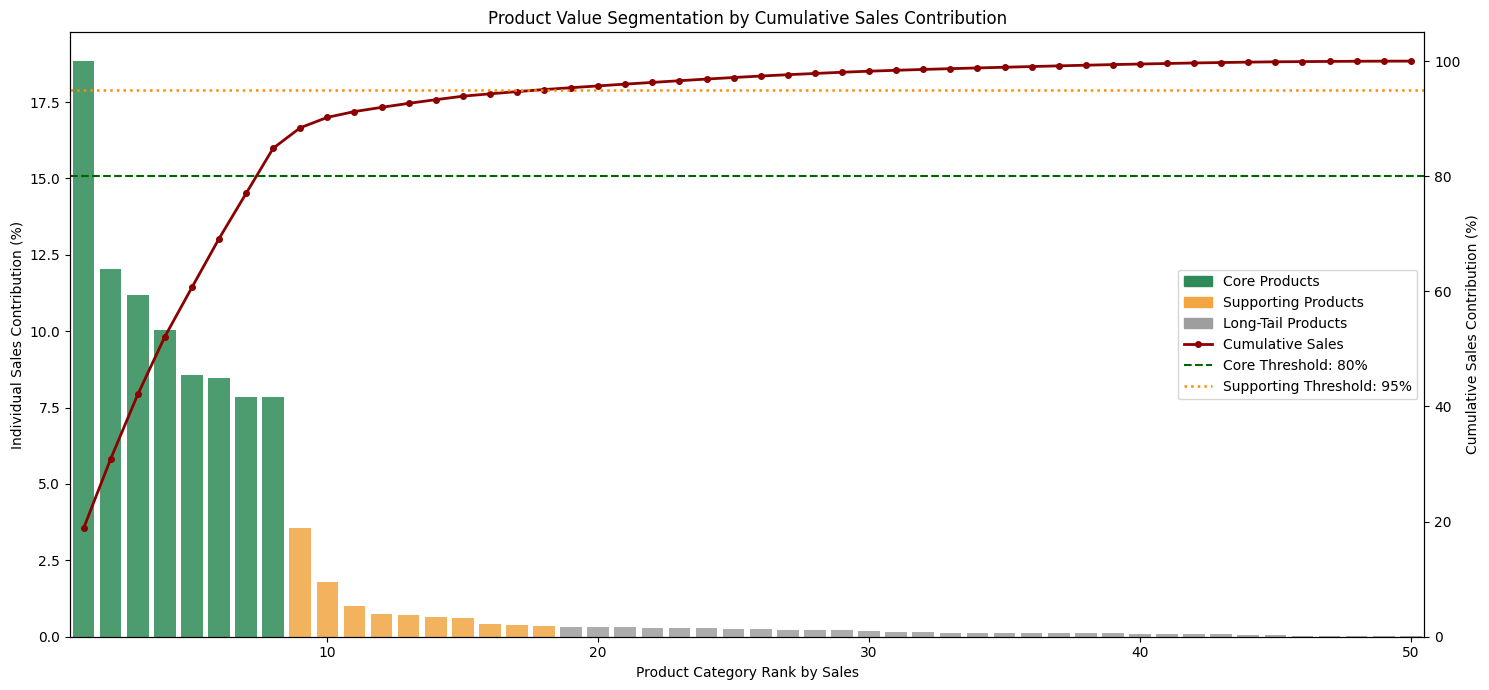

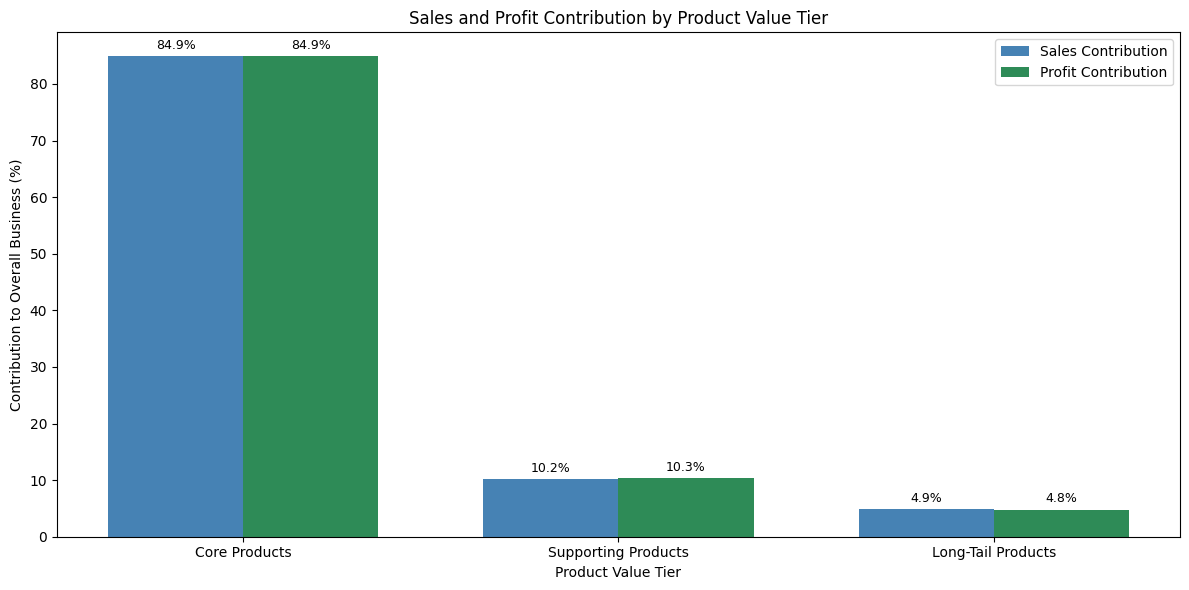

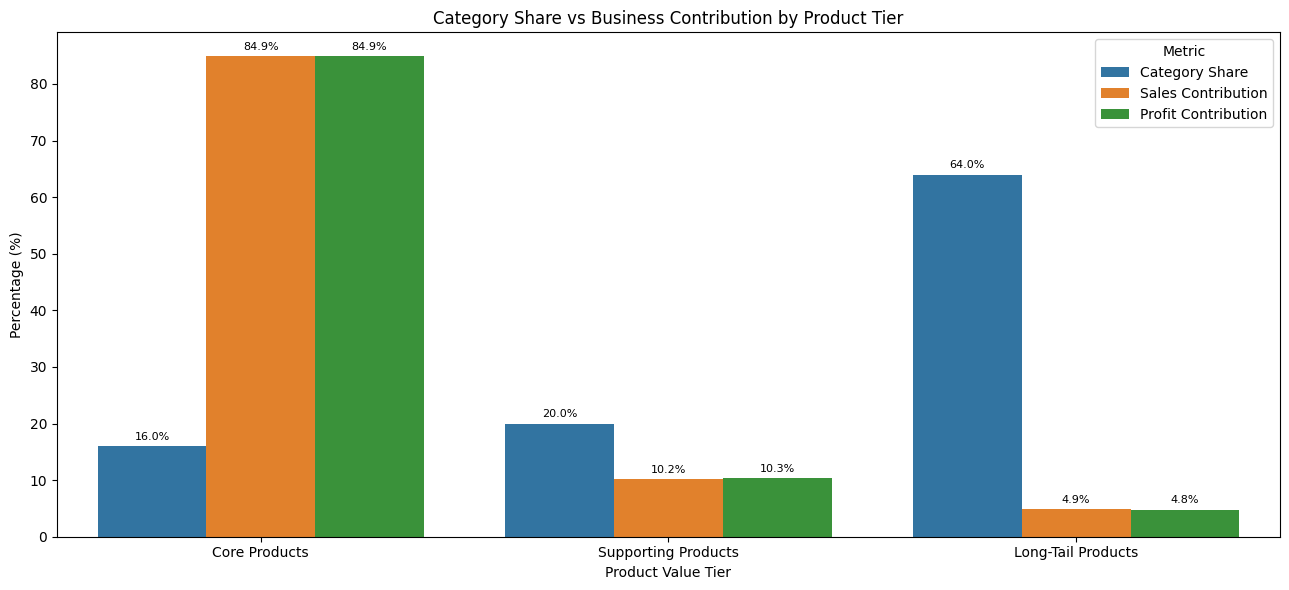


Product Value Segmentation Validation
Unclassified Categories: 0
Category Count Reconciles: True
Total Sales Reconciles: True
Total Profit Reconciles: True
Sales Contribution Totals 100%: True
Profit Contribution Totals 100%: True

Product Value Segmentation Summary
Core Products: 8 categories | 84.86% sales | 84.88% profit | 10.79% margin
Supporting Products: 10 categories | 10.20% sales | 10.33% profit | 10.93% margin
Long-Tail Products: 32 categories | 4.94% sales | 4.79% profit | 10.45% margin

Core Products end with: Indoor/Outdoor Games at 84.86% cumulative sales
Supporting Products end with: Accessories at 95.06% cumulative sales


In [82]:
# ============================================================
# Step 8.2 Product Value Segmentation
# ============================================================
# Objective:
#
# Segment product categories based on cumulative sales:
#
# Core Products:
# Categories required to reach at least 80% of total sales
#
# Supporting Products:
# Categories required to extend cumulative sales to at least 95%
#
# Long-Tail Products:
# Remaining categories after the 95% threshold
#
# Required dataframe:
# product_summary created in Step 8.1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Step 8.2.1 Validate and Prepare the Category-Level Dataset
# ============================================================

# Confirm that the Step 8.1 output exists.
if "product_summary" not in globals():
    raise NameError(
        "product_summary is not defined. "
        "Please run Step 8.1 first."
    )

# Define the category-level fields required for segmentation.
required_product_cols = [
    "Category Name",
    "order_count",
    "customer_count",
    "total_sales",
    "total_profit",
    "profit_margin",
    "sales_contribution_pct",
    "profit_contribution_pct"
]

# Identify missing fields.
missing_product_cols = [
    col for col in required_product_cols
    if col not in product_summary.columns
]

if missing_product_cols:
    raise KeyError(
        "Missing required columns in product_summary: "
        f"{missing_product_cols}"
    )

# Create a separate dataframe to preserve Step 8.1 results.
product_value_df = product_summary.copy()

# Convert analytical columns to numeric.
numeric_cols = [
    "order_count",
    "customer_count",
    "total_sales",
    "total_profit",
    "profit_margin",
    "sales_contribution_pct",
    "profit_contribution_pct"
]

for col in numeric_cols:
    product_value_df[col] = pd.to_numeric(
        product_value_df[col],
        errors="coerce"
    )

# Remove categories without valid category, sales, or profit data.
product_value_df = (
    product_value_df
    .dropna(
        subset=[
            "Category Name",
            "total_sales",
            "total_profit"
        ]
    )
    .loc[
        lambda df: df["total_sales"] > 0
    ]
    .copy()
)

# Confirm that each category appears only once.
duplicate_category_count = (
    product_value_df["Category Name"]
    .duplicated()
    .sum()
)

if duplicate_category_count > 0:
    raise ValueError(
        f"{duplicate_category_count} duplicate category records "
        "were found in product_summary."
    )

if product_value_df.empty:
    raise ValueError(
        "No valid product categories are available "
        "for value segmentation."
    )

print("=" * 75)
print("Product Value Segmentation Data Validation")
print("=" * 75)
print(
    "Product Categories:",
    f"{product_value_df['Category Name'].nunique():,}"
)
print(
    "Total Sales:",
    f"{product_value_df['total_sales'].sum():,.0f}"
)
print(
    "Total Profit:",
    f"{product_value_df['total_profit'].sum():,.0f}"
)
print(
    "Duplicate Categories:",
    f"{duplicate_category_count:,}"
)


# ============================================================
# Step 8.2.2 Rank Categories and Calculate Cumulative Contributions
# ============================================================
# Categories are ranked by total sales before cumulative
# contribution is calculated.
#
# Category Name is used as a secondary sorting field to make
# the ranking reproducible when categories have equal sales.
# ============================================================

product_value_df = (
    product_value_df
    .sort_values(
        [
            "total_sales",
            "Category Name"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

# Add the category sales rank.
product_value_df["sales_rank"] = np.arange(
    1,
    len(product_value_df) + 1
)

# Calculate total portfolio sales and profit.
total_portfolio_sales = (
    product_value_df["total_sales"]
    .sum()
)

total_portfolio_profit = (
    product_value_df["total_profit"]
    .sum()
)

# Recalculate sales contribution using the validated dataset.
product_value_df["sales_contribution_pct"] = (
    product_value_df["total_sales"]
    / total_portfolio_sales
    * 100
)

# Recalculate profit contribution.
if total_portfolio_profit != 0:
    product_value_df["profit_contribution_pct"] = (
        product_value_df["total_profit"]
        / total_portfolio_profit
        * 100
    )
else:
    product_value_df["profit_contribution_pct"] = np.nan

# Calculate cumulative sales and profit contributions.
product_value_df["cumulative_sales_pct"] = (
    product_value_df["sales_contribution_pct"]
    .cumsum()
)

product_value_df["cumulative_profit_pct"] = (
    product_value_df["profit_contribution_pct"]
    .cumsum()
)

# Calculate cumulative sales before adding each category.
#
# This field ensures that the category crossing the 80%
# threshold remains a Core Product. The category crossing
# the 95% threshold remains a Supporting Product.
product_value_df["previous_cumulative_sales_pct"] = (
    product_value_df["cumulative_sales_pct"]
    - product_value_df["sales_contribution_pct"]
)


# ============================================================
# Step 8.2.3 Assign Core, Supporting, and Long-Tail Product Tiers
# ============================================================
# Segmentation rules:
#
# Core Products:
# Previous cumulative sales contribution is below 80%.
#
# Supporting Products:
# Previous cumulative sales contribution is between
# 80% and 95%.
#
# Long-Tail Products:
# Previous cumulative sales contribution is at least 95%.
# ============================================================

product_value_df["product_value_tier"] = np.select(
    [
        (
            product_value_df[
                "previous_cumulative_sales_pct"
            ] < 80
        ),
        (
            product_value_df[
                "previous_cumulative_sales_pct"
            ] >= 80
        )
        &
        (
            product_value_df[
                "previous_cumulative_sales_pct"
            ] < 95
        ),
        (
            product_value_df[
                "previous_cumulative_sales_pct"
            ] >= 95
        )
    ],
    [
        "Core Products",
        "Supporting Products",
        "Long-Tail Products"
    ],
    default="Unclassified"
)

# Define the intended display order.
product_tier_order = [
    "Core Products",
    "Supporting Products",
    "Long-Tail Products"
]

# Check for unexpected classifications before converting to category.
unclassified_count = (
    product_value_df["product_value_tier"]
    .eq("Unclassified")
    .sum()
)

if unclassified_count > 0:
    raise ValueError(
        f"{unclassified_count} product categories could not "
        "be classified."
    )

# Convert the tier field into an ordered categorical variable.
product_value_df["product_value_tier"] = pd.Categorical(
    product_value_df["product_value_tier"],
    categories=product_tier_order,
    ordered=True
)

print("\n" + "=" * 75)
print("Product Category Count by Value Tier")
print("=" * 75)

tier_category_count = (
    product_value_df["product_value_tier"]
    .value_counts(sort=False)
    .reindex(
        product_tier_order,
        fill_value=0
    )
    .rename_axis("product_value_tier")
    .reset_index(name="category_count")
)

display(tier_category_count)


# ============================================================
# Step 8.2.4 Summarize Business Performance by Product Tier
# ============================================================
# Important:
#
# order_category_count is the sum of category-level order
# counts. An order containing multiple categories can appear
# more than once.
#
# customer_category_count follows the same logic. A customer
# purchasing multiple categories can appear more than once.
# ============================================================

product_tier_summary = (
    product_value_df
    .groupby(
        "product_value_tier",
        observed=True
    )
    .agg(
        category_count=("Category Name", "nunique"),
        order_category_count=("order_count", "sum"),
        customer_category_count=("customer_count", "sum"),
        total_sales=("total_sales", "sum"),
        total_profit=("total_profit", "sum"),
        sales_contribution_pct=(
            "sales_contribution_pct",
            "sum"
        ),
        profit_contribution_pct=(
            "profit_contribution_pct",
            "sum"
        )
    )
    .reindex(product_tier_order)
    .reset_index()
)

# Calculate weighted profit margin for each product tier.
product_tier_summary["weighted_profit_margin"] = np.where(
    product_tier_summary["total_sales"].ne(0),
    (
        product_tier_summary["total_profit"]
        / product_tier_summary["total_sales"]
        * 100
    ),
    np.nan
)

# Calculate each tier's share of product categories.
product_tier_summary["category_share_pct"] = (
    product_tier_summary["category_count"]
    / product_value_df["Category Name"].nunique()
    * 100
)

# Arrange fields in a business-friendly order.
product_tier_summary = product_tier_summary[
    [
        "product_value_tier",
        "category_count",
        "category_share_pct",
        "order_category_count",
        "customer_category_count",
        "total_sales",
        "sales_contribution_pct",
        "total_profit",
        "profit_contribution_pct",
        "weighted_profit_margin"
    ]
]

print("\n" + "=" * 75)
print("Product Value Tier Summary")
print("=" * 75)

display(
    product_tier_summary.style
    .format({
        "category_count": "{:,.0f}",
        "category_share_pct": "{:.2f}%",
        "order_category_count": "{:,.0f}",
        "customer_category_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "sales_contribution_pct": "{:.2f}%",
        "total_profit": "{:,.0f}",
        "profit_contribution_pct": "{:.2f}%",
        "weighted_profit_margin": "{:.2f}%"
    })
    .background_gradient(
        subset=[
            "sales_contribution_pct",
            "profit_contribution_pct"
        ],
        cmap="Blues"
    )
)


# ============================================================
# Step 8.2.5 Display Category Assignments Within Each Tier
# ============================================================

product_tier_detail_cols = [
    "sales_rank",
    "Category Name",
    "product_value_tier",
    "order_count",
    "customer_count",
    "total_sales",
    "sales_contribution_pct",
    "cumulative_sales_pct",
    "total_profit",
    "profit_contribution_pct",
    "profit_margin"
]

for tier in product_tier_order:

    # Convert the categorical variable to string for filtering.
    tier_mask = (
        product_value_df["product_value_tier"]
        .astype(str)
        .eq(tier)
    )

    tier_detail = (
        product_value_df
        .loc[
            tier_mask,
            product_tier_detail_cols
        ]
        .sort_values("sales_rank")
        .reset_index(drop=True)
    )

    print("\n" + "=" * 75)
    print(tier)
    print("=" * 75)

    if tier_detail.empty:
        print(
            "No product categories were assigned "
            "to this tier."
        )
    else:
        display(
            tier_detail.style.format({
                "sales_rank": "{:,.0f}",
                "order_count": "{:,.0f}",
                "customer_count": "{:,.0f}",
                "total_sales": "{:,.0f}",
                "sales_contribution_pct": "{:.2f}%",
                "cumulative_sales_pct": "{:.2f}%",
                "total_profit": "{:,.0f}",
                "profit_contribution_pct": "{:.2f}%",
                "profit_margin": "{:.2f}%"
            })
        )


# ============================================================
# Step 8.2.6 Visualize Tier Boundaries and Business Contributions
# ============================================================

# Define consistent colors for the product tiers.
tier_palette = {
    "Core Products": "#2E8B57",
    "Supporting Products": "#F2A541",
    "Long-Tail Products": "#9E9E9E"
}

# Convert tier values into chart colors.
bar_colors = (
    product_value_df["product_value_tier"]
    .astype(str)
    .map(tier_palette)
)


# ------------------------------------------------------------
# Chart 1: Product tiers on the cumulative sales curve
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(15, 7))

# Individual category sales contribution.
ax1.bar(
    product_value_df["sales_rank"],
    product_value_df["sales_contribution_pct"],
    color=bar_colors,
    alpha=0.85
)

ax1.set_xlabel("Product Category Rank by Sales")
ax1.set_ylabel("Individual Sales Contribution (%)")
ax1.set_xlim(
    0.5,
    len(product_value_df) + 0.5
)

# Cumulative sales contribution.
ax2 = ax1.twinx()

ax2.plot(
    product_value_df["sales_rank"],
    product_value_df["cumulative_sales_pct"],
    color="darkred",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Cumulative Sales"
)

# Add segmentation thresholds.
ax2.axhline(
    y=80,
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
    label="Core Threshold: 80%"
)

ax2.axhline(
    y=95,
    color="darkorange",
    linestyle=":",
    linewidth=1.8,
    label="Supporting Threshold: 95%"
)

ax2.set_ylabel("Cumulative Sales Contribution (%)")
ax2.set_ylim(0, 105)

# Create a clean combined legend.
tier_legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=tier_palette[tier],
        label=tier
    )
    for tier in product_tier_order
]

line_handles, line_labels = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    handles=tier_legend_handles + line_handles,
    labels=product_tier_order + line_labels,
    loc="center right"
)

plt.title(
    "Product Value Segmentation by "
    "Cumulative Sales Contribution"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Sales and profit contribution by product tier
# ------------------------------------------------------------

tier_positions = np.arange(
    len(product_tier_summary)
)

bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

sales_bars = ax.bar(
    tier_positions - bar_width / 2,
    product_tier_summary["sales_contribution_pct"],
    width=bar_width,
    color="steelblue",
    label="Sales Contribution"
)

profit_bars = ax.bar(
    tier_positions + bar_width / 2,
    product_tier_summary["profit_contribution_pct"],
    width=bar_width,
    color="seagreen",
    label="Profit Contribution"
)

ax.set_xticks(tier_positions)

ax.set_xticklabels(
    product_tier_summary["product_value_tier"]
    .astype(str)
)

ax.set_title(
    "Sales and Profit Contribution by Product Value Tier"
)
ax.set_xlabel("Product Value Tier")
ax.set_ylabel("Contribution to Overall Business (%)")
ax.legend()

ax.bar_label(
    sales_bars,
    labels=[
        f"{value:.1f}%"
        for value in product_tier_summary[
            "sales_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

ax.bar_label(
    profit_bars,
    labels=[
        f"{value:.1f}%"
        for value in product_tier_summary[
            "profit_contribution_pct"
        ]
    ],
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 3: Category share vs business contribution
# ------------------------------------------------------------

tier_structure_df = (
    product_tier_summary[
        [
            "product_value_tier",
            "category_share_pct",
            "sales_contribution_pct",
            "profit_contribution_pct"
        ]
    ]
    .melt(
        id_vars="product_value_tier",
        value_vars=[
            "category_share_pct",
            "sales_contribution_pct",
            "profit_contribution_pct"
        ],
        var_name="metric",
        value_name="percentage"
    )
)

tier_structure_df["metric"] = (
    tier_structure_df["metric"]
    .map({
        "category_share_pct": "Category Share",
        "sales_contribution_pct": "Sales Contribution",
        "profit_contribution_pct": "Profit Contribution"
    })
)

fig, ax = plt.subplots(figsize=(13, 6))

tier_structure_axis = sns.barplot(
    data=tier_structure_df,
    x="product_value_tier",
    y="percentage",
    hue="metric",
    hue_order=[
        "Category Share",
        "Sales Contribution",
        "Profit Contribution"
    ],
    ax=ax
)

tier_structure_axis.set_title(
    "Category Share vs Business Contribution by Product Tier"
)
tier_structure_axis.set_xlabel("Product Value Tier")
tier_structure_axis.set_ylabel("Percentage (%)")
tier_structure_axis.legend(title="Metric")

for container in tier_structure_axis.containers:
    tier_structure_axis.bar_label(
        container,
        labels=[
            f"{value:.1f}%"
            for value in container.datavalues
        ],
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.2.7 Validate and Summarize the Segmentation Results
# ============================================================

# Check that all categories have a valid tier.
unclassified_count = (
    product_value_df["product_value_tier"]
    .isna()
    .sum()
)

# Reconcile category counts.
category_count_check = (
    product_tier_summary["category_count"].sum()
    == product_value_df["Category Name"].nunique()
)

# Reconcile sales and profit totals.
sales_total_check = np.isclose(
    product_tier_summary["total_sales"].sum(),
    product_value_df["total_sales"].sum()
)

profit_total_check = np.isclose(
    product_tier_summary["total_profit"].sum(),
    product_value_df["total_profit"].sum()
)

# Confirm that sales and profit contributions total 100%.
sales_contribution_check = np.isclose(
    product_tier_summary[
        "sales_contribution_pct"
    ].sum(),
    100,
    atol=0.01
)

profit_contribution_check = np.isclose(
    product_tier_summary[
        "profit_contribution_pct"
    ].sum(),
    100,
    atol=0.01
)

print("\n" + "=" * 75)
print("Product Value Segmentation Validation")
print("=" * 75)
print(
    "Unclassified Categories:",
    f"{unclassified_count:,}"
)
print(
    "Category Count Reconciles:",
    category_count_check
)
print(
    "Total Sales Reconciles:",
    sales_total_check
)
print(
    "Total Profit Reconciles:",
    profit_total_check
)
print(
    "Sales Contribution Totals 100%:",
    sales_contribution_check
)
print(
    "Profit Contribution Totals 100%:",
    profit_contribution_check
)


# ------------------------------------------------------------
# Print the summary of each product tier
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("Product Value Segmentation Summary")
print("=" * 75)

for _, row in product_tier_summary.iterrows():
    print(
        f"{row['product_value_tier']}: "
        f"{int(row['category_count'])} categories | "
        f"{row['sales_contribution_pct']:.2f}% sales | "
        f"{row['profit_contribution_pct']:.2f}% profit | "
        f"{row['weighted_profit_margin']:.2f}% margin"
    )


# ------------------------------------------------------------
# Identify the final category in each major boundary
# ------------------------------------------------------------

core_boundary = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .eq("Core Products")
    ]
    .tail(1)
)

supporting_boundary = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .eq("Supporting Products")
    ]
    .tail(1)
)

# Correct syntax:
# .iloc[0] extracts the scalar value before applying :.2f.
if not core_boundary.empty:
    core_boundary_category = (
        core_boundary["Category Name"]
        .iloc[0]
    )

    core_boundary_pct = (
        core_boundary["cumulative_sales_pct"]
        .iloc[0]
    )

    print(
        "\nCore Products end with:",
        core_boundary_category,
        "at",
        f"{core_boundary_pct:.2f}%",
        "cumulative sales"
    )

if not supporting_boundary.empty:
    supporting_boundary_category = (
        supporting_boundary["Category Name"]
        .iloc[0]
    )

    supporting_boundary_pct = (
        supporting_boundary["cumulative_sales_pct"]
        .iloc[0]
    )

    print(
        "Supporting Products end with:",
        supporting_boundary_category,
        "at",
        f"{supporting_boundary_pct:.2f}%",
        "cumulative sales"
    )

### Key Observations

- Product value is highly concentrated. Only **8 Core Products**, representing **16.0% of all categories**, generate **84.86% of total sales** and **84.88% of total profit**.

- The Core tier consists of Fishing, Cleats, Camping & Hiking, Cardio Equipment, Women's Apparel, Water Sports, Men's Footwear, and Indoor/Outdoor Games. Fishing alone contributes **18.84% of sales** and **19.06% of profit**.

- Supporting Products contain **10 categories** and contribute **10.20% of sales** and **10.33% of profit**, extending cumulative sales coverage from **84.86% to 95.06%**.

- Long-Tail Products represent **64.0% of all categories**, but generate only **4.94% of sales** and **4.79% of profit**, indicating limited individual business impact.

- Sales and profit contributions are closely aligned across all product tiers. This indicates that profit contribution is largely driven by sales scale rather than meaningful differences in profit margin.

- Weighted profit margins are relatively consistent across tiers, ranging from 10.45% to 10.93%. The small margin variation suggests that business value is primarily determined by category contribution and portfolio scale rather than profitability differences.

### Business Implications

- Protect availability and performance of Core Products because a small decline could materially affect overall sales and profit.
- Use Supporting Products as the main pool for targeted growth opportunities.
- Review Long-Tail Products selectively, but avoid assuming that low sales contribution automatically justifies discontinuation.

## Step 8.3 Product Tier Profile

This step profiles Core, Supporting, and Long-Tail Products to understand how their customers, transactions, markets, and operations differ.

The analysis will:

- Validate and prepare the tier-level transaction dataset
- Compare customer reach and order activity
- Compare order value, quantity, and profitability
- Analyze customer-value composition by tier
- Analyze customer-segment and market composition
- Compare shipping, discount, and delivery profiles
- Validate and summarize the tier profiles

The results will identify whether product tiers differ only in scale or also exhibit distinct customer and operational characteristics.

Product Tier Profile Data Validation
Transaction Rows: 180,519
Product Categories: 50
Unique Customers: 20,652
Unique Orders: 65,752
Unmapped Source Records: 0

Customer Reach and Order Activity by Product Tier


,product_value_tier,category_count,customer_count,order_count,order_item_count,total_sales,total_profit,customer_reach_pct,orders_per_customer,items_per_order
0,Core Products,8,"12,307","55,418","146,211","31,217,262","3,367,247",59.59%,4.50,2.64
1,Supporting Products,10,"11,993","18,357","20,425","3,750,779","409,839",58.07%,1.53,1.11
2,Long-Tail Products,32,"11,061","13,245","13,883","1,816,694","189,817",53.56%,1.20,1.05


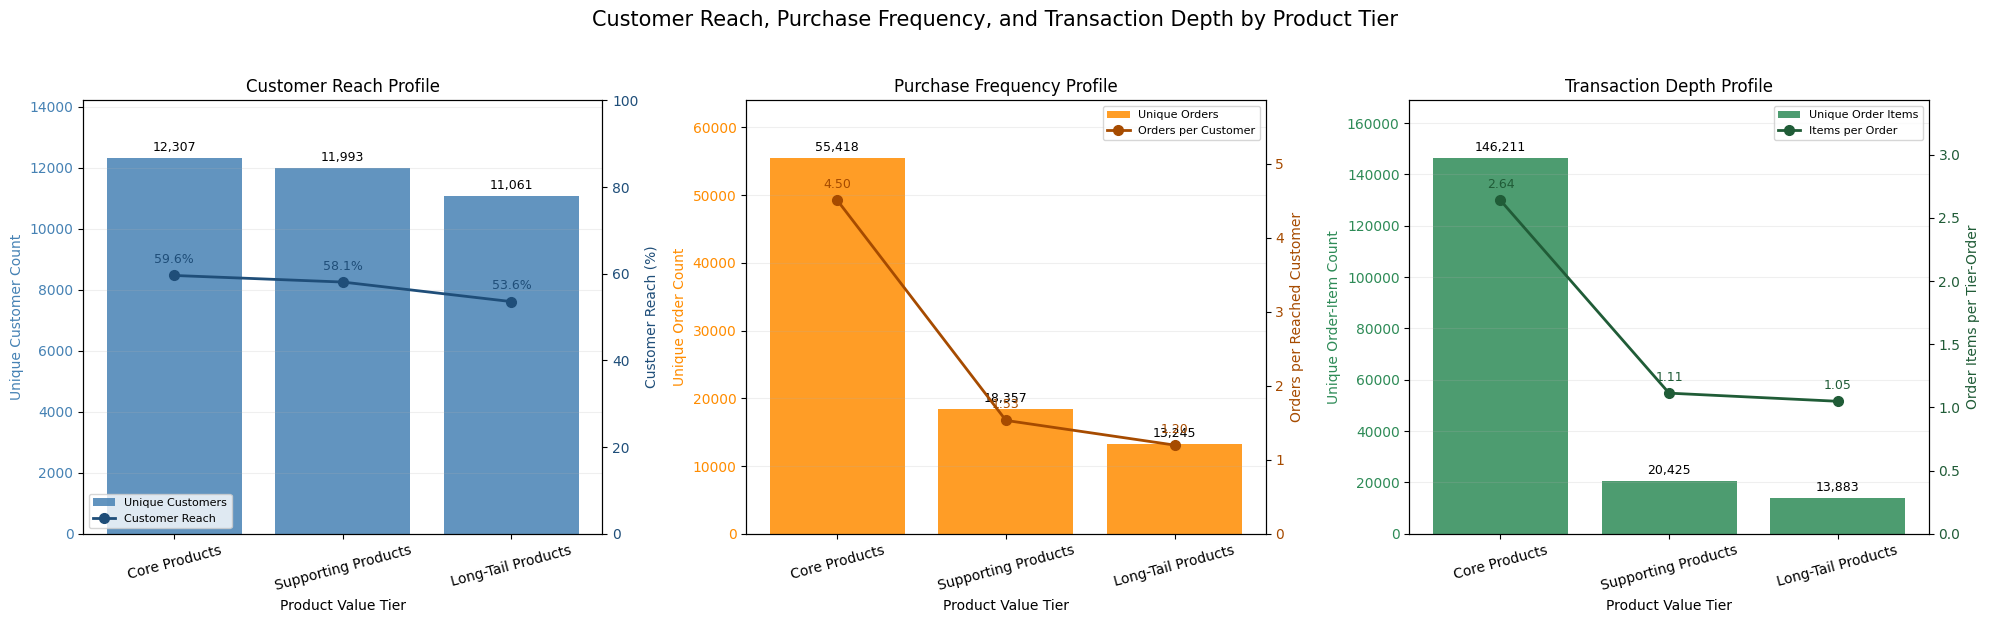


Order Value, Quantity, and Profitability by Product Tier


,product_value_tier,order_count,avg_order_value,median_order_value,avg_profit_per_order,median_profit_per_order,avg_quantity_per_order,median_quantity_per_order,avg_items_per_order,total_sales,total_profit,weighted_profit_margin
0,Core Products,"55,418",563.31,519.97,60.76,77.59,5.43,5.00,2.64,"31,217,262","3,367,247",10.79%
1,Supporting Products,"18,357",204.32,150.00,22.33,23.25,2.97,3.00,1.11,"3,750,779","409,839",10.93%
2,Long-Tail Products,"13,245",137.16,89.98,14.33,14.09,2.17,1.00,1.05,"1,816,694","189,817",10.45%


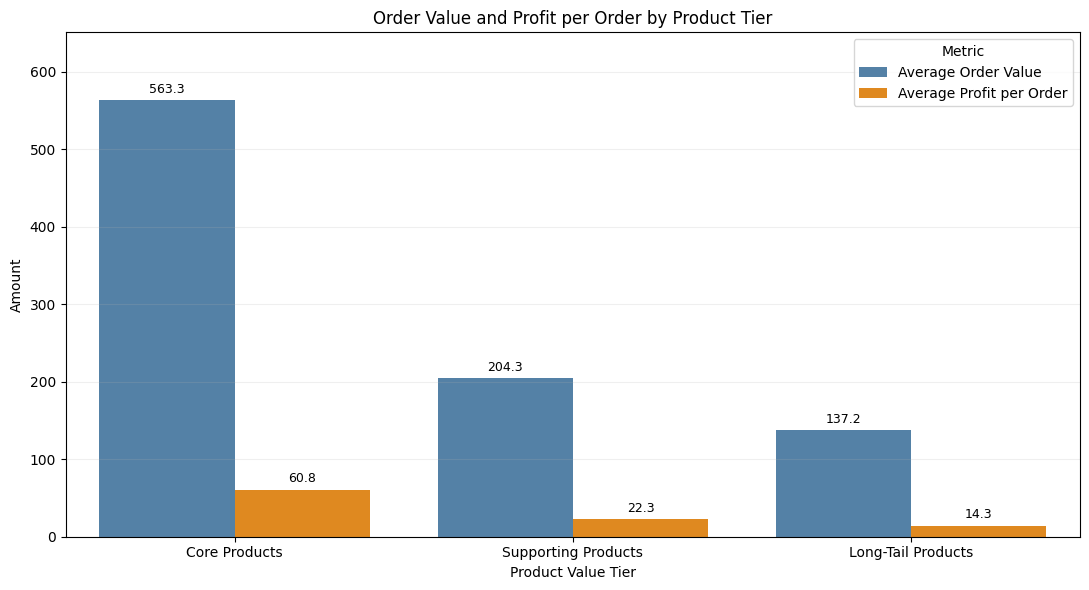

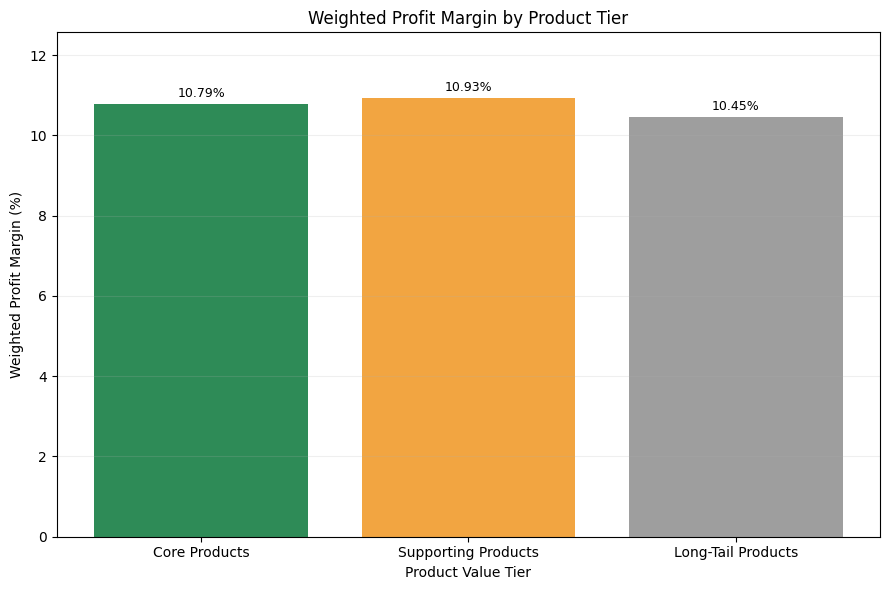


Customer Value Composition by Product Tier
Transactions without Customer Value Segment: 0


,product_value_tier,customer_value_segment,customer_count,order_count,total_sales,total_profit,sales_share_pct,profit_share_pct
0,Core Products,High Value,"4,130","18,061","9,770,879","1,004,411",31.30%,29.83%
1,Core Products,Low Value,77,81,"10,709","1,095",0.03%,0.03%
2,Core Products,Medium Value,"3,686","9,955","4,568,678","519,510",14.64%,15.43%
3,Core Products,Medium-Low Value,283,382,"97,949","14,258",0.31%,0.42%
4,Core Products,VIP,"4,131","26,939","16,769,046","1,827,972",53.72%,54.29%
5,Long-Tail Products,High Value,"2,087","2,683","359,976","34,957",19.81%,18.42%
6,Long-Tail Products,Low Value,"3,444","3,444","232,847","18,533",12.82%,9.76%
7,Long-Tail Products,Medium Value,"1,192","1,371","166,308","22,277",9.15%,11.74%
8,Long-Tail Products,Medium-Low Value,"1,636","1,638","450,399","50,652",24.79%,26.68%
9,Long-Tail Products,VIP,"2,702","4,109","607,164","63,398",33.42%,33.40%


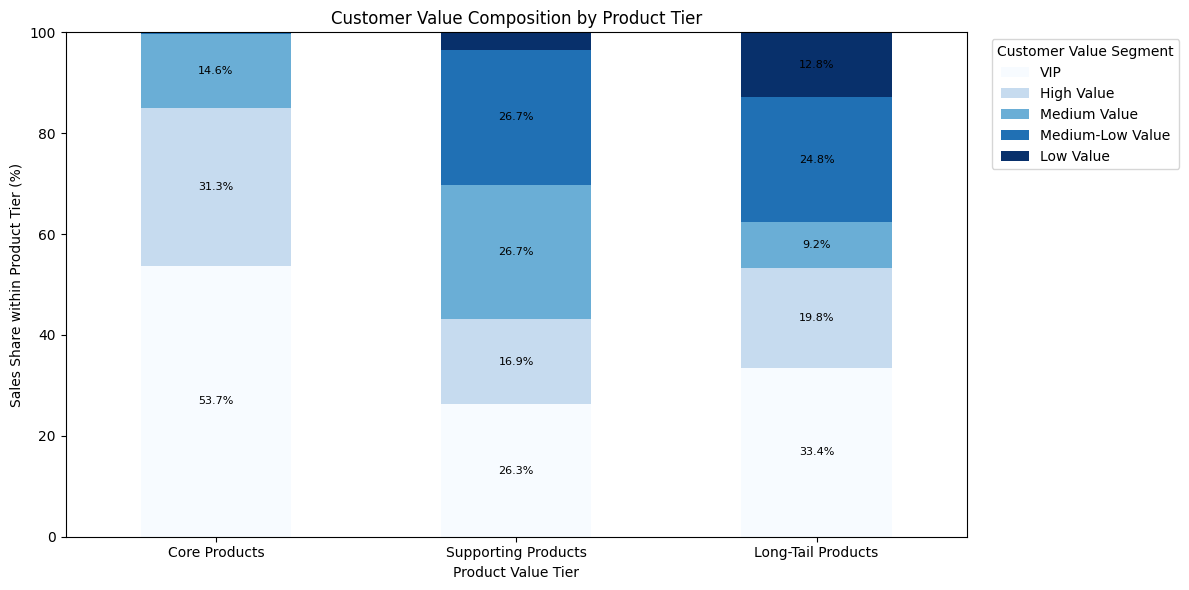


Customer Segment Composition by Product Tier


,product_value_tier,Customer Segment,customer_count,order_count,total_sales,total_profit,sales_share_pct,profit_margin
0,Core Products,Consumer,"6,395","28,752","16,182,233","1,751,047",51.84%,10.82%
1,Core Products,Corporate,"3,704","16,757","9,486,645","1,020,731",30.39%,10.76%
2,Core Products,Home Office,"2,208","9,909","5,548,383","595,469",17.77%,10.73%
3,Long-Tail Products,Consumer,"5,634","6,771","931,021","86,044",51.25%,9.24%
4,Long-Tail Products,Corporate,"3,385","4,013","549,340","66,677",30.24%,12.14%
5,Long-Tail Products,Home Office,"2,042","2,461","336,333","37,096",18.51%,11.03%
6,Supporting Products,Consumer,"6,271","9,612","1,982,536","236,397",52.86%,11.92%
7,Supporting Products,Corporate,"3,612","5,512","1,132,421","115,167",30.19%,10.17%
8,Supporting Products,Home Office,"2,110","3,233","635,822","58,275",16.95%,9.17%


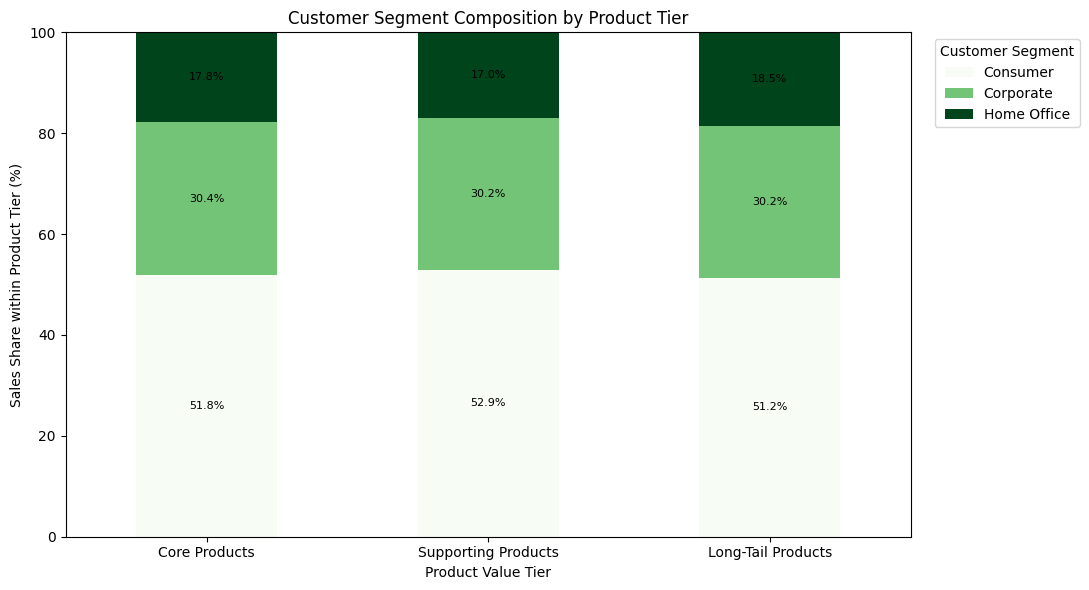


Market Composition by Product Tier


,product_value_tier,Market,customer_count,order_count,total_sales,total_profit,sales_share_pct,profit_margin
0,Core Products,Africa,"3,220","3,733","2,109,728","233,438",6.76%,11.06%
1,Core Products,Europe,"8,809","15,310","8,665,333","946,512",27.76%,10.92%
2,Core Products,LATAM,"9,156","16,540","9,340,830","1,013,046",29.92%,10.85%
3,Core Products,Pacific Asia,"7,503","11,544","6,447,013","653,966",20.65%,10.14%
4,Core Products,USCA,"6,103","8,291","4,654,357","520,285",14.91%,11.18%
5,Long-Tail Products,Africa,496,508,"48,179","3,942",2.65%,8.18%
6,Long-Tail Products,Europe,"3,294","3,582","631,933","56,570",34.78%,8.95%
7,Long-Tail Products,LATAM,"2,291","2,542","344,528","45,315",18.96%,13.15%
8,Long-Tail Products,Pacific Asia,"5,438","5,530","689,854","70,065",37.97%,10.16%
9,Long-Tail Products,USCA,"1,039","1,083","102,201","13,924",5.63%,13.62%


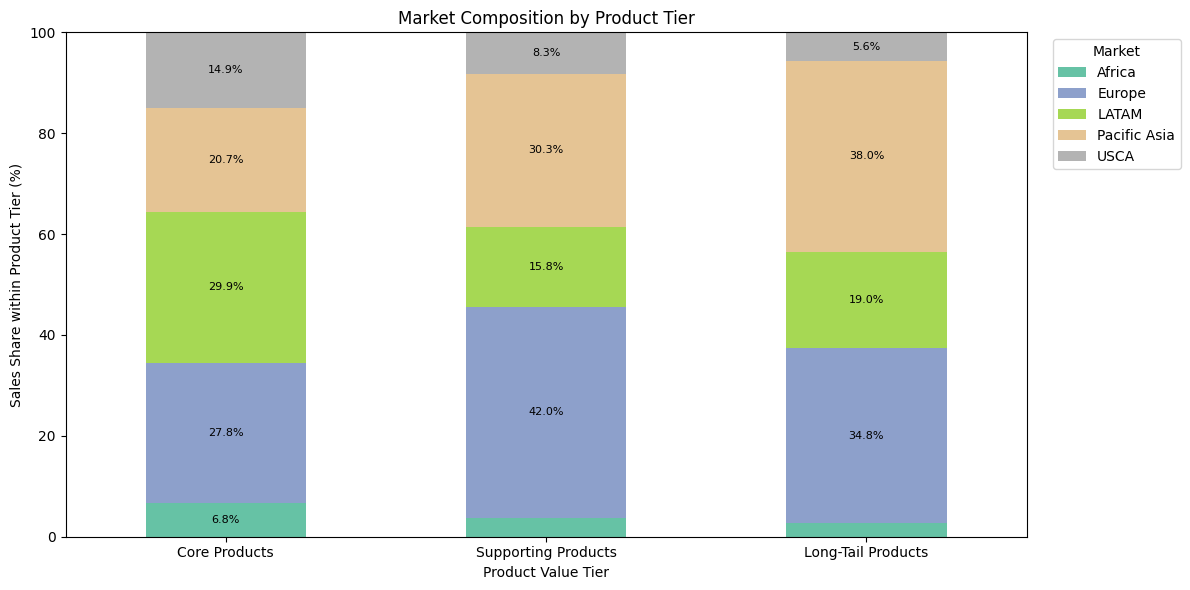


Shipping Mode Composition by Product Tier


,product_value_tier,Shipping Mode,order_count,late_delivery_rate,order_share_pct
0,Core Products,First Class,"8,495",95.27%,15.33%
1,Core Products,Same Day,"2,999",45.62%,5.41%
2,Core Products,Second Class,"10,752",76.58%,19.40%
3,Core Products,Standard Class,"33,172",38.15%,59.86%
4,Long-Tail Products,First Class,"1,982",95.86%,14.96%
5,Long-Tail Products,Same Day,771,48.64%,5.82%
6,Long-Tail Products,Second Class,"2,577",78.27%,19.46%
7,Long-Tail Products,Standard Class,"7,915",38.18%,59.76%
8,Supporting Products,First Class,"2,912",95.33%,15.86%
9,Supporting Products,Same Day,965,45.39%,5.26%


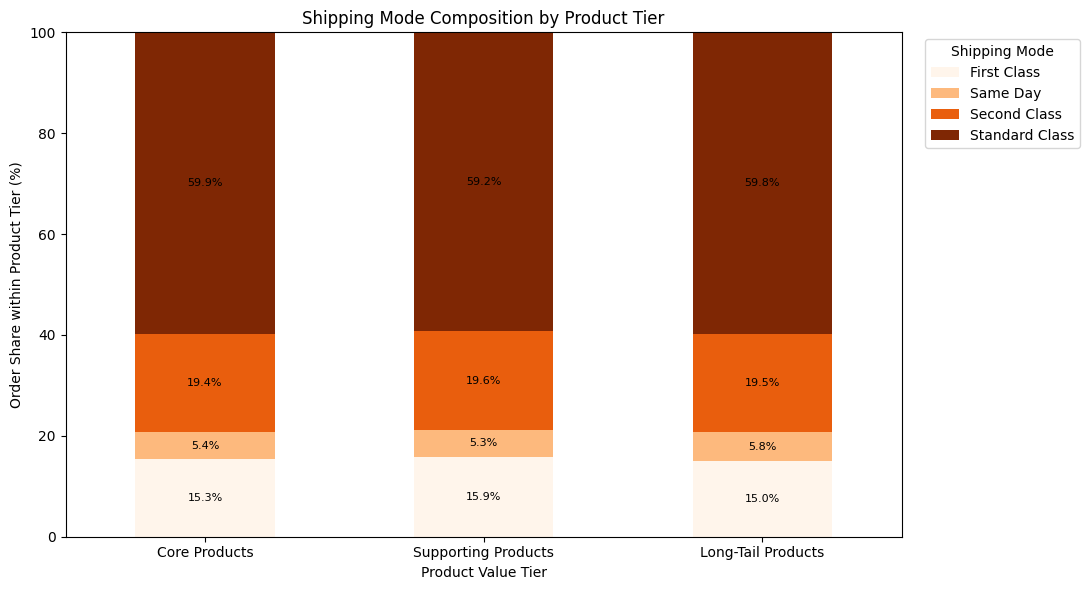


Operational Profile by Product Tier


,product_value_tier,avg_discount_rate,late_delivery_rate,total_sales,total_profit,weighted_profit_margin
0,Core Products,10.16%,54.70%,"31,217,262","3,367,247",10.79%
1,Supporting Products,10.17%,55.47%,"3,750,779","409,839",10.93%
2,Long-Tail Products,10.19%,55.20%,"1,816,694","189,817",10.45%


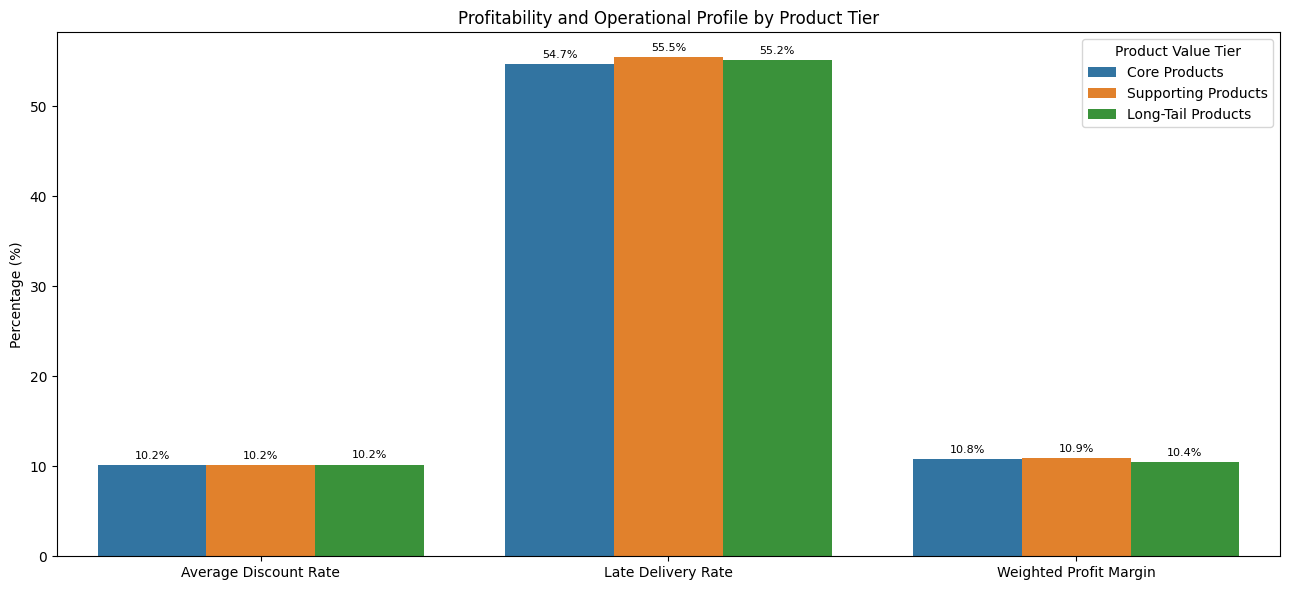


Product Tier Profile Validation
All Retained Records Have Valid Tiers: True
Unmapped Source Records: 0

Customer Segment Sales Shares
Core Products: 100.00%
Long-Tail Products: 100.00%
Supporting Products: 100.00%

Market Sales Shares
Core Products: 100.00%
Long-Tail Products: 100.00%
Supporting Products: 100.00%

Shipping Mode Order Shares
Core Products: 100.00%
Long-Tail Products: 100.00%
Supporting Products: 100.00%

Customer Value Sales Shares
Core Products: 100.00%
Long-Tail Products: 100.00%
Supporting Products: 100.00%

Product Tier Profile Summary


,product_value_tier,category_count,customer_count,customer_reach_pct,orders_per_customer,avg_order_value,avg_profit_per_order,avg_quantity_per_order,weighted_profit_margin,avg_discount_rate,late_delivery_rate
0,Core Products,8,"12,307",59.59%,4.50,563.31,60.76,5.43,10.79%,10.16%,54.70%
1,Supporting Products,10,"11,993",58.07%,1.53,204.32,22.33,2.97,10.93%,10.17%,55.47%
2,Long-Tail Products,32,"11,061",53.56%,1.20,137.16,14.33,2.17,10.45%,10.19%,55.20%


In [83]:
# ============================================================
# Step 8.3.1 Validate and Prepare the Tier-Level Transaction Dataset
# ============================================================

# Confirm that the required source dataframes exist.
if "df_clean" not in globals():
    raise NameError(
        "df_clean is not defined. "
        "Please run the data-cleaning steps first."
    )

if "product_value_df" not in globals():
    raise NameError(
        "product_value_df is not defined. "
        "Please run Step 8.2 first."
    )

# Define the tier order used throughout the analysis.
product_tier_order = [
    "Core Products",
    "Supporting Products",
    "Long-Tail Products"
]

# Define required transaction-level fields.
required_transaction_cols = [
    "Category Name",
    "Customer Id",
    "Customer Segment",
    "Order Id",
    "Order Item Id",
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order",
    "Order Item Discount Rate",
    "Late_delivery_risk",
    "Market",
    "Shipping Mode"
]

# Identify missing transaction fields.
missing_transaction_cols = [
    col for col in required_transaction_cols
    if col not in df_clean.columns
]

if missing_transaction_cols:
    raise KeyError(
        "Missing required columns in df_clean: "
        f"{missing_transaction_cols}"
    )

# Define required fields from Step 8.2.
required_tier_cols = [
    "Category Name",
    "product_value_tier"
]

# Identify missing tier fields.
missing_tier_cols = [
    col for col in required_tier_cols
    if col not in product_value_df.columns
]

if missing_tier_cols:
    raise KeyError(
        "Missing required columns in product_value_df: "
        f"{missing_tier_cols}"
    )

# Build one tier record for each product category.
product_tier_mapping = (
    product_value_df[
        required_tier_cols
    ]
    .drop_duplicates(
        subset=["Category Name"]
    )
    .copy()
)

# Convert the tier variable into a regular string before merging.
product_tier_mapping["product_value_tier"] = (
    product_tier_mapping["product_value_tier"]
    .astype(str)
)

# Join product tiers to the original transaction-level dataset.
product_tier_profile_df = (
    df_clean
    .merge(
        product_tier_mapping,
        on="Category Name",
        how="left",
        validate="many_to_one"
    )
)

# Count records that could not be assigned to a product tier.
unmapped_record_count = (
    product_tier_profile_df["product_value_tier"]
    .isna()
    .sum()
)

# Keep only the three valid product tiers.
product_tier_profile_df = (
    product_tier_profile_df
    .loc[
        product_tier_profile_df["product_value_tier"]
        .isin(product_tier_order)
    ]
    .copy()
)

# Convert analytical fields to numeric.
numeric_cols = [
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order",
    "Order Item Discount Rate",
    "Late_delivery_risk"
]

for col in numeric_cols:
    product_tier_profile_df[col] = pd.to_numeric(
        product_tier_profile_df[col],
        errors="coerce"
    )

# Remove records without essential transaction values.
product_tier_profile_df = (
    product_tier_profile_df
    .dropna(
        subset=[
            "Customer Id",
            "Order Id",
            "Order Item Id",
            "Sales",
            "Order Profit Per Order"
        ]
    )
    .copy()
)

if product_tier_profile_df.empty:
    raise ValueError(
        "No valid transaction records are available "
        "for Product Tier Profile analysis."
    )

print("=" * 75)
print("Product Tier Profile Data Validation")
print("=" * 75)
print(
    "Transaction Rows:",
    f"{len(product_tier_profile_df):,}"
)
print(
    "Product Categories:",
    f"{product_tier_profile_df['Category Name'].nunique():,}"
)
print(
    "Unique Customers:",
    f"{product_tier_profile_df['Customer Id'].nunique():,}"
)
print(
    "Unique Orders:",
    f"{product_tier_profile_df['Order Id'].nunique():,}"
)
print(
    "Unmapped Source Records:",
    f"{unmapped_record_count:,}"
)


# ============================================================
# Step 8.3.2 Compare Customer Reach and Order Activity
# ============================================================
# This section profiles product tiers across three dimensions:
#
# 1. Customer Reach
#    - Unique Customer Count
#    - Customer Reach Percentage
#
# 2. Purchase Frequency
#    - Unique Order Count
#    - Orders per Reached Customer
#
# 3. Transaction Depth
#    - Unique Order-Item Count
#    - Order Items per Tier-Order
#
# Each chart combines an actual count with a corresponding
# rate using two Y-axes.
#
# Important:
# A customer or order may appear in more than one product tier.
# Tier-level counts therefore cannot be summed to obtain the
# overall unique customer or order total.
# ============================================================


# ------------------------------------------------------------
# 1. Build customer reach and transaction activity profile
# ------------------------------------------------------------

tier_activity_profile = (
    product_tier_profile_df
    .groupby(
        "product_value_tier",
        observed=True
    )
    .agg(
        category_count=("Category Name", "nunique"),
        customer_count=("Customer Id", "nunique"),
        order_count=("Order Id", "nunique"),
        order_item_count=("Order Item Id", "nunique"),
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
    .reindex(product_tier_order)
    .reset_index()
)


# ------------------------------------------------------------
# 2. Calculate customer reach, frequency, and depth metrics
# ------------------------------------------------------------

# Calculate the total number of unique customers in the
# transaction dataset.
total_unique_customers = (
    product_tier_profile_df["Customer Id"]
    .nunique()
)

# Customer Reach Percentage:
# Percentage of all unique customers purchasing products
# from each product tier.
tier_activity_profile["customer_reach_pct"] = np.where(
    total_unique_customers != 0,
    (
        tier_activity_profile["customer_count"]
        / total_unique_customers
        * 100
    ),
    np.nan
)

# Orders per Reached Customer:
# Average number of tier-related orders generated by each
# customer who purchased from that tier.
tier_activity_profile["orders_per_customer"] = np.where(
    tier_activity_profile["customer_count"].ne(0),
    (
        tier_activity_profile["order_count"]
        / tier_activity_profile["customer_count"]
    ),
    np.nan
)

# Order Items per Tier-Order:
# Average number of order-item rows associated with each
# tier-related order.
tier_activity_profile["items_per_order"] = np.where(
    tier_activity_profile["order_count"].ne(0),
    (
        tier_activity_profile["order_item_count"]
        / tier_activity_profile["order_count"]
    ),
    np.nan
)


# ------------------------------------------------------------
# 3. Display the complete activity profile
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("Customer Reach and Order Activity by Product Tier")
print("=" * 75)

display(
    tier_activity_profile.style.format({
        "category_count": "{:,.0f}",
        "customer_count": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "order_count": "{:,.0f}",
        "orders_per_customer": "{:.2f}",
        "order_item_count": "{:,.0f}",
        "items_per_order": "{:.2f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}"
    })
)


# ------------------------------------------------------------
# 4. Prepare chart labels and colors
# ------------------------------------------------------------

tier_labels = (
    tier_activity_profile["product_value_tier"]
    .astype(str)
)

# Bar colors represent actual scale measures.
bar_colors = [
    "steelblue",
    "darkorange",
    "seagreen"
]

# Line colors represent rates or depth indicators.
line_colors = [
    "#1F4E79",
    "#A64B00",
    "#205C37"
]


# ------------------------------------------------------------
# 5. Create three side-by-side profile charts
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 6)
)


# ------------------------------------------------------------
# Chart 1: Customer Reach Profile
# ------------------------------------------------------------
# Bars:
# Actual unique customer count
#
# Line:
# Percentage of all unique customers reached
# ------------------------------------------------------------

customer_axis = axes[0]

customer_bars = customer_axis.bar(
    tier_labels,
    tier_activity_profile["customer_count"],
    color=bar_colors[0],
    alpha=0.85,
    label="Unique Customers"
)

customer_axis.set_title(
    "Customer Reach Profile"
)

customer_axis.set_xlabel(
    "Product Value Tier"
)

customer_axis.set_ylabel(
    "Unique Customer Count",
    color=bar_colors[0]
)

customer_axis.tick_params(
    axis="x",
    rotation=15
)

customer_axis.tick_params(
    axis="y",
    labelcolor=bar_colors[0]
)

customer_axis.grid(
    axis="y",
    alpha=0.20
)

# Add actual customer counts above the bars.
customer_axis.bar_label(
    customer_bars,
    labels=[
        f"{value:,.0f}"
        for value in tier_activity_profile["customer_count"]
    ],
    padding=3,
    fontsize=9
)

# Add customer reach percentage on the secondary axis.
customer_rate_axis = customer_axis.twinx()

customer_rate_axis.plot(
    tier_labels,
    tier_activity_profile["customer_reach_pct"],
    color=line_colors[0],
    marker="o",
    markersize=7,
    linewidth=2,
    label="Customer Reach"
)

customer_rate_axis.set_ylabel(
    "Customer Reach (%)",
    color=line_colors[0]
)

customer_rate_axis.tick_params(
    axis="y",
    labelcolor=line_colors[0]
)

# Use zero as the baseline to avoid overstating small differences.
customer_rate_axis.set_ylim(
    0,
    max(
        100,
        tier_activity_profile["customer_reach_pct"].max() * 1.20
    )
)

# Add percentage labels next to line markers.
for position, value in enumerate(
    tier_activity_profile["customer_reach_pct"]
):
    customer_rate_axis.annotate(
        f"{value:.1f}%",
        xy=(position, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=line_colors[0]
    )

# Combine both legends.
handles1, labels1 = (
    customer_axis.get_legend_handles_labels()
)

handles2, labels2 = (
    customer_rate_axis.get_legend_handles_labels()
)

customer_axis.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower left",
    fontsize=8
)


# ------------------------------------------------------------
# Chart 2: Purchase Frequency Profile
# ------------------------------------------------------------
# Bars:
# Actual unique order count
#
# Line:
# Average orders per reached customer
# ------------------------------------------------------------

order_axis = axes[1]

order_bars = order_axis.bar(
    tier_labels,
    tier_activity_profile["order_count"],
    color=bar_colors[1],
    alpha=0.85,
    label="Unique Orders"
)

order_axis.set_title(
    "Purchase Frequency Profile"
)

order_axis.set_xlabel(
    "Product Value Tier"
)

order_axis.set_ylabel(
    "Unique Order Count",
    color=bar_colors[1]
)

order_axis.tick_params(
    axis="x",
    rotation=15
)

order_axis.tick_params(
    axis="y",
    labelcolor=bar_colors[1]
)

order_axis.grid(
    axis="y",
    alpha=0.20
)

# Add actual order counts above the bars.
order_axis.bar_label(
    order_bars,
    labels=[
        f"{value:,.0f}"
        for value in tier_activity_profile["order_count"]
    ],
    padding=3,
    fontsize=9
)

# Add orders per customer on the secondary axis.
frequency_axis = order_axis.twinx()

frequency_axis.plot(
    tier_labels,
    tier_activity_profile["orders_per_customer"],
    color=line_colors[1],
    marker="o",
    markersize=7,
    linewidth=2,
    label="Orders per Customer"
)

frequency_axis.set_ylabel(
    "Orders per Reached Customer",
    color=line_colors[1]
)

frequency_axis.tick_params(
    axis="y",
    labelcolor=line_colors[1]
)

frequency_axis.set_ylim(
    0,
    tier_activity_profile["orders_per_customer"].max() * 1.30
)

# Add frequency labels next to line markers.
for position, value in enumerate(
    tier_activity_profile["orders_per_customer"]
):
    frequency_axis.annotate(
        f"{value:.2f}",
        xy=(position, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=line_colors[1]
    )

# Combine both legends.
handles1, labels1 = (
    order_axis.get_legend_handles_labels()
)

handles2, labels2 = (
    frequency_axis.get_legend_handles_labels()
)

order_axis.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    fontsize=8
)


# ------------------------------------------------------------
# Chart 3: Transaction Depth Profile
# ------------------------------------------------------------
# Bars:
# Actual unique order-item count
#
# Line:
# Average order items per tier-related order
# ------------------------------------------------------------

item_axis = axes[2]

item_bars = item_axis.bar(
    tier_labels,
    tier_activity_profile["order_item_count"],
    color=bar_colors[2],
    alpha=0.85,
    label="Unique Order Items"
)

item_axis.set_title(
    "Transaction Depth Profile"
)

item_axis.set_xlabel(
    "Product Value Tier"
)

item_axis.set_ylabel(
    "Unique Order-Item Count",
    color=bar_colors[2]
)

item_axis.tick_params(
    axis="x",
    rotation=15
)

item_axis.tick_params(
    axis="y",
    labelcolor=bar_colors[2]
)

item_axis.grid(
    axis="y",
    alpha=0.20
)

# Add actual order-item counts above the bars.
item_axis.bar_label(
    item_bars,
    labels=[
        f"{value:,.0f}"
        for value in tier_activity_profile["order_item_count"]
    ],
    padding=3,
    fontsize=9
)

# Add order-item depth on the secondary axis.
depth_axis = item_axis.twinx()

depth_axis.plot(
    tier_labels,
    tier_activity_profile["items_per_order"],
    color=line_colors[2],
    marker="o",
    markersize=7,
    linewidth=2,
    label="Items per Order"
)

depth_axis.set_ylabel(
    "Order Items per Tier-Order",
    color=line_colors[2]
)

depth_axis.tick_params(
    axis="y",
    labelcolor=line_colors[2]
)

depth_axis.set_ylim(
    0,
    tier_activity_profile["items_per_order"].max() * 1.30
)

# Add transaction-depth labels next to line markers.
for position, value in enumerate(
    tier_activity_profile["items_per_order"]
):
    depth_axis.annotate(
        f"{value:.2f}",
        xy=(position, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=line_colors[2]
    )

# Combine both legends.
handles1, labels1 = (
    item_axis.get_legend_handles_labels()
)

handles2, labels2 = (
    depth_axis.get_legend_handles_labels()
)

item_axis.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    fontsize=8
)


# ------------------------------------------------------------
# 6. Apply final layout adjustments
# ------------------------------------------------------------

fig.suptitle(
    "Customer Reach, Purchase Frequency, and "
    "Transaction Depth by Product Tier",
    fontsize=15,
    y=1.03
)

# Add headroom above count bars for value labels.
for axis in axes:
    current_bottom, current_top = axis.get_ylim()

    axis.set_ylim(
        current_bottom,
        current_top * 1.10
    )

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.3.3 Compare Order Value and Profitability
# ============================================================
# Aggregate transaction records by Product Tier and Order Id.
#
# If one order contains products from multiple tiers, the order
# appears once within each relevant tier. The calculated values
# represent only the sales and profit attributable to that tier.
#
# Visual outputs:
# 1. Average Order Value and Average Profit per Order
# 2. Weighted Profit Margin
#
# Quantity-related metrics remain available in the summary table
# but are not visualized separately to avoid redundant charts.
# ============================================================


# ------------------------------------------------------------
# 1. Build the tier-order-level dataset
# ------------------------------------------------------------

tier_order_df = (
    product_tier_profile_df
    .groupby(
        [
            "product_value_tier",
            "Order Id"
        ],
        observed=True
    )
    .agg(
        order_sales=("Sales", "sum"),
        order_profit=("Order Profit Per Order", "sum"),
        order_quantity=("Order Item Quantity", "sum"),
        order_item_count=("Order Item Id", "nunique")
    )
    .reset_index()
)

# Calculate the profit margin for each tier-related order.
tier_order_df["order_profit_margin"] = np.where(
    tier_order_df["order_sales"].ne(0),
    (
        tier_order_df["order_profit"]
        / tier_order_df["order_sales"]
        * 100
    ),
    np.nan
)


# ------------------------------------------------------------
# 2. Build the product-tier order profile
# ------------------------------------------------------------

tier_order_profile = (
    tier_order_df
    .groupby(
        "product_value_tier",
        observed=True
    )
    .agg(
        order_count=("Order Id", "nunique"),
        avg_order_value=("order_sales", "mean"),
        median_order_value=("order_sales", "median"),
        avg_profit_per_order=("order_profit", "mean"),
        median_profit_per_order=("order_profit", "median"),
        avg_quantity_per_order=("order_quantity", "mean"),
        median_quantity_per_order=("order_quantity", "median"),
        avg_items_per_order=("order_item_count", "mean"),
        total_sales=("order_sales", "sum"),
        total_profit=("order_profit", "sum")
    )
    .reindex(product_tier_order)
    .reset_index()
)

# Calculate weighted profit margin.
#
# Weighted Profit Margin =
# Tier Total Profit / Tier Total Sales
tier_order_profile["weighted_profit_margin"] = np.where(
    tier_order_profile["total_sales"].ne(0),
    (
        tier_order_profile["total_profit"]
        / tier_order_profile["total_sales"]
        * 100
    ),
    np.nan
)


# ------------------------------------------------------------
# 3. Display the complete order profile
# ------------------------------------------------------------
# Quantity metrics are retained in this table even though they
# are not shown in separate charts.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("Order Value, Quantity, and Profitability by Product Tier")
print("=" * 75)

display(
    tier_order_profile.style.format({
        "order_count": "{:,.0f}",
        "avg_order_value": "{:,.2f}",
        "median_order_value": "{:,.2f}",
        "avg_profit_per_order": "{:,.2f}",
        "median_profit_per_order": "{:,.2f}",
        "avg_quantity_per_order": "{:.2f}",
        "median_quantity_per_order": "{:.2f}",
        "avg_items_per_order": "{:.2f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "weighted_profit_margin": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# 4. Chart 1: Average Order Value and Profit per Order
# ------------------------------------------------------------
# Both indicators are monetary measures:
#
# Average Order Value:
# Average sales generated by each tier-related order
#
# Average Profit per Order:
# Average absolute profit generated by each tier-related order
#
# Note:
# Average Order Value is expected to be larger than Average
# Profit per Order. Exact values are displayed above the bars.
# ------------------------------------------------------------

value_profit_df = (
    tier_order_profile[
        [
            "product_value_tier",
            "avg_order_value",
            "avg_profit_per_order"
        ]
    ]
    .melt(
        id_vars="product_value_tier",
        value_vars=[
            "avg_order_value",
            "avg_profit_per_order"
        ],
        var_name="metric",
        value_name="amount"
    )
)

# Convert technical field names into readable chart labels.
value_profit_df["metric"] = (
    value_profit_df["metric"]
    .map({
        "avg_order_value": "Average Order Value",
        "avg_profit_per_order": "Average Profit per Order"
    })
)

fig, ax = plt.subplots(figsize=(11, 6))

value_profit_axis = sns.barplot(
    data=value_profit_df,
    x="product_value_tier",
    y="amount",
    hue="metric",
    hue_order=[
        "Average Order Value",
        "Average Profit per Order"
    ],
    palette={
        "Average Order Value": "steelblue",
        "Average Profit per Order": "darkorange"
    },
    ax=ax
)

value_profit_axis.set_title(
    "Order Value and Profit per Order by Product Tier"
)

value_profit_axis.set_xlabel(
    "Product Value Tier"
)

value_profit_axis.set_ylabel(
    "Amount"
)

value_profit_axis.tick_params(
    axis="x",
    rotation=0
)

value_profit_axis.legend(
    title="Metric"
)

# Add actual monetary values above the bars.
for container in value_profit_axis.containers:

    value_profit_axis.bar_label(
        container,
        labels=[
            f"{value:,.1f}"
            for value in container.datavalues
        ],
        padding=3,
        fontsize=9
    )

# Add sufficient space above the tallest bar.
current_bottom, current_top = (
    value_profit_axis.get_ylim()
)

value_profit_axis.set_ylim(
    current_bottom,
    current_top * 1.10
)

value_profit_axis.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Chart 2: Weighted Profit Margin
# ------------------------------------------------------------
# Weighted profit margin measures profitability efficiency,
# while the previous chart measures transaction size and
# absolute profit generation.
#
# This chart is kept separate because margin is a percentage.
# ------------------------------------------------------------

tier_colors = [
    "#2E8B57",  # Core Products
    "#F2A541",  # Supporting Products
    "#9E9E9E"   # Long-Tail Products
]

fig, ax = plt.subplots(figsize=(9, 6))

margin_bars = ax.bar(
    tier_order_profile[
        "product_value_tier"
    ].astype(str),
    tier_order_profile[
        "weighted_profit_margin"
    ],
    color=tier_colors
)

ax.set_title(
    "Weighted Profit Margin by Product Tier"
)

ax.set_xlabel(
    "Product Value Tier"
)

ax.set_ylabel(
    "Weighted Profit Margin (%)"
)

ax.tick_params(
    axis="x",
    rotation=0
)

# Add actual percentages above the bars.
ax.bar_label(
    margin_bars,
    labels=[
        f"{value:.2f}%"
        for value in tier_order_profile[
            "weighted_profit_margin"
        ]
    ],
    padding=3,
    fontsize=9
)

# Start the Y-axis at zero to avoid exaggerating
# small differences between product tiers.
ax.set_ylim(
    0,
    tier_order_profile[
        "weighted_profit_margin"
    ].max() * 1.15
)

ax.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()

# ============================================================
# Step 8.3.4 Analyze Customer-Value Composition by Tier
# ============================================================
# This section uses customer_value_df from Step 7.
#
# Expected columns:
# - Customer Id
# - customer_value_segment
#
# Sales shares are calculated within each product tier.
# ============================================================

customer_value_profile = None

if "customer_value_df" not in globals():
    print(
        "\nCustomer-value composition skipped because "
        "customer_value_df was not found."
    )

else:
    required_customer_value_cols = [
        "Customer Id",
        "customer_value_segment"
    ]

    missing_customer_value_cols = [
        col for col in required_customer_value_cols
        if col not in customer_value_df.columns
    ]

    if missing_customer_value_cols:
        print(
            "\nCustomer-value composition skipped. "
            f"Missing columns: {missing_customer_value_cols}"
        )

    else:
        # Create one value-segment record per customer.
        customer_value_mapping = (
            customer_value_df[
                required_customer_value_cols
            ]
            .drop_duplicates(
                subset=["Customer Id"]
            )
            .copy()
        )

        customer_value_mapping["customer_value_segment"] = (
            customer_value_mapping["customer_value_segment"]
            .astype(str)
        )

        # Join customer value segments to product-tier transactions.
        tier_customer_value_df = (
            product_tier_profile_df
            .merge(
                customer_value_mapping,
                on="Customer Id",
                how="left",
                validate="many_to_one"
            )
        )

        # Identify customer records without a value segment.
        unmapped_customer_value_count = (
            tier_customer_value_df[
                "customer_value_segment"
            ]
            .isna()
            .sum()
        )

        # Aggregate sales and profit by product tier and customer value.
        customer_value_profile = (
            tier_customer_value_df
            .dropna(
                subset=["customer_value_segment"]
            )
            .groupby(
                [
                    "product_value_tier",
                    "customer_value_segment"
                ],
                observed=True
            )
            .agg(
                customer_count=("Customer Id", "nunique"),
                order_count=("Order Id", "nunique"),
                total_sales=("Sales", "sum"),
                total_profit=("Order Profit Per Order", "sum")
            )
            .reset_index()
        )

        # Calculate sales and profit composition within each tier.
        customer_value_profile["sales_share_pct"] = (
            customer_value_profile["total_sales"]
            / customer_value_profile
            .groupby("product_value_tier")["total_sales"]
            .transform("sum")
            * 100
        )

        customer_value_profile["profit_share_pct"] = (
            customer_value_profile["total_profit"]
            / customer_value_profile
            .groupby("product_value_tier")["total_profit"]
            .transform("sum")
            * 100
        )

        print("\n" + "=" * 75)
        print("Customer Value Composition by Product Tier")
        print("=" * 75)
        print(
            "Transactions without Customer Value Segment:",
            f"{unmapped_customer_value_count:,}"
        )

        display(
            customer_value_profile.style.format({
                "customer_count": "{:,.0f}",
                "order_count": "{:,.0f}",
                "total_sales": "{:,.0f}",
                "total_profit": "{:,.0f}",
                "sales_share_pct": "{:.2f}%",
                "profit_share_pct": "{:.2f}%"
            })
        )

        # Use the value-segment order available in the data.
        preferred_customer_value_order = [
            "VIP",
            "High Value",
            "Medium Value",
            "Medium-Low Value",
            "Low Value"
        ]

        available_value_segments = (
            customer_value_profile[
                "customer_value_segment"
            ]
            .dropna()
            .unique()
            .tolist()
        )

        customer_value_order = [
            segment
            for segment in preferred_customer_value_order
            if segment in available_value_segments
        ]

        # Add unexpected segments at the end.
        customer_value_order += [
            segment
            for segment in available_value_segments
            if segment not in customer_value_order
        ]

        customer_value_pivot = (
            customer_value_profile
            .pivot(
                index="product_value_tier",
                columns="customer_value_segment",
                values="sales_share_pct"
            )
            .fillna(0)
            .reindex(
                index=product_tier_order,
                columns=customer_value_order,
                fill_value=0
            )
        )

        customer_value_axis = (
            customer_value_pivot
            .plot(
                kind="bar",
                stacked=True,
                figsize=(12, 6),
                colormap="Blues"
            )
        )

        customer_value_axis.set_title(
            "Customer Value Composition by Product Tier"
        )
        customer_value_axis.set_xlabel(
            "Product Value Tier"
        )
        customer_value_axis.set_ylabel(
            "Sales Share within Product Tier (%)"
        )
        customer_value_axis.set_ylim(0, 100)
        customer_value_axis.tick_params(
            axis="x",
            rotation=0
        )
        customer_value_axis.legend(
            title="Customer Value Segment",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        for container in customer_value_axis.containers:
            labels = [
                f"{value:.1f}%"
                if value >= 4
                else ""
                for value in container.datavalues
            ]

            customer_value_axis.bar_label(
                container,
                labels=labels,
                label_type="center",
                fontsize=8
            )

        plt.tight_layout()
        plt.show()


# ============================================================
# Step 8.3.5 Analyze Customer-Segment and Market Composition
# ============================================================
# Analyze sales composition across:
#
# 1. Original customer segments
# 2. Geographic markets
#
# Percentages are calculated within each product tier.
# ============================================================

# ------------------------------------------------------------
# Profile A: Original customer-segment composition
# ------------------------------------------------------------

customer_segment_profile = (
    product_tier_profile_df
    .groupby(
        [
            "product_value_tier",
            "Customer Segment"
        ],
        observed=True
    )
    .agg(
        customer_count=("Customer Id", "nunique"),
        order_count=("Order Id", "nunique"),
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

customer_segment_profile["sales_share_pct"] = (
    customer_segment_profile["total_sales"]
    / customer_segment_profile
    .groupby("product_value_tier")["total_sales"]
    .transform("sum")
    * 100
)

customer_segment_profile["profit_margin"] = np.where(
    customer_segment_profile["total_sales"].ne(0),
    (
        customer_segment_profile["total_profit"]
        / customer_segment_profile["total_sales"]
        * 100
    ),
    np.nan
)

print("\n" + "=" * 75)
print("Customer Segment Composition by Product Tier")
print("=" * 75)

display(
    customer_segment_profile.style.format({
        "customer_count": "{:,.0f}",
        "order_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "sales_share_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)

customer_segment_pivot = (
    customer_segment_profile
    .pivot(
        index="product_value_tier",
        columns="Customer Segment",
        values="sales_share_pct"
    )
    .fillna(0)
    .reindex(product_tier_order)
)

customer_segment_axis = (
    customer_segment_pivot
    .plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        colormap="Greens"
    )
)

customer_segment_axis.set_title(
    "Customer Segment Composition by Product Tier"
)
customer_segment_axis.set_xlabel(
    "Product Value Tier"
)
customer_segment_axis.set_ylabel(
    "Sales Share within Product Tier (%)"
)
customer_segment_axis.set_ylim(0, 100)
customer_segment_axis.tick_params(
    axis="x",
    rotation=0
)
customer_segment_axis.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in customer_segment_axis.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 4
        else ""
        for value in container.datavalues
    ]

    customer_segment_axis.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Profile B: Geographic market composition
# ------------------------------------------------------------

market_profile = (
    product_tier_profile_df
    .groupby(
        [
            "product_value_tier",
            "Market"
        ],
        observed=True
    )
    .agg(
        customer_count=("Customer Id", "nunique"),
        order_count=("Order Id", "nunique"),
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

market_profile["sales_share_pct"] = (
    market_profile["total_sales"]
    / market_profile
    .groupby("product_value_tier")["total_sales"]
    .transform("sum")
    * 100
)

market_profile["profit_margin"] = np.where(
    market_profile["total_sales"].ne(0),
    (
        market_profile["total_profit"]
        / market_profile["total_sales"]
        * 100
    ),
    np.nan
)

print("\n" + "=" * 75)
print("Market Composition by Product Tier")
print("=" * 75)

display(
    market_profile.style.format({
        "customer_count": "{:,.0f}",
        "order_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "sales_share_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)

# Pivot all available markets for a stacked composition chart.
market_pivot = (
    market_profile
    .pivot(
        index="product_value_tier",
        columns="Market",
        values="sales_share_pct"
    )
    .fillna(0)
    .reindex(product_tier_order)
)

market_axis = (
    market_pivot
    .plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        colormap="Set2"
    )
)

market_axis.set_title(
    "Market Composition by Product Tier"
)
market_axis.set_xlabel(
    "Product Value Tier"
)
market_axis.set_ylabel(
    "Sales Share within Product Tier (%)"
)
market_axis.set_ylim(0, 100)
market_axis.tick_params(
    axis="x",
    rotation=0
)
market_axis.legend(
    title="Market",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in market_axis.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 5
        else ""
        for value in container.datavalues
    ]

    market_axis.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.3.6 Compare Shipping, Discount, and Delivery Profiles
# ============================================================
# Shipping composition is calculated at tier-order level to
# reduce duplicated counting from multi-item transactions.
#
# If one order contains products from multiple tiers, the order
# remains represented within each relevant tier.
# ============================================================

# Create one row per product tier and order for shipping analysis.
tier_shipping_order_df = (
    product_tier_profile_df[
        [
            "product_value_tier",
            "Order Id",
            "Shipping Mode",
            "Late_delivery_risk"
        ]
    ]
    .drop_duplicates(
        subset=[
            "product_value_tier",
            "Order Id"
        ]
    )
    .copy()
)

shipping_profile = (
    tier_shipping_order_df
    .groupby(
        [
            "product_value_tier",
            "Shipping Mode"
        ],
        observed=True
    )
    .agg(
        order_count=("Order Id", "nunique"),
        late_delivery_rate=("Late_delivery_risk", "mean")
    )
    .reset_index()
)

shipping_profile["order_share_pct"] = (
    shipping_profile["order_count"]
    / shipping_profile
    .groupby("product_value_tier")["order_count"]
    .transform("sum")
    * 100
)

shipping_profile["late_delivery_rate"] = (
    shipping_profile["late_delivery_rate"]
    * 100
)

print("\n" + "=" * 75)
print("Shipping Mode Composition by Product Tier")
print("=" * 75)

display(
    shipping_profile.style.format({
        "order_count": "{:,.0f}",
        "order_share_pct": "{:.2f}%",
        "late_delivery_rate": "{:.2f}%"
    })
)

shipping_pivot = (
    shipping_profile
    .pivot(
        index="product_value_tier",
        columns="Shipping Mode",
        values="order_share_pct"
    )
    .fillna(0)
    .reindex(product_tier_order)
)

shipping_axis = (
    shipping_pivot
    .plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        colormap="Oranges"
    )
)

shipping_axis.set_title(
    "Shipping Mode Composition by Product Tier"
)
shipping_axis.set_xlabel(
    "Product Value Tier"
)
shipping_axis.set_ylabel(
    "Order Share within Product Tier (%)"
)
shipping_axis.set_ylim(0, 100)
shipping_axis.tick_params(
    axis="x",
    rotation=0
)
shipping_axis.legend(
    title="Shipping Mode",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in shipping_axis.containers:
    labels = [
        f"{value:.1f}%"
        if value >= 4
        else ""
        for value in container.datavalues
    ]

    shipping_axis.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()


# Calculate tier-level discount and delivery metrics.
operational_profile = (
    product_tier_profile_df
    .groupby(
        "product_value_tier",
        observed=True
    )
    .agg(
        avg_discount_rate=("Order Item Discount Rate", "mean"),
        late_delivery_rate=("Late_delivery_risk", "mean"),
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
    .reindex(product_tier_order)
    .reset_index()
)

# Convert decimal rates into percentages.
operational_profile["avg_discount_rate"] = (
    operational_profile["avg_discount_rate"]
    * 100
)

operational_profile["late_delivery_rate"] = (
    operational_profile["late_delivery_rate"]
    * 100
)

# Calculate weighted margin for comparison.
operational_profile["weighted_profit_margin"] = np.where(
    operational_profile["total_sales"].ne(0),
    (
        operational_profile["total_profit"]
        / operational_profile["total_sales"]
        * 100
    ),
    np.nan
)

print("\n" + "=" * 75)
print("Operational Profile by Product Tier")
print("=" * 75)

display(
    operational_profile.style.format({
        "avg_discount_rate": "{:.2f}%",
        "late_delivery_rate": "{:.2f}%",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "weighted_profit_margin": "{:.2f}%"
    })
)

operational_long = (
    operational_profile[
        [
            "product_value_tier",
            "avg_discount_rate",
            "late_delivery_rate",
            "weighted_profit_margin"
        ]
    ]
    .melt(
        id_vars="product_value_tier",
        var_name="metric",
        value_name="percentage"
    )
)

operational_long["metric"] = (
    operational_long["metric"]
    .map({
        "avg_discount_rate": "Average Discount Rate",
        "late_delivery_rate": "Late Delivery Rate",
        "weighted_profit_margin": "Weighted Profit Margin"
    })
)

fig, ax = plt.subplots(figsize=(13, 6))

operational_axis = sns.barplot(
    data=operational_long,
    x="metric",
    y="percentage",
    hue="product_value_tier",
    hue_order=product_tier_order,
    ax=ax
)

operational_axis.set_title(
    "Profitability and Operational Profile by Product Tier"
)
operational_axis.set_xlabel("")
operational_axis.set_ylabel("Percentage (%)")
operational_axis.legend(title="Product Value Tier")

for container in operational_axis.containers:
    operational_axis.bar_label(
        container,
        labels=[
            f"{value:.1f}%"
            for value in container.datavalues
        ],
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ============================================================
# Step 8.3.7 Validate and Summarize the Tier Profiles
# ============================================================

# Confirm that all retained transactions have valid tiers.
valid_tier_check = (
    product_tier_profile_df["product_value_tier"]
    .isin(product_tier_order)
    .all()
)

# Validate composition percentages where applicable.
customer_segment_share_check = (
    customer_segment_profile
    .groupby("product_value_tier")["sales_share_pct"]
    .sum()
)

market_share_check = (
    market_profile
    .groupby("product_value_tier")["sales_share_pct"]
    .sum()
)

shipping_share_check = (
    shipping_profile
    .groupby("product_value_tier")["order_share_pct"]
    .sum()
)

if customer_value_profile is not None:
    customer_value_share_check = (
        customer_value_profile
        .groupby("product_value_tier")["sales_share_pct"]
        .sum()
    )

print("\n" + "=" * 75)
print("Product Tier Profile Validation")
print("=" * 75)
print(
    "All Retained Records Have Valid Tiers:",
    valid_tier_check
)
print(
    "Unmapped Source Records:",
    f"{unmapped_record_count:,}"
)

print("\nCustomer Segment Sales Shares")

for tier, share in customer_segment_share_check.items():
    print(
        f"{tier}: {share:.2f}%"
    )

print("\nMarket Sales Shares")

for tier, share in market_share_check.items():
    print(
        f"{tier}: {share:.2f}%"
    )

print("\nShipping Mode Order Shares")

for tier, share in shipping_share_check.items():
    print(
        f"{tier}: {share:.2f}%"
    )

if customer_value_profile is not None:
    print("\nCustomer Value Sales Shares")

    for tier, share in customer_value_share_check.items():
        print(
            f"{tier}: {share:.2f}%"
        )


# ------------------------------------------------------------
# Print the main profile metrics for each product tier
# ------------------------------------------------------------

tier_profile_summary = (
    tier_activity_profile[
        [
            "product_value_tier",
            "category_count",
            "customer_count",
            "customer_reach_pct",
            "orders_per_customer"
        ]
    ]
    .merge(
        tier_order_profile[
            [
                "product_value_tier",
                "avg_order_value",
                "avg_profit_per_order",
                "avg_quantity_per_order",
                "weighted_profit_margin"
            ]
        ],
        on="product_value_tier",
        how="left",
        validate="one_to_one"
    )
    .merge(
        operational_profile[
            [
                "product_value_tier",
                "avg_discount_rate",
                "late_delivery_rate"
            ]
        ],
        on="product_value_tier",
        how="left",
        validate="one_to_one"
    )
)

print("\n" + "=" * 75)
print("Product Tier Profile Summary")
print("=" * 75)

display(
    tier_profile_summary.style.format({
        "category_count": "{:,.0f}",
        "customer_count": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "orders_per_customer": "{:.2f}",
        "avg_order_value": "{:,.2f}",
        "avg_profit_per_order": "{:,.2f}",
        "avg_quantity_per_order": "{:.2f}",
        "weighted_profit_margin": "{:.2f}%",
        "avg_discount_rate": "{:.2f}%",
        "late_delivery_rate": "{:.2f}%"
    })
)

### Key Observations

- Customer reach is broadly similar across tiers, ranging from **53.6% to 59.6%**. However, Core Products generate much stronger engagement, averaging **4.50 orders per customer** and **2.64 items per order**, compared with **1.53 and 1.11** for Supporting Products and **1.20 and 1.05** for Long-Tail Products.

- Core Products also produce substantially higher transaction value. Average order value reaches **563.3**, with **60.8 profit per order**, compared with **204.3 and 22.3** for Supporting Products and **137.2 and 14.3** for Long-Tail Products.

- Profit margins remain similar across tiers at approximately **10.5% to 10.9%**. Product-tier value therefore reflects differences in purchase frequency, transaction depth, and order value rather than margin advantages.

- Core Product sales are highly concentrated among VIP and High Value customers, which contribute **85.0%** combined. Supporting and Long-Tail Products have more balanced customer-value compositions.

- Original customer-segment and shipping-mode compositions are nearly identical across tiers. Market mix differs more noticeably, with Core Products concentrated in LATAM and Europe, Supporting Products in Europe, and Long-Tail Products in Pacific Asia and Europe.

### Business Implications

- Protect Core Product availability and strengthen retention among VIP and High Value customers.
- Use Supporting Products for frequency and basket-building initiatives, while managing Long-Tail Products selectively by market demand.

# Step 9. Product Opportunity Analysis

### Analysis Goal

Where are the most important growth opportunities, portfolio risks, and management priorities across the product portfolio?

The analysis will:

- Assess concentration risk within Core Products
- Identify growth opportunities among Supporting Products
- Review the business value of Long-Tail Products
- Consolidate findings through a Product Opportunity Matrix

The objective is to translate product portfolio insights into actionable business priorities and support future investment, growth, and risk-management decisions.

## Step 9.1 Product Concentration Risk

This step evaluates the business risk associated with dependence on Core Products.

The analysis will:

- Identify Core Product dependency levels
- Measure concentration within Core Products
- Assess customer exposure to Core Products
- Compare dependency across Core Product categories
- Evaluate Core-Tier stress scenarios
- Visualize Core Product dependency
- Validate and summarize portfolio risk exposure

The objective is to determine whether business performance is overly dependent on a small number of Core Product categories.

Core Product Dependency


,sales_rank,Category Name,customer_count,order_count,total_sales,sales_contribution_pct,total_profit,profit_contribution_pct
0,1,Fishing,"8,759","15,164","6,929,654",18.84%,"756,221",19.06%
1,2,Cleats,"10,049","20,386","4,431,943",12.05%,"494,637",12.47%
2,3,Camping & Hiking,"7,788","12,299","4,118,426",11.20%,"427,456",10.78%
3,4,Cardio Equipment,"7,486","11,355","3,694,843",10.04%,"383,011",9.66%
4,5,Women's Apparel,"9,468","17,869","3,147,800",8.56%,"350,421",8.83%
5,6,Water Sports,"8,281","13,758","3,113,845",8.47%,"325,147",8.20%
6,7,Men's Footwear,"9,717","18,783","2,891,758",7.86%,"311,903",7.86%
7,8,Indoor/Outdoor Games,"9,134","16,623","2,888,994",7.85%,"318,451",8.03%



Core Product Concentration


,dependency_group,sales_contribution_pct,profit_contribution_pct
0,Largest Core Product,18.84%,19.06%
1,Top 3 Core Products,42.08%,42.31%
2,Top 5 Core Products,60.68%,60.80%



Customer Exposure by Core Product


,Category Name,customer_count,order_count,total_sales,customer_reach_pct
2,Cleats,"10,049","20,386","4,431,943",48.66%
5,Men's Footwear,"9,717","18,783","2,891,758",47.05%
7,Women's Apparel,"9,468","17,869","3,147,800",45.85%
4,Indoor/Outdoor Games,"9,134","16,623","2,888,994",44.23%
3,Fishing,"8,759","15,164","6,929,654",42.41%
6,Water Sports,"8,281","13,758","3,113,845",40.10%
0,Camping & Hiking,"7,788","12,299","4,118,426",37.71%
1,Cardio Equipment,"7,486","11,355","3,694,843",36.25%



Core Product Dependency Matrix Input


,Category Name,sales_contribution_pct,profit_contribution_pct,customer_count,customer_reach_pct
0,Fishing,18.84%,19.06%,"8,759",42.41%
1,Cleats,12.05%,12.47%,"10,049",48.66%
2,Camping & Hiking,11.20%,10.78%,"7,788",37.71%
3,Cardio Equipment,10.04%,9.66%,"7,486",36.25%
4,Women's Apparel,8.56%,8.83%,"9,468",45.85%
5,Water Sports,8.47%,8.20%,"8,281",40.10%
6,Men's Footwear,7.86%,7.86%,"9,717",47.05%
7,Indoor/Outdoor Games,7.85%,8.03%,"9,134",44.23%


,scenario,decline_rate,portfolio_sales_impact_pct,portfolio_profit_impact_pct
0,Core Products -5%,5%,4.24%,4.24%
1,Core Products -10%,10%,8.49%,8.49%
2,Core Products -20%,20%,16.97%,16.98%


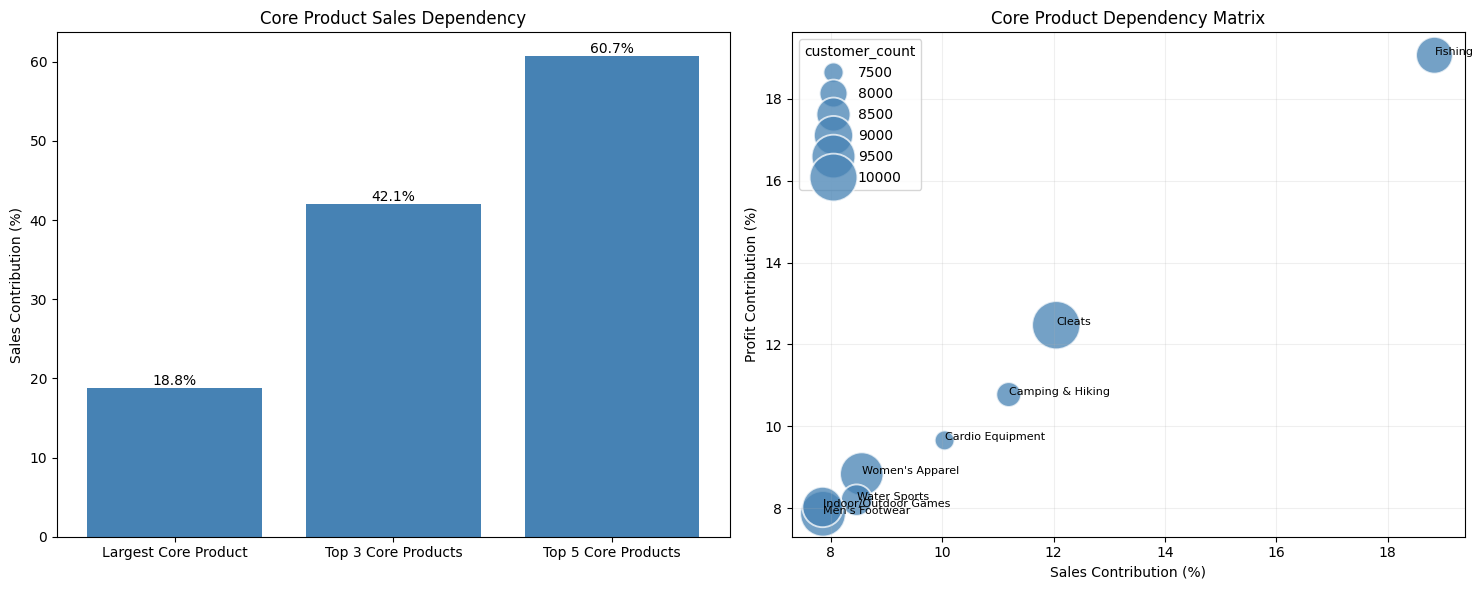


Core Product Risk Summary
Sales Contribution Totals 100%: True
Profit Contribution Totals 100%: True
Largest Core Product: Fishing
Sales Contribution: 18.84%
Profit Contribution: 19.06%
Top 3 Core Products Sales Contribution: 42.08%
Top 3 Core Products Profit Contribution: 42.31%
Core Products Sales Contribution: 84.86%
Core Products Profit Contribution: 84.88%


In [84]:
# ============================================================
# Step 9.1.1 Identify Core Product Dependency Levels
# ============================================================

if "product_summary" not in globals():
    raise NameError(
        "product_summary is not defined. "
        "Please run Step 8.1 first."
    )

if "product_value_df" not in globals():
    raise NameError(
        "product_value_df is not defined. "
        "Please run Step 8.2 first."
    )

if "product_tier_profile_df" not in globals():
    raise NameError(
        "product_tier_profile_df is not defined. "
        "Please run Step 8.3 first."
    )

# Extract Core Products
core_product_df = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .eq("Core Products")
    ]
    .copy()
)

core_product_df = (
    core_product_df
    .sort_values(
        "total_sales",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("Core Product Dependency")
print("=" * 75)

display(
    core_product_df[
        [
            "sales_rank",
            "Category Name",
            "customer_count",
            "order_count",
            "total_sales",
            "sales_contribution_pct",
            "total_profit",
            "profit_contribution_pct"
        ]
    ]
    .style.format({
        "sales_rank":"{:,.0f}",
        "customer_count":"{:,.0f}",
        "order_count":"{:,.0f}",
        "total_sales":"{:,.0f}",
        "sales_contribution_pct":"{:.2f}%",
        "total_profit":"{:,.0f}",
        "profit_contribution_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.1.2 Measure Concentration Within Core Products
# ============================================================

top_1_sales_pct = (
    core_product_df
    .head(1)
    ["sales_contribution_pct"]
    .sum()
)

top_3_sales_pct = (
    core_product_df
    .head(3)
    ["sales_contribution_pct"]
    .sum()
)

top_5_sales_pct = (
    core_product_df
    .head(5)
    ["sales_contribution_pct"]
    .sum()
)

top_1_profit_pct = (
    core_product_df
    .head(1)
    ["profit_contribution_pct"]
    .sum()
)

top_3_profit_pct = (
    core_product_df
    .head(3)
    ["profit_contribution_pct"]
    .sum()
)

top_5_profit_pct = (
    core_product_df
    .head(5)
    ["profit_contribution_pct"]
    .sum()
)

concentration_summary = pd.DataFrame({
    "dependency_group":[
        "Largest Core Product",
        "Top 3 Core Products",
        "Top 5 Core Products"
    ],
    "sales_contribution_pct":[
        top_1_sales_pct,
        top_3_sales_pct,
        top_5_sales_pct
    ],
    "profit_contribution_pct":[
        top_1_profit_pct,
        top_3_profit_pct,
        top_5_profit_pct
    ]
})

print("\nCore Product Concentration")

display(
    concentration_summary.style.format({
        "sales_contribution_pct":"{:.2f}%",
        "profit_contribution_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.1.3 Assess Customer Exposure to Core Products
# ============================================================

core_customer_profile = (
    product_tier_profile_df
    .loc[
        product_tier_profile_df["product_value_tier"]
        .eq("Core Products")
    ]
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        customer_count=("Customer Id","nunique"),
        order_count=("Order Id","nunique"),
        total_sales=("Sales","sum")
    )
    .reset_index()
)

total_unique_customers = (
    product_tier_profile_df["Customer Id"]
    .nunique()
)

core_customer_profile["customer_reach_pct"] = (
    core_customer_profile["customer_count"]
    /
    total_unique_customers
    * 100
)

core_customer_profile = (
    core_customer_profile
    .sort_values(
        "customer_reach_pct",
        ascending=False
    )
)

print("\nCustomer Exposure by Core Product")

display(
    core_customer_profile.style.format({
        "customer_count":"{:,.0f}",
        "order_count":"{:,.0f}",
        "total_sales":"{:,.0f}",
        "customer_reach_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.1.4 Compare Dependency Across Core Product Categories
# ============================================================
# Combine sales contribution, profit contribution,
# and customer reach into a single comparison view.
# ============================================================

dependency_matrix_df = (
    core_product_df[
        [
            "Category Name",
            "sales_contribution_pct",
            "profit_contribution_pct"
        ]
    ]
    .merge(
        core_customer_profile[
            [
                "Category Name",
                "customer_count",
                "customer_reach_pct"
            ]
        ],
        on="Category Name",
        how="left"
    )
)

print("\nCore Product Dependency Matrix Input")

display(
    dependency_matrix_df.style.format({
        "sales_contribution_pct":"{:.2f}%",
        "profit_contribution_pct":"{:.2f}%",
        "customer_count":"{:,.0f}",
        "customer_reach_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.1.5 Evaluate Core-Tier Stress Scenarios
# ============================================================
# Assess the impact of a broad Core Product slowdown.
#
# This is a sensitivity analysis, not a forecast.
# ============================================================

core_sales_pct = (
    core_product_df["sales_contribution_pct"]
    .sum()
)

core_profit_pct = (
    core_product_df["profit_contribution_pct"]
    .sum()
)

stress_scenario_df = pd.DataFrame({
    "scenario":[
        "Core Products -5%",
        "Core Products -10%",
        "Core Products -20%"
    ],
    "decline_rate":[
        0.05,
        0.10,
        0.20
    ]
})

stress_scenario_df["portfolio_sales_impact_pct"] = (
    core_sales_pct
    *
    stress_scenario_df["decline_rate"]
)

stress_scenario_df["portfolio_profit_impact_pct"] = (
    core_profit_pct
    *
    stress_scenario_df["decline_rate"]
)

display(
    stress_scenario_df.style.format({
        "decline_rate":"{:.0%}",
        "portfolio_sales_impact_pct":"{:.2f}%",
        "portfolio_profit_impact_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.1.6 Visualize Core Product Dependency
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15,6)
)

# ------------------------------------------------------------
# Chart 1: Dependency Summary
# ------------------------------------------------------------

sales_bars = axes[0].bar(
    concentration_summary["dependency_group"],
    concentration_summary["sales_contribution_pct"],
    color="steelblue"
)

axes[0].set_title(
    "Core Product Sales Dependency"
)

axes[0].set_ylabel(
    "Sales Contribution (%)"
)

axes[0].bar_label(
    sales_bars,
    labels=[
        f"{value:.1f}%"
        for value
        in concentration_summary[
            "sales_contribution_pct"
        ]
    ]
)

# ------------------------------------------------------------
# Chart 2: Core Product Dependency Matrix
# ------------------------------------------------------------

matrix_axis = sns.scatterplot(
    data=dependency_matrix_df,
    x="sales_contribution_pct",
    y="profit_contribution_pct",
    size="customer_count",
    sizes=(200,1200),
    color="steelblue",
    alpha=0.75,
    ax=axes[1]
)

for _, row in dependency_matrix_df.iterrows():

    matrix_axis.annotate(
        row["Category Name"],
        (
            row["sales_contribution_pct"],
            row["profit_contribution_pct"]
        ),
        fontsize=8
    )

axes[1].set_title(
    "Core Product Dependency Matrix"
)

axes[1].set_xlabel(
    "Sales Contribution (%)"
)

axes[1].set_ylabel(
    "Profit Contribution (%)"
)

axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# Step 9.1.7 Validate and Summarize Portfolio Risk Exposure
# ============================================================

sales_contribution_check = np.isclose(
    product_summary[
        "sales_contribution_pct"
    ].sum(),
    100,
    atol=0.01
)

profit_contribution_check = np.isclose(
    product_summary[
        "profit_contribution_pct"
    ].sum(),
    100,
    atol=0.01
)

largest_core_product = (
    core_product_df
    .iloc[0]
)

print("\n" + "=" * 75)
print("Core Product Risk Summary")
print("=" * 75)

print(
    "Sales Contribution Totals 100%:",
    sales_contribution_check
)

print(
    "Profit Contribution Totals 100%:",
    profit_contribution_check
)

print(
    f"Largest Core Product: "
    f"{largest_core_product['Category Name']}"
)

print(
    f"Sales Contribution: "
    f"{largest_core_product['sales_contribution_pct']:.2f}%"
)

print(
    f"Profit Contribution: "
    f"{largest_core_product['profit_contribution_pct']:.2f}%"
)

print(
    f"Top 3 Core Products Sales Contribution: "
    f"{top_3_sales_pct:.2f}%"
)

print(
    f"Top 3 Core Products Profit Contribution: "
    f"{top_3_profit_pct:.2f}%"
)

print(
    f"Core Products Sales Contribution: "
    f"{core_sales_pct:.2f}%"
)

print(
    f"Core Products Profit Contribution: "
    f"{core_profit_pct:.2f}%"
)

### Key Observations

- Business performance is highly dependent on a small number of Core Products. **Fishing alone contributes 18.8% of total sales and 19.1% of total profit**, while the **top 3 Core Products account for 42.1% of sales and 42.3% of profit**. The **top 5 Core Products generate over 60% of both sales and profit**, indicating a significant concentration risk.

- Customer exposure is also concentrated around several key categories. **Cleats, Men's Footwear, Women's Apparel, Indoor/Outdoor Games, and Fishing** each reach more than 40% of customers, making them critical not only for revenue generation but also for customer engagement.

- The Core Product Dependency Matrix highlights **Fishing** as the most strategically important category, combining the highest sales contribution, highest profit contribution, and substantial customer reach. **Cleats** represents the second most important category, while Camping & Hiking and Cardio Equipment also contribute meaningfully to overall business performance.

- Revenue and profit contributions are closely aligned across Core Products, suggesting that the portfolio does not rely on a few high-revenue but low-profit categories. The major revenue drivers are also the primary profit contributors.

### Business Implications

- The portfolio exhibits a high dependency on a small number of Core Products.

- Fishing and Cleats should receive the highest monitoring priority, as any sustained performance deterioration would have a disproportionate impact on overall business results.

- Core Product management should focus on protecting product availability, maintaining customer retention, and closely monitoring category performance trends.

- Future growth initiatives should aim to strengthen Supporting Products and reduce long-term dependence on a limited number of Core Product categories.

## Step 9.2 Growth Opportunity Analysis

This step identifies Supporting Products with potential to generate greater business value from their existing customer reach.

The analysis will:

- Validate and prepare Supporting Product data
- Measure customer reach and sales efficiency
- Compare customer reach with sales per customer
- Identify high-reach, low-monetization growth candidates
- Evaluate profitability and business contribution
- Visualize Supporting Product opportunities
- Validate and summarize growth opportunities

The objective is to identify Supporting Product categories that already attract customers but contribute relatively limited revenue, highlighting opportunities for further investigation and potential business growth.

Supporting Product Opportunity Data Validation
Supporting Product Categories: 10
Supporting Product Transaction Rows: 20,425
Supporting Product Customers: 11,993
Supporting Product Orders: 18,357
Duplicate Supporting Categories: 0

Supporting Product Customer Reach and Sales Efficiency


,Category Name,customer_count,order_count,order_item_count,total_quantity,transaction_sales,transaction_profit,customer_reach_pct,sales_per_customer,profit_per_customer,orders_per_customer,average_order_value,average_quantity_per_order,calculated_profit_margin
8,Shop By Sport,"6,935","10,136","10,984","32,726","1,309,522","129,814",33.58%,188.83,18.72,1.46,129.20,3.23,9.91%
3,Computers,442,442,442,442,"663,000","69,657",2.14%,"1,500.00",157.59,1.00,"1,500.00",1.00,10.51%
5,Electronics,"2,707","3,061","3,156","9,436","371,035","40,891",13.11%,137.06,15.11,1.13,121.21,3.08,11.02%
1,Cameras,592,592,592,592,"267,608","30,290",2.87%,452.04,51.17,1.00,452.04,1.00,11.32%
6,Garden,484,484,484,484,"257,769","33,443",2.34%,532.58,69.10,1.00,532.58,1.00,12.97%
2,Children's Clothing,652,652,652,652,"232,829","27,178",3.16%,357.10,41.68,1.00,357.10,1.00,11.67%
4,Crafts,484,484,484,484,"223,356","25,531",2.34%,461.48,52.75,1.00,461.48,1.00,11.43%
7,Girls' Apparel,"1,136","1,191","1,201","3,615","151,706","17,289",5.50%,133.54,15.22,1.05,127.38,3.04,11.40%
9,Women's Clothing,650,650,650,650,"140,283","19,103",3.15%,215.82,29.39,1.00,215.82,1.00,13.62%
0,Accessories,"1,634","1,753","1,780","5,349","133,672","16,644",7.91%,81.81,10.19,1.07,76.25,3.05,12.45%



Supporting Product Opportunity Reference Values
Median Customer Reach: 3.15%
Median Sales per Customer: 286.46
Median Profit Margin: 11.41%


,Category Name,customer_count,customer_reach_pct,order_count,orders_per_customer,sales_per_customer,profit_per_customer,average_order_value,sales_contribution_pct,profit_contribution_pct,profit_margin
0,Shop By Sport,"6,935",33.58%,"10,136",1.46,188.83,18.72,129.20,3.56%,3.27%,9.91%
2,Electronics,"2,707",13.11%,"3,061",1.13,137.06,15.11,121.21,1.01%,1.03%,11.02%
9,Accessories,"1,634",7.91%,"1,753",1.07,81.81,10.19,76.25,0.36%,0.42%,12.45%
7,Girls' Apparel,"1,136",5.50%,"1,191",1.05,133.54,15.22,127.38,0.41%,0.44%,11.40%
5,Children's Clothing,652,3.16%,652,1.00,357.10,41.68,357.10,0.63%,0.69%,11.67%
8,Women's Clothing,650,3.15%,650,1.00,215.82,29.39,215.82,0.38%,0.48%,13.62%
3,Cameras,592,2.87%,592,1.00,452.04,51.17,452.04,0.73%,0.76%,11.32%
6,Crafts,484,2.34%,484,1.00,461.48,52.75,461.48,0.61%,0.64%,11.43%
4,Garden,484,2.34%,484,1.00,532.58,69.10,532.58,0.70%,0.84%,12.97%
1,Computers,442,2.14%,442,1.00,"1,500.00",157.59,"1,500.00",1.80%,1.76%,10.51%



Supporting Product Growth Opportunity Classification


,priority_rank,Category Name,growth_opportunity,customer_reach_pct,sales_per_customer,orders_per_customer,average_order_value,sales_contribution_pct,profit_contribution_pct,profit_margin
0,1,Shop By Sport,Growth Priority,33.58%,188.83,1.46,129.20,3.56%,3.27%,9.91%
1,2,Electronics,Growth Priority,13.11%,137.06,1.13,121.21,1.01%,1.03%,11.02%
2,3,Accessories,Growth Priority,7.91%,81.81,1.07,76.25,0.36%,0.42%,12.45%
3,4,Girls' Apparel,Growth Priority,5.50%,133.54,1.05,127.38,0.41%,0.44%,11.40%
4,5,Children's Clothing,Scale Candidate,3.16%,357.10,1.00,357.10,0.63%,0.69%,11.67%
5,6,Women's Clothing,Monetization Candidate,3.15%,215.82,1.00,215.82,0.38%,0.48%,13.62%
6,7,Cameras,Niche Performer,2.87%,452.04,1.00,452.04,0.73%,0.76%,11.32%
7,8,Crafts,Niche Performer,2.34%,461.48,1.00,461.48,0.61%,0.64%,11.43%
8,9,Garden,Niche Performer,2.34%,532.58,1.00,532.58,0.70%,0.84%,12.97%
9,10,Computers,Niche Performer,2.14%,"1,500.00",1.00,"1,500.00",1.80%,1.76%,10.51%



Supporting Product Profitability and Contribution Review


,priority_rank,Category Name,growth_opportunity,profitability_profile,suggested_action,customer_reach_pct,sales_per_customer,profit_per_customer,sales_contribution_pct,profit_contribution_pct,profit_margin
0,1,Shop By Sport,Growth Priority,Margin Review,Improve Margin before Scaling,33.58%,188.83,18.72,3.56%,3.27%,9.91%
1,2,Electronics,Growth Priority,Margin Review,Improve Margin before Scaling,13.11%,137.06,15.11,1.01%,1.03%,11.02%
2,3,Accessories,Growth Priority,"Healthy Margin, Limited Scale",Increase Customer Spending,7.91%,81.81,10.19,0.36%,0.42%,12.45%
3,4,Girls' Apparel,Growth Priority,Margin Review,Improve Margin before Scaling,5.50%,133.54,15.22,0.41%,0.44%,11.40%
4,5,Children's Clothing,Scale Candidate,"Healthy Margin, Limited Scale",Strengthen Purchase Frequency,3.16%,357.10,41.68,0.63%,0.69%,11.67%
5,6,Women's Clothing,Monetization Candidate,"Healthy Margin, Limited Scale",Improve Reach and Monetization,3.15%,215.82,29.39,0.38%,0.48%,13.62%
6,7,Cameras,Niche Performer,Margin Review,Pursue Selective Expansion,2.87%,452.04,51.17,0.73%,0.76%,11.32%
7,8,Crafts,Niche Performer,"Healthy Margin, Limited Scale",Pursue Selective Expansion,2.34%,461.48,52.75,0.61%,0.64%,11.43%
8,9,Garden,Niche Performer,Strong Profit Profile,Pursue Selective Expansion,2.34%,532.58,69.10,0.70%,0.84%,12.97%
9,10,Computers,Niche Performer,Margin Review,Pursue Selective Expansion,2.14%,"1,500.00",157.59,1.80%,1.76%,10.51%


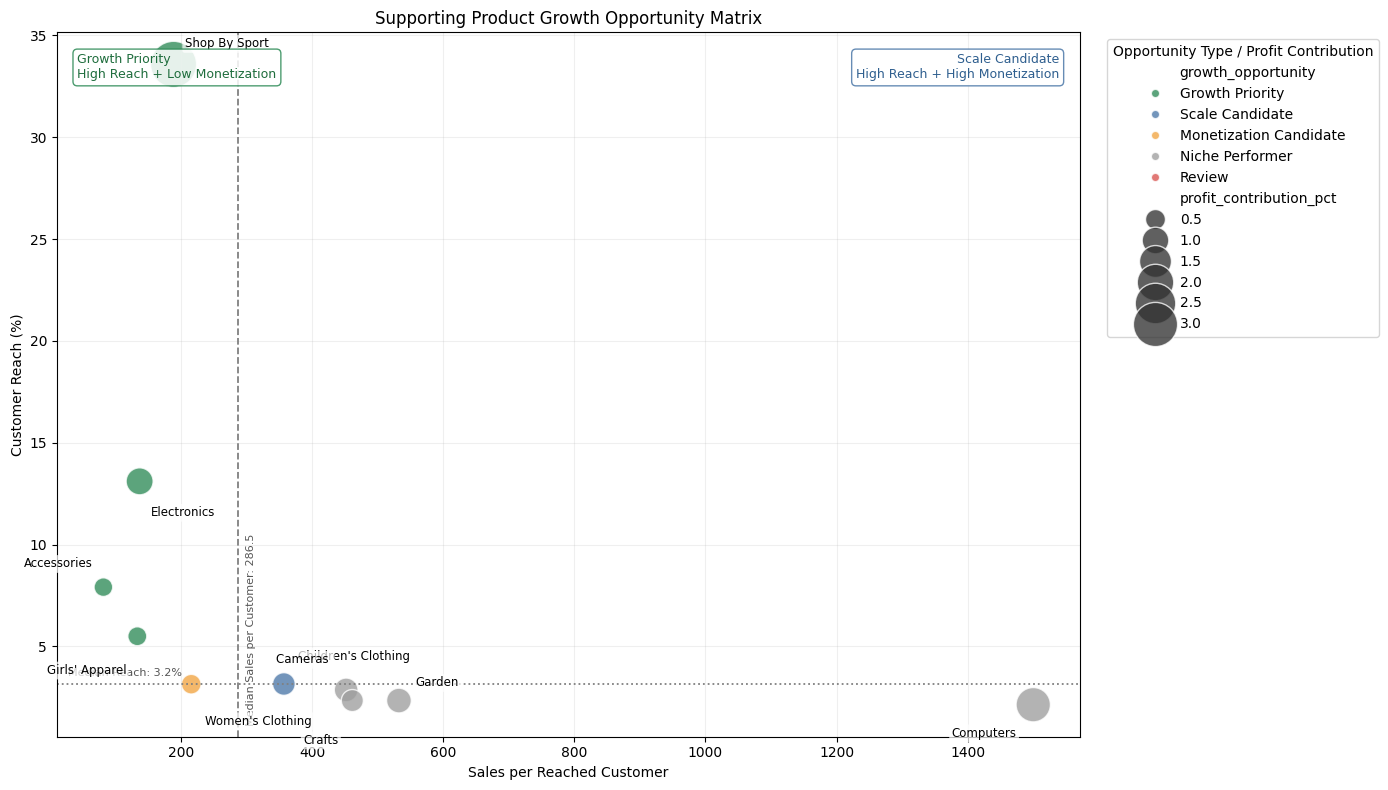

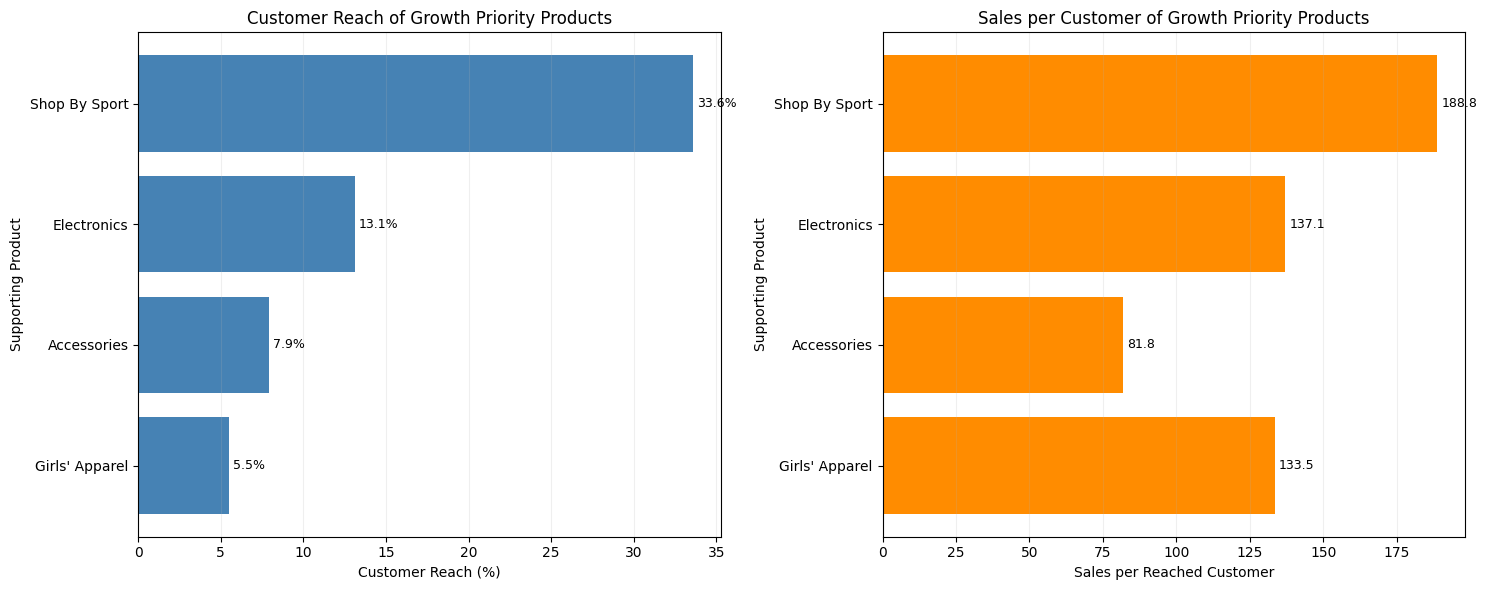


Supporting Product Opportunity Validation
All Supporting Categories Reconciled: True
Duplicate Output Categories: 0
Total Sales Reconciles: True
Total Profit Reconciles: True
Sales Contribution Reconciles: True
Profit Contribution Reconciles: True

Opportunity Group Summary


,growth_opportunity,category_count,total_sales,total_profit,avg_customer_reach_pct,avg_sales_per_customer
0,Growth Priority,4,"1,965,934","204,637",15.03%,135.31
2,Niche Performer,4,"1,411,733","158,921",2.42%,736.53
1,Monetization Candidate,1,"140,283","19,103",3.15%,215.82
3,Scale Candidate,1,"232,829","27,178",3.16%,357.10



Supporting Product Growth Opportunity Summary
Supporting Product Sales Contribution: 10.20%
Supporting Product Profit Contribution: 10.33%
Growth Priority Category Count: 4
Growth Priority Categories: Shop By Sport, Electronics, Accessories, Girls' Apparel
Highest-Reach Growth Candidate: Shop By Sport
Customer Reach: 33.58%
Sales per Reached Customer: 188.83
Profit Margin: 9.91%
Suggested Action: Improve Margin before Scaling


In [85]:
# ============================================================
# Step 9.2.1 Validate and Prepare Supporting Product Data
# ============================================================

# Confirm that the required source dataframes exist.
if "product_value_df" not in globals():
    raise NameError(
        "product_value_df is not defined. "
        "Please run Step 8.2 first."
    )

if "product_tier_profile_df" not in globals():
    raise NameError(
        "product_tier_profile_df is not defined. "
        "Please run Step 8.3 first."
    )

# Define required category-level columns.
required_product_cols = [
    "Category Name",
    "product_value_tier",
    "total_sales",
    "total_profit",
    "sales_contribution_pct",
    "profit_contribution_pct",
    "profit_margin"
]

missing_product_cols = [
    col
    for col in required_product_cols
    if col not in product_value_df.columns
]

if missing_product_cols:
    raise KeyError(
        "Missing required columns in product_value_df: "
        f"{missing_product_cols}"
    )

# Define required transaction-level columns.
required_transaction_cols = [
    "Category Name",
    "Customer Id",
    "Order Id",
    "Order Item Id",
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order",
    "product_value_tier"
]

missing_transaction_cols = [
    col
    for col in required_transaction_cols
    if col not in product_tier_profile_df.columns
]

if missing_transaction_cols:
    raise KeyError(
        "Missing required columns in product_tier_profile_df: "
        f"{missing_transaction_cols}"
    )

# Extract Supporting Product category-level records.
supporting_product_df = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .eq("Supporting Products"),
        required_product_cols
    ]
    .copy()
)

# Confirm each Supporting Product appears once.
duplicate_category_count = (
    supporting_product_df["Category Name"]
    .duplicated()
    .sum()
)

if duplicate_category_count > 0:
    raise ValueError(
        f"{duplicate_category_count} duplicate Supporting Product "
        "categories were found."
    )

# Extract Supporting Product transaction records.
supporting_transaction_df = (
    product_tier_profile_df
    .loc[
        product_tier_profile_df["product_value_tier"]
        .astype(str)
        .eq("Supporting Products"),
        required_transaction_cols
    ]
    .copy()
)

# Convert analytical fields to numeric.
numeric_transaction_cols = [
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order"
]

for col in numeric_transaction_cols:
    supporting_transaction_df[col] = pd.to_numeric(
        supporting_transaction_df[col],
        errors="coerce"
    )

# Remove records without essential analytical values.
supporting_transaction_df = (
    supporting_transaction_df
    .dropna(
        subset=[
            "Category Name",
            "Customer Id",
            "Order Id",
            "Order Item Id",
            "Order Item Quantity",
            "Sales",
            "Order Profit Per Order"
        ]
    )
    .loc[
        lambda df: df["Order Item Quantity"] > 0
    ]
    .copy()
)

if supporting_product_df.empty:
    raise ValueError(
        "No Supporting Product categories were found."
    )

if supporting_transaction_df.empty:
    raise ValueError(
        "No valid Supporting Product transactions were found."
    )

print("=" * 75)
print("Supporting Product Opportunity Data Validation")
print("=" * 75)

print(
    "Supporting Product Categories:",
    f"{supporting_product_df['Category Name'].nunique():,}"
)

print(
    "Supporting Product Transaction Rows:",
    f"{len(supporting_transaction_df):,}"
)

print(
    "Supporting Product Customers:",
    f"{supporting_transaction_df['Customer Id'].nunique():,}"
)

print(
    "Supporting Product Orders:",
    f"{supporting_transaction_df['Order Id'].nunique():,}"
)

print(
    "Duplicate Supporting Categories:",
    f"{duplicate_category_count:,}"
)


# ============================================================
# Step 9.2.2 Measure Customer Reach and Sales Efficiency
# ============================================================

# Calculate customer and transaction activity by category.
supporting_activity_df = (
    supporting_transaction_df
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        customer_count=("Customer Id", "nunique"),
        order_count=("Order Id", "nunique"),
        order_item_count=("Order Item Id", "nunique"),
        total_quantity=("Order Item Quantity", "sum"),
        transaction_sales=("Sales", "sum"),
        transaction_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

# Calculate total unique customers across the full portfolio.
total_portfolio_customers = (
    product_tier_profile_df["Customer Id"]
    .nunique()
)

# Customer Reach:
# Percentage of all portfolio customers purchasing the category.
supporting_activity_df["customer_reach_pct"] = np.where(
    total_portfolio_customers != 0,
    (
        supporting_activity_df["customer_count"]
        / total_portfolio_customers
        * 100
    ),
    np.nan
)

# Sales per Customer:
# Average category revenue generated per reached customer.
supporting_activity_df["sales_per_customer"] = np.where(
    supporting_activity_df["customer_count"].ne(0),
    (
        supporting_activity_df["transaction_sales"]
        / supporting_activity_df["customer_count"]
    ),
    np.nan
)

# Profit per Customer:
# Average category profit generated per reached customer.
supporting_activity_df["profit_per_customer"] = np.where(
    supporting_activity_df["customer_count"].ne(0),
    (
        supporting_activity_df["transaction_profit"]
        / supporting_activity_df["customer_count"]
    ),
    np.nan
)

# Orders per Customer:
# Average category purchase frequency among reached customers.
supporting_activity_df["orders_per_customer"] = np.where(
    supporting_activity_df["customer_count"].ne(0),
    (
        supporting_activity_df["order_count"]
        / supporting_activity_df["customer_count"]
    ),
    np.nan
)

# Average Order Value:
# Average category sales generated per category-related order.
supporting_activity_df["average_order_value"] = np.where(
    supporting_activity_df["order_count"].ne(0),
    (
        supporting_activity_df["transaction_sales"]
        / supporting_activity_df["order_count"]
    ),
    np.nan
)

# Average Quantity per Order:
# Average number of category units purchased per order.
supporting_activity_df["average_quantity_per_order"] = np.where(
    supporting_activity_df["order_count"].ne(0),
    (
        supporting_activity_df["total_quantity"]
        / supporting_activity_df["order_count"]
    ),
    np.nan
)

# Weighted Profit Margin:
# Total category profit divided by total category sales.
supporting_activity_df["calculated_profit_margin"] = np.where(
    supporting_activity_df["transaction_sales"].ne(0),
    (
        supporting_activity_df["transaction_profit"]
        / supporting_activity_df["transaction_sales"]
        * 100
    ),
    np.nan
)

print("\n" + "=" * 75)
print("Supporting Product Customer Reach and Sales Efficiency")
print("=" * 75)

display(
    supporting_activity_df
    .sort_values(
        "transaction_sales",
        ascending=False
    )
    .style.format({
        "customer_count": "{:,.0f}",
        "order_count": "{:,.0f}",
        "order_item_count": "{:,.0f}",
        "total_quantity": "{:,.0f}",
        "transaction_sales": "{:,.0f}",
        "transaction_profit": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "sales_per_customer": "{:,.2f}",
        "profit_per_customer": "{:,.2f}",
        "orders_per_customer": "{:.2f}",
        "average_order_value": "{:,.2f}",
        "average_quantity_per_order": "{:.2f}",
        "calculated_profit_margin": "{:.2f}%"
    })
)


# ============================================================
# Step 9.2.3 Compare Customer Reach with Sales per Customer
# ============================================================

# Merge Step 8.2 contribution data with the calculated
# customer and transaction activity data.
supporting_opportunity_df = (
    supporting_product_df[
        [
            "Category Name",
            "total_sales",
            "total_profit",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .merge(
        supporting_activity_df,
        on="Category Name",
        how="inner",
        validate="one_to_one"
    )
)

# Check that transaction totals reconcile with Step 8.2.
supporting_opportunity_df["sales_difference"] = (
    supporting_opportunity_df["transaction_sales"]
    - supporting_opportunity_df["total_sales"]
)

supporting_opportunity_df["profit_difference"] = (
    supporting_opportunity_df["transaction_profit"]
    - supporting_opportunity_df["total_profit"]
)

# Calculate transparent reference values within
# the Supporting Product tier.
reach_reference = (
    supporting_opportunity_df["customer_reach_pct"]
    .median()
)

sales_per_customer_reference = (
    supporting_opportunity_df["sales_per_customer"]
    .median()
)

profit_margin_reference = (
    supporting_opportunity_df["profit_margin"]
    .median()
)

profit_contribution_reference = (
    supporting_opportunity_df["profit_contribution_pct"]
    .median()
)

print("\n" + "=" * 75)
print("Supporting Product Opportunity Reference Values")
print("=" * 75)

print(
    "Median Customer Reach:",
    f"{reach_reference:.2f}%"
)

print(
    "Median Sales per Customer:",
    f"{sales_per_customer_reference:,.2f}"
)

print(
    "Median Profit Margin:",
    f"{profit_margin_reference:.2f}%"
)

display(
    supporting_opportunity_df[
        [
            "Category Name",
            "customer_count",
            "customer_reach_pct",
            "order_count",
            "orders_per_customer",
            "sales_per_customer",
            "profit_per_customer",
            "average_order_value",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .sort_values(
        [
            "customer_reach_pct",
            "sales_per_customer"
        ],
        ascending=[
            False,
            True
        ]
    )
    .style.format({
        "customer_count": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "order_count": "{:,.0f}",
        "orders_per_customer": "{:.2f}",
        "sales_per_customer": "{:,.2f}",
        "profit_per_customer": "{:,.2f}",
        "average_order_value": "{:,.2f}",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)


# ============================================================
# Step 9.2.4 Identify High-Reach, Low-Monetization Candidates
# ============================================================
# Relative opportunity classifications:
#
# Growth Priority:
# Customer reach >= Supporting Product median
# Sales per customer < Supporting Product median
#
# Scale Candidate:
# Customer reach >= median
# Sales per customer >= median
#
# Monetization Candidate:
# Customer reach < median
# Sales per customer < median
#
# Niche Performer:
# Customer reach < median
# Sales per customer >= median
#
# These classifications are descriptive, not causal.
# ============================================================

supporting_opportunity_df["growth_opportunity"] = np.select(
    [
        (
            supporting_opportunity_df["customer_reach_pct"]
            >= reach_reference
        )
        &
        (
            supporting_opportunity_df["sales_per_customer"]
            < sales_per_customer_reference
        ),
        (
            supporting_opportunity_df["customer_reach_pct"]
            >= reach_reference
        )
        &
        (
            supporting_opportunity_df["sales_per_customer"]
            >= sales_per_customer_reference
        ),
        (
            supporting_opportunity_df["customer_reach_pct"]
            < reach_reference
        )
        &
        (
            supporting_opportunity_df["sales_per_customer"]
            < sales_per_customer_reference
        ),
        (
            supporting_opportunity_df["customer_reach_pct"]
            < reach_reference
        )
        &
        (
            supporting_opportunity_df["sales_per_customer"]
            >= sales_per_customer_reference
        )
    ],
    [
        "Growth Priority",
        "Scale Candidate",
        "Monetization Candidate",
        "Niche Performer"
    ],
    default="Review"
)

# Define a transparent display order.
opportunity_order = {
    "Growth Priority": 1,
    "Scale Candidate": 2,
    "Monetization Candidate": 3,
    "Niche Performer": 4,
    "Review": 5
}

supporting_opportunity_df["opportunity_order"] = (
    supporting_opportunity_df["growth_opportunity"]
    .map(opportunity_order)
)

# Sort without creating an arbitrary opportunity score.
supporting_opportunity_df = (
    supporting_opportunity_df
    .sort_values(
        [
            "opportunity_order",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_contribution_pct"
        ],
        ascending=[
            True,
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

supporting_opportunity_df["priority_rank"] = np.arange(
    1,
    len(supporting_opportunity_df) + 1
)

print("\n" + "=" * 75)
print("Supporting Product Growth Opportunity Classification")
print("=" * 75)

display(
    supporting_opportunity_df[
        [
            "priority_rank",
            "Category Name",
            "growth_opportunity",
            "customer_reach_pct",
            "sales_per_customer",
            "orders_per_customer",
            "average_order_value",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .style.format({
        "priority_rank": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "sales_per_customer": "{:,.2f}",
        "orders_per_customer": "{:.2f}",
        "average_order_value": "{:,.2f}",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)


# ============================================================
# Step 9.2.5 Evaluate Profitability and Business Contribution
# ============================================================
# Customer reach alone is not sufficient for investment.
#
# This section checks whether each candidate:
# 1. Maintains an above-median Supporting Product margin
# 2. Generates an above-median profit contribution
#
# The output helps determine whether growth should be pursued
# immediately or only after improving category economics.
# ============================================================

supporting_opportunity_df["profitability_profile"] = np.select(
    [
        (
            supporting_opportunity_df["profit_margin"]
            >= profit_margin_reference
        )
        &
        (
            supporting_opportunity_df["profit_contribution_pct"]
            >= profit_contribution_reference
        ),
        (
            supporting_opportunity_df["profit_margin"]
            >= profit_margin_reference
        )
        &
        (
            supporting_opportunity_df["profit_contribution_pct"]
            < profit_contribution_reference
        ),
        (
            supporting_opportunity_df["profit_margin"]
            < profit_margin_reference
        )
    ],
    [
        "Strong Profit Profile",
        "Healthy Margin, Limited Scale",
        "Margin Review"
    ],
    default="Review"
)

# Translate opportunity and profitability into a
# practical investigation direction.
supporting_opportunity_df["suggested_action"] = np.select(
    [
        (
            supporting_opportunity_df["growth_opportunity"]
            == "Growth Priority"
        )
        &
        (
            supporting_opportunity_df["profitability_profile"]
            != "Margin Review"
        ),
        (
            supporting_opportunity_df["growth_opportunity"]
            == "Growth Priority"
        )
        &
        (
            supporting_opportunity_df["profitability_profile"]
            == "Margin Review"
        ),
        (
            supporting_opportunity_df["growth_opportunity"]
            == "Scale Candidate"
        ),
        (
            supporting_opportunity_df["growth_opportunity"]
            == "Monetization Candidate"
        ),
        (
            supporting_opportunity_df["growth_opportunity"]
            == "Niche Performer"
        )
    ],
    [
        "Increase Customer Spending",
        "Improve Margin before Scaling",
        "Strengthen Purchase Frequency",
        "Improve Reach and Monetization",
        "Pursue Selective Expansion"
    ],
    default="Monitor"
)

print("\n" + "=" * 75)
print("Supporting Product Profitability and Contribution Review")
print("=" * 75)

display(
    supporting_opportunity_df[
        [
            "priority_rank",
            "Category Name",
            "growth_opportunity",
            "profitability_profile",
            "suggested_action",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_per_customer",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .style.format({
        "priority_rank": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "sales_per_customer": "{:,.2f}",
        "profit_per_customer": "{:,.2f}",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)


# ============================================================
# Step 9.2.6 Visualize Supporting Product Opportunities
# ============================================================
# Opportunity Matrix:
#
# X-axis:
# Sales per reached customer
#
# Y-axis:
# Customer reach
#
# Bubble size:
# Profit contribution
#
# Upper-left:
# High reach but below-median sales per customer
# -> Growth Priority
#
# Upper-right:
# High reach and high sales per customer
# -> Scale Candidate
# ============================================================

opportunity_palette = {
    "Growth Priority": "#2E8B57",
    "Scale Candidate": "#4C78A8",
    "Monetization Candidate": "#F2A541",
    "Niche Performer": "#9E9E9E",
    "Review": "#D9534F"
}

fig, ax = plt.subplots(
    figsize=(14, 8)
)

sns.scatterplot(
    data=supporting_opportunity_df,
    x="sales_per_customer",
    y="customer_reach_pct",
    hue="growth_opportunity",
    hue_order=[
        "Growth Priority",
        "Scale Candidate",
        "Monetization Candidate",
        "Niche Performer",
        "Review"
    ],
    palette=opportunity_palette,
    size="profit_contribution_pct",
    sizes=(180, 1100),
    alpha=0.78,
    edgecolor="white",
    linewidth=1,
    ax=ax
)

# Add median reference lines.
ax.axvline(
    x=sales_per_customer_reference,
    color="gray",
    linestyle="--",
    linewidth=1.3
)

ax.axhline(
    y=reach_reference,
    color="gray",
    linestyle=":",
    linewidth=1.3
)

# Add reference-line labels.
ax.annotate(
    (
        "Median Sales per Customer: "
        f"{sales_per_customer_reference:,.1f}"
    ),
    xy=(
        sales_per_customer_reference,
        ax.get_ylim()[0]
    ),
    xytext=(6, 8),
    textcoords="offset points",
    rotation=90,
    va="bottom",
    fontsize=8,
    color="#555555"
)

ax.annotate(
    f"Median Reach: {reach_reference:.1f}%",
    xy=(
        ax.get_xlim()[0],
        reach_reference
    ),
    xytext=(8, 6),
    textcoords="offset points",
    fontsize=8,
    color="#555555"
)

# Add category labels with alternating offsets.
label_offsets = [
    (8, 10),
    (8, -18),
    (-8, 12),
    (-8, -20),
    (10, 15),
    (10, -22),
    (-10, 17),
    (-10, -24),
    (12, 8),
    (-12, -16)
]

for index, (_, row) in enumerate(
    supporting_opportunity_df.iterrows()
):
    x_offset, y_offset = label_offsets[
        index % len(label_offsets)
    ]

    ax.annotate(
        row["Category Name"],
        xy=(
            row["sales_per_customer"],
            row["customer_reach_pct"]
        ),
        xytext=(
            x_offset,
            y_offset
        ),
        textcoords="offset points",
        ha="left" if x_offset >= 0 else "right",
        va="bottom" if y_offset >= 0 else "top",
        fontsize=8.5,
        bbox={
            "boxstyle": "round,pad=0.2",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

# Add quadrant descriptions.
ax.text(
    0.02,
    0.97,
    "Growth Priority\nHigh Reach + Low Monetization",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="#1F6D3D",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#2E8B57",
        "alpha": 0.85
    }
)

ax.text(
    0.98,
    0.97,
    "Scale Candidate\nHigh Reach + High Monetization",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color="#2F5F8F",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#4C78A8",
        "alpha": 0.85
    }
)

ax.set_title(
    "Supporting Product Growth Opportunity Matrix"
)

ax.set_xlabel(
    "Sales per Reached Customer"
)

ax.set_ylabel(
    "Customer Reach (%)"
)

ax.grid(
    alpha=0.20
)

ax.legend(
    title="Opportunity Type / Profit Contribution",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Compare Growth Priority candidates using actual metrics
# ------------------------------------------------------------

growth_priority_df = (
    supporting_opportunity_df
    .loc[
        supporting_opportunity_df["growth_opportunity"]
        .eq("Growth Priority")
    ]
    .sort_values(
        "customer_reach_pct",
        ascending=True
    )
    .copy()
)

if not growth_priority_df.empty:

    positions = np.arange(
        len(growth_priority_df)
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, 6)
    )

    # Customer Reach
    reach_bars = axes[0].barh(
        positions,
        growth_priority_df["customer_reach_pct"],
        color="steelblue"
    )

    axes[0].set_yticks(positions)

    axes[0].set_yticklabels(
        growth_priority_df["Category Name"]
    )

    axes[0].set_title(
        "Customer Reach of Growth Priority Products"
    )

    axes[0].set_xlabel(
        "Customer Reach (%)"
    )

    axes[0].set_ylabel(
        "Supporting Product"
    )

    axes[0].bar_label(
        reach_bars,
        labels=[
            f"{value:.1f}%"
            for value in growth_priority_df[
                "customer_reach_pct"
            ]
        ],
        padding=3,
        fontsize=9
    )

    axes[0].grid(
        axis="x",
        alpha=0.20
    )

    # Sales per Customer
    monetization_bars = axes[1].barh(
        positions,
        growth_priority_df["sales_per_customer"],
        color="darkorange"
    )

    axes[1].set_yticks(positions)

    axes[1].set_yticklabels(
        growth_priority_df["Category Name"]
    )

    axes[1].set_title(
        "Sales per Customer of Growth Priority Products"
    )

    axes[1].set_xlabel(
        "Sales per Reached Customer"
    )

    axes[1].set_ylabel(
        "Supporting Product"
    )

    axes[1].bar_label(
        monetization_bars,
        labels=[
            f"{value:,.1f}"
            for value in growth_priority_df[
                "sales_per_customer"
            ]
        ],
        padding=3,
        fontsize=9
    )

    axes[1].grid(
        axis="x",
        alpha=0.20
    )

    plt.tight_layout()
    plt.show()

else:
    print(
        "\nNo Supporting Products met the relative "
        "Growth Priority criteria."
    )


# ============================================================
# Step 9.2.7 Validate and Summarize Growth Opportunities
# ============================================================

# Confirm all Supporting Products are included once.
category_count_check = (
    supporting_opportunity_df["Category Name"].nunique()
    == supporting_product_df["Category Name"].nunique()
)

duplicate_output_count = (
    supporting_opportunity_df["Category Name"]
    .duplicated()
    .sum()
)

# Reconcile transaction sales with Step 8.2 category sales.
sales_total_check = np.isclose(
    supporting_opportunity_df["transaction_sales"].sum(),
    supporting_product_df["total_sales"].sum(),
    rtol=1e-6,
    atol=0.01
)

# Reconcile transaction profit with Step 8.2 category profit.
profit_total_check = np.isclose(
    supporting_opportunity_df["transaction_profit"].sum(),
    supporting_product_df["total_profit"].sum(),
    rtol=1e-6,
    atol=0.01
)

# Reconcile sales and profit contribution percentages.
sales_contribution_check = np.isclose(
    supporting_opportunity_df[
        "sales_contribution_pct"
    ].sum(),
    supporting_product_df[
        "sales_contribution_pct"
    ].sum(),
    atol=0.01
)

profit_contribution_check = np.isclose(
    supporting_opportunity_df[
        "profit_contribution_pct"
    ].sum(),
    supporting_product_df[
        "profit_contribution_pct"
    ].sum(),
    atol=0.01
)

# Summarize each opportunity classification.
opportunity_group_summary = (
    supporting_opportunity_df
    .groupby(
        "growth_opportunity",
        observed=True
    )
    .agg(
        category_count=("Category Name", "nunique"),
        total_sales=("transaction_sales", "sum"),
        total_profit=("transaction_profit", "sum"),
        avg_customer_reach_pct=(
            "customer_reach_pct",
            "mean"
        ),
        avg_sales_per_customer=(
            "sales_per_customer",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "category_count",
        ascending=False
    )
)

print("\n" + "=" * 75)
print("Supporting Product Opportunity Validation")
print("=" * 75)

print(
    "All Supporting Categories Reconciled:",
    category_count_check
)

print(
    "Duplicate Output Categories:",
    duplicate_output_count
)

print(
    "Total Sales Reconciles:",
    sales_total_check
)

print(
    "Total Profit Reconciles:",
    profit_total_check
)

print(
    "Sales Contribution Reconciles:",
    sales_contribution_check
)

print(
    "Profit Contribution Reconciles:",
    profit_contribution_check
)

print("\nOpportunity Group Summary")

display(
    opportunity_group_summary.style.format({
        "category_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "avg_customer_reach_pct": "{:.2f}%",
        "avg_sales_per_customer": "{:,.2f}"
    })
)

print("\n" + "=" * 75)
print("Supporting Product Growth Opportunity Summary")
print("=" * 75)

supporting_sales_contribution = (
    supporting_opportunity_df[
        "sales_contribution_pct"
    ].sum()
)

supporting_profit_contribution = (
    supporting_opportunity_df[
        "profit_contribution_pct"
    ].sum()
)

priority_candidates = (
    supporting_opportunity_df
    .loc[
        supporting_opportunity_df["growth_opportunity"]
        .eq("Growth Priority")
    ]
    .copy()
)

print(
    "Supporting Product Sales Contribution:",
    f"{supporting_sales_contribution:.2f}%"
)

print(
    "Supporting Product Profit Contribution:",
    f"{supporting_profit_contribution:.2f}%"
)

print(
    "Growth Priority Category Count:",
    f"{len(priority_candidates):,}"
)

if not priority_candidates.empty:

    priority_names = (
        priority_candidates["Category Name"]
        .astype(str)
        .tolist()
    )

    print(
        "Growth Priority Categories:",
        ", ".join(priority_names)
    )

    top_candidate = (
        priority_candidates
        .sort_values(
            [
                "customer_reach_pct",
                "sales_per_customer"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]
    )

    print(
        "Highest-Reach Growth Candidate:",
        top_candidate["Category Name"]
    )

    print(
        "Customer Reach:",
        f"{top_candidate['customer_reach_pct']:.2f}%"
    )

    print(
        "Sales per Reached Customer:",
        f"{top_candidate['sales_per_customer']:,.2f}"
    )

    print(
        "Profit Margin:",
        f"{top_candidate['profit_margin']:.2f}%"
    )

    print(
        "Suggested Action:",
        top_candidate["suggested_action"]
    )

else:
    print(
        "No categories met the relative Growth Priority criteria."
    )

### Key Observations

- Supporting Products contribute **10.2% of total sales** and **10.3% of total profit**, with sales and profit contributions remaining closely aligned.

- Four categories are identified as **Growth Priorities**: **Shop By Sport, Electronics, Accessories, and Girls' Apparel**. These categories have above-median customer reach but below-median sales per customer, indicating opportunities to increase customer spending.

- **Shop By Sport** has the strongest existing reach at **33.6%** and contributes **3.6% of total sales**. However, its **9.9% margin** is below the Supporting Product median

### Business Implications

- **Shop By Sport** should be treated as the highest-priority growth opportunity due to its exceptional customer reach (**33.6%**). However, its below-median margin (**9.9%**) suggests that profitability should be improved before significant investment or promotion.

- Electronics and Girls' Apparel have built sizable customer bases, reaching 13.1% and 5.5% of customers respectively, while generating below-median sales per customer. These categories may offer opportunities to increase customer spending and overall category contribution.

- Accessories combines relatively high customer reach (7.9%) with low sales per customer (81.8) and a healthy profit margin (12.5%). This suggests that the category already attracts a meaningful customer base but currently contributes limited revenue per customer, making it a strong candidate for revenue expansion initiatives.

- Categories such as **Computers**, **Garden**, and **Crafts** demonstrate strong spending per customer but limited customer reach. Growth efforts should focus on customer acquisition rather than increasing spending from existing buyers.

- Future investment priorities should focus on expanding the sales contribution of Supporting Products to reduce long-term dependence on Core Products, which currently account for approximately **85% of total sales and profit**.

## Step 9.3 Long-Tail Product Review

This step reviews Long-Tail Products to identify categories with selective value and categories requiring further evaluation.

The analysis will:

- Validate and prepare Long-Tail Product data
- Measure customer reach and business contribution
- Evaluate profitability and loss exposure
- Classify Long-Tail Products using transparent criteria
- Identify retention and review candidates
- Visualize Long-Tail Product positions
- Validate and summarize the review results

The objective is to support portfolio decisions without assuming that low sales contribution alone justifies product discontinuation.


Long-Tail Product Review Data Validation
Long-Tail Product Categories: 32
Long-Tail Transaction Rows: 13,883
Long-Tail Customers: 11,061
Long-Tail Orders: 13,245
Duplicate Long-Tail Categories: 0

Long-Tail Customer Reach and Business Contribution Summary


,Category Name,customer_reach_pct,sales_per_customer,profit_per_customer,sales_contribution_pct,profit_contribution_pct,profit_margin
2,Music,2.10%,260.65,33.26,0.31%,0.36%,12.76%
3,Consumer Electronics,2.09%,252.88,30.68,0.30%,0.33%,12.13%
1,Golf Gloves,4.97%,113.74,12.65,0.32%,0.33%,11.12%
7,Baseball & Softball,2.94%,154.70,20.99,0.26%,0.32%,13.57%
0,Sporting Goods,1.73%,327.75,35.07,0.32%,0.32%,10.70%
4,Golf Shoes,2.50%,208.89,24.00,0.29%,0.31%,11.49%
5,Health and Beauty,1.75%,293.04,26.23,0.29%,0.24%,8.95%
6,Kids' Golf Clubs,1.77%,270.68,24.78,0.27%,0.23%,9.16%
8,Boxing & MMA,2.00%,206.31,20.92,0.23%,0.22%,10.14%
10,Golf Balls,6.60%,56.52,6.12,0.21%,0.21%,10.82%



Long-Tail Review Reference Values
Median Customer Reach: 1.86%
Median Profit Contribution: 0.13%
Median Profit Margin: 11.09%
Median Loss-Making Order Rate: 17.92%

Long-Tail Product Review Group Summary


,review_group,category_count,total_sales,total_profit,avg_customer_reach_pct,avg_profit_contribution_pct,avg_profit_margin,avg_loss_making_order_rate
0,Retention Candidate,11,"956,494","108,736",3.18%,0.25%,11.24%,18.61%
1,Niche Value Product,5,"413,506","42,324",1.62%,0.21%,10.69%,19.01%
2,Reach Review,5,"128,497","11,587",2.61%,0.06%,9.71%,19.50%
3,Low-Priority Review,11,"318,197","27,171",0.86%,0.06%,9.98%,16.96%



Long-Tail Product Action Summary


,review_rank,Category Name,review_group,customer_reach_pct,profit_contribution_pct,profit_margin,loss_making_order_rate,suggested_review,review_note
0,1,Music,Retention Candidate,2.10%,0.36%,12.76%,18.43%,Maintain and Monitor,Review Loss Exposure
1,2,Consumer Electronics,Retention Candidate,2.09%,0.33%,12.13%,18.33%,Maintain and Monitor,Review Loss Exposure
2,3,Golf Gloves,Retention Candidate,4.97%,0.33%,11.12%,16.73%,Maintain and Monitor,No Additional Risk Flag
3,4,Baseball & Softball,Retention Candidate,2.94%,0.32%,13.57%,16.72%,Maintain and Monitor,No Additional Risk Flag
4,5,Golf Shoes,Retention Candidate,2.50%,0.31%,11.49%,21.22%,Maintain and Monitor,Review Loss Exposure
5,6,Boxing & MMA,Retention Candidate,2.00%,0.22%,10.14%,19.00%,Maintain and Monitor,Review Margin and Loss Exposure
6,7,Golf Balls,Retention Candidate,6.60%,0.21%,10.82%,17.87%,Maintain and Monitor,Review Profit Margin
7,8,Trade-In,Retention Candidate,4.44%,0.20%,11.52%,17.95%,Maintain and Monitor,Review Loss Exposure
8,9,DVDs,Retention Candidate,2.34%,0.17%,8.38%,21.12%,Maintain and Monitor,Review Margin and Loss Exposure
9,10,Hunting & Shooting,Retention Candidate,2.10%,0.15%,10.52%,19.50%,Maintain and Monitor,Review Margin and Loss Exposure


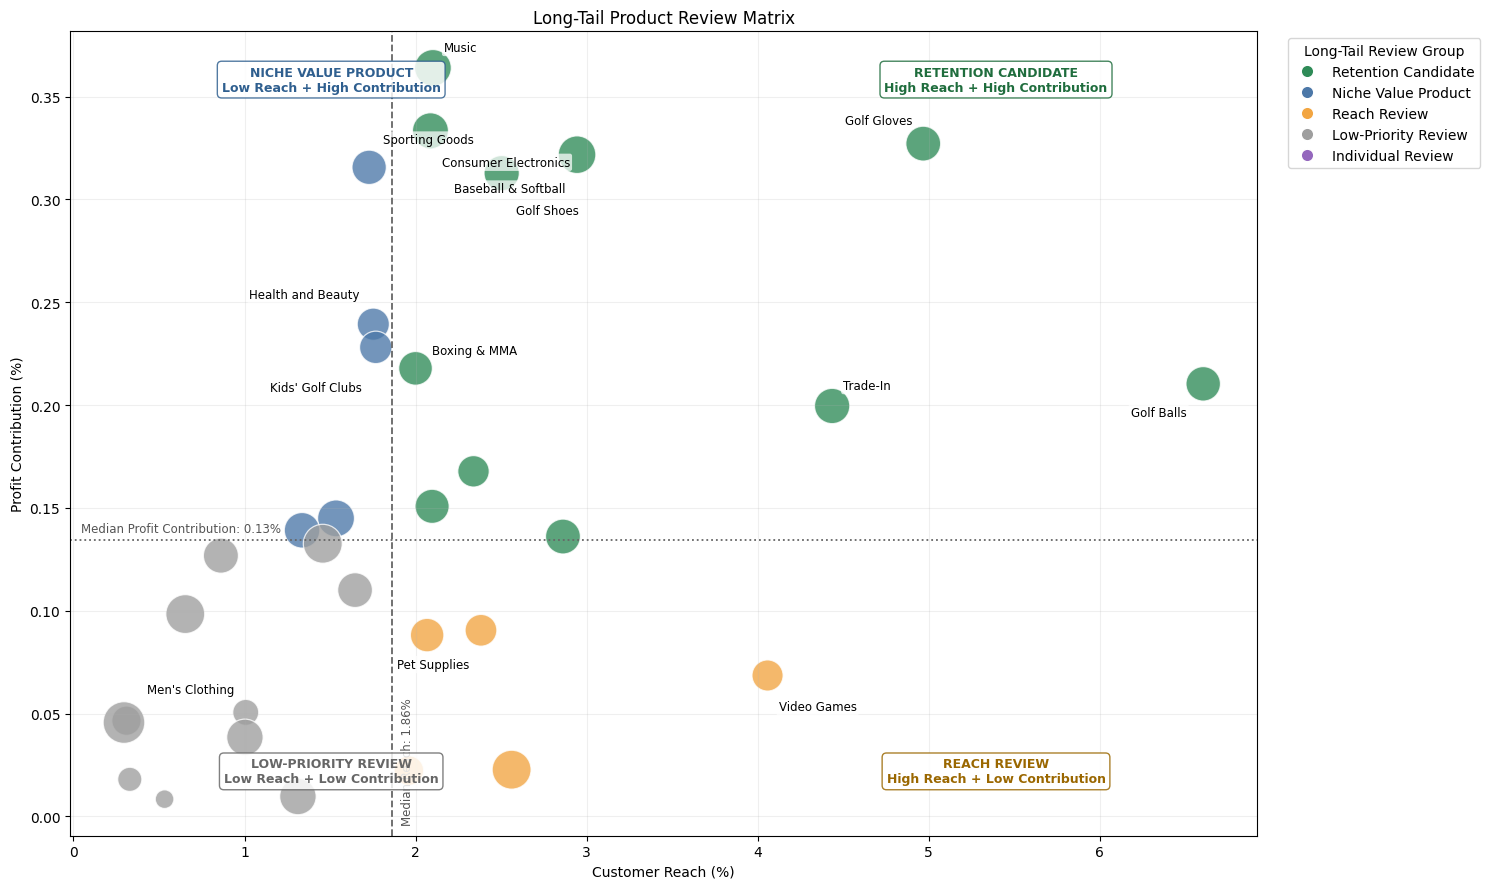

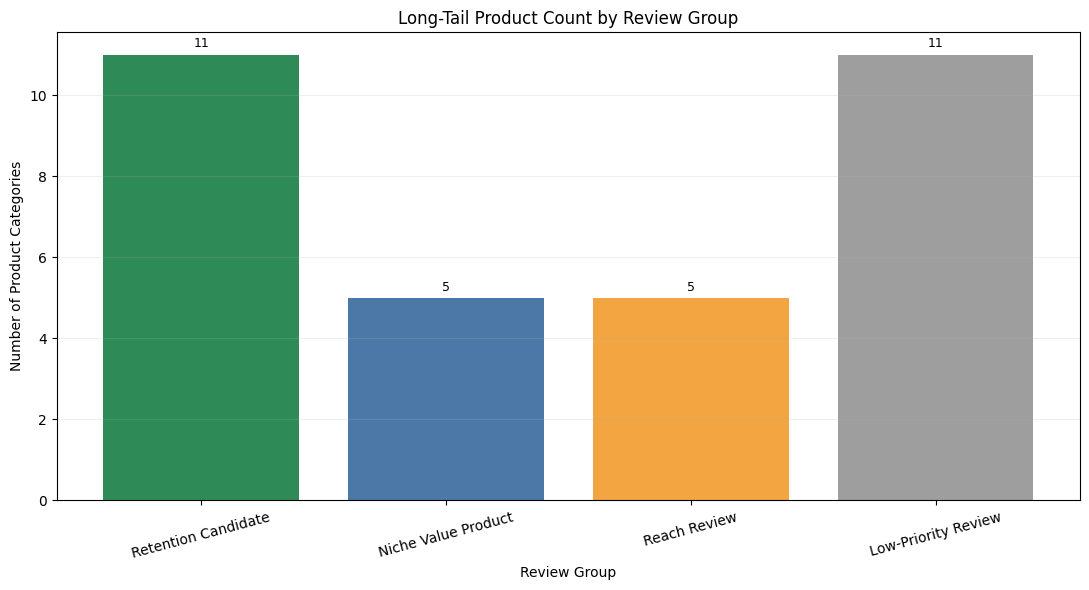


Long-Tail Product Review Validation
All Long-Tail Categories Reconciled: True
Duplicate Output Categories: 0
Total Sales Reconciles: True
Total Profit Reconciles: True
Sales Contribution Reconciles: True
Profit Contribution Reconciles: True

Long-Tail Product Review Summary
Long-Tail Category Count: 32
Long-Tail Sales Contribution: 4.94%
Long-Tail Profit Contribution: 4.79%
Retention or Niche Value Candidates: 16
Categories Requiring Review: 16
Categories with Below-Median Margin: 16
Categories with Above-Median Loss Exposure: 16

Review Group Counts
Retention Candidate: 11 categories
Niche Value Product: 5 categories
Reach Review: 5 categories
Low-Priority Review: 11 categories

Retention / Niche Value Candidates: Music, Consumer Electronics, Golf Gloves, Baseball & Softball, Golf Shoes, Boxing & MMA, Golf Balls, Trade-In, DVDs, Hunting & Shooting, Hockey, Sporting Goods, Health and Beauty, Kids' Golf Clubs, Tennis & Racquet, Men's Golf Clubs


In [86]:
# ============================================================
# Step 9.3.1 Validate and Prepare Long-Tail Product Data
# ============================================================

# Confirm that the required source dataframes exist.
if "product_value_df" not in globals():
    raise NameError(
        "product_value_df is not defined. "
        "Please run Step 8.2 first."
    )

if "product_tier_profile_df" not in globals():
    raise NameError(
        "product_tier_profile_df is not defined. "
        "Please run Step 8.3 first."
    )

# Define required category-level columns.
required_product_cols = [
    "Category Name",
    "product_value_tier",
    "total_sales",
    "total_profit",
    "sales_contribution_pct",
    "profit_contribution_pct",
    "profit_margin"
]

missing_product_cols = [
    col
    for col in required_product_cols
    if col not in product_value_df.columns
]

if missing_product_cols:
    raise KeyError(
        "Missing required columns in product_value_df: "
        f"{missing_product_cols}"
    )

# Define required transaction-level columns.
required_transaction_cols = [
    "Category Name",
    "Customer Id",
    "Order Id",
    "Order Item Id",
    "Sales",
    "Order Profit Per Order",
    "product_value_tier"
]

missing_transaction_cols = [
    col
    for col in required_transaction_cols
    if col not in product_tier_profile_df.columns
]

if missing_transaction_cols:
    raise KeyError(
        "Missing required columns in product_tier_profile_df: "
        f"{missing_transaction_cols}"
    )

# Extract category-level Long-Tail Product records.
long_tail_product_df = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .eq("Long-Tail Products"),
        required_product_cols
    ]
    .copy()
)

# Extract transaction-level Long-Tail Product records.
long_tail_transaction_df = (
    product_tier_profile_df
    .loc[
        product_tier_profile_df["product_value_tier"]
        .astype(str)
        .eq("Long-Tail Products"),
        required_transaction_cols
    ]
    .copy()
)

# Confirm that each category appears only once
# in the category-level dataset.
duplicate_category_count = (
    long_tail_product_df["Category Name"]
    .duplicated()
    .sum()
)

if duplicate_category_count > 0:
    raise ValueError(
        f"{duplicate_category_count} duplicate Long-Tail Product "
        "categories were found in product_value_df."
    )

# Convert analytical transaction fields to numeric.
for col in [
    "Sales",
    "Order Profit Per Order"
]:
    long_tail_transaction_df[col] = pd.to_numeric(
        long_tail_transaction_df[col],
        errors="coerce"
    )

# Convert analytical category fields to numeric.
for col in [
    "total_sales",
    "total_profit",
    "sales_contribution_pct",
    "profit_contribution_pct",
    "profit_margin"
]:
    long_tail_product_df[col] = pd.to_numeric(
        long_tail_product_df[col],
        errors="coerce"
    )

# Remove records without essential values.
long_tail_transaction_df = (
    long_tail_transaction_df
    .dropna(
        subset=[
            "Category Name",
            "Customer Id",
            "Order Id",
            "Order Item Id",
            "Sales",
            "Order Profit Per Order"
        ]
    )
    .copy()
)

long_tail_product_df = (
    long_tail_product_df
    .dropna(
        subset=[
            "Category Name",
            "total_sales",
            "total_profit",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    )
    .copy()
)

if long_tail_product_df.empty:
    raise ValueError(
        "No Long-Tail Product categories were found."
    )

if long_tail_transaction_df.empty:
    raise ValueError(
        "No valid Long-Tail Product transactions were found."
    )

print("=" * 75)
print("Long-Tail Product Review Data Validation")
print("=" * 75)

print(
    "Long-Tail Product Categories:",
    f"{long_tail_product_df['Category Name'].nunique():,}"
)

print(
    "Long-Tail Transaction Rows:",
    f"{len(long_tail_transaction_df):,}"
)

print(
    "Long-Tail Customers:",
    f"{long_tail_transaction_df['Customer Id'].nunique():,}"
)

print(
    "Long-Tail Orders:",
    f"{long_tail_transaction_df['Order Id'].nunique():,}"
)

print(
    "Duplicate Long-Tail Categories:",
    f"{duplicate_category_count:,}"
)


# ============================================================
# Step 9.3.2 Measure Customer Reach and Business Contribution
# ============================================================

# Aggregate customer and transaction activity by category.
long_tail_activity_df = (
    long_tail_transaction_df
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        customer_count=("Customer Id", "nunique"),
        order_count=("Order Id", "nunique"),
        order_item_count=("Order Item Id", "nunique"),
        transaction_sales=("Sales", "sum"),
        transaction_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

# Calculate the total unique customer population.
total_portfolio_customers = (
    product_tier_profile_df["Customer Id"]
    .nunique()
)

# Customer Reach:
# Percentage of all customers purchasing each category.
long_tail_activity_df["customer_reach_pct"] = np.where(
    total_portfolio_customers != 0,
    (
        long_tail_activity_df["customer_count"]
        / total_portfolio_customers
        * 100
    ),
    np.nan
)

# Sales per Customer:
# Average category sales generated by each reached customer.
long_tail_activity_df["sales_per_customer"] = np.where(
    long_tail_activity_df["customer_count"].ne(0),
    (
        long_tail_activity_df["transaction_sales"]
        / long_tail_activity_df["customer_count"]
    ),
    np.nan
)

# Profit per Customer:
# Average category profit generated by each reached customer.
long_tail_activity_df["profit_per_customer"] = np.where(
    long_tail_activity_df["customer_count"].ne(0),
    (
        long_tail_activity_df["transaction_profit"]
        / long_tail_activity_df["customer_count"]
    ),
    np.nan
)

# Orders per Customer:
# Average purchase frequency among reached customers.
long_tail_activity_df["orders_per_customer"] = np.where(
    long_tail_activity_df["customer_count"].ne(0),
    (
        long_tail_activity_df["order_count"]
        / long_tail_activity_df["customer_count"]
    ),
    np.nan
)

# Average Order Value:
# Average category sales generated by each associated order.
long_tail_activity_df["average_order_value"] = np.where(
    long_tail_activity_df["order_count"].ne(0),
    (
        long_tail_activity_df["transaction_sales"]
        / long_tail_activity_df["order_count"]
    ),
    np.nan
)

# Combine category contribution with customer activity.
long_tail_review_df = (
    long_tail_product_df[
        [
            "Category Name",
            "total_sales",
            "total_profit",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .merge(
        long_tail_activity_df,
        on="Category Name",
        how="inner",
        validate="one_to_one"
    )
)

# Check whether transaction totals agree with Step 8.2.
long_tail_review_df["sales_difference"] = (
    long_tail_review_df["transaction_sales"]
    - long_tail_review_df["total_sales"]
)

long_tail_review_df["profit_difference"] = (
    long_tail_review_df["transaction_profit"]
    - long_tail_review_df["total_profit"]
)

print("\n" + "=" * 75)
print("Long-Tail Customer Reach and Business Contribution Summary")
print("=" * 75)

# Display only a compact summary at this stage.
display(
    long_tail_review_df[
        [
            "Category Name",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_per_customer",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .sort_values(
        "profit_contribution_pct",
        ascending=False
    )
    .head(10)
    .style.format({
        "customer_reach_pct": "{:.2f}%",
        "sales_per_customer": "{:,.2f}",
        "profit_per_customer": "{:,.2f}",
        "sales_contribution_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%"
    })
)


# ============================================================
# Step 9.3.3 Evaluate Profitability and Loss Exposure
# ============================================================
# Build one row per category and order before calculating
# profitable and loss-making order rates.
# ============================================================

long_tail_order_df = (
    long_tail_transaction_df
    .groupby(
        [
            "Category Name",
            "Order Id"
        ],
        observed=True
    )
    .agg(
        order_sales=("Sales", "sum"),
        order_profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

# Classify each category-order record.
long_tail_order_df["profit_status"] = np.select(
    [
        long_tail_order_df["order_profit"] > 0,
        long_tail_order_df["order_profit"] == 0,
        long_tail_order_df["order_profit"] < 0
    ],
    [
        "Profitable",
        "Break-even",
        "Loss-making"
    ],
    default="Review"
)

# Calculate order-level profitability statistics.
long_tail_profitability_df = (
    long_tail_order_df
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        order_count_check=("Order Id", "nunique"),
        profitable_order_count=(
            "profit_status",
            lambda values: values.eq("Profitable").sum()
        ),
        loss_making_order_count=(
            "profit_status",
            lambda values: values.eq("Loss-making").sum()
        ),
        avg_profit_per_order=("order_profit", "mean"),
        median_profit_per_order=("order_profit", "median")
    )
    .reset_index()
)

# Calculate order outcome rates.
long_tail_profitability_df["profitable_order_rate"] = np.where(
    long_tail_profitability_df["order_count_check"].ne(0),
    (
        long_tail_profitability_df["profitable_order_count"]
        / long_tail_profitability_df["order_count_check"]
        * 100
    ),
    np.nan
)

long_tail_profitability_df["loss_making_order_rate"] = np.where(
    long_tail_profitability_df["order_count_check"].ne(0),
    (
        long_tail_profitability_df["loss_making_order_count"]
        / long_tail_profitability_df["order_count_check"]
        * 100
    ),
    np.nan
)

# Add profitability and loss exposure metrics.
long_tail_review_df = (
    long_tail_review_df
    .merge(
        long_tail_profitability_df,
        on="Category Name",
        how="left",
        validate="one_to_one"
    )
)

# Establish transparent relative reference values.
reach_reference = (
    long_tail_review_df["customer_reach_pct"]
    .median()
)

profit_contribution_reference = (
    long_tail_review_df["profit_contribution_pct"]
    .median()
)

profit_margin_reference = (
    long_tail_review_df["profit_margin"]
    .median()
)

loss_rate_reference = (
    long_tail_review_df["loss_making_order_rate"]
    .median()
)

print("\n" + "=" * 75)
print("Long-Tail Review Reference Values")
print("=" * 75)

print(
    "Median Customer Reach:",
    f"{reach_reference:.2f}%"
)

print(
    "Median Profit Contribution:",
    f"{profit_contribution_reference:.2f}%"
)

print(
    "Median Profit Margin:",
    f"{profit_margin_reference:.2f}%"
)

print(
    "Median Loss-Making Order Rate:",
    f"{loss_rate_reference:.2f}%"
)


# ============================================================
# Step 9.3.4 Classify Long-Tail Products Using Transparent Criteria
# ============================================================
# The primary classification uses:
#
# X dimension:
# Customer Reach
#
# Y dimension:
# Profit Contribution
#
# Retention Candidate:
# High reach + high profit contribution
#
# Niche Value Product:
# Low reach + high profit contribution
#
# Reach Review:
# High reach + low profit contribution
#
# Low-Priority Review:
# Low reach + low profit contribution
#
# These are relative classifications within Long-Tail Products.
# They are not automatic investment or removal decisions.
# ============================================================

long_tail_review_df["review_group"] = np.select(
    [
        (
            long_tail_review_df["customer_reach_pct"]
            >= reach_reference
        )
        &
        (
            long_tail_review_df["profit_contribution_pct"]
            >= profit_contribution_reference
        ),
        (
            long_tail_review_df["customer_reach_pct"]
            < reach_reference
        )
        &
        (
            long_tail_review_df["profit_contribution_pct"]
            >= profit_contribution_reference
        ),
        (
            long_tail_review_df["customer_reach_pct"]
            >= reach_reference
        )
        &
        (
            long_tail_review_df["profit_contribution_pct"]
            < profit_contribution_reference
        ),
        (
            long_tail_review_df["customer_reach_pct"]
            < reach_reference
        )
        &
        (
            long_tail_review_df["profit_contribution_pct"]
            < profit_contribution_reference
        )
    ],
    [
        "Retention Candidate",
        "Niche Value Product",
        "Reach Review",
        "Low-Priority Review"
    ],
    default="Individual Review"
)

# Add a separate profitability indicator.
long_tail_review_df["margin_flag"] = np.where(
    long_tail_review_df["profit_margin"]
    >= profit_margin_reference,
    "At-or-Above-Median Margin",
    "Below-Median Margin"
)

# Add a separate loss exposure indicator.
long_tail_review_df["loss_exposure_flag"] = np.where(
    long_tail_review_df["loss_making_order_rate"]
    > loss_rate_reference,
    "Above-Median Loss Exposure",
    "At-or-Below-Median Loss Exposure"
)

# Define a business-friendly display order.
review_group_order = {
    "Retention Candidate": 1,
    "Niche Value Product": 2,
    "Reach Review": 3,
    "Low-Priority Review": 4,
    "Individual Review": 5
}

long_tail_review_df["review_group_order"] = (
    long_tail_review_df["review_group"]
    .map(review_group_order)
)

# Sort by review group, then by profit contribution.
long_tail_review_df = (
    long_tail_review_df
    .sort_values(
        [
            "review_group_order",
            "profit_contribution_pct",
            "customer_reach_pct"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

long_tail_review_df["review_rank"] = np.arange(
    1,
    len(long_tail_review_df) + 1
)

print("\n" + "=" * 75)
print("Long-Tail Product Review Group Summary")
print("=" * 75)

review_group_summary = (
    long_tail_review_df
    .groupby(
        "review_group",
        observed=True
    )
    .agg(
        category_count=("Category Name", "nunique"),
        total_sales=("transaction_sales", "sum"),
        total_profit=("transaction_profit", "sum"),
        avg_customer_reach_pct=("customer_reach_pct", "mean"),
        avg_profit_contribution_pct=(
            "profit_contribution_pct",
            "mean"
        ),
        avg_profit_margin=("profit_margin", "mean"),
        avg_loss_making_order_rate=(
            "loss_making_order_rate",
            "mean"
        )
    )
    .reset_index()
)

review_group_summary["review_group_order"] = (
    review_group_summary["review_group"]
    .map(review_group_order)
)

review_group_summary = (
    review_group_summary
    .sort_values("review_group_order")
    .drop(columns="review_group_order")
    .reset_index(drop=True)
)

display(
    review_group_summary.style.format({
        "category_count": "{:,.0f}",
        "total_sales": "{:,.0f}",
        "total_profit": "{:,.0f}",
        "avg_customer_reach_pct": "{:.2f}%",
        "avg_profit_contribution_pct": "{:.2f}%",
        "avg_profit_margin": "{:.2f}%",
        "avg_loss_making_order_rate": "{:.2f}%"
    })
)


# ============================================================
# Step 9.3.5 Identify Retention and Review Candidates
# ============================================================
# Suggested actions remain investigative:
#
# Retention Candidate:
# Maintain availability and monitor performance
#
# Niche Value Product:
# Assess selective growth potential
#
# Reach Review:
# Review monetization and category economics
#
# Low-Priority Review:
# Assess strategic role and operating complexity
#
# Loss exposure and margin flags are retained separately.
# ============================================================

long_tail_review_df["suggested_review"] = (
    long_tail_review_df["review_group"]
    .map({
        "Retention Candidate":
            "Maintain and Monitor",
        "Niche Value Product":
            "Evaluate Selective Growth",
        "Reach Review":
            "Review Monetization and Economics",
        "Low-Priority Review":
            "Assess Strategic Role",
        "Individual Review":
            "Review Individually"
    })
)

# Add an additional review note based on margin and loss exposure.
long_tail_review_df["review_note"] = np.select(
    [
        (
            long_tail_review_df["margin_flag"]
            .eq("Below-Median Margin")
        )
        &
        (
            long_tail_review_df["loss_exposure_flag"]
            .eq("Above-Median Loss Exposure")
        ),
        (
            long_tail_review_df["margin_flag"]
            .eq("Below-Median Margin")
        ),
        (
            long_tail_review_df["loss_exposure_flag"]
            .eq("Above-Median Loss Exposure")
        )
    ],
    [
        "Review Margin and Loss Exposure",
        "Review Profit Margin",
        "Review Loss Exposure"
    ],
    default="No Additional Risk Flag"
)

# Create major candidate subsets.
retention_candidates = (
    long_tail_review_df
    .loc[
        long_tail_review_df["review_group"]
        .isin([
            "Retention Candidate",
            "Niche Value Product"
        ])
    ]
    .copy()
)

review_candidates = (
    long_tail_review_df
    .loc[
        long_tail_review_df["review_group"]
        .isin([
            "Reach Review",
            "Low-Priority Review",
            "Individual Review"
        ])
    ]
    .copy()
)

# Display one compact action table instead of multiple long tables.
compact_action_table = (
    long_tail_review_df[
        [
            "review_rank",
            "Category Name",
            "review_group",
            "customer_reach_pct",
            "profit_contribution_pct",
            "profit_margin",
            "loss_making_order_rate",
            "suggested_review",
            "review_note"
        ]
    ]
    .copy()
)

print("\n" + "=" * 75)
print("Long-Tail Product Action Summary")
print("=" * 75)

display(
    compact_action_table.style.format({
        "review_rank": "{:,.0f}",
        "customer_reach_pct": "{:.2f}%",
        "profit_contribution_pct": "{:.2f}%",
        "profit_margin": "{:.2f}%",
        "loss_making_order_rate": "{:.2f}%"
    })
)


# ============================================================
# Step 9.3.6 Visualize Long-Tail Product Positions
# ============================================================
# Long-Tail Product Review Matrix:
#
# X-axis:
# Customer Reach
#
# Y-axis:
# Profit Contribution
#
# Bubble size:
# Profit Margin
#
# Bubble color:
# Review Group
#
# The matrix focuses on the two main decision dimensions:
# customer relevance and business contribution.
# ============================================================

review_palette = {
    "Retention Candidate": "#2E8B57",
    "Niche Value Product": "#4C78A8",
    "Reach Review": "#F2A541",
    "Low-Priority Review": "#9E9E9E",
    "Individual Review": "#9467BD"
}

# Create a positive bubble-size field.
#
# Bubble size represents relative profit margin within
# Long-Tail Products. The actual margin remains available
# in the action table.
margin_min = (
    long_tail_review_df["profit_margin"]
    .min()
)

margin_max = (
    long_tail_review_df["profit_margin"]
    .max()
)

if (
    pd.notna(margin_min)
    and pd.notna(margin_max)
    and margin_max > margin_min
):
    long_tail_review_df["margin_bubble_size"] = (
        180
        +
        (
            (
                long_tail_review_df["profit_margin"]
                - margin_min
            )
            /
            (
                margin_max
                - margin_min
            )
            * 720
        )
    )
else:
    long_tail_review_df["margin_bubble_size"] = 400

fig, ax = plt.subplots(
    figsize=(15, 9)
)

sns.scatterplot(
    data=long_tail_review_df,
    x="customer_reach_pct",
    y="profit_contribution_pct",
    hue="review_group",
    hue_order=[
        "Retention Candidate",
        "Niche Value Product",
        "Reach Review",
        "Low-Priority Review",
        "Individual Review"
    ],
    palette=review_palette,
    size="margin_bubble_size",
    sizes=(180, 900),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.9,
    legend=False,
    ax=ax
)

# Add median reference lines.
ax.axvline(
    x=reach_reference,
    color="#666666",
    linestyle="--",
    linewidth=1.3
)

ax.axhline(
    y=profit_contribution_reference,
    color="#666666",
    linestyle=":",
    linewidth=1.3
)

# Add reference value labels.
ax.annotate(
    f"Median Reach: {reach_reference:.2f}%",
    xy=(
        reach_reference,
        ax.get_ylim()[0]
    ),
    xytext=(6, 8),
    textcoords="offset points",
    rotation=90,
    va="bottom",
    fontsize=8.5,
    color="#555555"
)

ax.annotate(
    (
        "Median Profit Contribution: "
        f"{profit_contribution_reference:.2f}%"
    ),
    xy=(
        ax.get_xlim()[0],
        profit_contribution_reference
    ),
    xytext=(8, 6),
    textcoords="offset points",
    fontsize=8.5,
    color="#555555"
)

# Label a focused set of products to reduce clutter.
#
# Label:
# 1. Top 10 categories by profit contribution
# 2. Top 5 categories by customer reach
# 3. Categories with the highest loss exposure
top_profit_labels = (
    long_tail_review_df
    .nlargest(
        min(10, len(long_tail_review_df)),
        "profit_contribution_pct"
    )
)

top_reach_labels = (
    long_tail_review_df
    .nlargest(
        min(5, len(long_tail_review_df)),
        "customer_reach_pct"
    )
)

top_loss_labels = (
    long_tail_review_df
    .nlargest(
        min(5, len(long_tail_review_df)),
        "loss_making_order_rate"
    )
)

label_df = (
    pd.concat(
        [
            top_profit_labels,
            top_reach_labels,
            top_loss_labels
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset=["Category Name"]
    )
)

label_offsets = [
    (8, 10),
    (8, -18),
    (-8, 12),
    (-8, -20),
    (10, 15),
    (10, -22),
    (-10, 17),
    (-10, -24),
    (12, 8),
    (-12, -16)
]

for index, (_, row) in enumerate(
    label_df.iterrows()
):
    x_offset, y_offset = label_offsets[
        index % len(label_offsets)
    ]

    ax.annotate(
        row["Category Name"],
        xy=(
            row["customer_reach_pct"],
            row["profit_contribution_pct"]
        ),
        xytext=(
            x_offset,
            y_offset
        ),
        textcoords="offset points",
        ha="left" if x_offset >= 0 else "right",
        va="bottom" if y_offset >= 0 else "top",
        fontsize=8.5,
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

# Add matrix interpretation labels.
matrix_labels = [
    (
        0.78,
        0.94,
        "RETENTION CANDIDATE\nHigh Reach + High Contribution",
        "#1F6D3D"
    ),
    (
        0.22,
        0.94,
        "NICHE VALUE PRODUCT\nLow Reach + High Contribution",
        "#2F5F8F"
    ),
    (
        0.78,
        0.08,
        "REACH REVIEW\nHigh Reach + Low Contribution",
        "#9A6700"
    ),
    (
        0.22,
        0.08,
        "LOW-PRIORITY REVIEW\nLow Reach + Low Contribution",
        "#666666"
    )
]

for x_pos, y_pos, label, color in matrix_labels:
    ax.text(
        x_pos,
        y_pos,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=color,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": color,
            "alpha": 0.83
        }
    )

# Create a clean review-group legend.
review_legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        label=group,
        markerfacecolor=color,
        markeredgecolor="white",
        markersize=9
    )
    for group, color in review_palette.items()
]

ax.legend(
    handles=review_legend_handles,
    title="Long-Tail Review Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_title(
    "Long-Tail Product Review Matrix"
)

ax.set_xlabel(
    "Customer Reach (%)"
)

ax.set_ylabel(
    "Profit Contribution (%)"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualize category count by review group
# ------------------------------------------------------------

review_count_df = (
    long_tail_review_df
    .groupby(
        "review_group",
        observed=True
    )
    .agg(
        category_count=("Category Name", "nunique")
    )
    .reset_index()
)

review_count_df["review_group_order"] = (
    review_count_df["review_group"]
    .map(review_group_order)
)

review_count_df = (
    review_count_df
    .sort_values("review_group_order")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

review_colors = [
    review_palette.get(group, "#777777")
    for group in review_count_df["review_group"]
]

review_bars = ax.bar(
    review_count_df["review_group"],
    review_count_df["category_count"],
    color=review_colors
)

ax.set_title(
    "Long-Tail Product Count by Review Group"
)

ax.set_xlabel(
    "Review Group"
)

ax.set_ylabel(
    "Number of Product Categories"
)

ax.tick_params(
    axis="x",
    rotation=15
)

ax.bar_label(
    review_bars,
    labels=[
        f"{value:,.0f}"
        for value in review_count_df["category_count"]
    ],
    padding=3,
    fontsize=9
)

ax.grid(
    axis="y",
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ============================================================
# Step 9.3.7 Validate and Summarize the Review Results
# ============================================================

# Confirm that every Long-Tail Product was included once.
category_count_check = (
    long_tail_review_df["Category Name"].nunique()
    == long_tail_product_df["Category Name"].nunique()
)

duplicate_output_count = (
    long_tail_review_df["Category Name"]
    .duplicated()
    .sum()
)

# Reconcile transactional sales with Step 8.2 sales.
sales_total_check = np.isclose(
    long_tail_review_df["transaction_sales"].sum(),
    long_tail_product_df["total_sales"].sum(),
    rtol=1e-6,
    atol=0.01
)

# Reconcile transactional profit with Step 8.2 profit.
profit_total_check = np.isclose(
    long_tail_review_df["transaction_profit"].sum(),
    long_tail_product_df["total_profit"].sum(),
    rtol=1e-6,
    atol=0.01
)

# Reconcile contribution percentages.
sales_contribution_check = np.isclose(
    long_tail_review_df[
        "sales_contribution_pct"
    ].sum(),
    long_tail_product_df[
        "sales_contribution_pct"
    ].sum(),
    atol=0.01
)

profit_contribution_check = np.isclose(
    long_tail_review_df[
        "profit_contribution_pct"
    ].sum(),
    long_tail_product_df[
        "profit_contribution_pct"
    ].sum(),
    atol=0.01
)

# Count categories with additional margin or loss flags.
below_median_margin_count = (
    long_tail_review_df["margin_flag"]
    .eq("Below-Median Margin")
    .sum()
)

above_median_loss_count = (
    long_tail_review_df["loss_exposure_flag"]
    .eq("Above-Median Loss Exposure")
    .sum()
)

# Calculate total Long-Tail contribution.
long_tail_sales_contribution = (
    long_tail_review_df[
        "sales_contribution_pct"
    ].sum()
)

long_tail_profit_contribution = (
    long_tail_review_df[
        "profit_contribution_pct"
    ].sum()
)

print("\n" + "=" * 75)
print("Long-Tail Product Review Validation")
print("=" * 75)

print(
    "All Long-Tail Categories Reconciled:",
    category_count_check
)

print(
    "Duplicate Output Categories:",
    duplicate_output_count
)

print(
    "Total Sales Reconciles:",
    sales_total_check
)

print(
    "Total Profit Reconciles:",
    profit_total_check
)

print(
    "Sales Contribution Reconciles:",
    sales_contribution_check
)

print(
    "Profit Contribution Reconciles:",
    profit_contribution_check
)

print("\n" + "=" * 75)
print("Long-Tail Product Review Summary")
print("=" * 75)

print(
    "Long-Tail Category Count:",
    f"{long_tail_review_df['Category Name'].nunique():,}"
)

print(
    "Long-Tail Sales Contribution:",
    f"{long_tail_sales_contribution:.2f}%"
)

print(
    "Long-Tail Profit Contribution:",
    f"{long_tail_profit_contribution:.2f}%"
)

print(
    "Retention or Niche Value Candidates:",
    f"{len(retention_candidates):,}"
)

print(
    "Categories Requiring Review:",
    f"{len(review_candidates):,}"
)

print(
    "Categories with Below-Median Margin:",
    f"{below_median_margin_count:,}"
)

print(
    "Categories with Above-Median Loss Exposure:",
    f"{above_median_loss_count:,}"
)

print("\nReview Group Counts")

for _, row in review_count_df.iterrows():
    print(
        f"{row['review_group']}: "
        f"{int(row['category_count'])} categories"
    )

if not retention_candidates.empty:
    print(
        "\nRetention / Niche Value Candidates:",
        ", ".join(
            retention_candidates["Category Name"]
            .astype(str)
            .tolist()
        )
    )

### Key Observations

- Long-Tail Products show mixed value despite their limited portfolio contribution. **11 categories are Retention Candidates**, generating **956K in sales** and **109K in profit**, with above-median customer reach and profit contribution.

- **Music, Consumer Electronics, Sporting Goods, Baseball & Softball, Golf Shoes, and Golf Gloves** are among the stronger Long-Tail categories. Music has the highest profit contribution (**0.36%**), while Golf Balls has the broadest customer reach (**6.6%**).

- Five Niche Value Products generate relatively high profit contribution despite limited customer reach, indicating value within a smaller customer base.

- Five Reach Review categories attract relatively more customers but contribute limited profit. This group also has the highest average loss-making order rate (**19.5%**) and a lower average margin (**9.7%**).

- The remaining **11 Low-Priority Review categories** have below-median customer reach and profit contribution. However, low contribution alone does not justify discontinuation.

### Business Implications

- Maintain and monitor Retention Candidates while evaluating selective growth potential for Niche Value Products.
- Review the monetization and profitability of Reach Review categories before further investment.
- Assess Low-Priority Review categories individually using strategic relevance, operating complexity, and cost data before making portfolio decisions.

## Step 9.4 Product Opportunity Matrix

This step identifies growth and review opportunities among Supporting and Long-Tail Products.

The analysis will:

- Prepare Supporting and Long-Tail opportunity metrics
- Measure customer reach and customer monetization
- Classify product opportunity groups
- Identify growth and niche-value opportunities
- Evaluate portfolio balance across opportunity groups
- Visualize the Product Opportunity Matrix
- Validate and summarize opportunity priorities

The objective is to prioritize categories for growth, selective expansion, or monitoring based on customer reach, monetization potential, and profitability.

,Category Name,product_value_tier,customer_reach_pct,sales_per_customer,profit_margin
0,Shop By Sport,Supporting Products,33.58%,188.83,9.91%
2,Electronics,Supporting Products,13.11%,137.06,11.02%
9,Accessories,Supporting Products,7.91%,81.81,12.45%
20,Golf Balls,Long-Tail Products,6.60%,56.52,10.82%
7,Girls' Apparel,Supporting Products,5.50%,133.54,11.40%
11,Golf Gloves,Long-Tail Products,4.97%,113.74,11.12%
21,Trade-In,Long-Tail Products,4.44%,75.02,11.52%
33,Video Games,Long-Tail Products,4.06%,39.75,8.16%
5,Children's Clothing,Supporting Products,3.16%,357.10,11.67%
8,Women's Clothing,Supporting Products,3.15%,215.82,13.62%


Median Customer Reach: 2.10%
Median Sales per Customer: 170.20
Median Profit Margin: 11.22%


,Category Name,opportunity_group,customer_reach_pct,sales_per_customer,profit_margin
0,Shop By Sport,Scale Opportunity,33.58%,188.83,9.91%
2,Electronics,Growth Opportunity,13.11%,137.06,11.02%
9,Accessories,Growth Opportunity,7.91%,81.81,12.45%
20,Golf Balls,Growth Opportunity,6.60%,56.52,10.82%
7,Girls' Apparel,Growth Opportunity,5.50%,133.54,11.40%
11,Golf Gloves,Growth Opportunity,4.97%,113.74,11.12%
21,Trade-In,Growth Opportunity,4.44%,75.02,11.52%
33,Video Games,Growth Opportunity,4.06%,39.75,8.16%
5,Children's Clothing,Scale Opportunity,3.16%,357.10,11.67%
8,Women's Clothing,Scale Opportunity,3.15%,215.82,13.62%



Growth Opportunity Categories


,Category Name,customer_reach_pct,sales_per_customer,profit_margin
2,Electronics,13.11%,137.06,11.02%
7,Girls' Apparel,5.50%,133.54,11.40%
9,Accessories,7.91%,81.81,12.45%
11,Golf Gloves,4.97%,113.74,11.12%
17,Baseball & Softball,2.94%,154.70,13.57%
19,DVDs,2.34%,164.38,8.38%
20,Golf Balls,6.60%,56.52,10.82%
21,Trade-In,4.44%,75.02,11.52%
24,Hockey,2.86%,81.83,11.16%
29,Pet Supplies,2.38%,84.40,8.64%



Niche Value Categories


,Category Name,customer_reach_pct,sales_per_customer,profit_margin
10,Sporting Goods,1.73%,327.75,10.70%
13,Consumer Electronics,2.09%,252.88,12.13%
15,Health and Beauty,1.75%,293.04,8.95%
16,Kids' Golf Clubs,1.77%,270.68,9.16%
18,Boxing & MMA,2.00%,206.31,10.14%
23,Strength Training,0.53%,499.05,0.61%
25,Men's Golf Clubs,1.34%,170.42,11.73%
27,Women's Golf Clubs,0.86%,250.26,11.29%
28,Men's Clothing,1.01%,210.85,4.57%
34,Basketball,0.31%,423.43,6.81%


,opportunity_group,category_count,total_sales,total_profit,category_share_pct
0,Growth Opportunity,12,"1,221,681","136,079",28.57%
1,Monitor,9,"249,715","29,449",21.43%
2,Niche Value,12,"780,590","72,270",28.57%
3,Scale Opportunity,9,"3,315,487","361,858",21.43%


Focused View Sales-per-Customer Limit: 497.17
High-Monetization Outliers: Computers, Garden, Strength Training


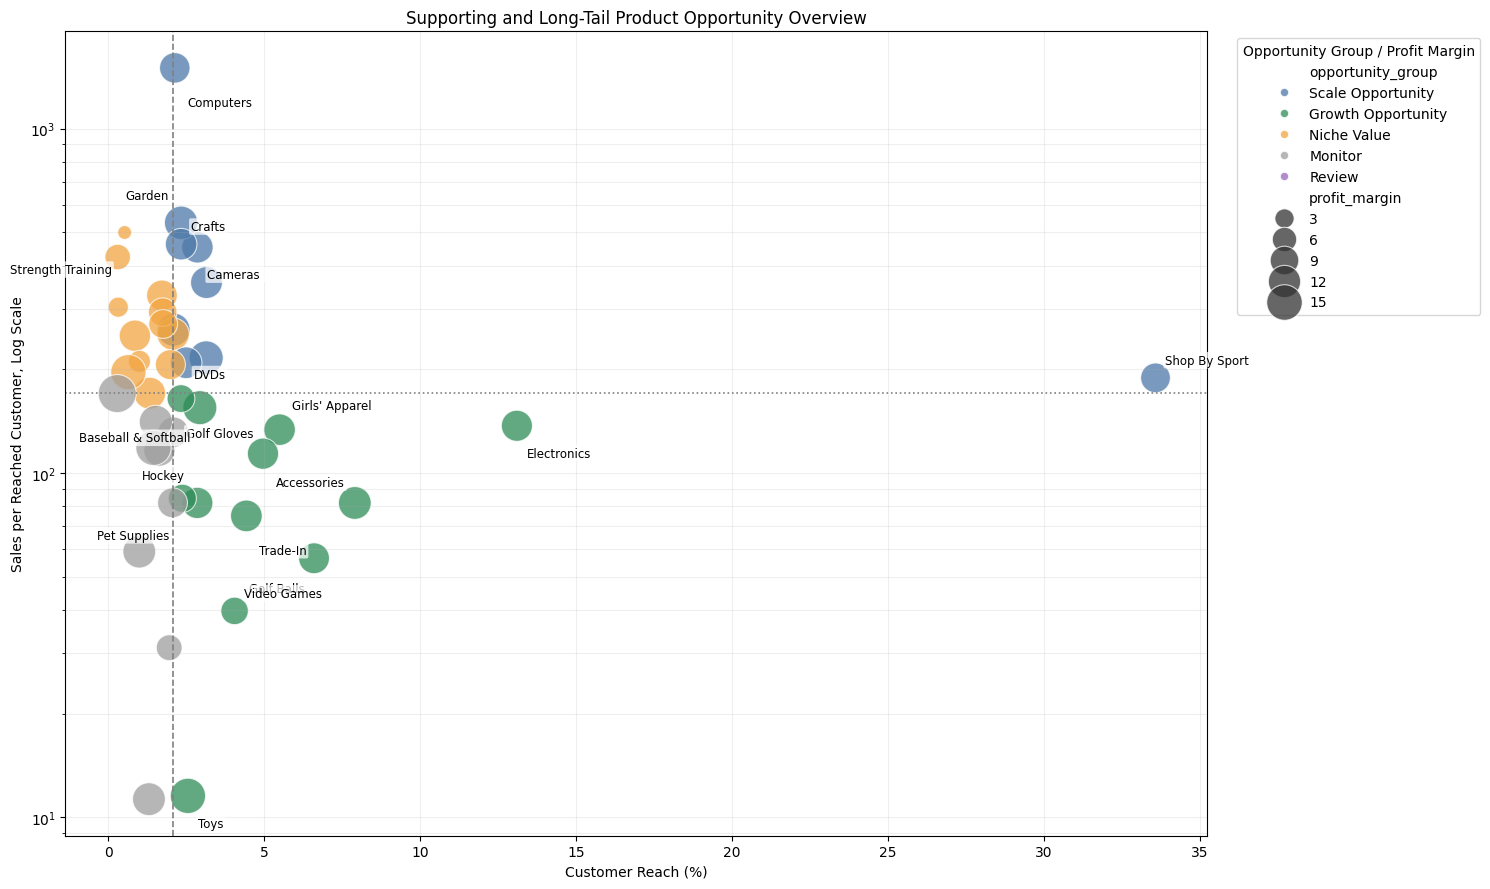

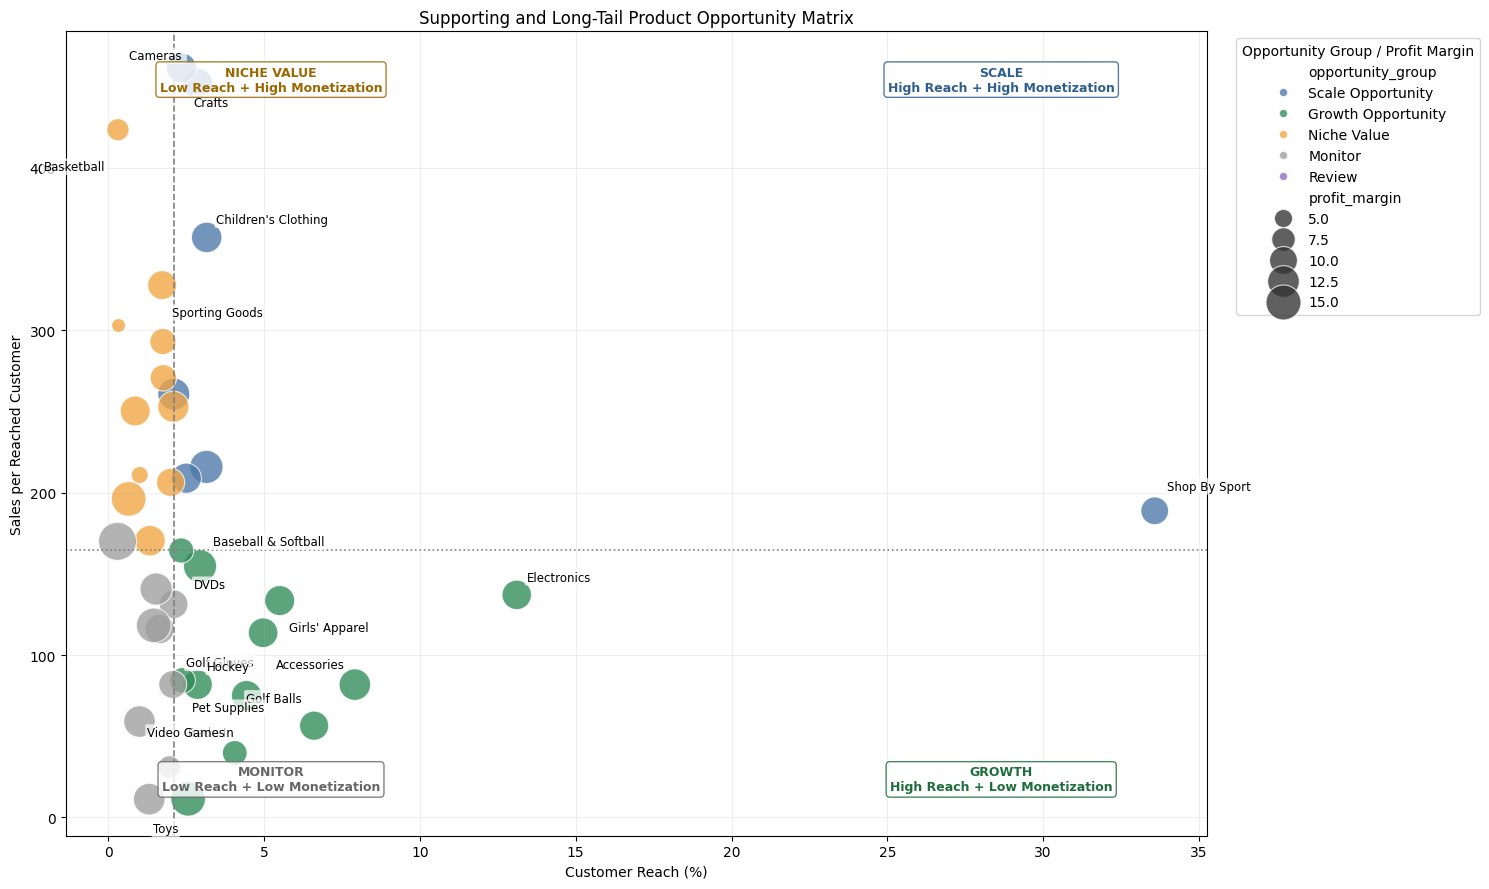


High-Monetization Outliers


,Category Name,product_value_tier,opportunity_group,customer_reach_pct,sales_per_customer,profit_margin,sales_contribution_pct,profit_contribution_pct
1,Computers,Supporting Products,Scale Opportunity,2.14%,"1,500.00",10.51%,1.80%,1.76%
4,Garden,Supporting Products,Scale Opportunity,2.34%,532.58,12.97%,0.70%,0.84%
23,Strength Training,Long-Tail Products,Niche Value,0.53%,499.05,0.61%,0.15%,0.01%



Product Opportunity Matrix Summary
All Categories Included: True

Growth Opportunity: 12 categories
Electronics, Girls' Apparel, Accessories, Golf Gloves, Baseball & Softball, DVDs, Golf Balls, Trade-In, Hockey, Pet Supplies

Scale Opportunity: 9 categories
Shop By Sport, Computers, Cameras , Garden, Children's Clothing, Crafts, Women's Clothing, Music, Golf Shoes

Niche Value: 12 categories
Sporting Goods, Consumer Electronics, Health and Beauty, Kids' Golf Clubs, Boxing & MMA, Strength Training, Men's Golf Clubs, Women's Golf Clubs, Men's Clothing, Basketball

Monitor: 9 categories
Hunting & Shooting, Tennis & Racquet, Lacrosse, Fitness Accessories, Golf Apparel, Books , Baby , Golf Bags & Carts, CDs 


In [87]:
# ============================================================
# Step 9.4.1 Prepare Supporting and Long-Tail Opportunity Metrics
# ============================================================

if "product_value_df" not in globals():
    raise NameError(
        "product_value_df is not defined."
    )

if "product_tier_profile_df" not in globals():
    raise NameError(
        "product_tier_profile_df is not defined."
    )

# Keep only Supporting and Long-Tail Products
opportunity_products = (
    product_value_df
    .loc[
        product_value_df["product_value_tier"]
        .astype(str)
        .isin(
            [
                "Supporting Products",
                "Long-Tail Products"
            ]
        )
    ]
    .copy()
)

# Transaction-level customer activity
customer_activity = (
    product_tier_profile_df
    .loc[
        product_tier_profile_df["product_value_tier"]
        .astype(str)
        .isin(
            [
                "Supporting Products",
                "Long-Tail Products"
            ]
        )
    ]
    .groupby(
        "Category Name",
        observed=True
    )
    .agg(
        customer_count=("Customer Id","nunique"),
        order_count=("Order Id","nunique"),
        total_sales=("Sales","sum"),
        total_profit=("Order Profit Per Order","sum")
    )
    .reset_index()
)

total_customers = (
    product_tier_profile_df["Customer Id"]
    .nunique()
)

customer_activity["customer_reach_pct"] = (
    customer_activity["customer_count"]
    /
    total_customers
    * 100
)

customer_activity["sales_per_customer"] = (
    customer_activity["total_sales"]
    /
    customer_activity["customer_count"]
)

customer_activity["profit_per_customer"] = (
    customer_activity["total_profit"]
    /
    customer_activity["customer_count"]
)

opportunity_df = (
    opportunity_products[
        [
            "Category Name",
            "product_value_tier",
            "sales_contribution_pct",
            "profit_contribution_pct",
            "profit_margin"
        ]
    ]
    .merge(
        customer_activity,
        on="Category Name",
        how="left",
        validate="one_to_one"
    )
)

display(
    opportunity_df[
        [
            "Category Name",
            "product_value_tier",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_margin"
        ]
    ]
    .sort_values(
        "customer_reach_pct",
        ascending=False
    )
    .style.format({
        "customer_reach_pct":"{:.2f}%",
        "sales_per_customer":"{:,.2f}",
        "profit_margin":"{:.2f}%"
    })
)


# ============================================================
# Step 9.4.2 Measure Customer Reach and Customer Monetization
# ============================================================

reach_threshold = (
    opportunity_df["customer_reach_pct"]
    .median()
)

sales_per_customer_threshold = (
    opportunity_df["sales_per_customer"]
    .median()
)

margin_threshold = (
    opportunity_df["profit_margin"]
    .median()
)

print(
    "Median Customer Reach:",
    f"{reach_threshold:.2f}%"
)

print(
    "Median Sales per Customer:",
    f"{sales_per_customer_threshold:,.2f}"
)

print(
    "Median Profit Margin:",
    f"{margin_threshold:.2f}%"
)


# ============================================================
# Step 9.4.3 Classify Product Opportunity Groups
# ============================================================

opportunity_df["opportunity_group"] = np.select(
    [
        (
            opportunity_df["customer_reach_pct"]
            >= reach_threshold
        )
        &
        (
            opportunity_df["sales_per_customer"]
            < sales_per_customer_threshold
        ),

        (
            opportunity_df["customer_reach_pct"]
            >= reach_threshold
        )
        &
        (
            opportunity_df["sales_per_customer"]
            >= sales_per_customer_threshold
        ),

        (
            opportunity_df["customer_reach_pct"]
            < reach_threshold
        )
        &
        (
            opportunity_df["sales_per_customer"]
            >= sales_per_customer_threshold
        ),

        (
            opportunity_df["customer_reach_pct"]
            < reach_threshold
        )
        &
        (
            opportunity_df["sales_per_customer"]
            < sales_per_customer_threshold
        )
    ],
    [
        "Growth Opportunity",
        "Scale Opportunity",
        "Niche Value",
        "Monitor"
    ],
    default="Review"
)

display(
    opportunity_df[
        [
            "Category Name",
            "opportunity_group",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_margin"
        ]
    ]
    .sort_values(
        [
            "customer_reach_pct",
            "sales_per_customer"
        ],
        ascending=False
    )
    .style.format({
        "customer_reach_pct":"{:.2f}%",
        "sales_per_customer":"{:,.2f}",
        "profit_margin":"{:.2f}%"
    })
)


# ============================================================
# Step 9.4.4 Identify Growth and Niche-Value Opportunities
# ============================================================

growth_candidates = (
    opportunity_df
    .loc[
        opportunity_df["opportunity_group"]
        .eq("Growth Opportunity")
    ]
    .copy()
)

niche_candidates = (
    opportunity_df
    .loc[
        opportunity_df["opportunity_group"]
        .eq("Niche Value")
    ]
    .copy()
)

print("\nGrowth Opportunity Categories")

display(
    growth_candidates[
        [
            "Category Name",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_margin"
        ]
    ]
    .style.format({
        "customer_reach_pct":"{:.2f}%",
        "sales_per_customer":"{:,.2f}",
        "profit_margin":"{:.2f}%"
    })
)

print("\nNiche Value Categories")

display(
    niche_candidates[
        [
            "Category Name",
            "customer_reach_pct",
            "sales_per_customer",
            "profit_margin"
        ]
    ]
    .style.format({
        "customer_reach_pct":"{:.2f}%",
        "sales_per_customer":"{:,.2f}",
        "profit_margin":"{:.2f}%"
    })
)


# ============================================================
# Step 9.4.5 Evaluate Portfolio Balance Across Opportunity Groups
# ============================================================

group_summary = (
    opportunity_df
    .groupby(
        "opportunity_group",
        observed=True
    )
    .agg(
        category_count=("Category Name","count"),
        total_sales=("total_sales","sum"),
        total_profit=("total_profit","sum")
    )
    .reset_index()
)

group_summary["category_share_pct"] = (
    group_summary["category_count"]
    /
    group_summary["category_count"].sum()
    * 100
)

display(
    group_summary.style.format({
        "category_count":"{:,.0f}",
        "total_sales":"{:,.0f}",
        "total_profit":"{:,.0f}",
        "category_share_pct":"{:.2f}%"
    })
)


# ============================================================
# Step 9.4.6 Visualize the Product Opportunity Matrix
# ============================================================
# Two complementary charts are used:
#
# 1. Portfolio Overview Matrix
#    - Includes all Supporting and Long-Tail Products
#    - Uses a logarithmic Y-axis to handle extreme values
#
# 2. Main Opportunity Matrix
#    - Focuses on categories below the 95th percentile of
#      sales per customer
#    - Uses a linear scale for easier comparison
#
# Only selected categories are labeled to reduce clutter.
# ============================================================

group_palette = {
    "Growth Opportunity": "#2E8B57",
    "Scale Opportunity": "#4C78A8",
    "Niche Value": "#F2A541",
    "Monitor": "#9E9E9E",
    "Review": "#9467BD"
}

# Define the 95th percentile used for the focused view.
sales_per_customer_limit = (
    opportunity_df["sales_per_customer"]
    .quantile(0.95)
)

# Identify high-monetization outliers.
high_monetization_outliers = (
    opportunity_df
    .loc[
        opportunity_df["sales_per_customer"]
        > sales_per_customer_limit
    ]
    .copy()
)

print(
    "Focused View Sales-per-Customer Limit:",
    f"{sales_per_customer_limit:,.2f}"
)

if not high_monetization_outliers.empty:
    print(
        "High-Monetization Outliers:",
        ", ".join(
            high_monetization_outliers["Category Name"]
            .astype(str)
            .tolist()
        )
    )


# ------------------------------------------------------------
# Chart 1: Portfolio Overview with Logarithmic Scale
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 9))

sns.scatterplot(
    data=opportunity_df,
    x="customer_reach_pct",
    y="sales_per_customer",
    hue="opportunity_group",
    hue_order=[
        "Scale Opportunity",
        "Growth Opportunity",
        "Niche Value",
        "Monitor",
        "Review"
    ],
    palette=group_palette,
    size="profit_margin",
    sizes=(100, 750),
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# A logarithmic scale preserves outliers while separating
# categories with lower sales per customer.
ax.set_yscale("log")

# Add median reference lines.
ax.axvline(
    x=reach_threshold,
    color="gray",
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    y=sales_per_customer_threshold,
    color="gray",
    linestyle=":",
    linewidth=1.2
)

# Label selected categories only:
# - Top 5 by customer reach
# - Top 5 by sales per customer
# - All Growth Opportunities
overview_label_df = (
    pd.concat(
        [
            opportunity_df.nlargest(
                min(5, len(opportunity_df)),
                "customer_reach_pct"
            ),
            opportunity_df.nlargest(
                min(5, len(opportunity_df)),
                "sales_per_customer"
            ),
            opportunity_df.loc[
                opportunity_df["opportunity_group"]
                .eq("Growth Opportunity")
            ]
        ],
        ignore_index=True
    )
    .drop_duplicates(subset=["Category Name"])
)

label_offsets = [
    (7, 8),
    (7, -15),
    (-7, 10),
    (-7, -17),
    (9, 13),
    (9, -20),
    (-9, 15),
    (-9, -22)
]

for index, (_, row) in enumerate(
    overview_label_df.iterrows()
):
    x_offset, y_offset = label_offsets[
        index % len(label_offsets)
    ]

    ax.annotate(
        row["Category Name"],
        xy=(
            row["customer_reach_pct"],
            row["sales_per_customer"]
        ),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha="left" if x_offset >= 0 else "right",
        va="bottom" if y_offset >= 0 else "top",
        fontsize=8.5,
        bbox={
            "boxstyle": "round,pad=0.15",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

ax.set_title(
    "Supporting and Long-Tail Product Opportunity Overview"
)

ax.set_xlabel(
    "Customer Reach (%)"
)

ax.set_ylabel(
    "Sales per Reached Customer, Log Scale"
)

ax.grid(
    alpha=0.20,
    which="both"
)

ax.legend(
    title="Opportunity Group / Profit Margin",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Focused Main Opportunity Matrix
# ------------------------------------------------------------
# Exclude only the upper 5% of sales-per-customer values
# from this visual. These observations remain in the dataset
# and are listed separately as high-monetization outliers.
# ------------------------------------------------------------

focused_opportunity_df = (
    opportunity_df
    .loc[
        opportunity_df["sales_per_customer"]
        <= sales_per_customer_limit
    ]
    .copy()
)

# Recalculate display thresholds for the focused population.
# These thresholds are used for visualization only.
focused_reach_threshold = (
    focused_opportunity_df["customer_reach_pct"]
    .median()
)

focused_sales_threshold = (
    focused_opportunity_df["sales_per_customer"]
    .median()
)

fig, ax = plt.subplots(figsize=(15, 9))

sns.scatterplot(
    data=focused_opportunity_df,
    x="customer_reach_pct",
    y="sales_per_customer",
    hue="opportunity_group",
    hue_order=[
        "Scale Opportunity",
        "Growth Opportunity",
        "Niche Value",
        "Monitor",
        "Review"
    ],
    palette=group_palette,
    size="profit_margin",
    sizes=(100, 750),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

ax.axvline(
    x=focused_reach_threshold,
    color="gray",
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    y=focused_sales_threshold,
    color="gray",
    linestyle=":",
    linewidth=1.2
)

# Label categories with the greatest analytical value:
# - All Growth Opportunities
# - Top 5 by customer reach
# - Top 5 by sales per customer in the focused view
focused_label_df = (
    pd.concat(
        [
            focused_opportunity_df.loc[
                focused_opportunity_df["opportunity_group"]
                .eq("Growth Opportunity")
            ],
            focused_opportunity_df.nlargest(
                min(5, len(focused_opportunity_df)),
                "customer_reach_pct"
            ),
            focused_opportunity_df.nlargest(
                min(5, len(focused_opportunity_df)),
                "sales_per_customer"
            )
        ],
        ignore_index=True
    )
    .drop_duplicates(subset=["Category Name"])
)

for index, (_, row) in enumerate(
    focused_label_df.iterrows()
):
    x_offset, y_offset = label_offsets[
        index % len(label_offsets)
    ]

    ax.annotate(
        row["Category Name"],
        xy=(
            row["customer_reach_pct"],
            row["sales_per_customer"]
        ),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha="left" if x_offset >= 0 else "right",
        va="bottom" if y_offset >= 0 else "top",
        fontsize=8.5,
        bbox={
            "boxstyle": "round,pad=0.15",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72
        }
    )

# Add simple quadrant descriptions without covering points.
quadrant_labels = [
    (
        0.82,
        0.94,
        "SCALE\nHigh Reach + High Monetization",
        "#2F5F8F"
    ),
    (
        0.18,
        0.94,
        "NICHE VALUE\nLow Reach + High Monetization",
        "#9A6700"
    ),
    (
        0.82,
        0.07,
        "GROWTH\nHigh Reach + Low Monetization",
        "#1F6D3D"
    ),
    (
        0.18,
        0.07,
        "MONITOR\nLow Reach + Low Monetization",
        "#666666"
    )
]

for x_pos, y_pos, label, color in quadrant_labels:
    ax.text(
        x_pos,
        y_pos,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=color,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": color,
            "alpha": 0.82
        }
    )

ax.set_title(
    "Supporting and Long-Tail Product Opportunity Matrix"
)

ax.set_xlabel(
    "Customer Reach (%)"
)

ax.set_ylabel(
    "Sales per Reached Customer"
)

ax.grid(alpha=0.20)

ax.legend(
    title="Opportunity Group / Profit Margin",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Display high-monetization outliers separately
# ------------------------------------------------------------

if not high_monetization_outliers.empty:

    print("\n" + "=" * 75)
    print("High-Monetization Outliers")
    print("=" * 75)

    display(
        high_monetization_outliers[
            [
                "Category Name",
                "product_value_tier",
                "opportunity_group",
                "customer_reach_pct",
                "sales_per_customer",
                "profit_margin",
                "sales_contribution_pct",
                "profit_contribution_pct"
            ]
        ]
        .sort_values(
            "sales_per_customer",
            ascending=False
        )
        .style.format({
            "customer_reach_pct": "{:.2f}%",
            "sales_per_customer": "{:,.2f}",
            "profit_margin": "{:.2f}%",
            "sales_contribution_pct": "{:.2f}%",
            "profit_contribution_pct": "{:.2f}%"
        })
    )


# ============================================================
# Step 9.4.7 Validate and Summarize Opportunity Priorities
# ============================================================

category_check = (
    opportunity_df["Category Name"]
    .nunique()
    ==
    opportunity_products["Category Name"]
    .nunique()
)

print("\n" + "=" * 75)
print("Product Opportunity Matrix Summary")
print("=" * 75)

print(
    "All Categories Included:",
    category_check
)

for group in [
    "Growth Opportunity",
    "Scale Opportunity",
    "Niche Value",
    "Monitor"
]:

    group_df = (
        opportunity_df
        .loc[
            opportunity_df["opportunity_group"]
            .eq(group)
        ]
    )

    print(
        f"\n{group}: "
        f"{len(group_df)} categories"
    )

    if len(group_df) > 0:

        print(
            ", ".join(
                group_df["Category Name"]
                .head(10)
                .tolist()
            )
        )

### Key Observations

- Supporting and Long-Tail Products exhibit diverse growth profiles rather than forming a single homogeneous group. The portfolio is distributed across four opportunity groups: **Scale Opportunity (9 categories)**, **Growth Opportunity (12 categories)**, **Niche Value (12 categories)**, and **Monitor (9 categories)**.

- **Shop By Sport** stands out as the strongest Scale Opportunity, combining the highest customer reach (**33.6%**) with meaningful customer monetization (**190 sales per customer**). Electronics, Girls' Apparel, and Accessories also demonstrate strong growth potential due to their relatively high customer reach and healthy profit margins.

- Several categories, including **Computers**, **Garden**, and **Crafts**, generate very high sales per customer despite limited customer reach. These categories behave more like niche value products than broad growth opportunities.

- Long-Tail opportunities remain fragmented. While many categories contribute little individually, several niche categories maintain healthy margins and customer spending levels, suggesting that low sales contribution does not necessarily imply low business value.

### Business Implications

- Growth investments should prioritize categories with strong customer reach but underdeveloped monetization, particularly **Shop By Sport, Electronics, Girls' Apparel, and Accessories**.

- Categories such as **Computers** and **Garden** are better suited to targeted expansion strategies because they already generate high customer value despite serving smaller customer bases.

- Long-Tail Products should not be evaluated solely by sales contribution. Portfolio decisions should balance customer reach, customer monetization, profit margin, and category role before considering further investment or review.

# Step 10. Business Recommendations

### 1. Improve Order Completion and Risk Monitoring

- Monitor cancelled, incomplete, and fraud-related orders by market, customer segment, and product category.
- Investigate recurring order-status patterns before introducing targeted operational controls.
- Track order completion rate as a core business KPI.

### 2. Strengthen Delivery Reliability

- Prioritize reducing late deliveries, particularly within shipping modes and markets with consistently weaker performance.
- Evaluate actual versus scheduled shipping days to identify recurring fulfillment gaps.
- Avoid assuming that faster shipping modes automatically produce better delivery outcomes.

### 3. Improve Profitability Management

- Monitor loss-making orders separately from total sales and average margin.
- Review high-sales areas with weaker profit contribution or elevated loss exposure.
- Use weighted profit margin and total profit together to distinguish scale from profitability efficiency.

### 4. Protect High-Value Customer Relationships

- Prioritize the retention of VIP and High Value customers, who generate nearly 80% of sales and profit.
- Monitor changes in purchase frequency, spending, and profitability within these segments.
- Investigate lower-value segments separately before selecting conversion or engagement strategies.

### 5. Protect Core Products and Reduce Concentration Dependency

- Maintain product availability and closely monitor Fishing, Cleats, Camping & Hiking, and other major Core Products.
- Establish category-level alerts for material changes in sales, profit, customer reach, and order activity.
- Reduce long-term dependency by expanding suitable Supporting Products.

### 6. Develop Supporting and Long-Tail Products Selectively

- Further evaluate Supporting Products with meaningful customer reach but relatively low sales per customer.
- Assess niche Long-Tail Products using customer reach, monetization, profitability, and strategic relevance.
- Do not discontinue products based solely on low sales contribution.

### Implementation Note

These recommendations identify priority areas for further action. Campaign effectiveness, causal drivers, and product-removal decisions require additional cost, inventory, customer-response, and operational data.

# Project Limitations

- Customer acquisition data and sufficient customer history were unavailable; therefore, retention dynamics and Customer Lifetime Value (CLV) could not be assessed.

- Product cost, inventory cost, and supplier cost information were not provided, limiting the ability to identify true profitability drivers.

- Marketing campaign and promotion data were unavailable, preventing direct evaluation of marketing effectiveness.

- Detailed warehouse, logistics, and carrier event data were unavailable, limiting root-cause analysis of delivery delays.

- Results should be interpreted as associations based on historical transactional patterns rather than causal relationships. Product opportunity recommendations should be validated through business testing before implementation.